# CITADEL Single-Notebook Experiment Runner

This notebook is the sole experiment runner for the CITADEL journal-extension workspace. It is organized as an end-to-end edge-SLM workflow: load benign/anomaly telemetry, calibrate a benign reference, learn a stable conditional telemetry graph, rank compact hardware-aware features, sweep CINTAS deployment settings, evaluate detection and false positives, quantify fixed-point and hardware cost, check lifecycle drift, export RTL/FPGA hooks, and regenerate paper-ready tables and figures.

For the TCAD paper, keep `DATA_MODE = "real"`, `TCAD_PRESET = "balanced"`, `SEED = 123`, and `THREADS = 1`. DDR4/DDR5 telemetry is read from `data/telemetry/processed/ddr_data/`. Apple tier data is read from `data/telemetry/raw/apple_data/` only for the supplemental portability/observability study; it is not mixed into CINTAS area, power, or FPGA claims. Use `TCAD_PRESET = "full"` only for an optional exhaustive ASU/Linux sensitivity run.

The practical deployment loop is:

`MacBook notebook DSE -> selected CINTAS settings -> ASU/Linux Vivado RTL -> rtl_resource_summary.csv -> MacBook merge -> final TCAD tables/figures`.


In [1]:
from __future__ import annotations

import json
import os
import platform
import shutil
import subprocess
import sys
import tempfile
from pathlib import Path

EARLY_SEED = "123"
EARLY_THREADS = "1"
for key in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
):
    os.environ[key] = EARLY_THREADS
os.environ["PYTHONHASHSEED"] = EARLY_SEED
os.environ["MPLBACKEND"] = "Agg"
_mpl_config_dir = Path(tempfile.gettempdir()) / "citadel-matplotlib"
_mpl_config_dir.mkdir(parents=True, exist_ok=True)
os.environ["MPLCONFIGDIR"] = str(_mpl_config_dir)

import pandas as pd
from IPython.display import Markdown, display


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start).resolve()
    markers = (
        Path("notebooks") / "exact_tcad_all_experiments.ipynb",
        Path("configs") / "tcad_grid_smoke.json",
        Path("data") / "external_sources.json",
    )
    for candidate in (start, *start.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise RuntimeError(f"Could not find CITADEL repo root from {start}")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
print(f"Repository: {REPO_ROOT}")
print(f"Python: {platform.python_version()} on {platform.platform()}")


Repository: /Users/hsiaopingni/CITADEL
Python: 3.11.15 on macOS-26.5.1-arm64-arm-64bit


## 1. Reproducibility Configuration

The notebook uses deterministic settings for every experiment:

- seed: `123`
- numerical threads: `1`
- automatic DDR and Apple telemetry discovery
- deterministic sample-data generator when `DATA_MODE = "sample"`
- repo-relative paths
- run manifests with package versions, git commit, input hashes, and output hashes
- live progress cards in long-running notebook cells plus `results/notebook_run/notebook_progress.log`

For the strictest cross-machine comparison, start Jupyter itself with `PYTHONHASHSEED=123`. The notebook still sets the environment variable for downstream tools.


In [2]:
SEED = 123
THREADS = 1
SAMPLE_ROWS = 600

DDR_DATA_ROOT = REPO_ROOT / "data" / "telemetry" / "processed" / "ddr_data"
APPLE_DATA_ROOT = REPO_ROOT / "data" / "telemetry" / "raw" / "apple_data"
REAL_DATA_ROOT = DDR_DATA_ROOT
APPLE_TIER_DATA_ROOT = APPLE_DATA_ROOT
DATA_SOURCE_CONFIG = REPO_ROOT / "data" / "external_sources.json"

def csv_files(root: Path) -> list[Path]:
    return sorted(root.rglob("*.csv"))


def is_git_lfs_pointer(path: Path) -> bool:
    try:
        with path.open("rb") as f:
            return f.read(64).startswith(b"version https://git-lfs.github.com/spec")
    except OSError:
        return False


DDR_CSVS = csv_files(DDR_DATA_ROOT)
APPLE_CSVS = csv_files(APPLE_DATA_ROOT)
pointer_files = [p for p in [*DDR_CSVS[:3], *APPLE_CSVS[:3]] if is_git_lfs_pointer(p)]
if pointer_files:
    listed = "\n".join(str(p.relative_to(REPO_ROOT)) for p in pointer_files[:6])
    raise RuntimeError(
        "Telemetry CSVs are still Git LFS pointer files. Fetch the Git LFS objects "
        "with your Git client before running the notebook. Examples:\n" + listed
    )

# The repo now tracks real telemetry. Change to "sample" only for a tiny pipeline check.
DATA_MODE = "real" if DDR_CSVS else "sample"  # "real" or "sample"
TCAD_PRESET = "full"  # "balanced" for TCAD paper results; use "full" only for optional exhaustive ASU/Linux sensitivity runs
RUN_REPEAT_CHECK = True

RESULTS_ROOT = REPO_ROOT / "results" / "notebook_run"
DATA_ROOT = REPO_ROOT / "data" / "sample" if DATA_MODE == "sample" else REAL_DATA_ROOT
TCAD_OUT = RESULTS_ROOT / "tcad_ablation"
TCAD_REPEAT_OUT = RESULTS_ROOT / "tcad_ablation_repeat"
LIFECYCLE_OUT = RESULTS_ROOT / "lifecycle_drift"
FPGA_OUT = RESULTS_ROOT / "fpga"
RTL_SWEEP_OUT = RESULTS_ROOT / "rtl_sweep"
PROGRESS_LOG = RESULTS_ROOT / "notebook_progress.log"

import random

def configure_reproducibility(seed: int = 123, *, threads: int = 1, matplotlib_backend: str | None = "Agg") -> dict[str, str]:
    env_updates = {"PYTHONHASHSEED": str(seed)}
    for name in (
        "OMP_NUM_THREADS",
        "OPENBLAS_NUM_THREADS",
        "MKL_NUM_THREADS",
        "NUMEXPR_NUM_THREADS",
        "VECLIB_MAXIMUM_THREADS",
    ):
        env_updates[name] = str(threads)
    mpl_config_dir = Path(tempfile.gettempdir()) / "citadel-matplotlib"
    mpl_config_dir.mkdir(parents=True, exist_ok=True)
    env_updates["MPLCONFIGDIR"] = str(mpl_config_dir)
    if matplotlib_backend:
        env_updates["MPLBACKEND"] = matplotlib_backend
    for name, value in env_updates.items():
        os.environ[name] = value
    random.seed(seed)
    try:
        import numpy as _np
        _np.random.seed(seed)
    except Exception:
        pass
    return env_updates

env_updates = configure_reproducibility(seed=SEED, threads=THREADS, matplotlib_backend="Agg")
PROGRESS_LOG.parent.mkdir(parents=True, exist_ok=True)
PROGRESS_LOG.write_text(f"CITADEL notebook progress log\nseed={SEED} threads={THREADS} preset={TCAD_PRESET}\n", encoding="utf-8")
print(f"Progress log: {PROGRESS_LOG.relative_to(REPO_ROOT)}")
for key, value in env_updates.items():
    print(f"{key}={value}")

Progress log: results/notebook_run/notebook_progress.log
PYTHONHASHSEED=123
OMP_NUM_THREADS=1
OPENBLAS_NUM_THREADS=1
MKL_NUM_THREADS=1
NUMEXPR_NUM_THREADS=1
VECLIB_MAXIMUM_THREADS=1
MPLCONFIGDIR=/var/folders/2z/b1lzf17n4z90pz80khfc42fw0000gp/T/citadel-matplotlib
MPLBACKEND=Agg


## 2. Integrated Notebook Utilities

This section keeps the shared CITADEL experiment utilities inside the notebook so data preparation, sample-data generation, TCAD design-space sweeps, figure generation, hardware-cost estimates, lifecycle drift checks, and manifest handling all run from one place.


In [3]:
import hashlib
import json
import os
import subprocess
import time
import urllib.parse
import urllib.request
from dataclasses import asdict, dataclass
from itertools import product
from pathlib import Path
from typing import Any, Iterable, Sequence

import numpy as np
import pandas as pd


# ---- Inlined from former helper io.py ----

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Tuple

import numpy as np
import pandas as pd


META_COLS_BASE = {
    "setup",
    "scenario",
    "workload",
    "time_idx",
    "label",
    "is_anom",
}


def _sanitize_telemetry_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Drop autogenerated index columns and normalize header whitespace."""
    renamed = {col: str(col).strip() for col in df.columns}
    df = df.rename(columns=renamed)
    keep = [col for col in df.columns if col and not str(col).startswith("Unnamed:")]
    return df.loc[:, keep].copy()


def parse_scenario_workload_from_name(path: Path) -> Tuple[str, str]:
    """Parse (scenario, workload) from a telemetry CSV filename.

    Expected filenames are the same as in the draft notebooks, e.g.:

        DDR4_DROOP_dft.csv
        DDR4_benign_tr.csv
        DDR5_SPECTRE_mm.csv
        DDR5_benign_ni.csv

    Returns
    -------
    scenario : str
        One of BENIGN, DROOP, RH, SPECTRE (uppercased).
    workload : str
        Workload tag (uppercased), e.g., DFT, DJ, ...

    Notes
    -----
    This is intentionally strict: it helps catch data naming issues early.
    """
    stem = path.stem  # e.g. 'DDR4_DROOP_dft'
    parts = stem.split("_")
    if len(parts) < 3:
        raise ValueError(f"Cannot parse scenario/workload from filename: {path.name}")

    scen_raw = parts[1].strip().upper()
    wl_raw = parts[2].strip().upper()

    scenario = "BENIGN" if scen_raw == "BENIGN" else scen_raw
    workload = wl_raw
    return scenario, workload


def load_telemetry_for_setup(setup: str, data_root: Path) -> pd.DataFrame:
    """Load and concatenate telemetry CSVs for a given setup.

    Parameters
    ----------
    setup:
        'A' (DDR4) or 'B' (DDR5).
    data_root:
        Folder containing telemetry CSVs.

    Returns
    -------
    pd.DataFrame
        Concatenated telemetry with meta columns:
          - setup ('A' or 'B')
          - scenario ('BENIGN', 'DROOP', 'RH', 'SPECTRE', ...)
          - workload (e.g. 'DFT', 'DP', ...)
          - time_idx (row index inside each file if missing)
          - is_anom (0 for BENIGN else 1)
          - label  (same as is_anom at sample level)
    """
    setup_u = setup.upper()
    if setup_u == "A":
        prefix = "DDR4_"
    elif setup_u == "B":
        prefix = "DDR5_"
    else:
        raise ValueError(f"Unknown setup: {setup}. Expected 'A' or 'B'.")

    data_root = Path(data_root)
    files = sorted(data_root.glob(f"{prefix}*.csv"))
    if not files:
        raise FileNotFoundError(
            f"No files found for setup {setup_u} with prefix {prefix} in {data_root}"
        )

    dfs = []
    for path in files:
        scenario, workload = parse_scenario_workload_from_name(path)
        df = _sanitize_telemetry_columns(pd.read_csv(path))

        # Add meta columns
        df["setup"] = setup_u
        df["scenario"] = scenario
        df["workload"] = workload

        if "time_idx" not in df.columns:
            df["time_idx"] = np.arange(len(df), dtype=int)

        is_anom = 0 if scenario == "BENIGN" else 1
        df["is_anom"] = is_anom
        df["label"] = is_anom

        dfs.append(df)

    full_df = pd.concat(dfs, ignore_index=True)

    # Sort for reproducible windowing later
    full_df = (
        full_df.sort_values(["workload", "scenario", "time_idx"])
        .reset_index(drop=True)
    )
    return full_df


def load_telemetry_two_setups(data_root: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Convenience loader: returns (setup_A_df, setup_B_df)."""
    data_root = Path(data_root)
    return load_telemetry_for_setup("A", data_root), load_telemetry_for_setup("B", data_root)


# ---- Inlined from former helper preprocessing.py ----

from typing import Iterable

import numpy as np
import pandas as pd



def get_feature_columns(df: pd.DataFrame, meta_cols: Iterable[str] | None = None) -> list[str]:
    """Return numeric telemetry columns used as features.

    The draft notebooks treat all numeric columns as candidate telemetry features
    except for meta/label columns.
    """
    meta = set(META_COLS_BASE if meta_cols is None else meta_cols)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    return [c for c in numeric_cols if c not in meta]


def clean_and_debias_telemetry(
    df: pd.DataFrame,
    scenario_col: str = "scenario",
    benign_name: str = "BENIGN",
    inplace: bool = False,
) -> pd.DataFrame:
    """Simple cleaning + benign de-biasing (from EXACT.ipynb).

    Steps
    -----
    1) Drop rows where *all* numeric feature columns are NaN.
    2) Fill remaining NaNs with BENIGN means if BENIGN exists else global means.
    3) Subtract BENIGN means (or global means) from every sample.

    Notes
    -----
    This is intentionally minimal and matches the draft notebook behavior.
    If you have monotonic counters, you may want to convert them to per-sample
    deltas before calling this function.
    """
    df2 = df if inplace else df.copy()

    feature_cols = get_feature_columns(df2)
    if not feature_cols:
        raise ValueError("No numeric feature columns found for telemetry.")

    # Drop rows where all feature columns are NaN
    mask_all_nan = df2[feature_cols].isna().all(axis=1)
    if mask_all_nan.any():
        df2 = df2.loc[~mask_all_nan].reset_index(drop=True)

    # Compute BENIGN means if available
    if scenario_col in df2.columns:
        ben_mask = df2[scenario_col].astype(str).str.upper() == benign_name.upper()
        if ben_mask.any():
            benign_means = df2.loc[ben_mask, feature_cols].mean(axis=0)
            df2[feature_cols] = df2[feature_cols].fillna(benign_means)
            df2[feature_cols] = df2[feature_cols] - benign_means
        else:
            global_means = df2[feature_cols].mean(axis=0)
            df2[feature_cols] = df2[feature_cols].fillna(global_means)
            df2[feature_cols] = df2[feature_cols] - global_means
    else:
        global_means = df2[feature_cols].mean(axis=0)
        df2[feature_cols] = df2[feature_cols].fillna(global_means)
        df2[feature_cols] = df2[feature_cols] - global_means

    return df2


def drop_constant_features(df: pd.DataFrame, feature_cols: list[str] | None = None) -> list[str]:
    """Return the subset of feature columns that are non-constant."""
    if feature_cols is None:
        feature_cols = get_feature_columns(df)
    keep = []
    for c in feature_cols:
        s = df[c]
        if s.nunique(dropna=True) > 1:
            keep.append(c)
    return keep


# ---- Inlined from former helper metrics.py ----

import numpy as np
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
)


def expected_calibration_error(y_true: np.ndarray, y_prob: np.ndarray, n_bins: int = 10) -> float:
    """Expected Calibration Error (ECE) for binary probabilities."""
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if y_true.size == 0:
        return float("nan")
    if np.unique(y_true).size < 2:
        return 0.0

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        if i < n_bins - 1:
            mask = (y_prob >= lo) & (y_prob < hi)
        else:
            mask = (y_prob >= lo) & (y_prob <= hi)
        if not np.any(mask):
            continue
        p_bin = float(y_prob[mask].mean())
        y_bin = float(y_true[mask].mean())
        w_bin = float(mask.mean())
        ece += w_bin * abs(p_bin - y_bin)

    return float(ece)


def _safe_binary_metric(fn, y_true, y_score_or_pred, default=np.nan, **kwargs) -> float:
    y_true = np.asarray(y_true).astype(int)
    if y_true.size == 0 or np.unique(y_true).size < 2:
        return float(default)
    try:
        return float(fn(y_true, y_score_or_pred, **kwargs))
    except Exception:
        return float(default)


def compute_binary_metrics(y_true: np.ndarray, y_pred: np.ndarray, y_prob: np.ndarray) -> dict:
    """Compute detection metrics, including false-positive rate (FPR)."""
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    auc_roc = _safe_binary_metric(roc_auc_score, y_true, y_prob, default=np.nan)
    auc_pr = _safe_binary_metric(average_precision_score, y_true, y_prob, default=np.nan)
    f1 = _safe_binary_metric(f1_score, y_true, y_pred, default=0.0)
    bal_acc = _safe_binary_metric(balanced_accuracy_score, y_true, y_pred, default=0.5)
    mcc = _safe_binary_metric(matthews_corrcoef, y_true, y_pred, default=0.0)
    brier = _safe_binary_metric(brier_score_loss, y_true, y_prob, default=np.nan)
    ece = expected_calibration_error(y_true, y_prob, n_bins=10)

    neg_mask = y_true == 0
    fpr = float(np.mean(y_pred[neg_mask] == 1)) if np.any(neg_mask) else float("nan")

    return {
        "auc_roc": auc_roc,
        "auc_pr": auc_pr,
        "f1": f1,
        "bal_acc": bal_acc,
        "mcc": mcc,
        "fpr": fpr,
        "brier": brier,
        "ece": ece,
    }


# ---- Inlined from former helper cintas.py ----

from dataclasses import dataclass
from typing import Literal, Tuple

import numpy as np
import pandas as pd


@dataclass(frozen=True)
class CINTASModel:
    """CINTAS/CIAS parameter bundle + scoring functions.

    This is the same scoring core used in EXACT.ipynb:

      * Normalize telemetry using BENIGN mean/std
      * Compute:
          E2(t) = Σ_f w_f * z_f(t)^2
          E1(t) = Σ_f w_f * |z_f(t)|
          score(t) = (1 - λ)E2(t) + λE1(t)

    In the draft paper, CINTAS runs in fixed-point on-chip. This class is a
    *software reference* implementation; see FixedPointCINTAS for a small
    Q-format prototype.

    Attributes
    ----------
    feature_cols:
        Feature names (and order) used by this model.
    mu:
        BENIGN mean per feature.
    sigma:
        BENIGN std per feature.
    w:
        Non-negative weights per feature (sum to 1).
    lambda_res:
        Mixing coefficient λ in [0, 1].
    """
    feature_cols: list[str]
    mu: np.ndarray
    sigma: np.ndarray
    w: np.ndarray
    lambda_res: float = 0.5

    def _sigma_safe(self) -> np.ndarray:
        return np.where(self.sigma <= 1e-6, 1.0, self.sigma)

    def score_array(self, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Compute (score, E1, E2) for X with shape (n_samples, n_features)."""
        s = self._sigma_safe()
        Z = (X - self.mu) / s

        E2 = np.sum(self.w * (Z ** 2), axis=1)
        E1 = np.sum(self.w * np.abs(Z), axis=1)

        score = (1.0 - self.lambda_res) * E2 + self.lambda_res * E1
        return score.astype(float), E1.astype(float), E2.astype(float)

    def score_dataframe(self, df: pd.DataFrame) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        X = df[self.feature_cols].to_numpy(dtype=float)
        return self.score_array(X)


def fit_cintas_from_benign(
    df: pd.DataFrame,
    feature_cols: list[str],
    lambda_res: float = 0.5,
    *,
    scenario_col: str = "scenario",
    benign_name: str = "BENIGN",
    weight_mode: Literal["inv_var", "uniform"] = "inv_var",
) -> CINTASModel:
    """Fit CINTAS parameters from BENIGN rows only (unsupervised).

    The draft notebooks use inverse variance as a lightweight unsupervised
    weighting scheme (stable features get larger weight). Use uniform weights
    to match the unweighted form shown in the paper text.
    """
    if scenario_col not in df.columns:
        raise KeyError(f"Expected '{scenario_col}' column to fit from benign.")

    ben = df[df[scenario_col].astype(str).str.upper() == benign_name.upper()].copy()
    if ben.empty:
        raise ValueError("No BENIGN rows found; cannot fit CINTAS.")

    X_ben = ben[feature_cols].to_numpy(dtype=float)
    mu = X_ben.mean(axis=0)
    sigma = X_ben.std(axis=0, ddof=1)

    if weight_mode == "uniform":
        w = np.ones_like(mu, dtype=float) / max(len(mu), 1)
    elif weight_mode == "inv_var":
        inv_var = 1.0 / np.maximum(sigma ** 2, 1e-8)
        w_raw = np.maximum(inv_var, 0.0)
        w = (w_raw / w_raw.sum()) if np.any(w_raw) else (np.ones_like(w_raw) / len(w_raw))
    else:
        raise ValueError(f"Unknown weight_mode: {weight_mode}")

    return CINTASModel(
        feature_cols=list(feature_cols),
        mu=mu,
        sigma=sigma,
        w=w,
        lambda_res=float(lambda_res),
    )


# -------------------------------------------------------------------------
# Fixed-point reference (Q-format) — optional helper for edge-style scoring.
# -------------------------------------------------------------------------

@dataclass(frozen=True)
class FixedPointConfig:
    q: int = 15  # Q15 default

    @property
    def scale(self) -> int:
        return 1 << self.q


@dataclass(frozen=True)
class FixedPointCINTAS:
    """A small fixed-point prototype.

    This is not meant to be bit-exact to any RTL; it is a *reference* that
    keeps the core arithmetic in integers.
    """
    feature_cols: list[str]
    mu_q: np.ndarray        # int
    gamma_q: np.ndarray     # int, approx 1/sigma in Qq
    w_q: np.ndarray         # int, weights in Qq (sum ~= 1.0)
    lambda_q: int           # int, lambda in Qq
    cfg: FixedPointConfig = FixedPointConfig()

    @classmethod
    def from_float_model(cls, model: CINTASModel, cfg: FixedPointConfig = FixedPointConfig()) -> "FixedPointCINTAS":
        q = cfg.q
        scale = cfg.scale
        mu_q = np.round(model.mu * scale).astype(np.int64)
        sigma_safe = np.where(model.sigma <= 1e-6, 1.0, model.sigma)
        gamma = 1.0 / sigma_safe
        gamma_q = np.round(gamma * scale).astype(np.int64)

        w_q = np.round(model.w * scale).astype(np.int64)
        lambda_q = int(round(float(model.lambda_res) * scale))

        return cls(
            feature_cols=list(model.feature_cols),
            mu_q=mu_q,
            gamma_q=gamma_q,
            w_q=w_q,
            lambda_q=lambda_q,
            cfg=cfg,
        )

    def score_sample_int(self, x: np.ndarray) -> int:
        """Score one sample; returns Qq value as int."""
        q = self.cfg.q
        scale = self.cfg.scale

        # x is float → quantize to Qq
        x_q = np.round(np.asarray(x, dtype=float) * scale).astype(np.int64)

        # z_q = (x - mu) * gamma  (all Qq)
        # (x_q - mu_q) is Qq; multiply by gamma_q (Qq) → Q2q; shift back to Qq.
        z_q = ((x_q - self.mu_q) * self.gamma_q) >> q  # Qq

        abs_z = np.abs(z_q)  # Qq

        # E1 = Σ w * |z|  (Qq*Qq→Q2q >>q →Qq)
        e1_q = int(np.sum((self.w_q * abs_z) >> q))

        # E2 = Σ w * z^2
        # z^2: Qq^2 → Q2q; multiply by w_q(Qq) → Q3q; >>2q → Qq
        z2_q2 = (z_q * z_q)  # Q2q
        e2_q = int(np.sum((self.w_q * z2_q2) >> (2 * q)))

        # score = (1-λ)E2 + λE1
        one_q = scale
        score_q = ((one_q - self.lambda_q) * e2_q + self.lambda_q * e1_q) >> q
        return int(score_q)

    def score_dataframe(self, df: pd.DataFrame) -> np.ndarray:
        X = df[self.feature_cols].to_numpy(dtype=float)
        scores = np.zeros(X.shape[0], dtype=np.int64)
        for i in range(X.shape[0]):
            scores[i] = self.score_sample_int(X[i])
        return scores


# ---- Inlined from former helper windowing.py ----

from dataclasses import dataclass
from typing import Literal, Optional

import numpy as np
import pandas as pd



AggMode = Literal["mean", "max", "median"]


def score_samples(df: pd.DataFrame, model: CINTASModel) -> np.ndarray:
    """Compute per-sample CINTAS scores for every row."""
    score, _, _ = model.score_dataframe(df)
    return score


def build_window_dataset(
    df: pd.DataFrame,
    model: CINTASModel,
    *,
    scenario_anom: str,
    window_size: int,
    agg_mode: AggMode = "max",
    balance_per_workload: bool = True,
    seed: int = 123,
    scenario_col: str = "scenario",
    workload_col: str = "workload",
    time_col: str = "time_idx",
) -> pd.DataFrame:
    """Build a benign-vs-anomaly window dataset for one anomaly scenario.

    Matches the logic in EXACT.ipynb (S6):
      * Keep only BENIGN and the specified anomaly scenario.
      * Split into non-overlapping windows per (workload, scenario).
      * Aggregate per-window scores with mean/max/median.
      * Optionally balance benign/anomaly windows per workload.

    Returns a table with one row per window:
      setup, scenario, workload, window_size, agg_mode, score_win, label
    """
    rng = np.random.default_rng(seed)

    if "setup" not in df.columns:
        raise KeyError("df must contain a 'setup' column.")
    setup_vals = df["setup"].unique()
    if len(setup_vals) != 1:
        raise ValueError(f"df must contain exactly one setup; got {setup_vals}.")

    setup = str(setup_vals[0])

    scen_anom_u = scenario_anom.upper()
    df_sub = df[df[scenario_col].astype(str).str.upper().isin(["BENIGN", scen_anom_u])].copy()
    if df_sub.empty:
        return pd.DataFrame()

    if time_col not in df_sub.columns:
        df_sub[time_col] = df_sub.groupby([scenario_col, workload_col]).cumcount()

    df_sub = df_sub.sort_values([workload_col, scenario_col, time_col]).reset_index(drop=True)

    df_sub["score_sample"] = score_samples(df_sub, model)

    rows = []
    for wl, df_w in df_sub.groupby(workload_col):
        df_b = df_w[df_w[scenario_col].astype(str).str.upper() == "BENIGN"]
        df_a = df_w[df_w[scenario_col].astype(str).str.upper() == scen_anom_u]

        s_b = df_b["score_sample"].to_numpy(dtype=float)
        s_a = df_a["score_sample"].to_numpy(dtype=float)

        if s_b.size < window_size or s_a.size < window_size:
            continue

        n_win_b = s_b.size // window_size
        n_win_a = s_a.size // window_size

        if balance_per_workload:
            n_win = min(n_win_b, n_win_a)
            n_win_b = n_win_a = n_win

        def _agg(scores_1d: np.ndarray, n_win: int) -> np.ndarray:
            out = []
            for i in range(n_win):
                start = i * window_size
                end = start + window_size
                w_scores = scores_1d[start:end]
                if w_scores.size < window_size:
                    break
                if agg_mode == "mean":
                    s_win = float(w_scores.mean())
                elif agg_mode == "median":
                    s_win = float(np.median(w_scores))
                else:  # "max"
                    s_win = float(w_scores.max())
                out.append(s_win)
            return np.asarray(out, dtype=float)

        win_scores_b = _agg(s_b, n_win_b)
        win_scores_a = _agg(s_a, n_win_a)

        for s in win_scores_b:
            rows.append({
                "setup": setup,
                "scenario": scen_anom_u,
                "workload": str(wl),
                "window_size": int(window_size),
                "agg_mode": str(agg_mode),
                "score_win": float(s),
                "label": 0,
            })
        for s in win_scores_a:
            rows.append({
                "setup": setup,
                "scenario": scen_anom_u,
                "workload": str(wl),
                "window_size": int(window_size),
                "agg_mode": str(agg_mode),
                "score_win": float(s),
                "label": 1,
            })

    return pd.DataFrame(rows)


# ---- Inlined from former helper evaluation.py ----

from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, List, Optional

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold



@dataclass(frozen=True)
class DroopConfig:
    """A small tuning bundle used by the draft notebooks."""
    setup: str
    window_size: int
    n_splits: int
    lambda_res: float
    agg_mode: str
    p_quantile: float


def evaluate_windows_kfold(
    win_df: pd.DataFrame,
    *,
    setup: str,
    scenario_eval: str,
    window_size: int,
    agg_mode: str,
    lambda_res: float,
    p_quantile: float,
    n_splits: int,
    seed: int,
) -> List[dict]:
    """Evaluate window scores with Stratified K-fold CV.

    This mirrors EXACT.ipynb (S6/S7) behavior:
      - Choose threshold τ as p-quantile of BENIGN train scores.
      - Compute predictions on test scores (>= τ).
      - Convert scores to pseudo-probabilities using min-max scaling on train.
      - Report BOTH global (workload='ALL') and per-workload rows.

    Returns a list of row-dicts.
    """
    if win_df.empty:
        return []

    scores = win_df["score_win"].to_numpy(dtype=float)
    labels = win_df["label"].to_numpy(dtype=int)
    workloads = win_df["workload"].astype(str).to_numpy() if "workload" in win_df.columns else np.array(["ALL"] * len(win_df))

    if np.unique(labels).size < 2:
        return []

    requested_n_splits = int(n_splits)
    class_counts = pd.Series(labels).value_counts()
    min_class_count = int(class_counts.min()) if not class_counts.empty else 0
    effective_n_splits = min(requested_n_splits, min_class_count)
    if effective_n_splits < 2:
        return []

    kf = StratifiedKFold(n_splits=effective_n_splits, shuffle=True, random_state=seed)
    rows: list[dict] = []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(scores, labels)):
        train_scores = scores[train_idx]
        train_labels = labels[train_idx]

        ben_train = train_scores[train_labels == 0]
        tau = float(np.quantile(ben_train if ben_train.size else train_scores, p_quantile))

        test_scores = scores[test_idx]
        test_labels = labels[test_idx]
        test_workloads = workloads[test_idx]

        # pseudo-probabilities
        s_min, s_max = float(train_scores.min()), float(train_scores.max())
        denom = (s_max - s_min) if (s_max > s_min) else 1.0
        test_probs = np.clip((test_scores - s_min) / denom, 0.0, 1.0)

        test_pred = (test_scores >= tau).astype(int)

        # Global
        metrics_all = compute_binary_metrics(test_labels, test_pred, test_probs)
        row_all = {
            "setup": setup,
            "scenario": scenario_eval,
            "workload": "ALL",
            "window_size": int(window_size),
            "n_splits": int(effective_n_splits),
            "requested_n_splits": int(requested_n_splits),
            "fold_idx": int(fold_idx),
            "agg_mode": str(agg_mode),
            "lambda_res": float(lambda_res),
            "p_quantile": float(p_quantile),
            "n_test": int(test_labels.size),
            "n_benign": int((test_labels == 0).sum()),
            "n_anom": int((test_labels == 1).sum()),
            "tau": float(tau),
        }
        row_all.update(metrics_all)
        rows.append(row_all)

        # Per-workload
        for wl in np.unique(test_workloads):
            mask = test_workloads == wl
            y_w = test_labels[mask]
            if y_w.size < 2 or np.unique(y_w).size < 2:
                continue
            pred_w = test_pred[mask]
            prob_w = test_probs[mask]
            met_w = compute_binary_metrics(y_w, pred_w, prob_w)
            row_w = dict(row_all)
            row_w["workload"] = str(wl)
            row_w["n_test"] = int(y_w.size)
            row_w["n_benign"] = int((y_w == 0).sum())
            row_w["n_anom"] = int((y_w == 1).sum())
            row_w.update(met_w)
            rows.append(row_w)

    return rows


def run_exact_eval_for_setup(
    *,
    setup: str,
    df: pd.DataFrame,
    model: CINTASModel,
    scenarios_eval: Iterable[str],
    window_sizes: Iterable[int],
    n_splits_list: Iterable[int] = (5,),
    default_p_quantile: float = 0.99,
    agg_mode: str = "max",
    droop_cfg: DroopConfig | None = None,
    seed: int = 123,
) -> pd.DataFrame:
    """Run the draft-style evaluation loop for one setup.

    Parameters
    ----------
    df:
        Single-setup telemetry dataframe (with scenario/workload/time_idx).
    model:
        Fitted CINTASModel.
    droop_cfg:
        If provided, overrides settings for DROOP scenario (used in notebook).
    """
    setup_u = setup.upper()

    rows = []
    for scen in scenarios_eval:
        scen_u = scen.upper()
        for W in window_sizes:
            for n_splits in n_splits_list:
                if droop_cfg is not None and scen_u == "DROOP":
                    lambda_res = droop_cfg.lambda_res
                    p_quantile = droop_cfg.p_quantile
                    agg = droop_cfg.agg_mode
                else:
                    lambda_res = model.lambda_res
                    p_quantile = default_p_quantile
                    agg = agg_mode

                win_df = build_window_dataset(
                    df,
                    model=model,
                    scenario_anom=scen_u,
                    window_size=int(W),
                    agg_mode=agg,
                    balance_per_workload=True,
                    seed=seed,
                )
                if win_df.empty:
                    continue

                fold_rows = evaluate_windows_kfold(
                    win_df,
                    setup=setup_u,
                    scenario_eval=scen_u,
                    window_size=int(W),
                    agg_mode=agg,
                    lambda_res=float(lambda_res),
                    p_quantile=float(p_quantile),
                    n_splits=int(n_splits),
                    seed=seed,
                )
                rows.extend(fold_rows)

    return pd.DataFrame(rows)


def save_exact_summaries_for_setup(setup: str, results_df: pd.DataFrame, out_dir: Path) -> None:
    """Save global + per-workload summaries, similar to EXACT.ipynb."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    df = results_df.copy()
    setup_u = setup.upper()

    # Global summary (workload=ALL), averaged over folds
    global_df = df[df["workload"] == "ALL"].copy()
    if not global_df.empty:
        g = (
            global_df.groupby(["scenario", "window_size"], as_index=False)
            .agg(
                auc_roc=("auc_roc", "mean"),
                auc_pr=("auc_pr", "mean"),
                f1=("f1", "mean"),
                bal_acc=("bal_acc", "mean"),
                mcc=("mcc", "mean"),
                fpr=("fpr", "mean"),
                brier=("brier", "mean"),
                ece=("ece", "mean"),
                n_test=("n_test", "mean"),
            )
            .sort_values(["scenario", "window_size"])
        )
        g.to_csv(out_dir / f"SETUP_{setup_u}_EXACT_summary_global.csv", index=False)

    # Per-workload summary, averaged over folds
    per_wl_df = df[df["workload"] != "ALL"].copy()
    if not per_wl_df.empty:
        p = (
            per_wl_df.groupby(["scenario", "workload", "window_size"], as_index=False)
            .agg(
                auc_roc=("auc_roc", "mean"),
                auc_pr=("auc_pr", "mean"),
                f1=("f1", "mean"),
                bal_acc=("bal_acc", "mean"),
                mcc=("mcc", "mean"),
                fpr=("fpr", "mean"),
                brier=("brier", "mean"),
                ece=("ece", "mean"),
                n_test=("n_test", "mean"),
            )
            .sort_values(["scenario", "workload", "window_size"])
        )
        p.to_csv(out_dir / f"SETUP_{setup_u}_EXACT_summary_per_workload.csv", index=False)


# ---- Inlined from former helper causal_corr.py ----

from pathlib import Path
from typing import Dict, Tuple

import numpy as np
import pandas as pd

try:
    import networkx as nx
except Exception:  # pragma: no cover
    nx = None

import matplotlib.pyplot as plt


def assign_feature_domain(feat: str) -> str:
    """Map a telemetry feature to the CITADEL hardware domain.

    Returns one of: CORE, MEMORY, SENSOR. Voltage, power, energy,
    current, thermal, and throttling channels are SENSOR features because
    they are direct physical witnesses for edge SLM.
    """
    name = feat.lower()
    sensor_tokens = [
        "temp", "therm", "thermal", "hot", "pk", "pkg", "pwr", "power",
        "watt", "energy", "joule", "current", "amp", "volt", "voltage",
        "vcc", "vdd", "vcore", "vid", "vin", "vout", "throttle",
    ]
    if any(tok in name for tok in sensor_tokens):
        return "SENSOR"
    if any(tok in name for tok in ["dram", "ddr", "mem", "memory", "imc", "unc_m", "llc", "cache", "l3", "l2", "l1", "dimm", "miss", "hit"]):
        return "MEMORY"
    return "CORE"


def droop_physics_anchor_score(feature: str) -> float:
    """Physics prior for DROOP feature ranking.

    Direct voltage witnesses should not be buried by graph-centrality-only
    ranking. This uses signal semantics only, not anomaly statistics.
    """
    name = str(feature).lower().replace("_", " ").replace("-", " ")
    if any(tok in name for tok in ["cpu voltage", "core voltage", "vcore", "vdd", "vcc", "vid", "voltage", "volt"]):
        return 1.00
    if any(tok in name for tok in ["power", "pwr", "watt", "energy", "joule", "current", "amp"]):
        return 0.45
    if any(tok in name for tok in ["cfreq", "afreq", "freq", "clock", "cycle", "throttle", "c0res", "c1res", "c6res", "c7res"]):
        return 0.35
    if any(tok in name for tok in ["temp", "thermal", "hot"]):
        return 0.25
    return 0.0


def build_edges_from_corr(
    corr_df: pd.DataFrame,
    corr_threshold: float = 0.35,
) -> pd.DataFrame:
    """Turn a correlation matrix into an edge list (directional heuristic)."""
    features = list(corr_df.columns)
    domains = {f: assign_feature_domain(f) for f in features}
    domain_order = {"CORE": 0, "MEMORY": 1, "SENSOR": 2}

    rows = []
    for i, f_i in enumerate(features):
        for j in range(i + 1, len(features)):
            f_j = features[j]
            rho = float(corr_df.iloc[i, j])
            if not np.isfinite(rho) or abs(rho) < corr_threshold:
                continue

            dom_i = domains[f_i]
            dom_j = domains[f_j]

            if domain_order[dom_i] < domain_order[dom_j]:
                src, dst = f_i, f_j
            elif domain_order[dom_j] < domain_order[dom_i]:
                src, dst = f_j, f_i
            else:
                src, dst = (f_i, f_j) if f_i <= f_j else (f_j, f_i)

            rows.append({"src": src, "dst": dst, "rho": rho, "abs_rho": abs(rho)})
    return pd.DataFrame(rows)


def compute_degree_centrality(
    features: list[str],
    edges_df: pd.DataFrame,
) -> Dict[str, float]:
    """Degree centrality on the undirected skeleton (normalized)."""
    n = max(len(features) - 1, 1)
    deg_counts = {f: 0 for f in features}
    if edges_df is None or edges_df.empty:
        return {f: 0.0 for f in features}
    for row in edges_df.itertuples():
        deg_counts[row.src] += 1
        deg_counts[row.dst] += 1
    return {f: deg_counts[f] / n for f in features}


def compute_feature_cias_alignment(
    df: pd.DataFrame,
    features: list[str],
    *,
    score_col: str = "cias_sample_score",
    scenarios: tuple[str, ...] = ("DROOP", "RH", "SPECTRE"),
) -> Dict[str, float]:
    """Average |Spearman rho| between each feature and score_col over scenarios."""
    corr_map = {f: [] for f in features}
    df2 = df.copy()
    df2["scenario"] = df2["scenario"].astype(str).str.upper()

    for scen in scenarios:
        df_s = df2[df2["scenario"] == scen.upper()]
        if df_s.empty:
            continue
        for f in features:
            if f not in df_s.columns:
                continue
            sub = df_s[[f, score_col]].dropna()
            if sub[f].nunique() <= 1 or sub[score_col].nunique() <= 1:
                continue
            rho = sub.corr(method="spearman").iloc[0, 1]
            if np.isfinite(rho):
                corr_map[f].append(abs(float(rho)))

    return {f: float(np.mean(vals)) if vals else 0.0 for f, vals in corr_map.items()}


def _rank_gaussianize(df: pd.DataFrame) -> np.ndarray:
    """Copula/rank-Gaussian transform for robust conditional graph learning."""
    ranks = df.rank(method="average", pct=True).to_numpy(dtype=float)
    q = np.clip(ranks, 1e-4, 1.0 - 1e-4)
    try:
        from scipy.stats import norm
        z = norm.ppf(q)
    except Exception:
        z = np.log(q / (1.0 - q))
    z = np.asarray(z, dtype=float)
    z[~np.isfinite(z)] = 0.0
    z -= np.nanmean(z, axis=0, keepdims=True)
    std = np.nanstd(z, axis=0, ddof=1, keepdims=True)
    z /= np.maximum(std, 1e-8)
    z[~np.isfinite(z)] = 0.0
    return z


def _workload_stratified_subsample(df: pd.DataFrame, rng: np.random.Generator, frac: float) -> pd.DataFrame:
    if "workload" not in df.columns:
        n = len(df)
        take = max(8, int(np.ceil(float(frac) * n)))
        idx = rng.choice(df.index.to_numpy(), size=min(take, n), replace=False)
        return df.loc[np.sort(idx)].copy()
    parts = []
    for _, group in df.groupby("workload", sort=True):
        n = len(group)
        if n == 0:
            continue
        take = max(4, int(np.ceil(float(frac) * n)))
        take = min(take, n)
        idx = rng.choice(group.index.to_numpy(), size=take, replace=False)
        parts.append(group.loc[np.sort(idx)])
    return pd.concat(parts, axis=0).sort_index().copy() if parts else df.copy()


def feature_telemetry_cost(feature: str) -> float:
    """Small telemetry-acquisition cost prior used only for ranking ties/tradeoffs."""
    domain = assign_feature_domain(feature)
    if domain == "SENSOR":
        return 1.20
    if domain == "MEMORY":
        return 1.08
    if domain == "CORE":
        return 1.00
    return 1.12


def learn_stability_controlled_conditional_graph(
    df_benign: pd.DataFrame,
    features: list[str],
    *,
    corr_threshold: float = 0.35,
    n_bootstraps: int = 8,
    subsample_frac: float = 0.70,
    stability_threshold: float = 0.50,
    seed: int = 123,
    max_edges_per_boot_factor: int = 4,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Learn a CITADEL-specific stable conditional telemetry graph.

    This is intentionally different from the earlier EXACT-style nonlinear test stack.
    CITADEL uses a rank-Gaussian transform, shrinkage precision matrix, workload-
    stratified stability selection, and hardware-aware node metadata. The graph is
    learned from BENIGN telemetry only; anomaly labels are not used to create edges.
    """
    feats = [f for f in features if f in df_benign.columns]
    if not feats:
        empty_nodes = pd.DataFrame(columns=["feature", "domain", "graph_centrality", "edge_stability", "conditional_dependence", "telemetry_cost"])
        return pd.DataFrame(columns=["src", "dst", "rho", "abs_rho", "edge_stability", "dependence_score", "graph_method"]), empty_nodes

    n_feat = len(feats)
    min_abs_partial = max(0.08, float(corr_threshold) * 0.35)
    max_edges_per_boot = max(n_feat, int(max_edges_per_boot_factor) * n_feat)
    rng = np.random.default_rng(int(seed))

    edge_counts: dict[tuple[str, str], int] = {}
    edge_signed_sum: dict[tuple[str, str], float] = {}
    edge_abs_sum: dict[tuple[str, str], float] = {}

    for boot in range(max(int(n_bootstraps), 1)):
        sub = _workload_stratified_subsample(df_benign, rng, subsample_frac)
        x_df = sub[feats].astype(float).replace([np.inf, -np.inf], np.nan)
        x_df = x_df.fillna(x_df.median(numeric_only=True)).fillna(0.0)
        if len(x_df) < max(8, min(2 * n_feat, 32)):
            x_df = df_benign[feats].astype(float).replace([np.inf, -np.inf], np.nan)
            x_df = x_df.fillna(x_df.median(numeric_only=True)).fillna(0.0)

        z = _rank_gaussianize(x_df)
        if z.shape[0] < 4 or z.shape[1] < 2:
            continue
        cov = np.cov(z, rowvar=False)
        cov = np.atleast_2d(cov)
        avg_var = float(np.nanmean(np.diag(cov))) if cov.size else 1.0
        ridge = max(1e-4, 0.05 * avg_var)
        precision = np.linalg.pinv(cov + ridge * np.eye(n_feat))
        diag = np.sqrt(np.maximum(np.diag(precision), 1e-12))
        partial = -precision / np.outer(diag, diag)
        np.fill_diagonal(partial, 0.0)
        partial[~np.isfinite(partial)] = 0.0

        candidates: list[tuple[float, int, int, float]] = []
        for i in range(n_feat):
            for j in range(i + 1, n_feat):
                val = float(partial[i, j])
                aval = abs(val)
                if aval >= min_abs_partial:
                    candidates.append((aval, i, j, val))
        candidates.sort(reverse=True, key=lambda x: x[0])
        for aval, i, j, val in candidates[:max_edges_per_boot]:
            key = (feats[i], feats[j]) if feats[i] <= feats[j] else (feats[j], feats[i])
            sign_val = val if key == (feats[i], feats[j]) else -val
            edge_counts[key] = edge_counts.get(key, 0) + 1
            edge_signed_sum[key] = edge_signed_sum.get(key, 0.0) + sign_val
            edge_abs_sum[key] = edge_abs_sum.get(key, 0.0) + aval

    domains = {f: assign_feature_domain(f) for f in feats}
    domain_order = {"CORE": 0, "MEMORY": 1, "SENSOR": 2, "OTHER": 3}
    rows = []
    for (f_i, f_j), count in edge_counts.items():
        stability = float(count) / max(int(n_bootstraps), 1)
        mean_abs = edge_abs_sum[(f_i, f_j)] / max(count, 1)
        if stability < float(stability_threshold) or mean_abs < min_abs_partial:
            continue
        mean_signed = edge_signed_sum[(f_i, f_j)] / max(count, 1)
        dom_i, dom_j = domains[f_i], domains[f_j]
        if domain_order.get(dom_i, 99) < domain_order.get(dom_j, 99):
            src_f, dst_f, signed = f_i, f_j, mean_signed
        elif domain_order.get(dom_j, 99) < domain_order.get(dom_i, 99):
            src_f, dst_f, signed = f_j, f_i, -mean_signed
        else:
            src_f, dst_f, signed = (f_i, f_j, mean_signed) if f_i <= f_j else (f_j, f_i, -mean_signed)
        rows.append({
            "src": src_f,
            "dst": dst_f,
            "rho": float(signed),
            "abs_rho": float(abs(mean_signed)),
            "edge_stability": float(stability),
            "dependence_score": float(mean_abs * stability),
            "graph_method": "stable_rank_precision",
        })

    edges_df = pd.DataFrame(rows)
    if edges_df.empty and edge_counts:
        # Conservative fallback: keep the most stable conditional edges so sparse data
        # still produces an inspectable graph without reverting to the old method.
        fallback_rows = []
        for (f_i, f_j), count in edge_counts.items():
            stability = float(count) / max(int(n_bootstraps), 1)
            mean_abs = edge_abs_sum[(f_i, f_j)] / max(count, 1)
            mean_signed = edge_signed_sum[(f_i, f_j)] / max(count, 1)
            fallback_rows.append((stability * mean_abs, f_i, f_j, stability, mean_abs, mean_signed))
        fallback_rows.sort(reverse=True, key=lambda x: x[0])
        keep = fallback_rows[: max(1, min(len(fallback_rows), n_feat))]
        rows = []
        for _, f_i, f_j, stability, mean_abs, mean_signed in keep:
            rows.append({
                "src": f_i,
                "dst": f_j,
                "rho": float(mean_signed),
                "abs_rho": float(abs(mean_signed)),
                "edge_stability": float(stability),
                "dependence_score": float(mean_abs * stability),
                "graph_method": "stable_rank_precision_fallback",
            })
        edges_df = pd.DataFrame(rows)

    weighted_degree = {f: 0.0 for f in feats}
    stability_sum = {f: 0.0 for f in feats}
    dependence_sum = {f: 0.0 for f in feats}
    if not edges_df.empty:
        for row in edges_df.itertuples():
            w = float(getattr(row, "dependence_score", getattr(row, "abs_rho", 0.0)))
            st = float(getattr(row, "edge_stability", 0.0))
            dep = float(getattr(row, "abs_rho", 0.0))
            weighted_degree[row.src] += w
            weighted_degree[row.dst] += w
            stability_sum[row.src] += st
            stability_sum[row.dst] += st
            dependence_sum[row.src] += dep
            dependence_sum[row.dst] += dep
    max_deg = max(max(weighted_degree.values()), 1e-8)
    max_st = max(max(stability_sum.values()), 1e-8)
    max_dep = max(max(dependence_sum.values()), 1e-8)
    nodes_df = pd.DataFrame({
        "feature": feats,
        "domain": [domains[f] for f in feats],
        "graph_centrality": [weighted_degree[f] / max_deg for f in feats],
        "edge_stability": [stability_sum[f] / max_st for f in feats],
        "conditional_dependence": [dependence_sum[f] / max_dep for f in feats],
        "telemetry_cost": [feature_telemetry_cost(f) for f in feats],
        "graph_method": "stable_rank_precision",
    })
    return edges_df.sort_values(["dependence_score", "src", "dst"], ascending=[False, True, True], kind="mergesort").reset_index(drop=True), nodes_df


def build_causal_and_rank_features_for_setup(
    *,
    setup: str,
    df: pd.DataFrame,
    feature_cols: list[str],
    out_root: Path,
    corr_threshold: float = 0.35,
    top_k_plot: int = 20,
    score_col: str = "cias_sample_score",
    graph_bootstraps: int = 8,
    graph_subsample_frac: float = 0.70,
    graph_stability_threshold: float = 0.50,
    seed: int = 123,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Build CITADEL's stable conditional telemetry graph and rank features."""
    setup_u = setup.upper()
    df_setup = df[df["setup"].astype(str).str.upper() == setup_u].copy()
    if df_setup.empty:
        raise ValueError(f"No rows found for setup={setup_u} in df.")

    df_ben = df_setup[df_setup["scenario"].astype(str).str.upper() == "BENIGN"].copy()
    if df_ben.empty:
        raise ValueError(f"No BENIGN rows found for setup={setup_u}.")

    feats = [f for f in feature_cols if f in df_ben.columns]
    if not feats:
        raise ValueError("None of feature_cols are present in the BENIGN dataframe.")

    edges_df, nodes_base = learn_stability_controlled_conditional_graph(
        df_ben,
        feats,
        corr_threshold=corr_threshold,
        n_bootstraps=graph_bootstraps,
        subsample_frac=graph_subsample_frac,
        stability_threshold=graph_stability_threshold,
        seed=int(seed) + (0 if setup_u == "A" else 1009),
    )
    align = compute_feature_cias_alignment(df_setup, feats, score_col=score_col)

    a = np.array([align[f] for f in feats], dtype=float)
    a_norm = a / max(float(np.max(a)), 1e-8)
    cost = nodes_base.set_index("feature")["telemetry_cost"].reindex(feats).fillna(1.0).to_numpy(dtype=float)
    central = nodes_base.set_index("feature")["graph_centrality"].reindex(feats).fillna(0.0).to_numpy(dtype=float)
    stability = nodes_base.set_index("feature")["edge_stability"].reindex(feats).fillna(0.0).to_numpy(dtype=float)
    dependence = nodes_base.set_index("feature")["conditional_dependence"].reindex(feats).fillna(0.0).to_numpy(dtype=float)
    cost_norm = cost / max(float(np.max(cost)), 1e-8)
    droop_anchor = np.array([droop_physics_anchor_score(f) for f in feats], dtype=float)
    scenario_set = set(df_setup["scenario"].astype(str).str.upper().unique())
    droop_only_mode = "DROOP" in scenario_set and not ({"RH", "SPECTRE"} & scenario_set)

    # TCAD-specific ranking: structural value and score alignment, penalized by
    # estimated telemetry-acquisition cost. For DROOP-only runs, add a physics
    # anchor so direct voltage/power/frequency witnesses are retained even when
    # they are conditionally isolated in the benign graph.
    structural_importance = (
        0.35 * central +
        0.25 * stability +
        0.20 * dependence +
        0.20 * a_norm
    )
    if droop_only_mode:
        raw_importance = (0.30 * structural_importance + 2.20 * droop_anchor) / np.maximum(cost_norm, 1e-8)
    else:
        raw_importance = structural_importance / np.maximum(cost_norm, 1e-8)
    imp_norm = raw_importance / max(float(np.max(raw_importance)), 1e-8)

    domains = {f: assign_feature_domain(f) for f in feats}
    nodes_df = pd.DataFrame({
        "feature": feats,
        "domain": [domains[f] for f in feats],
        "graph_centrality": central,
        "edge_stability": stability,
        "conditional_dependence": dependence,
        "cias_alignment": a_norm,
        "telemetry_cost": cost,
        "hardware_cost_penalty": cost_norm,
        "droop_anchor_score": droop_anchor,
        "importance_score": imp_norm,
        "graph_method": "stable_rank_precision_droop_anchor" if droop_only_mode else "stable_rank_precision",
    })
    ranks_df = (
        nodes_df.sort_values(
            ["importance_score", "droop_anchor_score", "edge_stability", "conditional_dependence", "feature"],
            ascending=[False, False, False, False, True],
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    causal_dir = Path(out_root) / "causal"
    causal_dir.mkdir(parents=True, exist_ok=True)

    nodes_df.to_csv(causal_dir / f"SETUP_{setup_u}_causal_nodes.csv", index=False)
    edges_df.to_csv(causal_dir / f"SETUP_{setup_u}_causal_edges.csv", index=False)
    ranks_df.to_csv(causal_dir / f"SETUP_{setup_u}_feature_ranks.csv", index=False)

    if nx is not None and len(ranks_df):
        try:
            _plot_causal_and_topk(
                setup=setup_u,
                nodes_df=nodes_df,
                edges_df=edges_df,
                ranks_df=ranks_df,
                out_path=causal_dir / f"SETUP_{setup_u}_causal_graph_and_top{top_k_plot}.png",
                top_k=top_k_plot,
            )
        except Exception:
            pass

    return nodes_df, edges_df, ranks_df

def export_edges_for_fig5(edges_df: pd.DataFrame, out_csv: Path) -> None:
    """Export a CSV compatible with the Fig.5 plotting helper from EXACT-2.

    Output columns:
      u, v, strength, domain_u, domain_v
    """
    out_csv = Path(out_csv)
    out_csv.parent.mkdir(parents=True, exist_ok=True)

    def dom(name: str) -> str:
        d = assign_feature_domain(name)
        return {"CORE": "compute", "MEMORY": "memory", "SENSOR": "sensors"}.get(d, "compute")

    rows = []
    for r in edges_df.itertuples():
        u = str(r.src)
        v = str(r.dst)
        strength = float(getattr(r, "abs_rho", getattr(r, "rho", 0.0)))
        rows.append({
            "u": u,
            "v": v,
            "strength": strength,
            "domain_u": dom(u),
            "domain_v": dom(v),
        })
    pd.DataFrame(rows).to_csv(out_csv, index=False)


def _plot_causal_and_topk(
    *,
    setup: str,
    nodes_df: pd.DataFrame,
    edges_df: pd.DataFrame,
    ranks_df: pd.DataFrame,
    out_path: Path,
    top_k: int = 20,
) -> None:
    if nx is None:
        return

    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    domains = {r.feature: r.domain for r in nodes_df.itertuples()}
    dom_y = {"CORE": 0.0, "MEMORY": 1.0, "SENSOR": 2.0}

    # Graph
    G = nx.DiGraph()
    for r in nodes_df.itertuples():
        G.add_node(r.feature, domain=r.domain, importance=r.importance_score)
    for r in edges_df.itertuples():
        G.add_edge(r.src, r.dst, weight=r.abs_rho)

    pos = {}
    by_dom = {"CORE": [], "MEMORY": [], "SENSOR": []}
    for n, d in G.nodes(data=True):
        by_dom.setdefault(d.get("domain", "CORE"), []).append(n)
    for dom, ns in by_dom.items():
        if not ns:
            continue
        xs = np.linspace(0.0, 1.0, len(ns))
        y = dom_y.get(dom, 0.0)
        for x, n in zip(xs, ns):
            pos[n] = (float(x), float(y))

    # Bar chart
    top_k = min(top_k, len(ranks_df))
    top = ranks_df.head(top_k)

    fig = plt.figure(figsize=(14, 6))
    ax_g = fig.add_subplot(1, 2, 1)
    ax_b = fig.add_subplot(1, 2, 2)

    color_map = {"CORE": "#1f77b4", "MEMORY": "#2ca02c", "SENSOR": "#ff7f0e"}

    nx.draw_networkx_edges(G, pos, ax=ax_g, alpha=0.2, arrows=False)
    nx.draw_networkx_nodes(
        G, pos, ax=ax_g,
        node_size=[250 + 1200 * float(G.nodes[n].get("importance", 0.0)) for n in G.nodes()],
        node_color=[color_map.get(domains.get(n, "CORE"), "#aaaaaa") for n in G.nodes()],
        linewidths=0.8, edgecolors="#333333"
    )
    ax_g.set_title(f"Setup {setup}: stable conditional telemetry graph")
    ax_g.axis("off")

    ax_b.barh(top["feature"][::-1], top["importance_score"][::-1])
    ax_b.set_title(f"Top-{top_k} ranked telemetry features")
    ax_b.set_xlabel("importance_score")
    ax_b.grid(True, axis="x", alpha=0.3)

    fig.tight_layout()
    fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)


# ---- Inlined from former helper plotting.py ----

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_metrics_vs_window_size(
    *,
    per_workload_csv_A: Path,
    per_workload_csv_B: Path,
    out_png: Path,
    n_splits: int = 5,
    metrics: list[tuple[str, str, float | None, float | None]] | None = None,
    title: str = "Performance vs Decision-Block Length",
) -> None:
    """Recreate the 'MCC / Balanced Accuracy / Brier vs window length' style plot.

    Inputs are the per-workload summary CSVs produced by save_exact_summaries_for_setup().
    """
    if metrics is None:
        metrics = [
            ("mcc", "MCC", 0.5, 1.0),
            ("bal_acc", "Balanced Accuracy", 0.5, 1.0),
            ("fpr", "False-Positive Rate", 0.0, 0.2),
            ("brier", "Brier Score", None, None),
        ]

    df_a = pd.read_csv(per_workload_csv_A)
    df_b = pd.read_csv(per_workload_csv_B)

    if "n_splits" in df_a.columns:
        df_a = df_a[df_a["n_splits"] == n_splits]
    if "n_splits" in df_b.columns:
        df_b = df_b[df_b["n_splits"] == n_splits]

    window_sizes = sorted(set(df_a["window_size"].unique()).union(set(df_b["window_size"].unique())))

    fig, axes = plt.subplots(nrows=len(metrics), ncols=1, figsize=(12, 12), sharex=True)
    if len(metrics) == 1:
        axes = [axes]

    # Colors (match notebook)
    setup_a_color = "#1E88E5"
    setup_b_color = "#8B0000"

    for ax, (metric_col, metric_label, y_min, y_max) in zip(axes, metrics):
        # scatter points per workload
        for W in window_sizes:
            a_w = df_a[df_a["window_size"] == W]
            b_w = df_b[df_b["window_size"] == W]
            ax.scatter([W] * len(a_w), a_w[metric_col], s=18, color=setup_a_color, alpha=0.35, linewidths=0)
            ax.scatter([W] * len(b_w), b_w[metric_col], s=18, color=setup_b_color, alpha=0.35, linewidths=0)

        # mean lines across workloads
        a_mean = df_a.groupby("window_size")[metric_col].mean().reindex(window_sizes)
        b_mean = df_b.groupby("window_size")[metric_col].mean().reindex(window_sizes)
        ax.plot(window_sizes, a_mean.values, color=setup_a_color, linewidth=2.5, label="Setup A (mean)")
        ax.plot(window_sizes, b_mean.values, color=setup_b_color, linewidth=2.5, linestyle="--", label="Setup B (mean)")

        ax.set_ylabel(metric_label)
        ax.grid(True, alpha=0.25)
        if y_min is not None and y_max is not None:
            ax.set_ylim(y_min, y_max)

    axes[-1].set_xlabel("Decision-block length (window_size)")
    axes[0].set_title(title)

    axes[0].legend(loc="lower right")

    out_png = Path(out_png)
    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)


# ---- Inlined from former helper fig6.py ----

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def _domain_color(domain: str) -> str:
    d = str(domain).upper()
    if d == "CORE":
        return "#1f77b4"  # blue
    if d == "MEMORY":
        return "#9467bd"  # purple
    if d == "SENSOR":
        return "#ff7f0e"  # orange
    return "#7f7f7f"


def plot_topk_features_two_panel(
    *,
    ranks_csv_A: Path,
    ranks_csv_B: Path,
    out_png: Path,
    top_k: int = 15,
    title: str = "Feature Importance Analysis",
    setupA_label: str = "Setup A",
    setupB_label: str = "Setup B",
    hatch_align_quantile: float = 0.75,
    star_centrality_quantile: float = 0.75,
) -> None:
    """Produce a Fig. 6-style top-k feature bar plot.

    This uses the rank CSVs produced by the in-notebook stable conditional feature-ranking helper.

    Expected columns in each ranks CSV:
      - feature
      - domain (CORE/MEMORY/SENSOR)
      - importance_score
      - graph_centrality
      - cias_alignment
    """
    dfA = pd.read_csv(ranks_csv_A).copy()
    dfB = pd.read_csv(ranks_csv_B).copy()

    def prep(df: pd.DataFrame) -> pd.DataFrame:
        # tolerate older column naming
        if "score_alignment" in df.columns and "cias_alignment" not in df.columns:
            df = df.rename(columns={"score_alignment": "cias_alignment"})
        for col in ["importance_score", "graph_centrality", "cias_alignment"]:
            if col not in df.columns:
                raise ValueError(f"Missing column '{col}' in ranks CSV. Columns={list(df.columns)}")
        return df

    dfA = prep(dfA)
    dfB = prep(dfB)

    dfA = dfA.head(top_k).iloc[::-1].reset_index(drop=True)
    dfB = dfB.head(top_k).iloc[::-1].reset_index(drop=True)

    # thresholds for hatch/star
    hatch_thr_A = float(dfA["cias_alignment"].quantile(hatch_align_quantile))
    hatch_thr_B = float(dfB["cias_alignment"].quantile(hatch_align_quantile))
    star_thr_A  = float(dfA["graph_centrality"].quantile(star_centrality_quantile))
    star_thr_B  = float(dfB["graph_centrality"].quantile(star_centrality_quantile))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=False)
    axA, axB = axes

    def draw(ax, df, setup_label, hatch_thr, star_thr):
        y = np.arange(len(df))
        colors = [_domain_color(d) for d in df["domain"]]
        bars = ax.barh(y, df["importance_score"], color=colors, edgecolor="#333333", linewidth=0.8)

        # Apply hatching for strong alignment
        for bar, align in zip(bars, df["cias_alignment"]):
            if float(align) >= hatch_thr:
                bar.set_hatch("///")
                bar.set_alpha(0.95)

        # Star for high centrality (placed near bar end)
        for yi, (imp, cent) in enumerate(zip(df["importance_score"], df["graph_centrality"])):
            if float(cent) >= star_thr:
                ax.scatter([float(imp)], [yi], marker="*", s=80, color="red", zorder=5)

        ax.set_yticks(y)
        ax.set_yticklabels(df["feature"], fontsize=8)
        ax.invert_yaxis()
        ax.set_xlabel("Feature importance")
        ax.set_title(setup_label)
        ax.grid(True, axis="x", alpha=0.25)

    draw(axA, dfA, setupA_label, hatch_thr_A, star_thr_A)
    draw(axB, dfB, setupB_label, hatch_thr_B, star_thr_B)

    # Legends
    legend_domains = [
        Patch(facecolor=_domain_color("CORE"), label="CORE"),
        Patch(facecolor=_domain_color("MEMORY"), label="MEMORY"),
        Patch(facecolor=_domain_color("SENSOR"), label="SENSORS"),
    ]
    legend_markers = [
        Patch(facecolor="white", edgecolor="#333333", hatch="///", label="High CINTAS alignment"),
        Line2D([0], [0], marker="*", color="w", markerfacecolor="red", markersize=12, label="High graph centrality"),
    ]
    axB.legend(handles=legend_domains + legend_markers, loc="lower right", fontsize=9, frameon=True)

    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0.02, 1, 0.95])

    out_png = Path(out_png)
    out_png.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)


# ---- Inlined from former helper fig5.py ----

import re
from pathlib import Path
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import networkx as nx
from matplotlib.patches import Patch


# ---------------------------------------------------------------------
# Domain inference (copied from EXACT-2-Copy1.ipynb, trimmed)
# ---------------------------------------------------------------------
MEM_PAT = re.compile(r"(L[123]|\bLLC\b|CACHE|L3MISS|LLCMISS|DRAM|MEM(?!S)|BW)", re.IGNORECASE)
SEN_PAT = re.compile(r"(TEMP|THERM|Tdie|FAN|VOLT|POWER|ENERGY|SENSOR|THRM)", re.IGNORECASE)
CMP_PAT = re.compile(r"(ACYC|CPI|IPC|INST|C0res|C7res|TIME\(ticks\)|CYC|UOPS|ALU|CORE|SYSTEM|SOCKET)", re.IGNORECASE)

def infer_domain(name: str) -> str:
    if MEM_PAT.search(name): return "memory"
    if SEN_PAT.search(name): return "sensors"
    if CMP_PAT.search(name): return "compute"
    return "compute"


def _safe_savefig(path: Path, fig=None) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if fig is None:
        plt.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
        plt.close()
    else:
        fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
        plt.close(fig)


def _normalize_pos_to_circle(pos: dict, r: float = 1.0) -> dict:
    if not pos:
        return pos
    xy = np.array(list(pos.values()), dtype=float)
    xy = xy - xy.mean(axis=0, keepdims=True)
    rad = np.sqrt((xy**2).sum(axis=1))
    m = rad.max() if rad.size else 1.0
    if m > 0:
        xy = (r * 0.98) * xy / m
    return {n: tuple(xy[i]) for i, n in enumerate(pos.keys())}


def _pick_majority(dct: dict) -> str:
    order = ["compute", "memory", "sensors", "other"]
    if not dct:
        return "other"
    m = max(dct.values())
    cands = [k for k, v in dct.items() if v == m]
    for k in order:
        if k in cands:
            return k
    return "other"


def _scale_size(deg_map: dict, n: str, lo=220.0, hi=520.0) -> float:
    if not deg_map:
        return (lo + hi) / 2
    dvals = list(deg_map.values())
    dmin, dmax = min(dvals), max(dvals)
    d = deg_map.get(n, dmin)
    if dmax == dmin:
        return (lo + hi) / 2
    return lo + (hi - lo) * (d - dmin) / (dmax - dmin)


def _clean_name(n: str) -> str:
    n = str(n)
    if "Core" in n and "Socket" in n:
        try:
            core_id = n.split("Core", 1)[1].split("(", 1)[0].strip()
            metric = n.split(".", 1)[1].split("_")[-1] if "." in n else n.split("_")[-1]
            return f"C{core_id}.{metric}"
        except Exception:
            return n
    if "System" in n:
        parts = n.split(".", 1)
        return f"Sys.{parts[1]}" if len(parts) > 1 else "System"
    if "Socket" in n and "Core" not in n:
        parts = n.split(".", 1)
        return f"Socket.{parts[1]}" if len(parts) > 1 else "Socket"
    return n


def _draw_labels_with_boxes(ax, pos, label_nodes, fontsize=11, radial_offset=0.03) -> None:
    if not label_nodes:
        return
    xy = np.array([pos[n] for n in label_nodes if n in pos], dtype=float)
    if xy.size == 0:
        return
    center = xy.mean(axis=0)

    for n in label_nodes:
        if n not in pos:
            continue
        x, y = pos[n]
        v = np.array([x, y]) - center
        nv = np.linalg.norm(v)
        if nv > 0:
            v = v / nv
            x2, y2 = (np.array([x, y]) + radial_offset * v).tolist()
        else:
            x2, y2 = x, y

        t = ax.text(
            x2, y2, _clean_name(n),
            fontsize=fontsize,
            fontweight="bold",
            ha="center", va="center",
            zorder=10,
            bbox=dict(
                boxstyle="round,pad=0.25,rounding_size=0.15",
                facecolor="white",
                edgecolor="none",
                alpha=0.90
            )
        )
        t.set_path_effects([pe.withStroke(linewidth=2, foreground="white")])


def _load_edges_csv(edges_csv: Path) -> pd.DataFrame:
    df = pd.read_csv(edges_csv)
    # Required columns: u, v, strength. Domains are optional.
    if not {"u", "v", "strength"}.issubset(df.columns):
        raise ValueError(f"Edges CSV must include columns u,v,strength. Got: {list(df.columns)}")
    return df


def _build_3domain_graph(edges_df: pd.DataFrame) -> tuple[nx.Graph, dict, dict]:
    # Ensure domains exist
    df = edges_df.copy()
    if "domain_u" not in df.columns:
        df["domain_u"] = df["u"].map(lambda s: infer_domain(str(s)))
    if "domain_v" not in df.columns:
        df["domain_v"] = df["v"].map(lambda s: infer_domain(str(s)))

    # normalize strength to [0,1]
    s = df["strength"].astype(float).replace([np.inf, -np.inf], np.nan).fillna(0.0).values
    if len(s) and np.nanmax(s) > np.nanmin(s):
        s_norm = (s - np.nanmin(s)) / (np.nanmax(s) - np.nanmin(s))
    else:
        s_norm = np.zeros_like(s)
    df["strength_norm"] = s_norm

    G = nx.Graph()
    for _, r in df.iterrows():
        u, v = str(r["u"]), str(r["v"])
        w = float(r["strength_norm"])
        du, dv = str(r["domain_u"]).lower(), str(r["domain_v"]).lower()
        G.add_node(u); G.add_node(v)
        G.add_edge(u, v, strength=w, domain_u=du, domain_v=dv)

    # node domain by majority incidence
    domain_counts = {}
    for u, v, d in G.edges(data=True):
        for node, dn in [(u, d.get("domain_u", "other")), (v, d.get("domain_v", "other"))]:
            domain_counts.setdefault(node, {"compute": 0, "memory": 0, "sensors": 0, "other": 0})
            domain_counts[node][dn if dn in domain_counts[node] else "other"] += 1

    node_domain = {n: _pick_majority(domain_counts.get(n, {})) for n in G.nodes()}
    keep_nodes = [n for n, dn in node_domain.items() if dn in {"compute", "memory", "sensors"}]
    G3 = G.subgraph(keep_nodes).copy()
    deg = dict(G3.degree())
    return G3, node_domain, deg


def _draw_one_panel(ax, G3: nx.Graph, node_domain: dict, deg: dict, title: str, k_full: float, seed: int, label_only_top_n: int) -> None:
    domain_colors = {"compute": "#9ecae1", "memory": "#a1d99b", "sensors": "#fdae6b"}

    if G3.number_of_nodes() == 0:
        ax.set_title(title, fontsize=18, fontweight="bold", pad=10)
        ax.axis("off")
        return

    pos = nx.spring_layout(G3, k=k_full, iterations=300, seed=seed)
    pos = _normalize_pos_to_circle(pos, r=1.0)

    node_sizes = [_scale_size(deg, n) for n in G3.nodes()]
    node_colors = [domain_colors.get(node_domain.get(n, "other"), "#bdbdbd") for n in G3.nodes()]

    edge_strengths = [G3[u][v].get("strength", 0.0) for u, v in G3.edges()]
    edge_colors = [plt.cm.viridis(x) for x in edge_strengths]
    edge_widths = [0.35 + 1.4 * x for x in edge_strengths]

    nx.draw_networkx_edges(G3, pos, edge_color=edge_colors, width=edge_widths, alpha=0.20, ax=ax)
    nx.draw_networkx_nodes(
        G3, pos,
        node_size=node_sizes,
        node_color=node_colors,
        alpha=0.95,
        edgecolors="#2f2f2f",
        linewidths=1.0,
        ax=ax
    )

    # label selection
    top_nodes = [n for n, _ in sorted(deg.items(), key=lambda t: t[1], reverse=True)[:label_only_top_n]]
    _draw_labels_with_boxes(ax, pos, top_nodes, fontsize=10, radial_offset=0.035)

    ax.set_title(title, fontsize=18, fontweight="bold", pad=10)
    ax.axis("off")


def plot_benign_sparse_causal_network_two_panel(
    *,
    edges_csv_A: Path,
    edges_csv_B: Path,
    out_png: Path,
    title_A: str = "Setup A",
    title_B: str = "Setup B",
    label_only_top_n: int = 12,
    spring_k: float = 10.0,
    seed: int = 42,
) -> None:
    """Create the two-panel network plot (Fig. 5 style)."""
    edges_A = _load_edges_csv(Path(edges_csv_A))
    edges_B = _load_edges_csv(Path(edges_csv_B))

    G3A, node_dom_A, deg_A = _build_3domain_graph(edges_A)
    G3B, node_dom_B, deg_B = _build_3domain_graph(edges_B)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    axA, axB = axes

    _draw_one_panel(axA, G3A, node_dom_A, deg_A, title_A, spring_k, seed, label_only_top_n)
    _draw_one_panel(axB, G3B, node_dom_B, deg_B, title_B, spring_k, seed, label_only_top_n)

    # Legend + shared colorbar
    domain_colors = {"compute": "#9ecae1", "memory": "#a1d99b", "sensors": "#fdae6b"}
    legend_elements = [
        Patch(facecolor=domain_colors["compute"], label="Compute", alpha=0.95),
        Patch(facecolor=domain_colors["memory"],  label="Memory",  alpha=0.95),
        Patch(facecolor=domain_colors["sensors"], label="Sensors", alpha=0.95),
    ]
    axB.legend(handles=legend_elements, loc="upper left", bbox_to_anchor=(1.02, 1.02),
               frameon=False, fontsize=12)

    sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=plt.Normalize(vmin=0.0, vmax=1.0))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.03, pad=0.02)
    cbar.set_label("Connection strength (normalized)", rotation=270, labelpad=18)

    fig.tight_layout()
    _safe_savefig(Path(out_png), fig=fig)


# ---- Inlined from former helper hardware.py ----

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd


SETUP_B_AREA_MM2 = 215.25
IDLE_POWER_W = 35.5
DEFAULT_HARDWARE_COSTS = REPO_ROOT / "hardware" / "cintas_operator_costs.csv"

WORKLOAD_POWER_W = {
    "DFT": 139.5,
    "DJ": 64.7,
    "DP": 99.3,
    "GS": 96.55,
    "GL": 69.1,
    "HA": 87.5,
    "JA": 89.8,
    "MM": 141.5,
    "NI": 97.5,
    "OE": 114.7,
    "PI": 96.8,
    "SH": 113.0,
    "TR": 94.9,
}

SENSOR_TOKENS = ("sensor", "sen", "temp", "therm", "pkg_power", "power", "pwr", "volt", "vcc", "energy")
MEMORY_TOKENS = ("mem", "dram", "imc", "llc", "l2", "cache", "dimm", "row", "rh")
COMPUTE_TOKENS = ("com", "core", "cpu", "uops", "ipc", "cpi", "cycles", "instr", "branch")


@dataclass(frozen=True)
class OperatorCosts:
    """Add/multiply library costs from Eduardo Ortega's reference calculation.

    The source code reads ``hw.csv`` and divides the area row by ``1000**2``.
    We keep the same conversion here, treating the raw area entries as square
    micrometers even if the legacy CSV label says ``area (mm^2)``.
    """

    add_area_mm2: float
    add_power_mw_at_1ghz: float
    add_delay_ps: float
    add_cycles: int
    mult_area_mm2: float
    mult_power_mw_at_1ghz: float
    mult_delay_ps: float
    mult_cycles: int
    bit_width: int = 16
    source: str = "Eduardo Ortega hardware table"

    @classmethod
    def from_csv(cls, path: Path = DEFAULT_HARDWARE_COSTS) -> "OperatorCosts":
        df = pd.read_csv(path)
        columns = set(df.columns)
        if {"operator", "area_mm2", "power_mw_at_1ghz", "delay_ps", "cycles"}.issubset(columns):
            return cls._from_normalized(df)
        if {"metrics", "add", "mult"}.issubset(columns):
            return cls._from_reference_hw_csv(df)
        raise ValueError(f"Unsupported hardware cost CSV schema: {path}")

    @classmethod
    def _from_normalized(cls, df: pd.DataFrame) -> "OperatorCosts":
        by_op = df.set_index("operator")
        add = by_op.loc["add"]
        mult = by_op.loc["mult"]
        source = str(add.get("source", "Eduardo Ortega hardware table"))
        bit_width = int(add.get("bit_width", 16))
        return cls(
            add_area_mm2=float(add["area_mm2"]),
            add_power_mw_at_1ghz=float(add["power_mw_at_1ghz"]),
            add_delay_ps=float(add["delay_ps"]),
            add_cycles=int(add["cycles"]),
            mult_area_mm2=float(mult["area_mm2"]),
            mult_power_mw_at_1ghz=float(mult["power_mw_at_1ghz"]),
            mult_delay_ps=float(mult["delay_ps"]),
            mult_cycles=int(mult["cycles"]),
            bit_width=bit_width,
            source=source,
        )

    @classmethod
    def _from_reference_hw_csv(cls, df: pd.DataFrame) -> "OperatorCosts":
        def metric(prefix: str, op: str) -> float:
            mask = df["metrics"].astype(str).str.lower().str.startswith(prefix)
            if not mask.any():
                raise ValueError(f"Missing metric row with prefix {prefix!r}")
            return float(df.loc[mask, op].iloc[0])

        area_scale = float(1000**2)
        return cls(
            add_area_mm2=metric("area", "add") / area_scale,
            add_power_mw_at_1ghz=metric("power", "add"),
            add_delay_ps=metric("delay", "add"),
            add_cycles=int(metric("cycles", "add")),
            mult_area_mm2=metric("area", "mult") / area_scale,
            mult_power_mw_at_1ghz=metric("power", "mult"),
            mult_delay_ps=metric("delay", "mult"),
            mult_cycles=int(metric("cycles", "mult")),
        )


@dataclass(frozen=True)
class HardwareCost:
    feature_count: int
    group_feature_counts: dict[str, int]
    aggregator_inputs: int
    frequency_ghz: float
    std_area_mm2: float
    agg_area_mm2: float
    total_area_mm2: float
    total_power_mw: float
    setup_b_area_overhead_pct: float
    idle_power_overhead_pct: float
    median_workload_power_overhead_pct: float
    add_count: int
    mult_count: int
    estimated_serial_cycles: int
    operator_bit_width: int
    add_delay_ps: float
    mult_delay_ps: float

    def to_summary_dict(self, prefix: str = "hw") -> dict[str, float | int]:
        return {
            f"{prefix}_frequency_ghz": self.frequency_ghz,
            f"{prefix}_operator_bit_width": self.operator_bit_width,
            f"{prefix}_std_area_mm2": self.std_area_mm2,
            f"{prefix}_agg_area_mm2": self.agg_area_mm2,
            f"{prefix}_area_mm2": self.total_area_mm2,
            f"{prefix}_power_mw": self.total_power_mw,
            f"{prefix}_setup_b_area_overhead_pct": self.setup_b_area_overhead_pct,
            f"{prefix}_idle_power_overhead_pct": self.idle_power_overhead_pct,
            f"{prefix}_median_workload_power_overhead_pct": self.median_workload_power_overhead_pct,
            f"{prefix}_add_count": self.add_count,
            f"{prefix}_mult_count": self.mult_count,
            f"{prefix}_estimated_serial_cycles": self.estimated_serial_cycles,
            f"{prefix}_add_delay_ps": self.add_delay_ps,
            f"{prefix}_mult_delay_ps": self.mult_delay_ps,
        }


def standard_euclidean_area(n_features: int, costs: OperatorCosts | None = None) -> float:
    costs = OperatorCosts.from_csv() if costs is None else costs
    n_features = int(n_features)
    if n_features <= 0:
        return 0.0
    per_feature = 2.0 * costs.mult_area_mm2 + costs.add_area_mm2
    adder_tree = max(n_features - 1, 0) * costs.add_area_mm2
    return n_features * per_feature + adder_tree


def standard_euclidean_power(
    n_features: int,
    *,
    frequency_ghz: float = 1.0,
    costs: OperatorCosts | None = None,
) -> float:
    costs = OperatorCosts.from_csv() if costs is None else costs
    n_features = int(n_features)
    if n_features <= 0:
        return 0.0
    per_feature = 2.0 * costs.mult_power_mw_at_1ghz + costs.add_power_mw_at_1ghz
    adder_tree = max(n_features - 1, 0) * costs.add_power_mw_at_1ghz
    return float(frequency_ghz) * (n_features * per_feature + adder_tree)


def aggregation_area(n_inputs: int, costs: OperatorCosts | None = None) -> float:
    costs = OperatorCosts.from_csv() if costs is None else costs
    return 2.0 * costs.mult_area_mm2 if int(n_inputs) > 0 else 0.0


def aggregation_power(
    n_inputs: int,
    *,
    frequency_ghz: float = 1.0,
    costs: OperatorCosts | None = None,
) -> float:
    costs = OperatorCosts.from_csv() if costs is None else costs
    return float(frequency_ghz) * 2.0 * costs.mult_power_mw_at_1ghz if int(n_inputs) > 0 else 0.0


def classify_feature_group(feature_name: str) -> str:
    name = str(feature_name).lower()
    if any(token in name for token in SENSOR_TOKENS):
        return "SEN"
    if any(token in name for token in MEMORY_TOKENS):
        return "MEM"
    if any(token in name for token in COMPUTE_TOKENS):
        return "COM"
    return "OTHER"


def count_feature_groups(feature_names: list[str] | tuple[str, ...]) -> dict[str, int]:
    counts = {"COM": 0, "MEM": 0, "SEN": 0, "OTHER": 0}
    for feature in feature_names:
        counts[classify_feature_group(feature)] += 1
    return {key: value for key, value in counts.items() if value > 0}


def format_feature_group_counts(group_feature_counts: dict[str, int]) -> str:
    return ";".join(f"{key}={int(group_feature_counts[key])}" for key in sorted(group_feature_counts))


def estimate_cintas_hardware_cost(
    *,
    feature_names: list[str] | tuple[str, ...] | None = None,
    n_features: int | None = None,
    group_feature_counts: dict[str, int] | None = None,
    frequency_ghz: float = 1.0,
    setup_b_area_mm2: float = SETUP_B_AREA_MM2,
    idle_power_w: float = IDLE_POWER_W,
    workload_powers_w: dict[str, float] | None = None,
    costs: OperatorCosts | None = None,
) -> HardwareCost:
    """Estimate CINTAS cost using the provided add/mult hardware table.

    This ports the reference formulas:

    - STD block per feature: ``2 * mult + 1 * add``
    - STD adder tree: ``n_features - 1`` adders
    - AGG block: ``2 * mult``
    - Power scales linearly with the supplied GHz point
    """
    costs = OperatorCosts.from_csv() if costs is None else costs
    workload_powers_w = WORKLOAD_POWER_W if workload_powers_w is None else workload_powers_w

    if group_feature_counts is None:
        if feature_names is not None:
            group_feature_counts = count_feature_groups(tuple(feature_names))
        elif n_features is not None:
            group_feature_counts = {"ALL": int(n_features)}
        else:
            raise ValueError("Provide feature_names, n_features, or group_feature_counts.")

    clean_counts = {str(k): int(v) for k, v in group_feature_counts.items() if int(v) > 0}
    feature_count = int(sum(clean_counts.values()))
    aggregator_inputs = len(clean_counts) if feature_count > 0 else 0

    std_area = sum(standard_euclidean_area(nf, costs) for nf in clean_counts.values())
    std_power = sum(
        standard_euclidean_power(nf, frequency_ghz=frequency_ghz, costs=costs)
        for nf in clean_counts.values()
    )
    agg_area = aggregation_area(aggregator_inputs, costs)
    agg_power = aggregation_power(aggregator_inputs, frequency_ghz=frequency_ghz, costs=costs)

    total_area = std_area + agg_area
    total_power_mw = std_power + agg_power
    total_power_w = total_power_mw / 1000.0
    median_workload_power = float(np.median(np.array(list(workload_powers_w.values()), dtype=float)))

    add_count = sum(nf + max(nf - 1, 0) for nf in clean_counts.values())
    mult_count = sum(2 * nf for nf in clean_counts.values()) + (2 if aggregator_inputs > 0 else 0)
    estimated_cycles = (
        sum(nf * (2 * costs.mult_cycles + costs.add_cycles) + max(nf - 1, 0) * costs.add_cycles for nf in clean_counts.values())
        + (2 * costs.mult_cycles if aggregator_inputs > 0 else 0)
    )

    return HardwareCost(
        feature_count=feature_count,
        group_feature_counts=clean_counts,
        aggregator_inputs=aggregator_inputs,
        frequency_ghz=float(frequency_ghz),
        std_area_mm2=float(std_area),
        agg_area_mm2=float(agg_area),
        total_area_mm2=float(total_area),
        total_power_mw=float(total_power_mw),
        setup_b_area_overhead_pct=100.0 * float(total_area) / float(setup_b_area_mm2),
        idle_power_overhead_pct=100.0 * float(total_power_w) / float(idle_power_w),
        median_workload_power_overhead_pct=100.0 * float(total_power_w) / median_workload_power,
        add_count=int(add_count),
        mult_count=int(mult_count),
        estimated_serial_cycles=int(estimated_cycles),
        operator_bit_width=int(costs.bit_width),
        add_delay_ps=float(costs.add_delay_ps),
        mult_delay_ps=float(costs.mult_delay_ps),
    )


def compute_power_from_features(num_features: int, ghz: float = 1.0, std: bool = True) -> float:
    if std:
        return standard_euclidean_power(num_features, frequency_ghz=ghz)
    return aggregation_power(num_features, frequency_ghz=ghz)


def compute_area_from_features(num_features: int, std: bool = True) -> float:
    if std:
        return standard_euclidean_area(num_features)
    return aggregation_area(num_features)


def compute_tableIII_setupB(
    *,
    n_features: int = 15,
    frequency_ghz: float = 1.0,
    setup_b_die_area_mm2: float = SETUP_B_AREA_MM2,
    idle_power_w: float = IDLE_POWER_W,
    workload_powers_w: dict[str, float] | None = None,
) -> pd.DataFrame:
    """Create the Setup B overhead table from the add/mult hardware costs."""
    workload_powers_w = WORKLOAD_POWER_W if workload_powers_w is None else workload_powers_w
    cost = estimate_cintas_hardware_cost(
        n_features=int(n_features),
        frequency_ghz=float(frequency_ghz),
        setup_b_area_mm2=float(setup_b_die_area_mm2),
        idle_power_w=float(idle_power_w),
        workload_powers_w=workload_powers_w,
    )

    data = [
        {
            "method": "EXACT (CINTAS)",
            "n_features": int(n_features),
            "area_mm2": cost.total_area_mm2,
            "power_mw": cost.total_power_mw,
            "area_overhead_pct": cost.setup_b_area_overhead_pct,
            "idle_power_overhead_pct": cost.idle_power_overhead_pct,
        },
        {
            "method": "OCTANE",
            "n_features": 227,
            "area_mm2": np.nan,
            "power_mw": np.nan,
            "area_overhead_pct": 1.2,
            "idle_power_overhead_pct": 2.6,
        },
        {
            "method": "E-SCOUT",
            "n_features": 230,
            "area_mm2": np.nan,
            "power_mw": np.nan,
            "area_overhead_pct": 2.2,
            "idle_power_overhead_pct": 1.0,
        },
    ]
    return pd.DataFrame(data)


# ---- Inlined from former helper sample_data.py ----

from pathlib import Path

import numpy as np
import pandas as pd


DEFAULT_WORKLOADS = ("dft", "dj", "mm", "tr")
DEFAULT_ROWS = 2000


def _base_frame(
    *,
    n_rows: int,
    rng: np.random.Generator,
    setup_scale: float,
    workload_scale: float,
) -> pd.DataFrame:
    t = np.arange(n_rows, dtype=float)
    phase = 0.0125 * t * workload_scale
    phase_fast = 0.031 * t

    data = {
        "core_ipc": 1.60 * setup_scale + 0.08 * np.sin(phase) + rng.normal(0.0, 0.020, n_rows),
        "core_cpi": 0.82 / setup_scale + 0.03 * np.cos(phase) + rng.normal(0.0, 0.012, n_rows),
        "uops_retired": 4.10 * workload_scale + 0.18 * np.sin(phase_fast) + rng.normal(0.0, 0.060, n_rows),
        "core_cycles": 3.40 * setup_scale + 0.15 * np.cos(phase_fast / 2.0) + rng.normal(0.0, 0.050, n_rows),
        "l2_miss": 0.22 * workload_scale + 0.04 * np.sin(phase_fast) + rng.normal(0.0, 0.010, n_rows),
        "llc_miss": 0.18 * workload_scale + 0.03 * np.cos(phase_fast) + rng.normal(0.0, 0.008, n_rows),
        "dram_bw": 1.25 * workload_scale + 0.10 * np.sin(phase / 3.0) + rng.normal(0.0, 0.035, n_rows),
        "imc_reads": 0.94 * workload_scale + 0.07 * np.cos(phase / 4.0) + rng.normal(0.0, 0.025, n_rows),
        "pkg_power": 66.0 * setup_scale + 2.2 * np.sin(phase / 5.0) + rng.normal(0.0, 0.40, n_rows),
        "socket_temp": 47.0 + 1.2 * np.sin(phase / 6.0) + rng.normal(0.0, 0.25, n_rows),
        "dimm_temp": 39.0 + 0.9 * np.cos(phase / 7.0) + rng.normal(0.0, 0.20, n_rows),
        "vcc_voltage": 1.04 * setup_scale + 0.006 * np.sin(phase / 8.0) + rng.normal(0.0, 0.002, n_rows),
    }
    return pd.DataFrame(data)


def _apply_scenario_shift(df: pd.DataFrame, scenario: str) -> pd.DataFrame:
    out = df.copy()
    t = np.arange(len(out), dtype=float)
    bursts = ((t // 100) % 2).astype(float)

    if scenario == "DROOP":
        out["vcc_voltage"] -= 0.080 + 0.015 * bursts
        out["core_ipc"] -= 0.180 + 0.025 * bursts
        out["core_cpi"] += 0.160 + 0.020 * bursts
        out["pkg_power"] += 3.5 + 0.8 * bursts
        out["socket_temp"] += 1.3 + 0.2 * bursts
    elif scenario == "RH":
        out["dram_bw"] += 0.330 + 0.040 * bursts
        out["imc_reads"] += 0.260 + 0.025 * bursts
        out["llc_miss"] += 0.070 + 0.015 * bursts
        out["dimm_temp"] += 2.6 + 0.4 * bursts
        out["pkg_power"] += 2.0
    elif scenario == "SPECTRE":
        out["llc_miss"] += 0.130 + 0.025 * bursts
        out["l2_miss"] += 0.085 + 0.020 * bursts
        out["uops_retired"] += 0.320 + 0.050 * bursts
        out["core_ipc"] -= 0.120
        out["pkg_power"] += 2.8

    mins = {
        "core_ipc": 0.10,
        "core_cpi": 0.05,
        "uops_retired": 0.10,
        "core_cycles": 0.10,
        "l2_miss": 0.0,
        "llc_miss": 0.0,
        "dram_bw": 0.0,
        "imc_reads": 0.0,
        "pkg_power": 0.10,
        "socket_temp": 0.10,
        "dimm_temp": 0.10,
        "vcc_voltage": 0.10,
    }
    for column, lower in mins.items():
        out[column] = np.clip(out[column], lower, None)
    return out


def create_sample_dataset(
    out_root: Path,
    *,
    seed: int = 123,
    workloads: tuple[str, ...] = DEFAULT_WORKLOADS,
    n_rows: int = DEFAULT_ROWS,
) -> list[Path]:
    """Create a small deterministic telemetry dataset for smoke tests and demos."""
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)

    created: list[Path] = []
    scenarios = ("benign", "DROOP", "RH", "SPECTRE")

    for setup_idx, setup_name in enumerate(("DDR4", "DDR5")):
        setup_scale = 1.0 + 0.06 * setup_idx
        for workload_idx, workload in enumerate(workloads):
            workload_scale = 1.0 + 0.04 * workload_idx
            for scenario_idx, scenario_name in enumerate(scenarios):
                file_seed = seed + 10_000 * setup_idx + 1_000 * scenario_idx + 10 * workload_idx
                rng = np.random.default_rng(file_seed)
                frame = _base_frame(
                    n_rows=n_rows,
                    rng=rng,
                    setup_scale=setup_scale,
                    workload_scale=workload_scale,
                )
                if scenario_name != "benign":
                    frame = _apply_scenario_shift(frame, scenario_name)

                out_path = out_root / f"{setup_name}_{scenario_name}_{workload}.csv"
                frame.to_csv(out_path, index=False)
                created.append(out_path)

    return sorted(created)


# ---- Inlined from former helper repro.py ----

import dataclasses
import hashlib
import json
import os
import platform
import random
import subprocess
import tempfile
from importlib import metadata
from pathlib import Path
from typing import Iterable


DEFAULT_SEED = 123
DEFAULT_THREADS = 1
THREAD_ENV_VARS = (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
)
RUNTIME_PACKAGES = (
    "numpy",
    "pandas",
    "scikit-learn",
    "matplotlib",
    "networkx",
    "jupyterlab",
    "nbformat",
    "ipykernel",
)
ENVIRONMENT_FILES = (
    "requirements.txt",
    "environment.yml",
)


def find_repo_root(start: Path | None = None) -> Path:
    """Return the repository root by looking for the notebook/config/data markers."""
    current = Path.cwd() if start is None else Path(start).resolve()
    if current.is_file():
        current = current.parent

    markers = (
        Path("notebooks") / "exact_tcad_all_experiments.ipynb",
        Path("configs") / "tcad_grid_smoke.json",
        Path("data") / "external_sources.json",
    )
    for candidate in (current, *current.parents):
        if all((candidate / marker).exists() for marker in markers):
            return candidate

    raise FileNotFoundError(f"Could not find repo root from {current}")


def configure_reproducibility(
    seed: int = DEFAULT_SEED,
    *,
    threads: int = DEFAULT_THREADS,
    matplotlib_backend: str | None = "Agg",
) -> dict[str, str]:
    """Set deterministic process knobs before importing numerical libraries."""
    env_updates = {"PYTHONHASHSEED": str(seed)}
    for name in THREAD_ENV_VARS:
        env_updates[name] = str(threads)
    mpl_config_dir = Path(tempfile.gettempdir()) / "citadel-matplotlib"
    mpl_config_dir.mkdir(parents=True, exist_ok=True)
    env_updates["MPLCONFIGDIR"] = str(mpl_config_dir)
    if matplotlib_backend:
        env_updates["MPLBACKEND"] = matplotlib_backend

    for name, value in env_updates.items():
        os.environ[name] = value

    random.seed(seed)

    try:
        import numpy as np

        np.random.seed(seed)
    except Exception:
        pass

    return env_updates


def sha256_file(path: Path, *, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


def _git_commit(repo_root: Path) -> str | None:
    try:
        result = subprocess.run(
            ["git", "rev-parse", "HEAD"],
            cwd=repo_root,
            check=True,
            capture_output=True,
            text=True,
        )
    except Exception:
        return None
    return result.stdout.strip() or None


def _git_dirty(repo_root: Path) -> bool | None:
    try:
        result = subprocess.run(
            ["git", "status", "--porcelain"],
            cwd=repo_root,
            check=True,
            capture_output=True,
            text=True,
        )
    except Exception:
        return None
    return bool(result.stdout.strip())


def _safe_relative(path: Path, repo_root: Path) -> str:
    try:
        return str(path.resolve().relative_to(repo_root.resolve()))
    except ValueError:
        return str(path.resolve())


def runtime_versions() -> dict[str, str]:
    versions: dict[str, str] = {}
    for package in RUNTIME_PACKAGES:
        try:
            versions[package] = metadata.version(package)
        except metadata.PackageNotFoundError:
            continue
    return versions


def upstream_method_provenance() -> dict[str, Any]:
    """Record EXACT-to-CITADEL method lineage in every run manifest.

    The ETS baseline is reproduced inside this CITADEL notebook. It is not
    executed from a live checkout of the upstream EXACT repository during a
    notebook run, so the upstream repo/ref/commit are recorded explicitly.
    Override these values with CITADEL_EXACT_REPO, CITADEL_EXACT_REF, or
    CITADEL_EXACT_COMMIT when reproducing from a different EXACT revision.
    """
    exact_commit = os.environ.get("CITADEL_EXACT_COMMIT", "b6b8b17ef825d9f4fad754f88c1de583b09805b9").strip()
    return {
        "upstream_exact": {
            "name": "EXACT",
            "repo": os.environ.get("CITADEL_EXACT_REPO", "https://github.com/ping830616/EXACT"),
            "ref": os.environ.get("CITADEL_EXACT_REF", "HEAD"),
            "commit": exact_commit or None,
            "role": "conference-version methodology and CINTAS baseline reproduced inside CITADEL",
        },
        "citadel_extension": [
            "single-notebook reproducibility manifests",
            "TCAD design-space sweep over feature budget, window size, lambda, aggregation, weighting, and fixed-point precision",
            "false-positive-rate reporting for field SLM practicality",
            "lifecycle drift and benign recalibration experiments",
            "hardware cost, fixed-point golden vectors, and RTL/FPGA integration hooks",
        ],
    }


def _progress_log_path() -> Path:
    return globals().get("PROGRESS_LOG", REPO_ROOT / "results" / "notebook_run" / "notebook_progress.log")


CITADEL_NOTEBOOK_PROGRESS_REV = "2026-05-08-safe-cv-dashboard"


def _progress_display_id(label: str) -> str:
    safe = "".join(ch.lower() if ch.isalnum() else "-" for ch in str(label)).strip("-")
    return f"citadel-progress-{safe or 'run'}"


def _progress_html(label: str, stage: str, *, start: float | None = None, current: int | None = None, total: int | None = None, detail: str | None = None) -> str:
    import html as _html

    pct = None
    if current is not None and total is not None:
        pct = max(0.0, min(100.0, 100.0 * float(current) / max(int(total), 1)))
    elapsed = f"{time.perf_counter() - start:.1f}s" if start is not None else "--"
    pct_text = f"{pct:.1f}%" if pct is not None else "working"
    count_text = f"{current}/{total}" if current is not None and total is not None else ""
    bar_width = pct if pct is not None else 100.0
    bar_color = "#2e7d32" if str(stage).upper() == "DONE" else "#1565c0"
    detail_html = f"<div style='margin-top:6px;color:#455a64'>{_html.escape(str(detail))}</div>" if detail else ""
    return f"""
    <div style='border:1px solid #cfd8dc;border-radius:6px;padding:10px 12px;margin:8px 0;background:#fbfdff;font-family:-apple-system,BlinkMacSystemFont,Segoe UI,sans-serif'>
      <div style='display:flex;justify-content:space-between;gap:12px;align-items:baseline'>
        <div style='font-weight:650;color:#263238'>{_html.escape(str(label))}</div>
        <div style='font-size:12px;color:#607d8b'>elapsed {elapsed}</div>
      </div>
      <div style='margin-top:6px;font-size:13px;color:#37474f'>{_html.escape(str(stage))} {count_text}</div>
      <div style='height:10px;background:#e3edf5;border-radius:999px;overflow:hidden;margin-top:8px'>
        <div style='width:{bar_width:.2f}%;height:10px;background:{bar_color};border-radius:999px'></div>
      </div>
      <div style='margin-top:4px;font-size:12px;color:#607d8b'>{pct_text}</div>
      {detail_html}
    </div>
    """


def _progress_display(label: str, stage: str, *, start: float | None = None, current: int | None = None, total: int | None = None, detail: str | None = None) -> None:
    display_id = _progress_display_id(label)
    html_payload = _progress_html(label, stage, start=start, current=current, total=total, detail=detail)
    try:
        from IPython.display import HTML, display, update_display

        if stage == "START" or display_id not in globals().setdefault("_CITADEL_PROGRESS_DISPLAYS", set()):
            display(HTML(html_payload), display_id=display_id)
            globals().setdefault("_CITADEL_PROGRESS_DISPLAYS", set()).add(display_id)
        else:
            update_display(HTML(html_payload), display_id=display_id)
    except Exception:
        pass


def progress_start(label: str, detail: str | None = None) -> float:
    start = time.perf_counter()
    progress_update(label, "START", start=start, detail=detail)
    return start


def progress_update(label: str, stage: str, *, start: float | None = None, current: int | None = None, total: int | None = None, detail: str | None = None) -> None:
    clock = time.strftime("%Y-%m-%d %H:%M:%S")
    parts = [f"[{clock}]", f"[{label}]", str(stage)]
    if current is not None and total is not None:
        pct = 100.0 * float(current) / max(int(total), 1)
        parts.append(f"{current}/{total} ({pct:.1f}%)")
    if start is not None:
        parts.append(f"elapsed={time.perf_counter() - start:.1f}s")
    if detail:
        parts.append(str(detail))
    line = " | ".join(parts)
    _progress_display(label, stage, start=start, current=current, total=total, detail=detail)
    print(line, flush=True)
    try:
        log_path = _progress_log_path()
        log_path.parent.mkdir(parents=True, exist_ok=True)
        with log_path.open("a", encoding="utf-8") as handle:
            handle.write(line + "\n")
    except Exception:
        pass


def progress_should_log(current: int, total: int, *, steps: int = 20) -> bool:
    if current <= 1 or current >= total:
        return True
    stride = max(1, int(total) // max(int(steps), 1))
    return current % stride == 0


def write_run_manifest(
    out_root: Path,
    *,
    repo_root: Path,
    data_root: Path,
    cfg: object,
    seed: int,
    artifact_paths: Iterable[Path] = (),
) -> Path:
    """Write a deterministic manifest with config, runtime, and file hashes."""
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)
    repo_root = Path(repo_root).resolve()
    data_root = Path(data_root).resolve()

    if dataclasses.is_dataclass(cfg):
        config_payload = dataclasses.asdict(cfg)
    else:
        config_payload = {"repr": repr(cfg)}

    data_files = sorted(p for p in data_root.rglob("*.csv") if p.is_file())
    artifacts = [Path(path).resolve() for path in artifact_paths if Path(path).exists()]
    environment_files = [repo_root / name for name in ENVIRONMENT_FILES if (repo_root / name).exists()]

    payload = {
        "seed": int(seed),
        "python_version": platform.python_version(),
        "python_implementation": platform.python_implementation(),
        "platform": platform.platform(),
        "git_commit": _git_commit(repo_root),
        "git_dirty": _git_dirty(repo_root),
        "method_provenance": upstream_method_provenance(),
        "config": config_payload,
        "environment": {
            key: os.environ.get(key)
            for key in ("PYTHONHASHSEED", *THREAD_ENV_VARS, "MPLBACKEND", "MPLCONFIGDIR")
            if os.environ.get(key) is not None
        },
        "packages": runtime_versions(),
        "environment_files": [
            {
                "path": _safe_relative(path, repo_root),
                "sha256": sha256_file(path),
                "size_bytes": path.stat().st_size,
            }
            for path in environment_files
        ],
        "data_root": _safe_relative(data_root, repo_root),
        "data_files": [
            {
                "path": _safe_relative(path, repo_root),
                "sha256": sha256_file(path),
                "size_bytes": path.stat().st_size,
            }
            for path in data_files
        ],
        "artifacts": [
            {
                "path": _safe_relative(path, repo_root),
                "sha256": sha256_file(path),
                "size_bytes": path.stat().st_size,
            }
            for path in artifacts
        ],
    }

    manifest_path = out_root / "run_manifest.json"
    manifest_path.write_text(json.dumps(payload, indent=2, sort_keys=True) + "\n")
    return manifest_path




# ---- EXACT baseline reproduction, now owned by this notebook ----




@dataclass(frozen=True)
class ETS2026Config:
    scenarios_eval: tuple[str, ...] = ("DROOP", "RH", "SPECTRE")
    window_sizes: tuple[int, ...] = tuple(range(50, 1001, 50))
    n_splits: int = 5
    lambda_res: float = 0.5
    p_quantile: float = 0.99
    agg_mode: str = "max"
    corr_threshold: float = 0.35
    top_k_features: int = 15
    seed: int = 123


def run_ets2026(
    *,
    data_root: Path,
    out_root: Path,
    cfg: ETS2026Config = ETS2026Config(),
) -> dict:
    """Run the (notebook-derived) EXACT pipeline end-to-end.

    Outputs
    -------
    A dictionary with key artifacts:
      - 'setup_A', 'setup_B': loaded telemetry DataFrames
      - 'shared_features': list[str]
      - 'model_A', 'model_B': fitted CINTAS models
      - 'results_A', 'results_B': evaluation fold-level DataFrames
      - 'ranks_A', 'ranks_B': feature rank DataFrames
    """
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)
    repo_root = REPO_ROOT
    progress = progress_start("ETS baseline", f"out={_safe_relative(out_root, REPO_ROOT)} windows={cfg.window_sizes} splits={cfg.n_splits}")

    # ------------------------------------------------------------------
    # Load
    # ------------------------------------------------------------------
    progress_update("ETS baseline", "loading telemetry", start=progress, detail=_safe_relative(Path(data_root), REPO_ROOT))
    df_A, df_B = load_telemetry_two_setups(Path(data_root))
    progress_update("ETS baseline", "loaded telemetry", start=progress, detail=f"A rows={len(df_A):,}, B rows={len(df_B):,}")

    # ------------------------------------------------------------------
    # Clean + debias (matches EXACT.ipynb)
    # ------------------------------------------------------------------
    progress_update("ETS baseline", "cleaning and debiasing", start=progress)
    df_A_z = clean_and_debias_telemetry(df_A)
    df_B_z = clean_and_debias_telemetry(df_B)

    feat_A = drop_constant_features(df_A_z, get_feature_columns(df_A_z))
    feat_B = drop_constant_features(df_B_z, get_feature_columns(df_B_z))
    shared_features = sorted(set(feat_A) & set(feat_B))
    progress_update("ETS baseline", "shared features", start=progress, detail=f"count={len(shared_features)}")

    if not shared_features:
        raise RuntimeError("No shared numeric telemetry features between Setup A and Setup B.")

    # ------------------------------------------------------------------
    # Fit CINTAS from BENIGN (same feature list for A and B)
    # ------------------------------------------------------------------
    progress_update("ETS baseline", "fitting CINTAS models", start=progress, detail=f"lambda={cfg.lambda_res}")
    model_A = fit_cintas_from_benign(df_A_z, shared_features, lambda_res=cfg.lambda_res)
    model_B = fit_cintas_from_benign(df_B_z, shared_features, lambda_res=cfg.lambda_res)

    # Attach per-sample score columns with concat to avoid pandas frame.insert
    # fragmentation warnings on wide telemetry tables.
    score_A, _, _ = model_A.score_dataframe(df_A_z)
    score_B, _, _ = model_B.score_dataframe(df_B_z)
    df_A_z = pd.concat([df_A_z.copy(), pd.Series(score_A, index=df_A_z.index, name="cias_sample_score")], axis=1).copy()
    df_B_z = pd.concat([df_B_z.copy(), pd.Series(score_B, index=df_B_z.index, name="cias_sample_score")], axis=1).copy()

    # ------------------------------------------------------------------
    # Offline stable conditional telemetry graph + hardware-aware feature ranking
    # ------------------------------------------------------------------
    progress_update("ETS baseline", "building causal ranks", start=progress, detail="Setup A")
    nodes_A, edges_A, ranks_A = build_causal_and_rank_features_for_setup(
        setup="A",
        df=df_A_z,
        feature_cols=shared_features,
        out_root=out_root,
        corr_threshold=cfg.corr_threshold,
        top_k_plot=20,
        score_col="cias_sample_score",
    )
    progress_update("ETS baseline", "building causal ranks", start=progress, detail="Setup B")
    nodes_B, edges_B, ranks_B = build_causal_and_rank_features_for_setup(
        setup="B",
        df=df_B_z,
        feature_cols=shared_features,
        out_root=out_root,
        corr_threshold=cfg.corr_threshold,
        top_k_plot=20,
        score_col="cias_sample_score",
    )

    # Export edges in Fig.5-compatible format (optional convenience)
    export_edges_for_fig5(edges_A, out_root / "fig5_inputs" / "setupA_edges.csv")
    export_edges_for_fig5(edges_B, out_root / "fig5_inputs" / "setupB_edges.csv")

    # Fig. 6-style feature importance plot (from rank CSVs)
    plot_topk_features_two_panel(
        ranks_csv_A=out_root / "causal" / "SETUP_A_feature_ranks.csv",
        ranks_csv_B=out_root / "causal" / "SETUP_B_feature_ranks.csv",
        out_png=out_root / "figures" / "fig6_top15_features.png",
        top_k=cfg.top_k_features,
    )

    # ------------------------------------------------------------------
    # Evaluation (fold-level)
    # ------------------------------------------------------------------
    progress_update("ETS baseline", "evaluating decision windows", start=progress, detail="Setup A")
    results_A = run_exact_eval_for_setup(
        setup="A",
        df=df_A_z,
        model=model_A,
        scenarios_eval=cfg.scenarios_eval,
        window_sizes=cfg.window_sizes,
        n_splits_list=(cfg.n_splits,),
        default_p_quantile=cfg.p_quantile,
        agg_mode=cfg.agg_mode,
        droop_cfg=None,
        seed=cfg.seed,
    )
    progress_update("ETS baseline", "evaluating decision windows", start=progress, detail="Setup B")
    results_B = run_exact_eval_for_setup(
        setup="B",
        df=df_B_z,
        model=model_B,
        scenarios_eval=cfg.scenarios_eval,
        window_sizes=cfg.window_sizes,
        n_splits_list=(cfg.n_splits,),
        default_p_quantile=cfg.p_quantile,
        agg_mode=cfg.agg_mode,
        droop_cfg=None,
        seed=cfg.seed,
    )

    progress_update("ETS baseline", "writing summaries and figures", start=progress)
    # Save summaries (these CSV names match EXACT.ipynb plots)
    if not results_A.empty:
        save_exact_summaries_for_setup("A", results_A, out_root)
    if not results_B.empty:
        save_exact_summaries_for_setup("B", results_B, out_root)

    # Plot metrics-vs-window-size from the per-workload CSVs
    per_wl_A = out_root / "SETUP_A_EXACT_summary_per_workload.csv"
    per_wl_B = out_root / "SETUP_B_EXACT_summary_per_workload.csv"
    if per_wl_A.exists() and per_wl_B.exists():
        plot_metrics_vs_window_size(
            per_workload_csv_A=per_wl_A,
            per_workload_csv_B=per_wl_B,
            out_png=out_root / "figures" / "fig4_metrics_vs_window_size.png",
            n_splits=cfg.n_splits,
        )

    artifact_paths = (
        out_root / "SETUP_A_EXACT_summary_global.csv",
        out_root / "SETUP_A_EXACT_summary_per_workload.csv",
        out_root / "SETUP_B_EXACT_summary_global.csv",
        out_root / "SETUP_B_EXACT_summary_per_workload.csv",
        out_root / "causal" / "SETUP_A_feature_ranks.csv",
        out_root / "causal" / "SETUP_B_feature_ranks.csv",
        out_root / "fig5_inputs" / "setupA_edges.csv",
        out_root / "fig5_inputs" / "setupB_edges.csv",
        out_root / "figures" / "fig4_metrics_vs_window_size.png",
        out_root / "figures" / "fig6_top15_features.png",
    )
    progress_update("ETS baseline", "writing manifest", start=progress)
    manifest_path = write_run_manifest(
        out_root,
        repo_root=repo_root,
        data_root=Path(data_root),
        cfg=cfg,
        seed=cfg.seed,
        artifact_paths=artifact_paths,
    )

    progress_update("ETS baseline", "DONE", start=progress, detail=_safe_relative(manifest_path, REPO_ROOT))
    return {
        "setup_A": df_A_z,
        "setup_B": df_B_z,
        "shared_features": shared_features,
        "model_A": model_A,
        "model_B": model_B,
        "results_A": results_A,
        "results_B": results_B,
        "ranks_A": ranks_A,
        "ranks_B": ranks_B,
        "run_manifest": manifest_path,
    }


# ---- CITADEL/TCAD ablation, now owned by this notebook ----




@dataclass(frozen=True)
class TCAD2026Config:
    scenarios_eval: tuple[str, ...] = ("DROOP", "RH", "SPECTRE")
    feature_budgets: tuple[int, ...] = (8, 15)
    window_sizes: tuple[int, ...] = (50, 100)
    lambda_res_values: tuple[float, ...] = (0.25, 0.5)
    agg_modes: tuple[str, ...] = ("max",)
    weight_modes: tuple[str, ...] = ("uniform",)
    fixed_point_q: tuple[int, ...] = (12, 15)
    n_splits: int = 3
    p_quantile: float = 0.99
    corr_threshold: float = 0.35
    graph_bootstraps: int = 8
    graph_subsample_frac: float = 0.70
    graph_stability_threshold: float = 0.50
    seed: int = 123

    @classmethod
    def from_json(cls, path: Path) -> "TCAD2026Config":
        data = json.loads(Path(path).read_text(encoding="utf-8"))
        return cls(
            scenarios_eval=tuple(data.get("scenarios_eval", cls.scenarios_eval)),
            feature_budgets=tuple(int(x) for x in data.get("feature_budgets", cls.feature_budgets)),
            window_sizes=tuple(int(x) for x in data.get("window_sizes", cls.window_sizes)),
            lambda_res_values=tuple(float(x) for x in data.get("lambda_res_values", cls.lambda_res_values)),
            agg_modes=tuple(data.get("agg_modes", cls.agg_modes)),
            weight_modes=tuple(data.get("weight_modes", cls.weight_modes)),
            fixed_point_q=tuple(int(x) for x in data.get("fixed_point_q", cls.fixed_point_q)),
            n_splits=int(data.get("n_splits", cls.n_splits)),
            p_quantile=float(data.get("p_quantile", cls.p_quantile)),
            corr_threshold=float(data.get("corr_threshold", cls.corr_threshold)),
            graph_bootstraps=int(data.get("graph_bootstraps", cls.graph_bootstraps)),
            graph_subsample_frac=float(data.get("graph_subsample_frac", cls.graph_subsample_frac)),
            graph_stability_threshold=float(data.get("graph_stability_threshold", cls.graph_stability_threshold)),
            seed=int(data.get("seed", cls.seed)),
        )


def _selected_features(ranks: pd.DataFrame, k: int, fallback: Iterable[str]) -> list[str]:
    if ranks is not None and not ranks.empty and "feature" in ranks.columns:
        feats = [str(x) for x in ranks.head(int(k))["feature"].tolist()]
        if feats:
            return feats
    return list(fallback)[: int(k)]


def _fixed_point_error(df: pd.DataFrame, model, q: int, *, max_rows: int = 5000) -> dict[str, float]:
    if df.empty:
        return {"fp_mae": 0.0, "fp_max_abs": 0.0}
    subset = df.head(max_rows)
    float_score, _, _ = model.score_dataframe(subset)
    fixed = FixedPointCINTAS.from_float_model(model, FixedPointConfig(q=int(q)))
    fixed_score = fixed.score_dataframe(subset).astype(float) / float(fixed.cfg.scale)
    diff = np.abs(float_score - fixed_score)
    return {
        "fp_mae": float(np.mean(diff)) if diff.size else 0.0,
        "fp_max_abs": float(np.max(diff)) if diff.size else 0.0,
    }


def _summarize_fold_results(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    global_df = df[df["workload"] == "ALL"].copy()
    if global_df.empty:
        global_df = df.copy()
    group_cols = [
        "setup",
        "scenario",
        "window_size",
        "agg_mode",
        "lambda_res",
        "p_quantile",
        "top_k",
        "weight_mode",
        "fixed_point_q",
        "n_selected_features",
    ]
    metric_cols = [
        "auc_roc",
        "auc_pr",
        "f1",
        "bal_acc",
        "mcc",
        "fpr",
        "brier",
        "ece",
        "fp_mae",
        "fp_max_abs",
        "hw_frequency_ghz",
        "hw_operator_bit_width",
        "hw_std_area_mm2",
        "hw_agg_area_mm2",
        "hw_area_mm2",
        "hw_power_mw",
        "hw_setup_b_area_overhead_pct",
        "hw_idle_power_overhead_pct",
        "hw_median_workload_power_overhead_pct",
        "hw_add_count",
        "hw_mult_count",
        "hw_estimated_serial_cycles",
        "hw_add_delay_ps",
        "hw_mult_delay_ps",
    ]
    available_metrics = [c for c in metric_cols if c in global_df.columns]
    return (
        global_df.groupby(group_cols, as_index=False)[available_metrics]
        .mean()
        .sort_values(group_cols)
        .reset_index(drop=True)
    )


def run_tcad_ablation(
    *,
    data_root: Path,
    out_root: Path,
    cfg: TCAD2026Config = TCAD2026Config(),
) -> dict[str, Path | pd.DataFrame]:
    """Run the TCAD extension ablation grid.

    This is deliberately a reference orchestration layer. It reuses the ETS
    pipeline components, then varies the journal-specific design axes:
    feature budget, aggregation, decision-block length, lambda, weighting, and
    fixed-point precision.
    """
    data_root = Path(data_root)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)
    repo_root = REPO_ROOT
    grid_total = len(("A", "B")) * len(cfg.feature_budgets) * len(cfg.lambda_res_values) * len(cfg.agg_modes) * len(cfg.weight_modes) * len(cfg.fixed_point_q)
    progress = progress_start("TCAD ablation", f"out={_safe_relative(out_root, REPO_ROOT)} configs={grid_total} scenarios={cfg.scenarios_eval} windows={cfg.window_sizes}")

    progress_update("TCAD ablation", "loading telemetry", start=progress, detail=_safe_relative(data_root, REPO_ROOT))
    df_a, df_b = load_telemetry_two_setups(data_root)
    progress_update("TCAD ablation", "loaded telemetry", start=progress, detail=f"A rows={len(df_a):,}, B rows={len(df_b):,}")
    df_by_setup = {
        "A": clean_and_debias_telemetry(df_a),
        "B": clean_and_debias_telemetry(df_b),
    }

    feat_a = drop_constant_features(df_by_setup["A"], get_feature_columns(df_by_setup["A"]))
    feat_b = drop_constant_features(df_by_setup["B"], get_feature_columns(df_by_setup["B"]))
    shared_features = sorted(set(feat_a) & set(feat_b))
    if not shared_features:
        raise RuntimeError("No shared numeric telemetry features between Setup A and Setup B.")
    progress_update("TCAD ablation", "shared features", start=progress, detail=f"count={len(shared_features)}")

    ranks_by_setup: dict[str, pd.DataFrame] = {}
    for setup, df_setup in df_by_setup.items():
        progress_update("TCAD ablation", "building feature ranks", start=progress, detail=f"Setup {setup}")
        base_model = fit_cintas_from_benign(
            df_setup,
            shared_features,
            lambda_res=0.5,
            weight_mode="uniform",
        )
        score, _, _ = base_model.score_dataframe(df_setup)
        score_series = pd.Series(score, index=df_setup.index, name="cias_sample_score")
        df_setup = pd.concat([df_setup.copy(), score_series], axis=1).copy()
        df_by_setup[setup] = df_setup
        _, _, ranks = build_causal_and_rank_features_for_setup(
            setup=setup,
            df=df_setup,
            feature_cols=shared_features,
            out_root=out_root,
            corr_threshold=cfg.corr_threshold,
            top_k_plot=max(cfg.feature_budgets),
            graph_bootstraps=cfg.graph_bootstraps,
            graph_subsample_frac=cfg.graph_subsample_frac,
            graph_stability_threshold=cfg.graph_stability_threshold,
            seed=cfg.seed,
            score_col="cias_sample_score",
        )
        ranks_by_setup[setup] = ranks

    fold_frames: list[pd.DataFrame] = []
    selected_rows: list[dict] = []
    grid_idx = 0

    for setup, df_setup in df_by_setup.items():
        for top_k, lambda_res, agg_mode, weight_mode, q in product(
            cfg.feature_budgets,
            cfg.lambda_res_values,
            cfg.agg_modes,
            cfg.weight_modes,
            cfg.fixed_point_q,
        ):
            grid_idx += 1
            if progress_should_log(grid_idx, grid_total):
                progress_update("TCAD ablation", "evaluating grid", start=progress, current=grid_idx, total=grid_total, detail=f"setup={setup} k={top_k} lambda={lambda_res} agg={agg_mode} weight={weight_mode} q={q}")
            feats = _selected_features(ranks_by_setup[setup], int(top_k), shared_features)
            hw_cost = estimate_cintas_hardware_cost(feature_names=feats, frequency_ghz=1.0)
            model = fit_cintas_from_benign(
                df_setup,
                feats,
                lambda_res=float(lambda_res),
                weight_mode=str(weight_mode),
            )
            fp_err = _fixed_point_error(df_setup, model, int(q))
            selected_rows.append({
                "setup": setup,
                "top_k": int(top_k),
                "lambda_res": float(lambda_res),
                "agg_mode": str(agg_mode),
                "weight_mode": str(weight_mode),
                "fixed_point_q": int(q),
                "n_selected_features": int(hw_cost.feature_count),
                "feature_group_counts": format_feature_group_counts(hw_cost.group_feature_counts),
                "features": ",".join(feats),
            })

            eval_df = run_exact_eval_for_setup(
                setup=setup,
                df=df_setup,
                model=model,
                scenarios_eval=cfg.scenarios_eval,
                window_sizes=cfg.window_sizes,
                n_splits_list=(cfg.n_splits,),
                default_p_quantile=cfg.p_quantile,
                agg_mode=str(agg_mode),
                droop_cfg=None,
                seed=cfg.seed,
            )
            if eval_df.empty:
                continue
            eval_df["top_k"] = int(top_k)
            eval_df["n_selected_features"] = int(hw_cost.feature_count)
            eval_df["weight_mode"] = str(weight_mode)
            eval_df["fixed_point_q"] = int(q)
            eval_df["fp_mae"] = fp_err["fp_mae"]
            eval_df["fp_max_abs"] = fp_err["fp_max_abs"]
            for key, value in hw_cost.to_summary_dict().items():
                eval_df[key] = value
            fold_frames.append(eval_df)

    progress_update("TCAD ablation", "summarizing fold results", start=progress, detail=f"fold_frames={len(fold_frames)}")
    fold_results = pd.concat(fold_frames, ignore_index=True) if fold_frames else pd.DataFrame()
    summary = _summarize_fold_results(fold_results)

    fold_path = out_root / "tcad_ablation_fold_results.csv"
    summary_path = out_root / "tcad_ablation_summary.csv"
    selected_path = out_root / "tcad_selected_features.csv"
    config_path = out_root / "tcad_config_resolved.json"

    progress_update("TCAD ablation", "writing CSV artifacts", start=progress)
    fold_results.to_csv(fold_path, index=False)
    summary.to_csv(summary_path, index=False)
    pd.DataFrame(selected_rows).to_csv(selected_path, index=False)
    config_path.write_text(json.dumps(asdict(cfg), indent=2, sort_keys=True), encoding="utf-8")

    progress_update("TCAD ablation", "writing manifest", start=progress)
    manifest_path = write_run_manifest(
        out_root,
        repo_root=repo_root,
        data_root=data_root,
        cfg=cfg,
        seed=cfg.seed,
        artifact_paths=(
            fold_path,
            summary_path,
            selected_path,
            config_path,
            out_root / "causal" / "SETUP_A_feature_ranks.csv",
            out_root / "causal" / "SETUP_B_feature_ranks.csv",
        ),
    )

    progress_update("TCAD ablation", "DONE", start=progress, detail=_safe_relative(summary_path, REPO_ROOT))
    return {
        "fold_results": fold_results,
        "summary": summary,
        "fold_path": fold_path,
        "summary_path": summary_path,
        "selected_path": selected_path,
        "manifest_path": manifest_path,
    }


# ---- Lifecycle drift and benign recalibration ----


@dataclass(frozen=True)
class LifecycleDriftConfig:
    scenarios_eval: tuple[str, ...] = ("DROOP", "RH", "SPECTRE")
    top_k: int = 15
    window_size: int = 100
    lambda_res: float = 0.5
    agg_mode: str = "max"
    weight_mode: str = "uniform"
    p_quantile: float = 0.99
    calibration_frac: float = 0.60
    corr_threshold: float = 0.35
    seed: int = 123

    @classmethod
    def from_tcad(cls, cfg: TCAD2026Config) -> "LifecycleDriftConfig":
        scenarios = tuple(s for s in cfg.scenarios_eval if str(s).upper() in {"DROOP", "RH", "SPECTRE"})
        return cls(
            scenarios_eval=scenarios or cls.scenarios_eval,
            top_k=15 if 15 in cfg.feature_budgets else int(cfg.feature_budgets[0]),
            window_size=100 if 100 in cfg.window_sizes else int(cfg.window_sizes[0]),
            lambda_res=0.5 if 0.5 in cfg.lambda_res_values else float(cfg.lambda_res_values[0]),
            agg_mode="max" if "max" in cfg.agg_modes else str(cfg.agg_modes[0]),
            weight_mode="uniform" if "uniform" in cfg.weight_modes else str(cfg.weight_modes[0]),
            p_quantile=float(cfg.p_quantile),
            corr_threshold=float(cfg.corr_threshold),
            seed=int(cfg.seed),
        )


def notebook_lifecycle_config(cfg: TCAD2026Config | None = None) -> LifecycleDriftConfig:
    return LifecycleDriftConfig.from_tcad(cfg if cfg is not None else notebook_tcad_config(TCAD_PRESET, seed=SEED))


def _split_benign_epochs(df: pd.DataFrame, *, calibration_frac: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    ben = df[df["scenario"].astype(str).str.upper() == "BENIGN"].copy()
    if ben.empty:
        return ben.copy(), ben.copy()
    ben = ben.sort_values(["workload", "time_idx"]).reset_index(drop=True)
    counts = ben.groupby("workload")["workload"].transform("size").to_numpy(dtype=int)
    pos = ben.groupby("workload").cumcount().to_numpy(dtype=int)
    raw_cut = np.floor(counts * float(calibration_frac)).astype(int)
    cut = np.where(counts >= 2, np.clip(raw_cut, 1, counts - 1), counts)
    mask = pos < cut
    initial = ben.loc[mask].copy()
    later = ben.loc[~mask].copy()
    initial["lifecycle_epoch"] = "initial_calibration"
    later["lifecycle_epoch"] = "later_benign"
    return initial, later


def _rank_features_from_benign_only(*, setup: str, df_benign: pd.DataFrame, feature_cols: list[str], out_root: Path, corr_threshold: float, tag: str) -> pd.DataFrame:
    feats = [f for f in feature_cols if f in df_benign.columns]
    if not feats:
        return pd.DataFrame(columns=["feature", "domain", "graph_centrality", "edge_stability", "conditional_dependence", "importance_score"])
    edges_df, nodes_df = learn_stability_controlled_conditional_graph(
        df_benign,
        feats,
        corr_threshold=corr_threshold,
        n_bootstraps=6,
        subsample_frac=0.70,
        stability_threshold=0.50,
        seed=123 + (0 if str(setup).upper() == "A" else 1009),
    )
    cost = nodes_df["telemetry_cost"].to_numpy(dtype=float) if "telemetry_cost" in nodes_df.columns else np.ones(len(nodes_df))
    cost_norm = cost / max(float(np.max(cost)), 1e-8) if len(cost) else cost
    raw = (
        0.45 * nodes_df.get("graph_centrality", 0.0).to_numpy(dtype=float)
        + 0.35 * nodes_df.get("edge_stability", 0.0).to_numpy(dtype=float)
        + 0.20 * nodes_df.get("conditional_dependence", 0.0).to_numpy(dtype=float)
    ) / np.maximum(cost_norm, 1e-8)
    nodes_df["hardware_cost_penalty"] = cost_norm
    nodes_df["importance_score"] = raw / max(float(np.max(raw)), 1e-8) if len(raw) else []
    ranks_df = nodes_df.sort_values(["importance_score", "edge_stability", "feature"], ascending=[False, False, True], kind="mergesort").reset_index(drop=True)
    causal_dir = Path(out_root) / "lifecycle_causal"
    causal_dir.mkdir(parents=True, exist_ok=True)
    setup_u = str(setup).upper()
    safe_tag = str(tag).replace("/", "_")
    edges_df.to_csv(causal_dir / f"SETUP_{setup_u}_{safe_tag}_edges.csv", index=False)
    nodes_df.to_csv(causal_dir / f"SETUP_{setup_u}_{safe_tag}_nodes.csv", index=False)
    ranks_df.to_csv(causal_dir / f"SETUP_{setup_u}_{safe_tag}_feature_ranks.csv", index=False)
    return ranks_df

def _aggregate_epoch_scores(scores: np.ndarray, *, window_size: int, agg_mode: str) -> np.ndarray:
    scores = np.asarray(scores, dtype=float)
    n_win = scores.size // int(window_size)
    out: list[float] = []
    for i in range(n_win):
        block = scores[i * int(window_size):(i + 1) * int(window_size)]
        if agg_mode == "mean":
            out.append(float(np.mean(block)))
        elif agg_mode == "median":
            out.append(float(np.median(block)))
        else:
            out.append(float(np.max(block)))
    return np.asarray(out, dtype=float)


def _window_scores_for_epoch(df: pd.DataFrame, model: CINTASModel, *, phase: str, label: int, window_size: int, agg_mode: str) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame()
    tmp = df.copy()
    if "time_idx" not in tmp.columns:
        tmp["time_idx"] = tmp.groupby(["scenario", "workload"]).cumcount()
    tmp = tmp.sort_values(["workload", "scenario", "time_idx"]).reset_index(drop=True)
    tmp["score_sample"] = score_samples(tmp, model)
    rows: list[dict[str, Any]] = []
    setup = str(tmp["setup"].iloc[0]) if "setup" in tmp.columns and len(tmp) else "UNKNOWN"
    for (scenario, workload), group in tmp.groupby(["scenario", "workload"], sort=True):
        win_scores = _aggregate_epoch_scores(group["score_sample"].to_numpy(dtype=float), window_size=window_size, agg_mode=agg_mode)
        for idx, score in enumerate(win_scores):
            rows.append({
                "setup": setup,
                "phase": str(phase),
                "scenario": str(scenario).upper(),
                "workload": str(workload),
                "window_idx": int(idx),
                "window_size": int(window_size),
                "agg_mode": str(agg_mode),
                "score_win": float(score),
                "label": int(label),
            })
    return pd.DataFrame(rows)


def _jaccard(a: Sequence[str], b: Sequence[str]) -> float:
    sa, sb = set(a), set(b)
    return float(len(sa & sb) / len(sa | sb)) if (sa or sb) else 1.0


def _pseudo_probs_from_reference(scores: np.ndarray, reference_scores: np.ndarray) -> np.ndarray:
    scores = np.asarray(scores, dtype=float)
    ref = np.asarray(reference_scores, dtype=float)
    if ref.size == 0:
        ref = scores
    if ref.size == 0:
        return np.asarray([], dtype=float)
    s_min, s_max = float(np.min(ref)), float(np.max(ref))
    denom = (s_max - s_min) if s_max > s_min else 1.0
    return np.clip((scores - s_min) / denom, 0.0, 1.0)


def _summarize_lifecycle_windows(windows: pd.DataFrame, *, method: str, threshold: float, reference_scores: np.ndarray, selected_features: Sequence[str], recalibrated_features: Sequence[str], rank_jaccard: float, cfg: LifecycleDriftConfig, calibration_mean: float) -> tuple[dict[str, Any], pd.DataFrame]:
    if windows.empty:
        return {"method": method, "fpr": float("nan"), "tpr": float("nan"), "n_eval_windows": 0}, windows.copy()
    out = windows.copy()
    scores = out["score_win"].to_numpy(dtype=float)
    labels = out["label"].to_numpy(dtype=int)
    pred = (scores >= float(threshold)).astype(int)
    prob = _pseudo_probs_from_reference(scores, reference_scores)
    metrics = compute_binary_metrics(labels, pred, prob)
    benign_mask = labels == 0
    anomaly_mask = labels == 1
    tpr = float(np.mean(pred[anomaly_mask] == 1)) if np.any(anomaly_mask) else float("nan")
    later_benign_mean = float(np.mean(scores[benign_mask])) if np.any(benign_mask) else float("nan")
    out["method"] = method
    out["threshold"] = float(threshold)
    out["pred"] = pred
    out["prob"] = prob
    row = {
        "setup": str(out["setup"].iloc[0]) if "setup" in out.columns and len(out) else "UNKNOWN",
        "method": method,
        "window_size": int(cfg.window_size),
        "agg_mode": cfg.agg_mode,
        "lambda_res": float(cfg.lambda_res),
        "p_quantile": float(cfg.p_quantile),
        "top_k": int(cfg.top_k),
        "weight_mode": cfg.weight_mode,
        "threshold": float(threshold),
        "n_initial_features": int(len(selected_features)),
        "n_recalibrated_features": int(len(recalibrated_features)),
        "rank_jaccard": float(rank_jaccard),
        "n_eval_windows": int(labels.size),
        "n_benign_windows": int(np.sum(benign_mask)),
        "n_anomaly_windows": int(np.sum(anomaly_mask)),
        "tpr": tpr,
        "calibration_benign_score_mean": float(calibration_mean),
        "later_benign_score_mean": later_benign_mean,
        "benign_score_mean_delta": later_benign_mean - float(calibration_mean) if np.isfinite(later_benign_mean) else float("nan"),
        "selected_features": ",".join(selected_features),
        "recalibrated_features": ",".join(recalibrated_features),
    }
    row.update(metrics)
    return row, out


def _scenario_lifecycle_rates(windows: pd.DataFrame) -> pd.DataFrame:
    if windows.empty:
        return pd.DataFrame()
    rows: list[dict[str, Any]] = []
    for (setup, method, scenario), group in windows.groupby(["setup", "method", "scenario"], sort=True):
        labels = group["label"].to_numpy(dtype=int)
        pred = group["pred"].to_numpy(dtype=int)
        benign_mask = labels == 0
        anomaly_mask = labels == 1
        rows.append({
            "setup": setup,
            "method": method,
            "scenario": scenario,
            "n_windows": int(len(group)),
            "fpr": float(np.mean(pred[benign_mask] == 1)) if np.any(benign_mask) else float("nan"),
            "tpr": float(np.mean(pred[anomaly_mask] == 1)) if np.any(anomaly_mask) else float("nan"),
            "score_mean": float(group["score_win"].mean()),
        })
    return pd.DataFrame(rows)


def plot_lifecycle_recalibration(summary: pd.DataFrame, out_png: Path) -> Path | None:
    if summary.empty or not {"setup", "method", "fpr", "tpr"}.issubset(summary.columns):
        return None
    out_png = Path(out_png)
    out_png.parent.mkdir(parents=True, exist_ok=True)
    methods = [m for m in ["frozen", "threshold_only", "full_feature_rank"] if m in set(summary["method"])]
    setups = sorted(summary["setup"].astype(str).unique())
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, metric, label in zip(axes, ["fpr", "tpr"], ["False-positive rate", "Anomaly true-positive rate"]):
        x = np.arange(len(setups), dtype=float)
        width = 0.24
        for offset, method in enumerate(methods):
            vals = []
            for setup in setups:
                sub = summary[(summary["setup"].astype(str) == setup) & (summary["method"] == method)]
                vals.append(float(sub[metric].iloc[0]) if not sub.empty else np.nan)
            ax.bar(x + (offset - (len(methods) - 1) / 2) * width, vals, width=width, label=method.replace("_", " "))
        ax.set_xticks(x)
        ax.set_xticklabels(setups)
        ax.set_ylabel(label)
        ax.set_ylim(0.0, 1.0)
        ax.grid(axis="y", alpha=0.25)
    axes[0].legend(loc="upper right", fontsize=8)
    fig.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return out_png


def run_lifecycle_drift_recalibration(*, data_root: Path, out_root: Path, cfg: LifecycleDriftConfig) -> dict[str, Path | pd.DataFrame]:
    data_root = Path(data_root)
    out_root = Path(out_root)
    out_root.mkdir(parents=True, exist_ok=True)
    progress = progress_start("Lifecycle drift", f"out={_safe_relative(out_root, REPO_ROOT)} top_k={cfg.top_k} window={cfg.window_size} scenarios={cfg.scenarios_eval}")
    progress_update("Lifecycle drift", "loading telemetry", start=progress, detail=_safe_relative(data_root, REPO_ROOT))
    df_a, df_b = load_telemetry_two_setups(data_root)
    df_by_setup = {"A": clean_and_debias_telemetry(df_a), "B": clean_and_debias_telemetry(df_b)}
    feat_a = drop_constant_features(df_by_setup["A"], get_feature_columns(df_by_setup["A"]))
    feat_b = drop_constant_features(df_by_setup["B"], get_feature_columns(df_by_setup["B"]))
    shared_features = sorted(set(feat_a) & set(feat_b))
    if not shared_features:
        raise RuntimeError("No shared numeric telemetry features between Setup A and Setup B.")
    progress_update("Lifecycle drift", "shared features", start=progress, detail=f"count={len(shared_features)}")

    summary_rows: list[dict[str, Any]] = []
    window_frames: list[pd.DataFrame] = []
    rank_rows: list[dict[str, Any]] = []

    setup_total = len(df_by_setup)
    for setup_idx, (setup, df_setup) in enumerate(df_by_setup.items(), start=1):
        progress_update("Lifecycle drift", "setup start", start=progress, current=setup_idx, total=setup_total, detail=f"Setup {setup}")
        initial_benign, later_benign = _split_benign_epochs(df_setup, calibration_frac=cfg.calibration_frac)
        if initial_benign.empty or later_benign.empty:
            progress_update("Lifecycle drift", "setup skipped", start=progress, detail=f"Setup {setup}: insufficient benign epochs")
            continue
        progress_update("Lifecycle drift", "epoch split", start=progress, detail=f"Setup {setup}: initial={len(initial_benign):,}, later={len(later_benign):,}")
        initial_ranks = _rank_features_from_benign_only(setup=setup, df_benign=initial_benign, feature_cols=shared_features, out_root=out_root, corr_threshold=cfg.corr_threshold, tag="initial_benign")
        initial_features = _selected_features(initial_ranks, cfg.top_k, shared_features)
        frozen_model = fit_cintas_from_benign(initial_benign, initial_features, lambda_res=cfg.lambda_res, weight_mode=cfg.weight_mode)
        calibration_windows = _window_scores_for_epoch(initial_benign, frozen_model, phase="initial_calibration", label=0, window_size=cfg.window_size, agg_mode=cfg.agg_mode)
        later_benign_frozen = _window_scores_for_epoch(later_benign, frozen_model, phase="later_benign", label=0, window_size=cfg.window_size, agg_mode=cfg.agg_mode)
        if calibration_windows.empty or later_benign_frozen.empty:
            continue
        anomaly_frozen_frames = []
        for scenario_idx, scenario in enumerate(cfg.scenarios_eval, start=1):
            progress_update("Lifecycle drift", "frozen anomaly windows", start=progress, current=scenario_idx, total=len(cfg.scenarios_eval), detail=f"Setup {setup} scenario={scenario}")
            df_anom = df_setup[df_setup["scenario"].astype(str).str.upper() == str(scenario).upper()].copy()
            anomaly_frozen_frames.append(_window_scores_for_epoch(df_anom, frozen_model, phase="anomaly_eval", label=1, window_size=cfg.window_size, agg_mode=cfg.agg_mode))
        anomaly_frozen = pd.concat([x for x in anomaly_frozen_frames if not x.empty], ignore_index=True) if anomaly_frozen_frames else pd.DataFrame()
        eval_frozen = pd.concat([later_benign_frozen, anomaly_frozen], ignore_index=True)
        calibration_scores = calibration_windows["score_win"].to_numpy(dtype=float)
        frozen_threshold = float(np.quantile(calibration_scores, cfg.p_quantile))
        calibration_mean = float(np.mean(calibration_scores))

        row, windows = _summarize_lifecycle_windows(eval_frozen, method="frozen", threshold=frozen_threshold, reference_scores=calibration_scores, selected_features=initial_features, recalibrated_features=initial_features, rank_jaccard=1.0, cfg=cfg, calibration_mean=calibration_mean)
        summary_rows.append(row)
        window_frames.append(windows)

        later_scores = later_benign_frozen["score_win"].to_numpy(dtype=float)
        threshold_only = float(np.quantile(later_scores, cfg.p_quantile))
        row, windows = _summarize_lifecycle_windows(eval_frozen, method="threshold_only", threshold=threshold_only, reference_scores=later_scores, selected_features=initial_features, recalibrated_features=initial_features, rank_jaccard=1.0, cfg=cfg, calibration_mean=calibration_mean)
        summary_rows.append(row)
        window_frames.append(windows)

        recal_ranks = _rank_features_from_benign_only(setup=setup, df_benign=later_benign, feature_cols=shared_features, out_root=out_root, corr_threshold=cfg.corr_threshold, tag="later_benign")
        recal_features = _selected_features(recal_ranks, cfg.top_k, shared_features)
        recal_model = fit_cintas_from_benign(later_benign, recal_features, lambda_res=cfg.lambda_res, weight_mode=cfg.weight_mode)
        later_benign_recal = _window_scores_for_epoch(later_benign, recal_model, phase="later_benign", label=0, window_size=cfg.window_size, agg_mode=cfg.agg_mode)
        anomaly_recal_frames = []
        for scenario_idx, scenario in enumerate(cfg.scenarios_eval, start=1):
            progress_update("Lifecycle drift", "recalibrated anomaly windows", start=progress, current=scenario_idx, total=len(cfg.scenarios_eval), detail=f"Setup {setup} scenario={scenario}")
            df_anom = df_setup[df_setup["scenario"].astype(str).str.upper() == str(scenario).upper()].copy()
            anomaly_recal_frames.append(_window_scores_for_epoch(df_anom, recal_model, phase="anomaly_eval", label=1, window_size=cfg.window_size, agg_mode=cfg.agg_mode))
        anomaly_recal = pd.concat([x for x in anomaly_recal_frames if not x.empty], ignore_index=True) if anomaly_recal_frames else pd.DataFrame()
        if later_benign_recal.empty:
            continue
        recal_scores = later_benign_recal["score_win"].to_numpy(dtype=float)
        recal_threshold = float(np.quantile(recal_scores, cfg.p_quantile))
        eval_recal = pd.concat([later_benign_recal, anomaly_recal], ignore_index=True)
        feature_jaccard = _jaccard(initial_features, recal_features)
        row, windows = _summarize_lifecycle_windows(eval_recal, method="full_feature_rank", threshold=recal_threshold, reference_scores=recal_scores, selected_features=initial_features, recalibrated_features=recal_features, rank_jaccard=feature_jaccard, cfg=cfg, calibration_mean=calibration_mean)
        summary_rows.append(row)
        window_frames.append(windows)
        rank_rows.append({"setup": setup, "top_k": int(cfg.top_k), "initial_features": ",".join(initial_features), "recalibrated_features": ",".join(recal_features), "rank_jaccard": float(feature_jaccard)})

    progress_update("Lifecycle drift", "summarizing", start=progress, detail=f"summary_rows={len(summary_rows)}")
    summary = pd.DataFrame(summary_rows)
    windows_all = pd.concat(window_frames, ignore_index=True) if window_frames else pd.DataFrame()
    scenario_rates = _scenario_lifecycle_rates(windows_all)
    ranks = pd.DataFrame(rank_rows)
    summary_path = out_root / "lifecycle_recalibration_summary.csv"
    windows_path = out_root / "lifecycle_recalibration_windows.csv"
    scenario_path = out_root / "lifecycle_recalibration_by_scenario.csv"
    ranks_path = out_root / "lifecycle_feature_rank_stability.csv"
    config_path = out_root / "lifecycle_config_resolved.json"
    figure_path = out_root / "figures" / "fig_lifecycle_recalibration_fpr_tpr.png"
    progress_update("Lifecycle drift", "writing CSV artifacts", start=progress)
    summary.to_csv(summary_path, index=False)
    windows_all.to_csv(windows_path, index=False)
    scenario_rates.to_csv(scenario_path, index=False)
    ranks.to_csv(ranks_path, index=False)
    config_path.write_text(json.dumps(asdict(cfg), indent=2, sort_keys=True), encoding="utf-8")
    plotted = plot_lifecycle_recalibration(summary, figure_path)
    artifact_paths = [summary_path, windows_path, scenario_path, ranks_path, config_path]
    if plotted is not None:
        artifact_paths.append(plotted)
    progress_update("Lifecycle drift", "writing manifest", start=progress)
    manifest_path = write_run_manifest(out_root, repo_root=REPO_ROOT, data_root=data_root, cfg=cfg, seed=cfg.seed, artifact_paths=artifact_paths)
    progress_update("Lifecycle drift", "DONE", start=progress, detail=_safe_relative(summary_path, REPO_ROOT))
    return {"summary": summary, "windows": windows_all, "scenario_rates": scenario_rates, "rank_stability": ranks, "summary_path": summary_path, "windows_path": windows_path, "scenario_path": scenario_path, "ranks_path": ranks_path, "config_path": config_path, "figure_path": figure_path, "manifest_path": manifest_path}


def notebook_run_lifecycle_drift(*, data_root: Path, out_root: Path, cfg: LifecycleDriftConfig | None = None, seed: int = SEED, threads: int = THREADS) -> dict[str, Path | pd.DataFrame]:
    configure_reproducibility(seed=int(seed), threads=int(threads), matplotlib_backend="Agg")
    resolved_cfg = cfg if cfg is not None else notebook_lifecycle_config()
    return run_lifecycle_drift_recalibration(data_root=Path(data_root), out_root=Path(out_root), cfg=resolved_cfg)


def notebook_write_paper_tbd_replacements(*, tcad_summary: pd.DataFrame, lifecycle_summary: pd.DataFrame, total_features: int, out_path: Path) -> Path:
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    rows: list[dict[str, Any]] = []
    if tcad_summary is not None and not tcad_summary.empty:
        sort_cols = [c for c in ["mcc", "bal_acc", "fpr", "hw_area_mm2", "window_size"] if c in tcad_summary.columns]
        ascending = [False if c in {"mcc", "bal_acc"} else True for c in sort_cols]
        best = tcad_summary.sort_values(sort_cols, ascending=ascending, kind="mergesort").iloc[0] if sort_cols else tcad_summary.iloc[0]
        n_features = int(best.get("n_selected_features", best.get("top_k", 0)))
        reduction = 100.0 * (1.0 - (n_features / max(int(total_features), 1)))
        rows.extend([
            {"paper_placeholder": "runtime telemetry feature-set reduction", "suggested_value": f"{reduction:.2f}%", "source_artifact": "results/notebook_run/tcad_ablation/tcad_ablation_summary.csv", "notes": f"best-row {n_features} selected features out of {int(total_features)} shared features"},
            {"paper_placeholder": "CINTAS area overhead", "suggested_value": f"{float(best.get('hw_setup_b_area_overhead_pct', np.nan)):.6f}%", "source_artifact": "results/notebook_run/tcad_ablation/tcad_ablation_summary.csv", "notes": "best-row Setup-B-normalized area overhead"},
            {"paper_placeholder": "CINTAS idle-power overhead", "suggested_value": f"{float(best.get('hw_idle_power_overhead_pct', np.nan)):.6f}%", "source_artifact": "results/notebook_run/tcad_ablation/tcad_ablation_summary.csv", "notes": "best-row idle-power-normalized overhead"},
            {"paper_placeholder": "fixed-point sensitivity maximum score delta", "suggested_value": f"{float(tcad_summary.get('fp_max_abs', pd.Series([np.nan])).max()):.6g}", "source_artifact": "results/notebook_run/tcad_ablation/tcad_ablation_summary.csv", "notes": "maximum absolute floating-point versus fixed-point score delta over the sweep"},
        ])
    if lifecycle_summary is not None and not lifecycle_summary.empty:
        pivot = lifecycle_summary.pivot_table(index="setup", columns="method", values="fpr", aggfunc="mean")
        for method in ["threshold_only", "full_feature_rank"]:
            if {"frozen", method}.issubset(pivot.columns):
                improvement_pp = 100.0 * (pivot["frozen"] - pivot[method]).mean()
                rows.append({"paper_placeholder": f"lifecycle FPR improvement with {method.replace('_', ' ')}", "suggested_value": f"{improvement_pp:.2f} percentage points", "source_artifact": "results/notebook_run/lifecycle_drift/lifecycle_recalibration_summary.csv", "notes": "positive means lower false positives than frozen initial calibration"})
    pd.DataFrame(rows).to_csv(out_path, index=False)
    return out_path


SOURCE_REGISTRY = DATA_SOURCE_CONFIG
MANIFEST_ROOT = REPO_ROOT / "data" / "external_manifests"


@dataclass(frozen=True)
class SourceFile:
    repo: str
    ref: str
    source_id: str
    source_path: str
    rel_path: str
    name: str
    size: int
    git_sha: str
    raw_url: str
    target_path: Path


def load_source_registry(path: Path = SOURCE_REGISTRY) -> dict[str, dict[str, Any]]:
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def github_token() -> str | None:
    token = os.environ.get("GITHUB_TOKEN") or os.environ.get("GH_TOKEN")
    if token:
        return token.strip()
    try:
        proc = subprocess.run(
            ["gh", "auth", "token"],
            check=False,
            capture_output=True,
            text=True,
        )
    except FileNotFoundError:
        return None
    token = proc.stdout.strip()
    return token or None


def api_json(url: str, token: str | None) -> Any:
    headers = {
        "Accept": "application/vnd.github+json",
        "X-GitHub-Api-Version": "2022-11-28",
        "User-Agent": "CITADEL-data-prep",
    }
    if token:
        headers["Authorization"] = f"Bearer {token}"
    req = urllib.request.Request(url, headers=headers)
    with urllib.request.urlopen(req, timeout=120) as resp:
        return json.loads(resp.read().decode("utf-8"))


def quote_path(path: str) -> str:
    return urllib.parse.quote(path, safe="/")


def raw_url(repo: str, ref: str, path: str) -> str:
    return f"https://raw.githubusercontent.com/{repo}/{ref}/{quote_path(path)}"


def repo_tree(repo: str, ref: str, token: str | None) -> list[dict[str, Any]]:
    url = f"https://api.github.com/repos/{repo}/git/trees/{quote_path(ref)}?recursive=1"
    payload = api_json(url, token)
    if payload.get("truncated"):
        raise RuntimeError(f"GitHub returned a truncated tree for {repo}@{ref}; use a narrower source path.")
    return payload.get("tree", [])


def source_files(source_id: str, spec: dict[str, Any], token: str | None) -> list[SourceFile]:
    repo = spec["repo"]
    ref = spec.get("ref", "main")
    root = spec["path"].strip("/")
    target_root = REPO_ROOT / spec["target"]
    preserve_tree = bool(spec.get("preserve_tree", True))
    include_prefixes = spec.get("include_prefixes")

    files: list[SourceFile] = []
    for entry in repo_tree(repo, ref, token):
        if entry.get("type") != "blob":
            continue
        path = str(entry.get("path", ""))
        if not path.startswith(root + "/"):
            continue
        rel = path[len(root) + 1 :]
        if include_prefixes and not any(rel.startswith(prefix) for prefix in include_prefixes):
            continue
        local_rel = rel if preserve_tree else Path(rel).name
        files.append(
            SourceFile(
                repo=repo,
                ref=ref,
                source_id=source_id,
                source_path=path,
                rel_path=rel,
                name=Path(rel).name,
                size=int(entry.get("size", 0)),
                git_sha=str(entry.get("sha", "")),
                raw_url=raw_url(repo, ref, path),
                target_path=target_root / local_rel,
            )
        )
    return sorted(files, key=lambda f: f.rel_path)


def split_csv_arg(value: str | None) -> set[str] | None:
    if not value:
        return None
    items = {x.strip().upper() for x in value.split(",") if x.strip()}
    return items or None


def filter_ddr_files(
    files: Iterable[SourceFile],
    setups: set[str] | None,
    scenarios: set[str] | None,
    workloads: set[str] | None,
) -> list[SourceFile]:
    selected = []
    for item in files:
        parts = Path(item.name).stem.split("_")
        if len(parts) < 3:
            continue
        setup, scenario, workload = parts[0].upper(), parts[1].upper(), parts[2].upper()
        if setups and setup not in setups:
            continue
        if scenarios and scenario not in scenarios:
            continue
        if workloads and workload not in workloads:
            continue
        selected.append(item)
    return selected


def filter_apple_tiers(files: Iterable[SourceFile], tiers: set[str] | None) -> list[SourceFile]:
    if not tiers:
        return list(files)
    selected = []
    for item in files:
        top = item.rel_path.split("/", 1)[0].upper()
        if top in tiers:
            selected.append(item)
    return selected


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def download_one_source_file(item: SourceFile, token: str | None, force: bool = False) -> dict[str, Any]:
    item.target_path.parent.mkdir(parents=True, exist_ok=True)
    if item.target_path.exists() and not force:
        return {
            "status": "exists",
            "sha256": sha256_file(item.target_path),
            "local_size": item.target_path.stat().st_size,
        }

    headers = {"User-Agent": "CITADEL-data-prep"}
    if token:
        headers["Authorization"] = f"Bearer {token}"
    req = urllib.request.Request(item.raw_url, headers=headers)
    tmp_path = item.target_path.with_suffix(item.target_path.suffix + ".tmp")
    with urllib.request.urlopen(req, timeout=240) as resp, tmp_path.open("wb") as out:
        while True:
            chunk = resp.read(1024 * 1024)
            if not chunk:
                break
            out.write(chunk)
    tmp_path.replace(item.target_path)
    return {
        "status": "downloaded",
        "sha256": sha256_file(item.target_path),
        "local_size": item.target_path.stat().st_size,
    }


def manifest_entry(item: SourceFile, downloaded: dict[str, Any] | None = None) -> dict[str, Any]:
    entry = {
        "source_id": item.source_id,
        "repo": item.repo,
        "ref": item.ref,
        "source_path": item.source_path,
        "relative_path": item.rel_path,
        "name": item.name,
        "size": item.size,
        "git_sha": item.git_sha,
        "raw_url": item.raw_url,
        "target_path": str(item.target_path.relative_to(REPO_ROOT)),
    }
    if downloaded:
        entry.update(downloaded)
    return entry


def write_external_manifest(
    source_id: str,
    spec: dict[str, Any],
    files: list[SourceFile],
    entries: list[dict[str, Any]],
) -> Path:
    MANIFEST_ROOT.mkdir(parents=True, exist_ok=True)
    path = MANIFEST_ROOT / f"{source_id}.json"
    payload = {
        "source_id": source_id,
        "repo": spec["repo"],
        "ref": spec.get("ref", "main"),
        "source_path": spec["path"],
        "target": spec["target"],
        "generated_at_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
        "file_count": len(files),
        "total_bytes": sum(f.size for f in files),
        "files": entries,
    }
    path.write_text(json.dumps(payload, indent=2, sort_keys=True) + "\n", encoding="utf-8")
    return path


def select_sources(registry: dict[str, dict[str, Any]], requested: str) -> list[str]:
    if requested == "all":
        return list(registry.keys())
    if requested not in registry:
        raise KeyError(f"Unknown source {requested!r}. Available: {', '.join(registry)}")
    return [requested]


def prepare_external_data_notebook(
    source: str = "all",
    *,
    download: bool = False,
    force: bool = False,
    setups: str | None = None,
    scenarios: str | None = None,
    workloads: str | None = None,
    apple_tiers: str | None = None,
    max_files: int | None = None,
) -> pd.DataFrame:
    """Create source manifests and, when requested, fetch DDR/Apple telemetry into this repo."""
    registry = load_source_registry()
    token = github_token()
    requested = select_sources(registry, source)

    setup_filter = split_csv_arg(setups)
    scenario_filter = split_csv_arg(scenarios)
    workload_filter = split_csv_arg(workloads)
    tier_filter = split_csv_arg(apple_tiers)

    rows: list[dict[str, Any]] = []
    for source_id in requested:
        spec = registry[source_id]
        files = source_files(source_id, spec, token)
        if spec.get("kind") == "hardware_counter":
            files = filter_ddr_files(files, setup_filter, scenario_filter, workload_filter)
        if spec.get("kind") == "limited_observability_host":
            files = filter_apple_tiers(files, tier_filter)
        if max_files is not None:
            files = files[: int(max_files)]

        entries: list[dict[str, Any]] = []
        for idx, item in enumerate(files, start=1):
            downloaded = download_one_source_file(item, token=token, force=force) if download else None
            entries.append(manifest_entry(item, downloaded=downloaded))
            rows.append({
                "source": source_id,
                "index": idx,
                "path": str(item.target_path.relative_to(REPO_ROOT)),
                "status": (downloaded or {}).get("status", "manifest_only"),
                "bytes": item.size,
            })

        manifest = write_external_manifest(source_id, spec, files, entries)
        rows.append({
            "source": source_id,
            "index": None,
            "path": str(manifest.relative_to(REPO_ROOT)),
            "status": "manifest_written",
            "bytes": sum(f.size for f in files),
        })
    return pd.DataFrame(rows)


def notebook_generate_sample_data(
    out_root: Path = REPO_ROOT / "data" / "sample",
    *,
    seed: int = SEED,
    rows: int = SAMPLE_ROWS,
    workloads: tuple[str, ...] = ("dft", "dj", "mm", "tr"),
) -> list[Path]:
    configure_reproducibility(seed=int(seed), threads=THREADS, matplotlib_backend="Agg")
    return create_sample_dataset(Path(out_root), seed=int(seed), workloads=tuple(workloads), n_rows=int(rows))


def notebook_run_exact_ets2026(
    *,
    data_root: Path,
    out_root: Path,
    seed: int = SEED,
    threads: int = THREADS,
    lambda_res: float = 0.5,
    agg_mode: str = "max",
    p_quantile: float = 0.99,
    corr_threshold: float = 0.35,
    window_sizes: tuple[int, ...] = (50, 100, 200),
    n_splits: int = 3,
) -> dict[str, Any]:
    configure_reproducibility(seed=int(seed), threads=int(threads), matplotlib_backend="Agg")
    cfg = ETS2026Config(
        window_sizes=tuple(int(x) for x in window_sizes),
        n_splits=int(n_splits),
        lambda_res=float(lambda_res),
        agg_mode=str(agg_mode),
        p_quantile=float(p_quantile),
        corr_threshold=float(corr_threshold),
        seed=int(seed),
    )
    return run_ets2026(data_root=Path(data_root), out_root=Path(out_root), cfg=cfg)


def notebook_tcad_config(
    preset: str = TCAD_PRESET,
    *,
    config_path: Path | None = None,
    seed: int = SEED,
) -> TCAD2026Config:
    resolved = Path(config_path) if config_path is not None else REPO_ROOT / "configs" / f"tcad_grid_{preset}.json"
    cfg = TCAD2026Config.from_json(resolved)
    return TCAD2026Config(
        scenarios_eval=cfg.scenarios_eval,
        feature_budgets=cfg.feature_budgets,
        window_sizes=cfg.window_sizes,
        lambda_res_values=cfg.lambda_res_values,
        agg_modes=cfg.agg_modes,
        weight_modes=cfg.weight_modes,
        fixed_point_q=cfg.fixed_point_q,
        n_splits=cfg.n_splits,
        p_quantile=cfg.p_quantile,
        corr_threshold=cfg.corr_threshold,
        graph_bootstraps=cfg.graph_bootstraps,
        graph_subsample_frac=cfg.graph_subsample_frac,
        graph_stability_threshold=cfg.graph_stability_threshold,
        seed=int(seed),
    )


def notebook_run_tcad_ablation(
    *,
    data_root: Path,
    out_root: Path,
    cfg: TCAD2026Config | None = None,
    preset: str = TCAD_PRESET,
    config_path: Path | None = None,
    seed: int = SEED,
    threads: int = THREADS,
) -> dict[str, Path | pd.DataFrame]:
    configure_reproducibility(seed=int(seed), threads=int(threads), matplotlib_backend="Agg")
    resolved_cfg = cfg if cfg is not None else notebook_tcad_config(preset, config_path=config_path, seed=seed)
    return run_tcad_ablation(data_root=Path(data_root), out_root=Path(out_root), cfg=resolved_cfg)


def notebook_plot_fig5_benign_causal_network(
    edges_a: Path,
    edges_b: Path,
    out_png: Path = RESULTS_ROOT / "figures" / "fig5_benign_sparse_causal_network.png",
    *,
    title_a: str = "Setup A",
    title_b: str = "Setup B",
    seed: int = 42,
) -> Path:
    configure_reproducibility(seed=int(seed), threads=THREADS, matplotlib_backend="Agg")
    plot_benign_sparse_causal_network_two_panel(
        edges_csv_A=Path(edges_a),
        edges_csv_B=Path(edges_b),
        out_png=Path(out_png),
        title_A=title_a,
        title_B=title_b,
        seed=int(seed),
    )
    return Path(out_png)


Matplotlib is building the font cache; this may take a moment.


## 3. Prepare Data

This cell verifies the tracked telemetry folders used by the notebook. DDR4/DDR5 data is read from `data/telemetry/processed/ddr_data/`. Apple tier-0/1/2 data is read from `data/telemetry/raw/apple_data/` for limited-observability studies; it is not mixed into CINTAS hardware-cost claims. If `DATA_MODE` is set to `sample`, the notebook generates deterministic synthetic telemetry for a tiny pipeline check.


### Workload and Anomaly Labels

The hardware-counter experiments use the workload set $\mathcal{W}_{L}$, which contains 13 workload tags: DFT, DJ, DP, GS, GL, HA, JA, MM, NI, OE, PI, SH, and TR. These tags are inherited from the telemetry CSV filenames and are treated as stable workload labels throughout the notebook. Each workload is evaluated under benign operation and under SLM-relevant anomaly classes. The anomaly set is $\mathcal{A}=\{\mathrm{DROOP},\mathrm{RH},\mathrm{SPECTRE}\}$. DROOP represents voltage droop behavior. RH represents RowHammer/TRRespass-like memory disturbance. SPECTRE represents a speculative-execution security condition. BENIGN data is used for calibration and thresholding; anomaly labels are used only for evaluation.

| Label group | Labels | Notebook role |
|---|---|---|
| Workloads | DFT, DJ, DP, GS, GL, HA, JA, MM, NI, OE, PI, SH, TR | Repeated operating conditions used to test whether CITADEL is stable across workload behavior. |
| Benign class | BENIGN | Used to compute normalization constants, feature ranks, and thresholds. |
| Anomaly classes | DROOP, RH, SPECTRE | Used only after calibration to evaluate detection quality. |


In [4]:
if DATA_SOURCE_CONFIG.exists():
    sources = json.loads(DATA_SOURCE_CONFIG.read_text())
    display(pd.DataFrame([
        {"source": key, "repo": val["repo"], "target": val["target"], "kind": val.get("kind", "")}
        for key, val in sources.items()
    ]))

display(pd.DataFrame([
    {
        "dataset": "ddr_data",
        "root": str(DDR_DATA_ROOT.relative_to(REPO_ROOT)),
        "csv_files": len(DDR_CSVS),
        "role": "CITADEL CINTAS experiments",
    },
    {
        "dataset": "apple_data",
        "root": str(APPLE_DATA_ROOT.relative_to(REPO_ROOT)),
        "csv_files": len(APPLE_CSVS),
        "role": "limited-observability analysis",
    },
]))

if DATA_MODE == "sample":
    created = notebook_generate_sample_data(DATA_ROOT, seed=SEED, rows=SAMPLE_ROWS)
    print(f"Generated {len(created)} deterministic telemetry CSVs under {DATA_ROOT}")
else:
    csvs = sorted(DATA_ROOT.glob("*.csv"))
    if not csvs:
        raise FileNotFoundError(f"No CSV files found in {DATA_ROOT}")
    expected = 78
    if len(csvs) != expected:
        print(f"Warning: expected {expected} DDR CSVs, found {len(csvs)}")
    print(f"Using {len(csvs)} DDR telemetry CSVs from {DATA_ROOT}")

sample_files = sorted(DATA_ROOT.glob("*.csv"))[:8]
display(pd.DataFrame({"example_input_files": [str(p.relative_to(REPO_ROOT)) for p in sample_files]}))


,source,repo,target,kind
0,ddr_data,ping830616/X-OCTANE,data/telemetry/processed/ddr_data,hardware_counter
1,apple_data,ping830616/DICE,data/telemetry/raw/apple_data,limited_observability_host


,dataset,root,csv_files,role
0,ddr_data,data/telemetry/processed/ddr_data,78,CITADEL CINTAS experiments
1,apple_data,data/telemetry/raw/apple_data,120,limited-observability analysis


Using 78 DDR telemetry CSVs from /Users/hsiaopingni/CITADEL/data/telemetry/processed/ddr_data


,example_input_files
0,data/telemetry/processed/ddr_data/DDR4_DROOP_d...
1,data/telemetry/processed/ddr_data/DDR4_DROOP_d...
2,data/telemetry/processed/ddr_data/DDR4_DROOP_d...
3,data/telemetry/processed/ddr_data/DDR4_DROOP_g...
4,data/telemetry/processed/ddr_data/DDR4_DROOP_g...
5,data/telemetry/processed/ddr_data/DDR4_DROOP_h...
6,data/telemetry/processed/ddr_data/DDR4_DROOP_j...
7,data/telemetry/processed/ddr_data/DDR4_DROOP_m...


### Anomaly provenance and labeling (Reviewer 2, Comment 8)

The recorded real-data manifests point to the preserved DDR telemetry snapshot. The synthetic generator writes `data/sample/` for smoke checks. The DROOP analysis derives differences and rolling features from recorded inputs; feature derivation is separate from generating anomaly events.

The loader assigns the filename's scenario label to every row: `BENIGN` is 0 and other scenarios are 1. Its fallback `time_idx` is a row index, not a recovered event timestamp. These labels identify recorded scenario files, not independently confirmed fault onset or attack success.

The historical DROOP collectors invoke missing setup-specific launchers. The preserved `operation.c` contains requests to change voltage through an MSR interface. The original command arguments and confirmation that requests took effect are unavailable. Therefore, neither “voltage was not directly modified” nor a specific applied voltage waveform is established by these artifacts. See [the provenance audit](../docs/anomaly_provenance.md) for supported facts and remaining gaps.


### Benign workload profiles (Reviewer 1, Comment 6)

Run the next cell **on its own** to regenerate the workload figure. It reads only the 26 preserved benign DDR4/DDR5 CSVs; it does not run collectors, anomaly programs, or detector tuning. Open the notebook from the repository root or `notebooks/`. If it reports Git LFS pointers, fetch the benign inputs with:

```bash
git lfs pull --include='data/telemetry/processed/ddr_data/*benign*.csv' --exclude=''
```

Outputs are written to `results/notebook_run/workload_profiles/`:

- `workload_profiles.png`: 300 dpi figure, also displayed below.
- `workload_profiles.pdf`: vector figure for Overleaf.
- `workload_profiles.csv`: means, standard deviations, percentiles, and relative means.
- `feature_statistics.csv`, `feature_metadata.csv`, `domain_variance.csv`: feature mapping, exclusions, and normalized variance.
- `input_quality.csv`, `workload_rationale.csv`, `manifest.json`: quality checks, workload definitions, and hashes.

The 13 labels cover the [PAMPAR suite](https://github.com/adrianomg/PAMPAR), including arithmetic, matrix, sorting, graph, image, and grid computations. These are selected computational patterns, not a production workload distribution. DP generates operands in the reviewed implementation; its name alone does not establish a streaming memory test.

Each figure column scales the 13 workload means separately within each setup. Zero and one mean the smallest and largest recorded workload mean, not inactivity and saturation. Thermal headroom is reversed: darker means a smaller margin to TjMax. Traffic and energy remain quantities per observation, not bandwidth or power.

Variance ratios divide each feature's within-trace variance by its pooled variance across the 13 workloads, separately for each setup. Domain summaries exclude constant channels and exact copies within a metric family, average within families, and then weight families equally. A ratio above one is valid; low variance can also occur during steady high load. This descriptive normalization does not change detector calibration.

The processed files lack explicit trial identifiers and wall clock timestamps. C0 residency values above 100% in Setup A are flagged and preserved; C0 is omitted from the main figure. The historical voltage collector is unverified, so voltage is supplied only as a provisional recorded-column statistic. Separate `TEMP_*` helper streams are excluded from domain summaries; PCM `*_TEMP` is interpreted as thermal headroom. No complete component coverage, attack success, or independent-run uncertainty is inferred.


Read DDR4_benign_pi.csv: 10000 rows, 181 telemetry columns
Read DDR4_benign_dp.csv: 10000 rows, 181 telemetry columns
Read DDR4_benign_ni.csv: 10000 rows, 181 telemetry columns
Read DDR4_benign_oe.csv: 10000 rows, 181 telemetry columns
Read DDR4_benign_ha.csv: 10000 rows, 181 telemetry columns
Read DDR4_benign_dft.csv: 10000 rows, 181 telemetry columns
Read DDR4_benign_mm.csv: 10000 rows, 181 telemetry columns
Read DDR4_benign_gs.csv: 10000 rows, 181 telemetry columns
Read DDR4_benign_ja.csv: 10000 rows, 181 telemetry columns
Read DDR4_benign_dj.csv: 10000 rows, 181 telemetry columns
Read DDR4_benign_tr.csv: 10000 rows, 181 telemetry columns
Read DDR4_benign_sh.csv: 10000 rows, 181 telemetry columns
Read DDR4_benign_gl.csv: 10000 rows, 181 telemetry columns
Read DDR5_benign_pi.csv: 10000 rows, 460 telemetry columns
Read DDR5_benign_dp.csv: 10000 rows, 460 telemetry columns
Read DDR5_benign_ni.csv: 10000 rows, 460 telemetry columns
Read DDR5_benign_oe.csv: 10000 rows, 460 telemetry colu

,workloads,observations,telemetry_columns,missing,infinite,c0_above_100
setup,,,,,,
A,13,130000,181,0,0,25075
B,13,130000,460,0,0,0


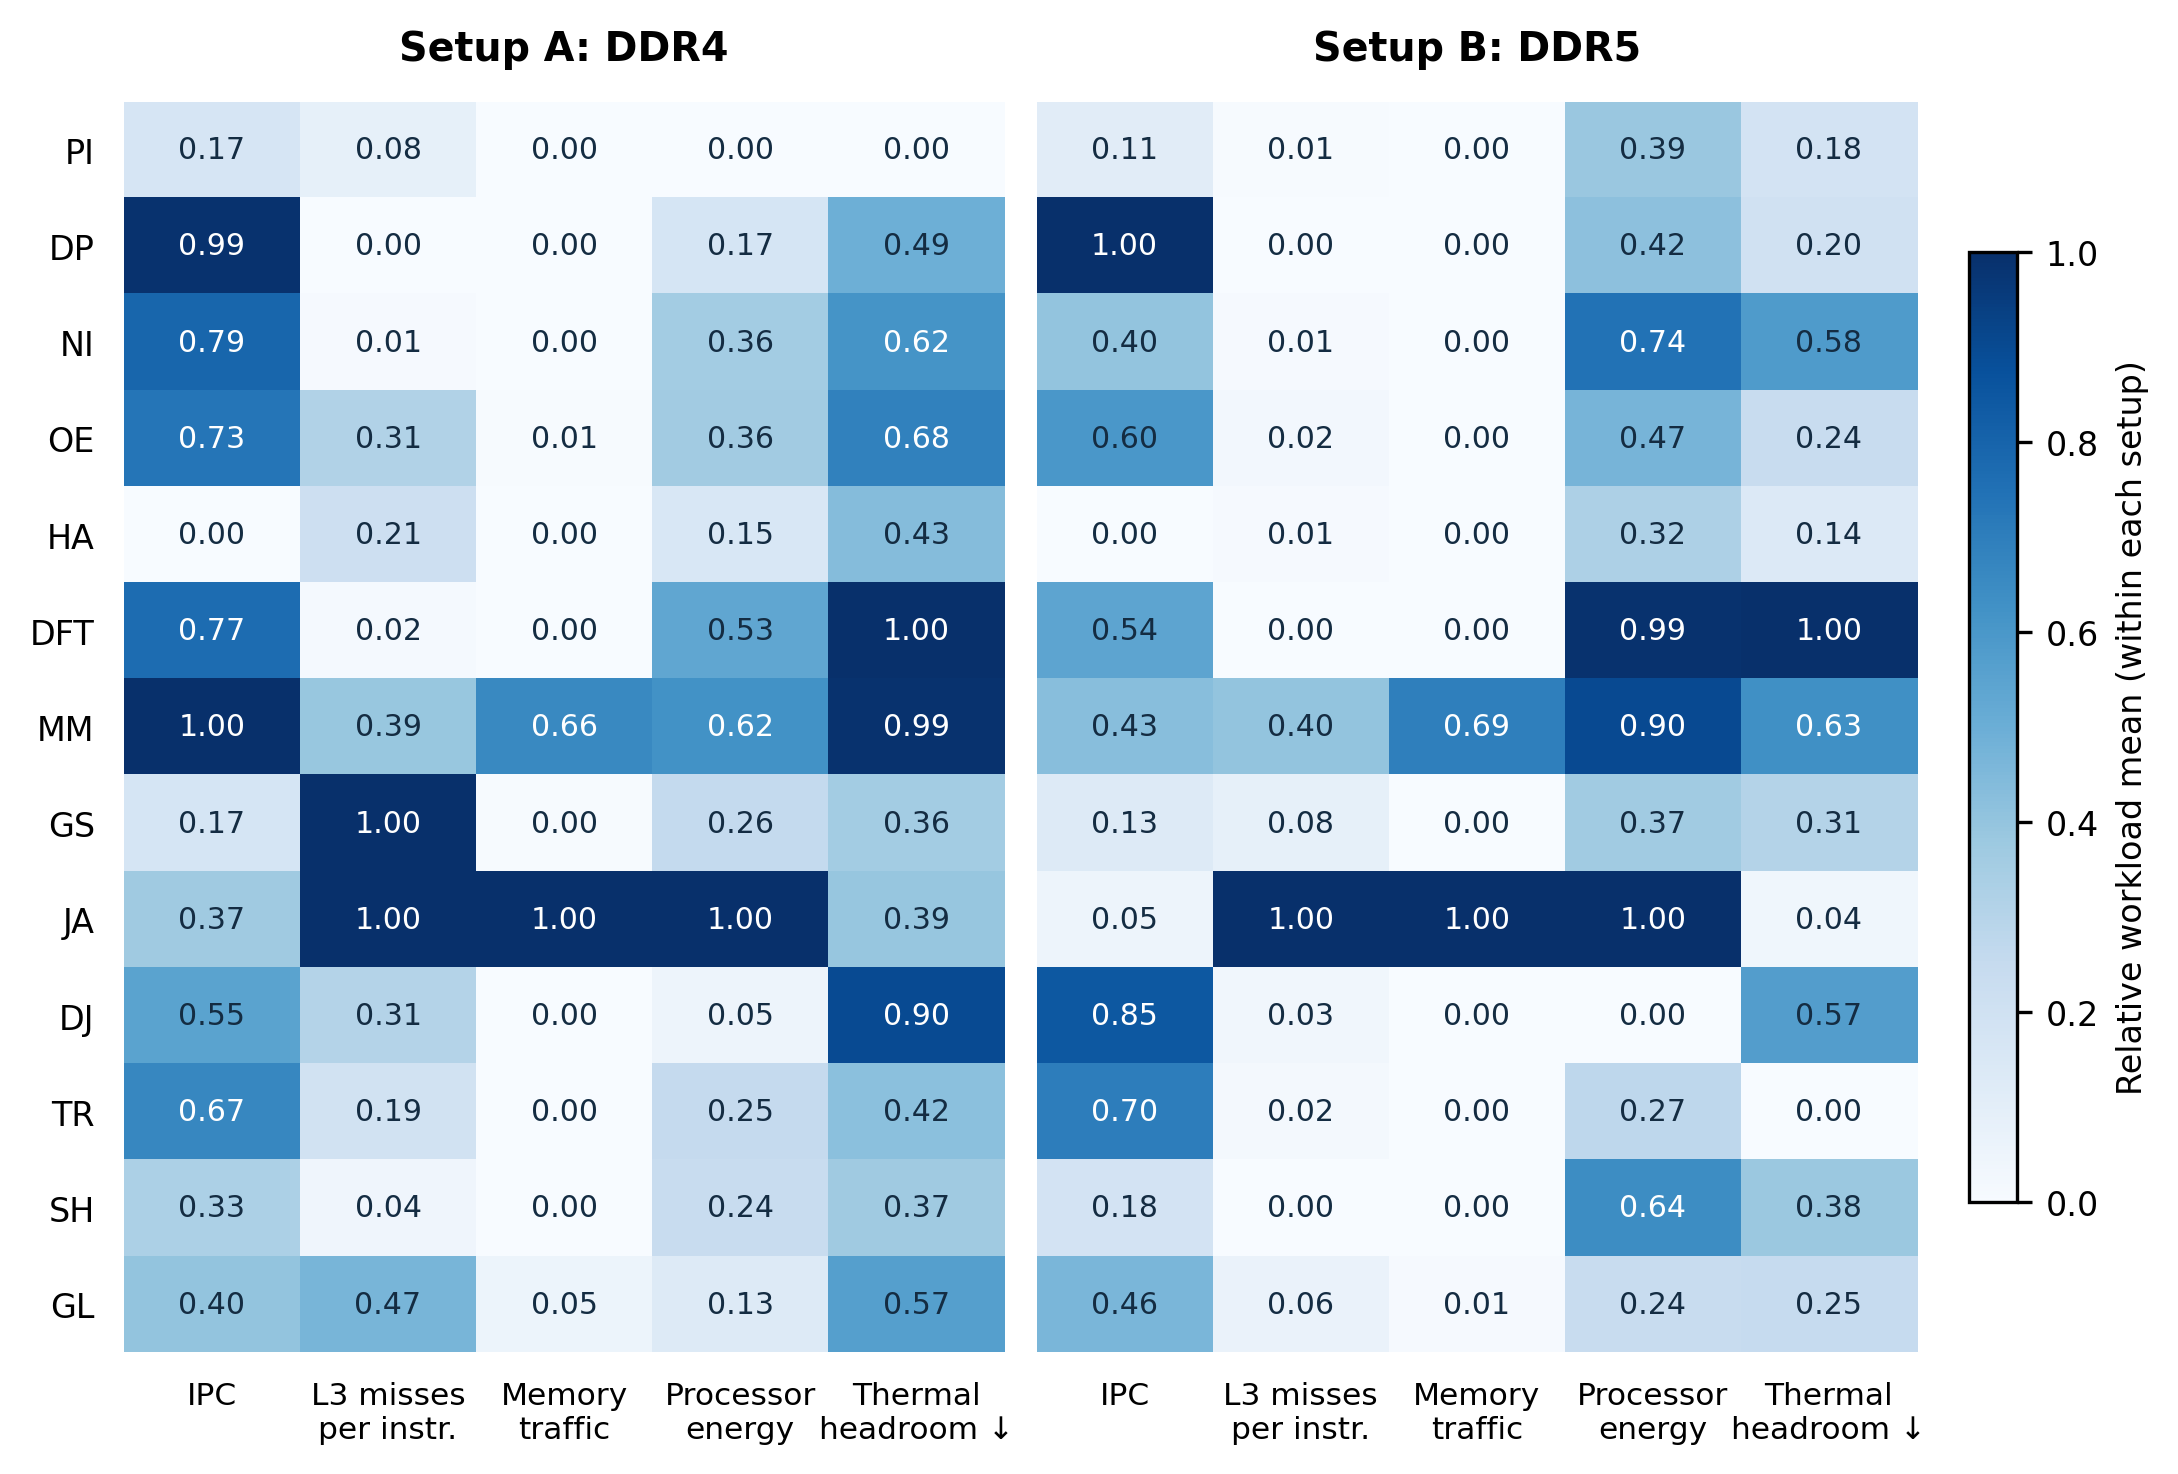

In [1]:
# Benign workload profiles: safe to run alone in a fresh kernel.
# Uses the preserved benign DDR4/DDR5 CSVs, independently of DATA_MODE and DSE.
from pathlib import Path as _WorkloadPath
import hashlib as _workload_hashlib
import json as _workload_json
from IPython.display import Image as _WorkloadImage, display as _workload_display

_workload_start = _WorkloadPath.cwd().resolve()
_workload_repo = next((p for p in (_workload_start, *_workload_start.parents)
                       if (p / "notebooks/exact_tcad_all_experiments.ipynb").is_file()
                       and (p / "data/telemetry/processed/ddr_data").is_dir()), None)
if _workload_repo is None:
    raise RuntimeError("Open this notebook from the CITADEL repository or its notebooks folder.")

WORKLOAD_PROFILE_DATA_ROOT = _workload_repo / "data/telemetry/processed/ddr_data"
WORKLOAD_PROFILE_OUT = _workload_repo / "results/notebook_run/workload_profiles"
WORKLOAD_PROFILE_PNG_DPI = 300

def _citadel_workload_profiles(data_root, output, png_dpi, cell_sha256):
    import hashlib
    import json
    import platform
    import re
    from pathlib import Path

    import matplotlib
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    SOURCE_COMMIT = "520304689601ab62b53da9ac8420e22cefe20dcb"
    PAMPAR_COMMIT = "568430be779f5bf1d0bfddca35bc796adc215262"
    ORDER = ["PI", "DP", "NI", "OE", "HA", "DFT", "MM", "GS", "JA", "DJ", "TR", "SH", "GL"]
    DOMAINS = ["CORE", "MEMORY", "ENERGY", "VOLTAGE", "THERMAL"]
    WORKLOADS = [
        ("PI", "Pi calculation", "Microbenchmark", "Arithmetic and reduction"),
        ("DP", "Dot product", "Microbenchmark", "Generated operands and reduction"),
        ("NI", "Numerical integration", "Microbenchmark", "Arithmetic and reduction"),
        ("OE", "Odd-even sort", "Kernel", "Array comparisons and synchronization"),
        ("HA", "Harmonic sums", "Kernel", "Arithmetic sums"),
        ("DFT", "Discrete Fourier transform", "Kernel", "Trigonometric arithmetic and array reuse"),
        ("MM", "Matrix multiplication", "Kernel", "Matrix arithmetic and array traffic"),
        ("GS", "Gram-Schmidt process", "Kernel", "Array updates and synchronization"),
        ("JA", "Jacobi method", "Kernel", "Repeated grid updates"),
        ("DJ", "Dijkstra shortest path", "Kernel", "Graph scans and conditional updates"),
        ("TR", "Turing ring", "Pseudo-application", "Grid simulation and neighbor updates"),
        ("SH", "Histogram similarity", "Pseudo-application", "Image windows and histogram comparisons"),
        ("GL", "Game of Life", "Pseudo-application", "Grid simulation and neighbor updates"),
    ]


    def classify(feature):
        """Explicit mapping for this dataset, not a physical coverage assertion."""
        lower = feature.lower()
        suffix = feature.rsplit("_", 1)[-1]
        if "time(ticks)" in lower:
            return "EXCLUDED", "time_ticks", "Timing field; not evidence of component activity"
        if feature == "CPU Voltage":
            return "VOLTAGE", "voltage", "Recorded voltage channel; acquisition needs historical provenance"
        if lower.startswith("temp_acpi") or lower.startswith("temp_pci"):
            return "AUXILIARY", "aux_temperature", "Device identity unconfirmed; excluded from primary domain summary"
        if lower.startswith("temp_core"):
            return "AUXILIARY", "reported_core_temperature", "Historical temperature helper unavailable; excluded from domain summary"
        if suffix == "TEMP":
            return "THERMAL", "thermal_headroom", "PCM thermal headroom; lower means closer to TjMax"
        if "energy" in lower or "joules" in lower:
            return "ENERGY", "energy", "Recorded energy per observation; not power without measured interval"
        if re.fullmatch(r"L[123](MISS|HIT|MPI)", suffix):
            return "MEMORY", suffix, "PCM cache event or ratio"
        if suffix in {"READ", "WRITE"}:
            return "MEMORY", suffix, "PCM main-memory traffic per observation; not bandwidth"
        if suffix in {"IO", "IA", "GT"}:
            return "AUXILIARY", suffix, "Memory request origin; not proof of I/O or GPU test coverage"
        if re.fullmatch(r"C\d+res%", suffix):
            return "CORE", suffix, "PCM core or package residency"
        if suffix in {"EXEC", "IPC", "FREQ", "AFREQ", "CFREQ", "INST", "ACYC", "PhysIPC", "PhysIPC%", "INSTnom", "INSTnom%"}:
            return "CORE", suffix, "PCM execution or frequency quantity"
        return "UNMAPPED", suffix, "No domain assigned; needs manual review"


    def sha256(path):
        h = hashlib.sha256()
        with open(path, "rb") as stream:
            for chunk in iter(lambda: stream.read(1024 * 1024), b""):
                h.update(chunk)
        return h.hexdigest()


    def profiles(df):
        # Exactly one system/package channel per indicator avoids counting copies.
        headroom = next(c for c in df if c.startswith("Socket 0") and c.endswith("_TEMP"))
        return {
            "core_c0_pct": (df["System Core C-States_C0res%"], "% as recorded"),
            "ipc": (df["System.3_IPC"], "instructions/cycle"),
            "l3_misses_per_instruction": (df["System.11_L3MPI"], "misses/instruction"),
            "memory_traffic_gb_per_observation": (df["System.13_READ"] + df["System.14_WRITE"], "GB/observation"),
            "processor_energy_j_per_observation": (df["System.22_Proc Energy (Joules)"], "J/observation"),
            "cpu_voltage_v": (df["CPU Voltage"], "V as recorded"),
            "thermal_headroom": (df[headroom], "degrees below TjMax"),
        }


    def main():
        from types import SimpleNamespace
        args = SimpleNamespace(data_root=Path(data_root), output=Path(output))
        args.output.mkdir(parents=True, exist_ok=True)
        rows, quality, indicator_rows, metadata, domain_rows = [], [], [], [], []
        manifest_inputs = []

        for setup, prefix in [("A", "DDR4"), ("B", "DDR5")]:
            files = {p.stem.split("_")[-1].upper(): p for p in args.data_root.glob(prefix + "_benign_*.csv")}
            if set(files) != set(ORDER):
                raise ValueError(f"{setup}: expected the 13 workload files; got {sorted(files)}")
            schema = None
            hashes = {}
            setup_rows = []
            for workload in ORDER:
                path = files[workload]
                with path.open("rb") as stream:
                    if stream.read(100).startswith(b"version https://git-lfs"):
                        raise ValueError(f"Git LFS pointer instead of data: {path}")
                df = pd.read_csv(path)
                df.columns = df.columns.str.strip()
                df = df.loc[:, ~df.columns.str.startswith("Unnamed:")]
                if schema is None:
                    schema = df.columns.tolist()
                    hashes = {c: hashlib.sha256() for c in schema}
                if df.columns.tolist() != schema:
                    raise ValueError(f"Header mismatch: {path.name}")
                arr = df.apply(pd.to_numeric, errors="raise").to_numpy(dtype=float)
                missing = int(np.isnan(arr).sum())
                infinite = int(np.isinf(arr).sum())
                arr[~np.isfinite(arr)] = np.nan
                df = pd.DataFrame(arr, columns=schema)
                c0 = df["System Core C-States_C0res%"]
                quality.append(dict(setup=setup, workload=workload, file=path.name, rows=len(df),
                                    telemetry_columns=len(schema), missing=missing, infinite=infinite,
                                    core_c0_above_100=int((c0 > 100).sum()),
                                    core_c0_max=float(c0.max()), trial_identifier_present=False,
                                    wall_clock_timestamp_present=False))
                manifest_inputs.append(dict(file=path.name, sha256=sha256(path), rows=len(df)))
                for feature in schema:
                    a = df[feature].to_numpy()
                    hashes[feature].update(np.asarray(a, dtype="<f8").tobytes())
                    domain, family, note = classify(feature)
                    finite = a[np.isfinite(a)]
                    if not len(finite):
                        raise ValueError(f"No finite values: {path.name} {feature}")
                    record = dict(setup=setup, workload=workload, feature=feature, domain=domain,
                                  family=family, finite_count=len(finite), mean=float(finite.mean()),
                                  variance=float(finite.var(ddof=0)), minimum=float(finite.min()),
                                  maximum=float(finite.max()), unique_values=int(pd.Series(finite).nunique()))
                    setup_rows.append(record)
                for name, (series, unit) in profiles(df).items():
                    values = series.dropna().to_numpy()
                    indicator_rows.append(dict(setup=setup, workload=workload, indicator=name, unit=unit,
                                               mean=float(values.mean()), sd=float(values.std(ddof=0)),
                                               p05=float(np.quantile(values, .05)),
                                               median=float(np.median(values)), p95=float(np.quantile(values, .95))))
                print(f"Read {path.name}: {len(df)} rows, {len(schema)} telemetry columns", flush=True)

            stats = pd.DataFrame(setup_rows)
            representatives = {}
            for feature in schema:
                sub = stats[stats.feature == feature]
                # Equal workload weighting. Does not imply equal independent run counts.
                pooled_mean = float(sub["mean"].mean())
                pooled_var = float(sub.variance.mean() + sub["mean"].var(ddof=0))
                value_range = float(sub.maximum.max() - sub.minimum.min())
                tol = 1e-12 * max(1., abs(float(sub.minimum.min())), abs(float(sub.maximum.max())))
                constant = value_range <= tol
                domain, family, note = classify(feature)
                digest = hashes[feature].hexdigest()
                # Deduplicate exact copies only within the same semantic family/domain.
                key = (domain, family, digest)
                duplicate_of = representatives.get(key, "")
                if not duplicate_of:
                    representatives[key] = feature
                eligible = not constant and not duplicate_of and domain in DOMAINS
                metadata.append(dict(setup=setup, feature=feature, domain=domain, family=family,
                                     pooled_mean=pooled_mean, pooled_variance=pooled_var,
                                     constant_across_suite=constant, duplicate_of=duplicate_of,
                                     included_in_domain_summary=eligible, note=note))
                mask = stats.feature == feature
                stats.loc[mask, "eligible"] = eligible
                stats.loc[mask, "variance_ratio"] = sub.variance / pooled_var if not constant else np.nan
                stats.loc[mask, "standardized_mean"] = (sub["mean"] - pooled_mean) / np.sqrt(pooled_var) if not constant else np.nan
            rows.extend(stats.to_dict("records"))
            for workload in ORDER:
                for domain in DOMAINS:
                    sub = stats[(stats.workload == workload) & (stats.domain == domain) & (stats.eligible == True)]
                    # Families first, then domains: repeated core channels do not
                    # give a metric family more weight than another family.
                    by_family = sub.groupby("family").agg(variance_ratio=("variance_ratio", "mean"))
                    varying = (sub.maximum - sub.minimum) > 1e-12 * np.maximum(1., np.maximum(abs(sub.minimum), abs(sub.maximum)))
                    domain_rows.append(dict(setup=setup, workload=workload, domain=domain,
                                            eligible_channels=len(sub), metric_families=len(by_family),
                                            varying_channels=int(varying.sum()),
                                            normalized_variance=float(by_family.variance_ratio.mean()),
                                            provenance_caveat="Historical voltage acquisition unverified" if domain == "VOLTAGE" else "Historical PCM binary version unrecorded"))

        features = pd.DataFrame(rows)
        meta = pd.DataFrame(metadata)
        domains = pd.DataFrame(domain_rows)
        indicators = pd.DataFrame(indicator_rows)
        for (setup, name), idx in indicators.groupby(["setup", "indicator"]).groups.items():
            values = indicators.loc[idx, "mean"]
            oriented = -values if name == "thermal_headroom" else values
            span = float(oriented.max() - oriented.min())
            indicators.loc[idx, "relative_mean_level"] = (oriented - oriented.min()) / span if span > 0 else np.nan
        assert np.isfinite(indicators.relative_mean_level).all()
        assert indicators.relative_mean_level.between(0, 1).all()
        assert not (meta.domain == "UNMAPPED").any(), "Review unmapped features before publication"

        outputs = {
            "input_quality.csv": pd.DataFrame(quality),
            "feature_metadata.csv": meta,
            "feature_statistics.csv": features,
            "domain_variance.csv": domains,
            "workload_profiles.csv": indicators,
        }
        for filename, table in outputs.items():
            table.to_csv(args.output / filename, index=False, float_format="%.10g")
        rationale = pd.DataFrame(WORKLOADS, columns=["workload", "name", "suite_class", "computational_pattern"])
        rationale["source_url"] = f"https://github.com/adrianomg/PAMPAR/tree/{PAMPAR_COMMIT}"
        rationale["interpretation"] = "Pattern inferred from public descriptions/source; not a recovered stress design target"
        rationale.to_csv(args.output / "workload_rationale.csv", index=False)

        plt.rcParams.update({"font.size": 8, "pdf.fonttype": 42, "ps.fonttype": 42})
        # Keep the publication figure to interpretable PCM indicators. The CSV
        # retains C0 and voltage for inspection, but C0 has values above 100 in A
        # and the historical voltage acquisition helper is unavailable.
        names = ["ipc", "l3_misses_per_instruction", "memory_traffic_gb_per_observation",
                 "processor_energy_j_per_observation", "thermal_headroom"]
        labels = ["IPC", "L3 misses\nper instr.", "Memory\ntraffic", "Processor\nenergy", "Thermal\nheadroom ↓"]
        fig, axes = plt.subplots(1, 2, figsize=(7.15, 4.8), layout="constrained", sharey=True)
        for setup, ax in zip(["A", "B"], axes):
            matrix = indicators[indicators.setup == setup].pivot(index="workload", columns="indicator", values="relative_mean_level").reindex(index=ORDER, columns=names)
            im = ax.imshow(matrix.to_numpy(), vmin=0, vmax=1, cmap="Blues", aspect="auto")
            ax.set_title(f"Setup {setup}: {'DDR4' if setup == 'A' else 'DDR5'}", weight="bold", pad=10, fontsize=9.5)
            ax.set_xticks(range(len(names)), labels, fontsize=7.5)
            ax.set_yticks(range(len(ORDER)), ORDER, fontsize=8)
            ax.tick_params(axis="both", length=0, pad=7)
            for (i, j), value in np.ndenumerate(matrix.to_numpy()):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=7.2,
                        color="white" if value > .6 else "#142c42")
            for spine in ax.spines.values():
                spine.set_visible(False)
        cb = fig.colorbar(im, ax=axes, location="right", shrink=.76, pad=.025)
        cb.set_label("Relative workload mean (within each setup)")
        fig.savefig(args.output / "workload_profiles.pdf", bbox_inches="tight")
        fig.savefig(args.output / "workload_profiles.png", dpi=png_dpi, bbox_inches="tight")
        plt.close(fig)

        manifest = dict(repository="https://github.com/ping830616/CITADEL", reference_data_commit=SOURCE_COMMIT,
                        pampar_source_review_commit=PAMPAR_COMMIT,
                        historical_pampar_commit="unknown", data_kind="preserved processed benign CSVs",
                        python=platform.python_version(), numpy=np.__version__, pandas=pd.__version__,
                        matplotlib=matplotlib.__version__, inputs=manifest_inputs,
                        analysis_cell_sha256=cell_sha256,
                        analysis_location="notebooks/exact_tcad_all_experiments.ipynb: Benign workload profiles",
                        normalization="Separate setup; equal workload weights; population variance; no imputation",
                        detector_changes=False, independent_run_inference=False)
        manifest["png_dpi"] = png_dpi
        manifest["outputs"] = {p.name: sha256(p) for p in sorted(args.output.iterdir()) if p.is_file() and p.name != "manifest.json"}
        (args.output / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
        print("Analysis complete. No detector settings or source measurements were changed.", flush=True)


    with plt.rc_context():
        main()


_workload_notebook = _workload_json.loads(
    (_workload_repo / "notebooks/exact_tcad_all_experiments.ipynb").read_text(encoding="utf-8"))
_workload_source = next("".join(c["source"]) for c in _workload_notebook["cells"]
                        if "citadel-workload-profile-analysis" in c.get("metadata", {}).get("tags", []))
_citadel_workload_profiles(
    WORKLOAD_PROFILE_DATA_ROOT, WORKLOAD_PROFILE_OUT, WORKLOAD_PROFILE_PNG_DPI,
    _workload_hashlib.sha256(_workload_source.encode("utf-8")).hexdigest())

def _show_workload_profile_outputs():
    import pandas as pd
    quality = pd.read_csv(WORKLOAD_PROFILE_OUT / "input_quality.csv")
    print(f"Analyzed {int(quality.rows.sum()):,} observations in {len(quality)} benign files.")
    _workload_display(quality.groupby("setup").agg(
        workloads=("workload", "count"), observations=("rows", "sum"),
        telemetry_columns=("telemetry_columns", "first"), missing=("missing", "sum"),
        infinite=("infinite", "sum"), c0_above_100=("core_c0_above_100", "sum")))
    _workload_display(_WorkloadImage(filename=str(WORKLOAD_PROFILE_OUT / "workload_profiles.png")))
    print("Saved PNG (300 dpi), vector PDF, statistics, quality audit, and input/output hashes:")
    print(WORKLOAD_PROFILE_OUT.relative_to(_workload_repo))
    print("Figure colors show relative workload means, not inactivity or component saturation.")

_show_workload_profile_outputs()


### Methodology Roadmap: CITADEL From Start To Finish

This notebook is the executable methodology for the TCAD paper. The flow below keeps the paper story aligned with reproducible artifacts: CITADEL learns from benign telemetry, builds a stable conditional telemetry map, chooses compact edge features, freezes deployable CINTAS settings through hardware-aware DSE, tests the selected settings across workloads, and then connects the same settings to fixed-point/RTL/FPGA evidence.

#### End-to-End Research Flow

| Step | Notebook section | Input | Action | Main artifact | Why it matters for edge SLM |
|---:|---|---|---|---|---|
| 1 | Reproducibility Configuration | repo paths, seed, thread count | fix deterministic environment | `notebook_progress.log` | makes results comparable across laptop/server |
| 2 | Prepare Data | DDR4/DDR5 telemetry CSVs | materialize data, sanitize columns, verify schema | data hashes and schema checks | prevents silent data drift or Git LFS mistakes |
| 3 | Paper-Scale DSE | benign + anomaly telemetry | learn stable graph, rank features, sweep CINTAS settings | `tcad_ablation_summary.csv` | selects deployable settings, not just offline scores |
| 4 | DROOP-Adaptive Branch | BENIGN/DROOP telemetry | add transient-aware features and merge into one DSE summary | integrated DROOP rows | improves short voltage-transient observability |
| 5 | Selected-Setting Workload Sweep | DSE fold results | freeze one best setting per setup/scenario and test across workloads | `section4_selected_setting_workload_summary.csv` | mirrors real deployment with one fixed configuration |
| 6 | Detection Quality | integrated DSE summary | report AUROC, AUPRC, F1, balanced accuracy, MCC, FPR | anomaly-class tables | shows separation and operating-point behavior |
| 7 | Feature-Budget Trade-Off | DSE summary | compare $k$, telemetry bandwidth, area, power, latency | budget figures/tables | quantifies the cost of observability |
| 8 | Stable Conditional Graph | benign graph/rank files | show topology, top features, and score alignment | graph PNGs/rank CSVs | gives interpretable telemetry structure |
| 9 | Fixed-Point CINTAS | sweep rows and quantized scores | compare floating-point and fixed-point CINTAS | fixed-point sensitivity CSVs | supports compact edge arithmetic |
| 10 | Hardware Cost | selected feature budgets | estimate operator count, area, power, latency | hardware-cost summary | links analytics to silicon cost |
| 11 | Lifecycle Drift | later benign windows | check stale references and recalibration | drift/recalibration CSVs | supports long-lived field deployment |
| 12 | TCAD Results Gallery | all saved summaries | display five tables and six figures inline | `paper_figures/` gallery | provides the paper-ready result set |
| 13 | RTL/FPGA Hooks | selected CINTAS settings | export golden vectors and merge Vivado results | `fpga/`, `rtl_sweep/` | turns the method into hardware evidence |
| 14 | Apple Supplement | Apple host-visible telemetry | evaluate limited-observability portability separately | Apple supplemental artifacts | studies observability limits without hardware-cost claims |

#### Practical Edge-SLM Contract

CITADEL is stronger than a pure analytics notebook because each selected result must satisfy a deployment contract:

1. **Benign-only calibration:** anomaly labels are not used to train the deployed reference.
2. **Stable feature set:** selected telemetry channels come from graph stability and score alignment, not only per-anomaly responsiveness.
3. **Hardware-aware operating point:** the chosen row includes feature budget, block length, aggregation, weighting, threshold, and fixed-point precision.
4. **Selected-setting workload robustness:** after DSE chooses one setup/scenario setting, that same setting is evaluated across workloads.
5. **Fixed-point readiness:** score error is measured after quantization.
6. **Silicon-cost visibility:** area, power, latency, and bandwidth are attached to every selected row.
7. **Lifecycle validity:** the notebook checks when a benign reference becomes stale and whether threshold/full recalibration helps.
8. **RTL/FPGA handoff:** selected CINTAS settings are exported for Vivado, then merged back into the final paper tables.

#### Method Upgrade From EXACT To CITADEL

| Axis | EXACT | CITADEL |
|---|---|---|
| Telemetry map | $G_{\mathcal{B}}$ from benign causal/dependency learning | $G_{\mathcal{B}}=(V,E,D,\Pi)$ with strength $D$ and stability $\Pi$ |
| Feature compass | Compact causal top-$k$ features | $r_f=(lpha_c c_f+lpha_e e_f+lpha_d d_f+lpha_a a_f)/(\kappa_f+\epsilon)$ |
| Budget knob | One compact operating point | $k\in\mathcal{K}$ swept for accuracy--bandwidth trade-off |
| Score engine | CINTAS edge score $s(t)$ | $s(t)=(1-\lambda)E_2(t)+\lambda E_1(t)$, $\lambda\in\Lambda$ |
| Time lens | Selected decision windows | $N\in\mathcal{N}$, $\Phi\in\{\max,\mathrm{mean},\mathrm{median}\}$ |
| Workload view | Main accuracy summary | one selected setting tested across workloads |
| Number system | Fixed-point deployment path | $Q\in\mathcal{Q}$ with $\Delta_{\mathrm{MAE}}$ and $\Delta_{\max}$ |
| Silicon view | Compact detector motivation | $A_{\mathrm{CINTAS}}$, $P_{\mathrm{CINTAS}}$, latency, bandwidth, RTL/FPGA |
| Lifecycle mode | Frozen benign reference | $\operatorname{FPR}_r>\eta$ triggers threshold/full recalibration |
| Run contract | Portable code and results | single notebook, manifests, hashes, deterministic seed/thread settings |

CITADEL keeps edge CINTAS scoring but upgrades the workflow to stable conditional graph learning, hardware-aware ranking, paper-scale design-space exploration, selected-setting workload robustness, fixed-point sensitivity, lifecycle recalibration, and RTL/FPGA-oriented validation.


### Overleaf-Ready Upgrade Table

Use this compact table near the end of the Introduction or at the start of the Proposed Method section.

```latex
\begin{table*}[!t]
\centering
\caption{From EXACT to CITADEL: upgrading edge telemetry scoring into a hardware-aware SLM workflow.}
\label{tab:exact_to_citadel_upgrade}

\vspace{0.5mm}
\footnotesize
\setlength{\tabcolsep}{4.2pt}
\renewcommand{\arraystretch}{1.08}

\begin{tabularx}{0.97\textwidth}{@{}p{0.16\textwidth}XX@{}}
\toprule
\textbf{Axis} &
\textbf{EXACT} &
\textbf{CITADEL} \\
\midrule

Telemetry map &
$G_{\mathcal{B}}$ from benign causal/dependency learning &
$G_{\mathcal{B}}=(V,E,D,\Pi)$: strength $D$ plus stability $\Pi$ \\

Feature compass &
Compact causal top-$k$ features &
$r_f=(\alpha_c c_f+\alpha_e e_f+\alpha_d d_f+\alpha_a a_f)/(\kappa_f+\epsilon)$ \\

Budget knob &
One compact operating point &
$k\in\mathcal{K}$ swept for accuracy--bandwidth trade-off \\

Score engine &
CINTAS edge score $s(t)$ &
$s(t)=(1-\lambda)E_2(t)+\lambda E_1(t)$, $\lambda\in\Lambda$ \\

Time lens &
Selected decision windows &
$N\in\mathcal{N}$, $\Phi\in\{\max,\mathrm{mean},\mathrm{median}\}$ \\

Number system &
Fixed-point deployment path &
$Q\in\mathcal{Q}$ with $\Delta_{\mathrm{MAE}}$ and $\Delta_{\max}$ \\

Silicon view &
Compact detector motivation &
$A_{\mathrm{CINTAS}}$, $P_{\mathrm{CINTAS}}$, latency, bandwidth, RTL/FPGA \\

Lifecycle mode &
Frozen benign reference &
$\operatorname{FPR}_r>\eta$ triggers threshold/full recalibration \\

Run contract &
Portable code and results &
Single notebook, manifests, hashes, deterministic seed/thread settings \\

\bottomrule
\end{tabularx}

\vspace{0.6mm}
\begin{minipage}{0.92\textwidth}
\scriptsize
CITADEL keeps edge CINTAS scoring but adds stable conditional graph learning, selected-setting workload robustness, hardware-aware DSE, fixed-point sensitivity, lifecycle recalibration, and RTL/FPGA hooks.
\end{minipage}

\vspace{-0.5mm}
\end{table*}
```


## 4. Paper-Scale Design-Space Sweep

This section runs the paper-scale CITADEL design-space sweep used by the TCAD results. The standard CINTAS branch evaluates non-DROOP anomaly classes, while the DROOP branch uses transient-aware telemetry features inside the same DSE workflow. DROOP is therefore integrated into the DSE rather than treated as a separate paper story.

The output of this section is the central experiment table:

`results/notebook_run/tcad_ablation/tcad_ablation_summary.csv`

Each row is a deployable candidate with feature budget `top_k`, block length `window_size`, aggregation mode, score mixture `lambda_res`, weight mode, fixed-point precision, detection metrics, false-positive rate, fixed-point error, and estimated hardware cost. For paper-scale results, use `TCAD_PRESET = "balanced"` in the reproducibility configuration. Use `TCAD_PRESET = "full"` only for optional exhaustive sensitivity runs on ASU/Linux. After this section finishes once, downstream result-display cells can be rerun quickly from the saved CSV files.


In [5]:
cfg_path = REPO_ROOT / "configs" / f"tcad_grid_{TCAD_PRESET}.json"

expected_progress_rev = "2026-05-08-safe-cv-dashboard"
if globals().get("CITADEL_NOTEBOOK_PROGRESS_REV") != expected_progress_rev:
    raise RuntimeError(
        "This kernel is using an older notebook helper cell. "
        "Restart the Jupyter kernel, pull the latest GitHub repo, then run the notebook from the top. "
        f"Expected progress revision: {expected_progress_rev}; loaded: {globals().get('CITADEL_NOTEBOOK_PROGRESS_REV')}"
    )

required_progress_helpers = ("progress_start", "progress_update", "progress_should_log")
missing_progress_helpers = [name for name in required_progress_helpers if name not in globals()]
if missing_progress_helpers:
    raise RuntimeError(
        "Progress-enabled helper functions are not loaded in this kernel. "
        "Restart the Jupyter kernel, pull the latest GitHub repo, then run the notebook from the top. "
        f"Missing helpers: {missing_progress_helpers}"
    )

progress_notice = (
    "TCAD progress is enabled. A live progress card and timestamped [TCAD ablation] lines "
    "should appear below before the long sweep starts."
)
print(progress_notice)
try:
    display(Markdown(f"**{progress_notice}**"))
except Exception:
    pass

tcad_cell_progress = progress_start("TCAD notebook cell", f"preset={TCAD_PRESET} config={cfg_path.relative_to(REPO_ROOT)}")
tcad_cfg = notebook_tcad_config(TCAD_PRESET, config_path=cfg_path, seed=SEED)
DROOP_ADAPTIVE_INCLUDED_IN_DSE = True
standard_scenarios = tuple(
    s for s in tcad_cfg.scenarios_eval
    if not (DROOP_ADAPTIVE_INCLUDED_IN_DSE and str(s).upper() == "DROOP")
)
tcad_run_cfg = TCAD2026Config(**{**asdict(tcad_cfg), "scenarios_eval": standard_scenarios})

print(f"TCAD config: {cfg_path.relative_to(REPO_ROOT)}")
print(f"Standard DSE scenarios: {tcad_run_cfg.scenarios_eval}")
if DROOP_ADAPTIVE_INCLUDED_IN_DSE and any(str(s).upper() == "DROOP" for s in tcad_cfg.scenarios_eval):
    print("DROOP standard branch is skipped here and evaluated by the integrated DROOP-adaptive branch below.")

progress_update(
    "TCAD notebook cell",
    "calling standard DSE helper",
    start=tcad_cell_progress,
    detail=f"scenarios={tcad_run_cfg.scenarios_eval}",
)

if tcad_run_cfg.scenarios_eval:
    tcad_artifacts = notebook_run_tcad_ablation(
        data_root=DATA_ROOT,
        out_root=TCAD_OUT,
        cfg=tcad_run_cfg,
        seed=SEED,
        threads=THREADS,
    )
    summary_standard = tcad_artifacts["summary"].copy()
    summary_standard = summary_standard[summary_standard["scenario"].astype(str).str.upper() != "DROOP"].copy()
    summary_standard["sweep_source"] = "standard_dse"
    standard_summary_path = TCAD_OUT / "tcad_ablation_standard_summary.csv"
    summary_standard.to_csv(standard_summary_path, index=False)

    standard_fold_results = tcad_artifacts.get("fold_results", pd.DataFrame()).copy()
    if not standard_fold_results.empty:
        standard_fold_results = standard_fold_results[standard_fold_results["scenario"].astype(str).str.upper() != "DROOP"].copy()
        standard_fold_results["sweep_source"] = "standard_dse"
        standard_fold_path = TCAD_OUT / "tcad_ablation_standard_fold_results.csv"
        standard_fold_results.to_csv(standard_fold_path, index=False)
        tcad_artifacts["fold_results"] = standard_fold_results
    else:
        standard_fold_path = None

    summary = summary_standard.copy()
    print(f"Standard DSE summary: {standard_summary_path.relative_to(REPO_ROOT)}")
    print(f"TCAD manifest: {tcad_artifacts['manifest_path'].relative_to(REPO_ROOT)}")
else:
    summary_standard = pd.DataFrame()
    standard_fold_results = pd.DataFrame()
    tcad_artifacts = {
        "summary": summary_standard,
        "fold_results": standard_fold_results,
        "summary_path": TCAD_OUT / "tcad_ablation_summary.csv",
        "fold_path": TCAD_OUT / "tcad_ablation_fold_results.csv",
    }
    summary = summary_standard.copy()
    print("No non-DROOP standard DSE scenarios were requested; only the DROOP-adaptive branch will run.")

progress_update(
    "TCAD notebook cell",
    "standard DSE branch complete",
    start=tcad_cell_progress,
    current=1,
    total=2 if DROOP_ADAPTIVE_INCLUDED_IN_DSE else 1,
    detail="DROOP adaptive branch follows" if DROOP_ADAPTIVE_INCLUDED_IN_DSE else "DONE",
)
display(summary.head(10))


TCAD progress is enabled. A live progress card and timestamped [TCAD ablation] lines should appear below before the long sweep starts.


**TCAD progress is enabled. A live progress card and timestamped [TCAD ablation] lines should appear below before the long sweep starts.**

[2026-06-11 14:13:14] | [TCAD notebook cell] | START | elapsed=0.0s | preset=full config=configs/tcad_grid_full.json
TCAD config: configs/tcad_grid_full.json
Standard DSE scenarios: ('RH', 'SPECTRE')
DROOP standard branch is skipped here and evaluated by the integrated DROOP-adaptive branch below.
[2026-06-11 14:13:14] | [TCAD notebook cell] | calling standard DSE helper | elapsed=0.0s | scenarios=('RH', 'SPECTRE')


[2026-06-11 14:13:14] | [TCAD ablation] | START | elapsed=0.0s | out=results/notebook_run/tcad_ablation configs=1800 scenarios=('RH', 'SPECTRE') windows=(50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 750, 800, 850, 900, 950, 1000)
[2026-06-11 14:13:14] | [TCAD ablation] | loading telemetry | elapsed=0.0s | data/telemetry/processed/ddr_data
[2026-06-11 14:13:30] | [TCAD ablation] | loaded telemetry | elapsed=15.9s | A rows=390,000, B rows=390,000
[2026-06-11 14:13:36] | [TCAD ablation] | shared features | elapsed=22.3s | count=136
[2026-06-11 14:13:36] | [TCAD ablation] | building feature ranks | elapsed=22.3s | Setup A
[2026-06-11 14:13:56] | [TCAD ablation] | building feature ranks | elapsed=41.8s | Setup B
[2026-06-11 14:14:25] | [TCAD ablation] | evaluating grid | 1/1800 (0.1%) | elapsed=71.3s | setup=A k=5 lambda=0.0 agg=max weight=uniform q=8
[2026-06-11 14:42:24] | [TCAD ablation] | evaluating grid | 90/1800 (5.0%) | elapsed=1749.7s | setup=A k=5 lambda=0.5

,setup,scenario,window_size,agg_mode,lambda_res,p_quantile,top_k,weight_mode,fixed_point_q,n_selected_features,...,hw_power_mw,hw_setup_b_area_overhead_pct,hw_idle_power_overhead_pct,hw_median_workload_power_overhead_pct,hw_add_count,hw_mult_count,hw_estimated_serial_cycles,hw_add_delay_ps,hw_mult_delay_ps,sweep_source
0,A,RH,50,max,0.0,0.99,5,inv_var,8,5,...,7.7772,0.030138,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse
1,A,RH,50,max,0.0,0.99,5,inv_var,10,5,...,7.7772,0.030138,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse
2,A,RH,50,max,0.0,0.99,5,inv_var,12,5,...,7.7772,0.030138,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse
3,A,RH,50,max,0.0,0.99,5,inv_var,15,5,...,7.7772,0.030138,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse
4,A,RH,50,max,0.0,0.99,5,inv_var,18,5,...,7.7772,0.030138,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse
5,A,RH,50,max,0.0,0.99,5,uniform,8,5,...,7.7772,0.030138,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse
6,A,RH,50,max,0.0,0.99,5,uniform,10,5,...,7.7772,0.030138,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse
7,A,RH,50,max,0.0,0.99,5,uniform,12,5,...,7.7772,0.030138,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse
8,A,RH,50,max,0.0,0.99,5,uniform,15,5,...,7.7772,0.030138,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse
9,A,RH,50,max,0.0,0.99,5,uniform,18,5,...,7.7772,0.030138,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse


**Integrated DROOP-adaptive branch.** This cell completes the paper-scale DSE by replacing the standard DROOP branch with transient-aware DROOP features, lower benign threshold quantiles, and a focused feature-budget range. It then merges DROOP-adaptive rows with the non-DROOP standard DSE rows so every downstream result section reads one integrated DSE summary.

The reason for this branch is practical: voltage droop can be short and transient, so the detector needs features such as first differences, rolling range, local standard deviation, drop-from-recent-maximum, and robust local deviation. The notebook keeps FPR visible so the selected operating point remains honest rather than simply maximizing recall.


[2026-06-12 05:16:18] | [DROOP-adaptive CINTAS] | START | elapsed=0.0s | windows=(50, 100, 200, 500, 1000)
[2026-06-12 05:16:18] | [DROOP-adaptive CINTAS] | building DROOP-only augmented telemetry | elapsed=0.0s
[2026-06-12 05:16:18] | [DROOP-adaptive CINTAS] | reusing cached augmented telemetry | 1/52 (1.9%) | elapsed=0.0s | DDR4_DROOP_dft.csv
[2026-06-12 05:16:18] | [DROOP-adaptive CINTAS] | reusing cached augmented telemetry | 2/52 (3.8%) | elapsed=0.0s | DDR4_DROOP_dj.csv
[2026-06-12 05:16:18] | [DROOP-adaptive CINTAS] | reusing cached augmented telemetry | 3/52 (5.8%) | elapsed=0.0s | DDR4_DROOP_dp.csv
[2026-06-12 05:16:18] | [DROOP-adaptive CINTAS] | reusing cached augmented telemetry | 4/52 (7.7%) | elapsed=0.0s | DDR4_DROOP_gl.csv
[2026-06-12 05:16:18] | [DROOP-adaptive CINTAS] | reusing cached augmented telemetry | 5/52 (9.6%) | elapsed=0.0s | DDR4_DROOP_gs.csv
[2026-06-12 05:16:18] | [DROOP-adaptive CINTAS] | reusing cached augmented telemetry | 6/52 (11.5%) | elapsed=0.0s | 

[2026-06-12 05:16:18] | [TCAD ablation] | START | elapsed=0.0s | out=results/notebook_run/droop_adaptive_ablation/p0_975 configs=180 scenarios=('DROOP',) windows=(50, 100, 200, 500, 1000)
[2026-06-12 05:16:18] | [TCAD ablation] | loading telemetry | elapsed=0.0s | results/notebook_run/droop_adaptive_data
[2026-06-12 05:16:39] | [TCAD ablation] | loaded telemetry | elapsed=21.0s | A rows=260,000, B rows=260,000
[2026-06-12 05:16:46] | [TCAD ablation] | shared features | elapsed=27.8s | count=328
[2026-06-12 05:16:46] | [TCAD ablation] | building feature ranks | elapsed=27.8s | Setup A
[2026-06-12 05:17:27] | [TCAD ablation] | building feature ranks | elapsed=68.3s | Setup B
[2026-06-12 05:18:14] | [TCAD ablation] | evaluating grid | 1/180 (0.6%) | elapsed=115.9s | setup=A k=15 lambda=0.0 agg=max weight=uniform q=15
[2026-06-12 05:18:50] | [TCAD ablation] | evaluating grid | 9/180 (5.0%) | elapsed=151.6s | setup=A k=15 lambda=0.25 agg=mean weight=uniform q=15
[2026-06-12 05:19:31] | [TCA

[2026-06-12 05:42:08] | [TCAD ablation] | START | elapsed=0.0s | out=results/notebook_run/droop_adaptive_ablation/p0_99 configs=180 scenarios=('DROOP',) windows=(50, 100, 200, 500, 1000)
[2026-06-12 05:42:08] | [TCAD ablation] | loading telemetry | elapsed=0.0s | results/notebook_run/droop_adaptive_data
[2026-06-12 05:42:26] | [TCAD ablation] | loaded telemetry | elapsed=17.3s | A rows=260,000, B rows=260,000
[2026-06-12 05:42:35] | [TCAD ablation] | shared features | elapsed=26.8s | count=328
[2026-06-12 05:42:35] | [TCAD ablation] | building feature ranks | elapsed=26.8s | Setup A
[2026-06-12 05:43:16] | [TCAD ablation] | building feature ranks | elapsed=68.2s | Setup B
[2026-06-12 05:44:07] | [TCAD ablation] | evaluating grid | 1/180 (0.6%) | elapsed=119.1s | setup=A k=15 lambda=0.0 agg=max weight=uniform q=15
[2026-06-12 05:44:44] | [TCAD ablation] | evaluating grid | 9/180 (5.0%) | elapsed=155.6s | setup=A k=15 lambda=0.25 agg=mean weight=uniform q=15
[2026-06-12 05:45:24] | [TCAD

,setup,scenario,droop_adaptive_p_quantile,top_k,n_selected_features,window_size,agg_mode,lambda_res,weight_mode,fixed_point_q,...,f1,bal_acc,mcc,fpr,brier,ece,fp_mae,fp_max_abs,hw_setup_b_area_overhead_pct,hw_idle_power_overhead_pct
0,A,DROOP,0.99,15,15,1000,median,0.0,inv_var,15,...,0.996255,0.996124,0.992420,0.007752,0.109802,0.215913,0.000046,0.000259,0.082535,0.060426
1,B,DROOP,0.99,15,15,200,median,0.5,inv_var,15,...,0.995416,0.995392,0.990815,0.007680,0.098596,0.215973,0.000388,0.004886,0.082535,0.060426


### Integrated DSE preview: standard non-DROOP + adaptive DROOP

,setup,scenario,window_size,agg_mode,lambda_res,p_quantile,top_k,weight_mode,fixed_point_q,n_selected_features,...,hw_idle_power_overhead_pct,hw_median_workload_power_overhead_pct,hw_add_count,hw_mult_count,hw_estimated_serial_cycles,hw_add_delay_ps,hw_mult_delay_ps,sweep_source,droop_adaptive_p_quantile,droop_adaptive_out_root
0,A,RH,50,max,0.0,0.99,5,inv_var,8,5,...,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse,NaN,NaN
1,A,RH,50,max,0.0,0.99,5,inv_var,10,5,...,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse,NaN,NaN
2,A,RH,50,max,0.0,0.99,5,inv_var,12,5,...,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse,NaN,NaN
3,A,RH,50,max,0.0,0.99,5,inv_var,15,5,...,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse,NaN,NaN
4,A,RH,50,max,0.0,0.99,5,inv_var,18,5,...,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse,NaN,NaN
5,A,RH,50,max,0.0,0.99,5,uniform,8,5,...,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse,NaN,NaN
6,A,RH,50,max,0.0,0.99,5,uniform,10,5,...,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse,NaN,NaN
7,A,RH,50,max,0.0,0.99,5,uniform,12,5,...,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse,NaN,NaN
8,A,RH,50,max,0.0,0.99,5,uniform,15,5,...,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse,NaN,NaN
9,A,RH,50,max,0.0,0.99,5,uniform,18,5,...,0.021908,0.008034,9.0,12.0,51.0,62.7,29.09,standard_dse,NaN,NaN


Integrated DSE uses adaptive DROOP only; standard DROOP is not run twice.


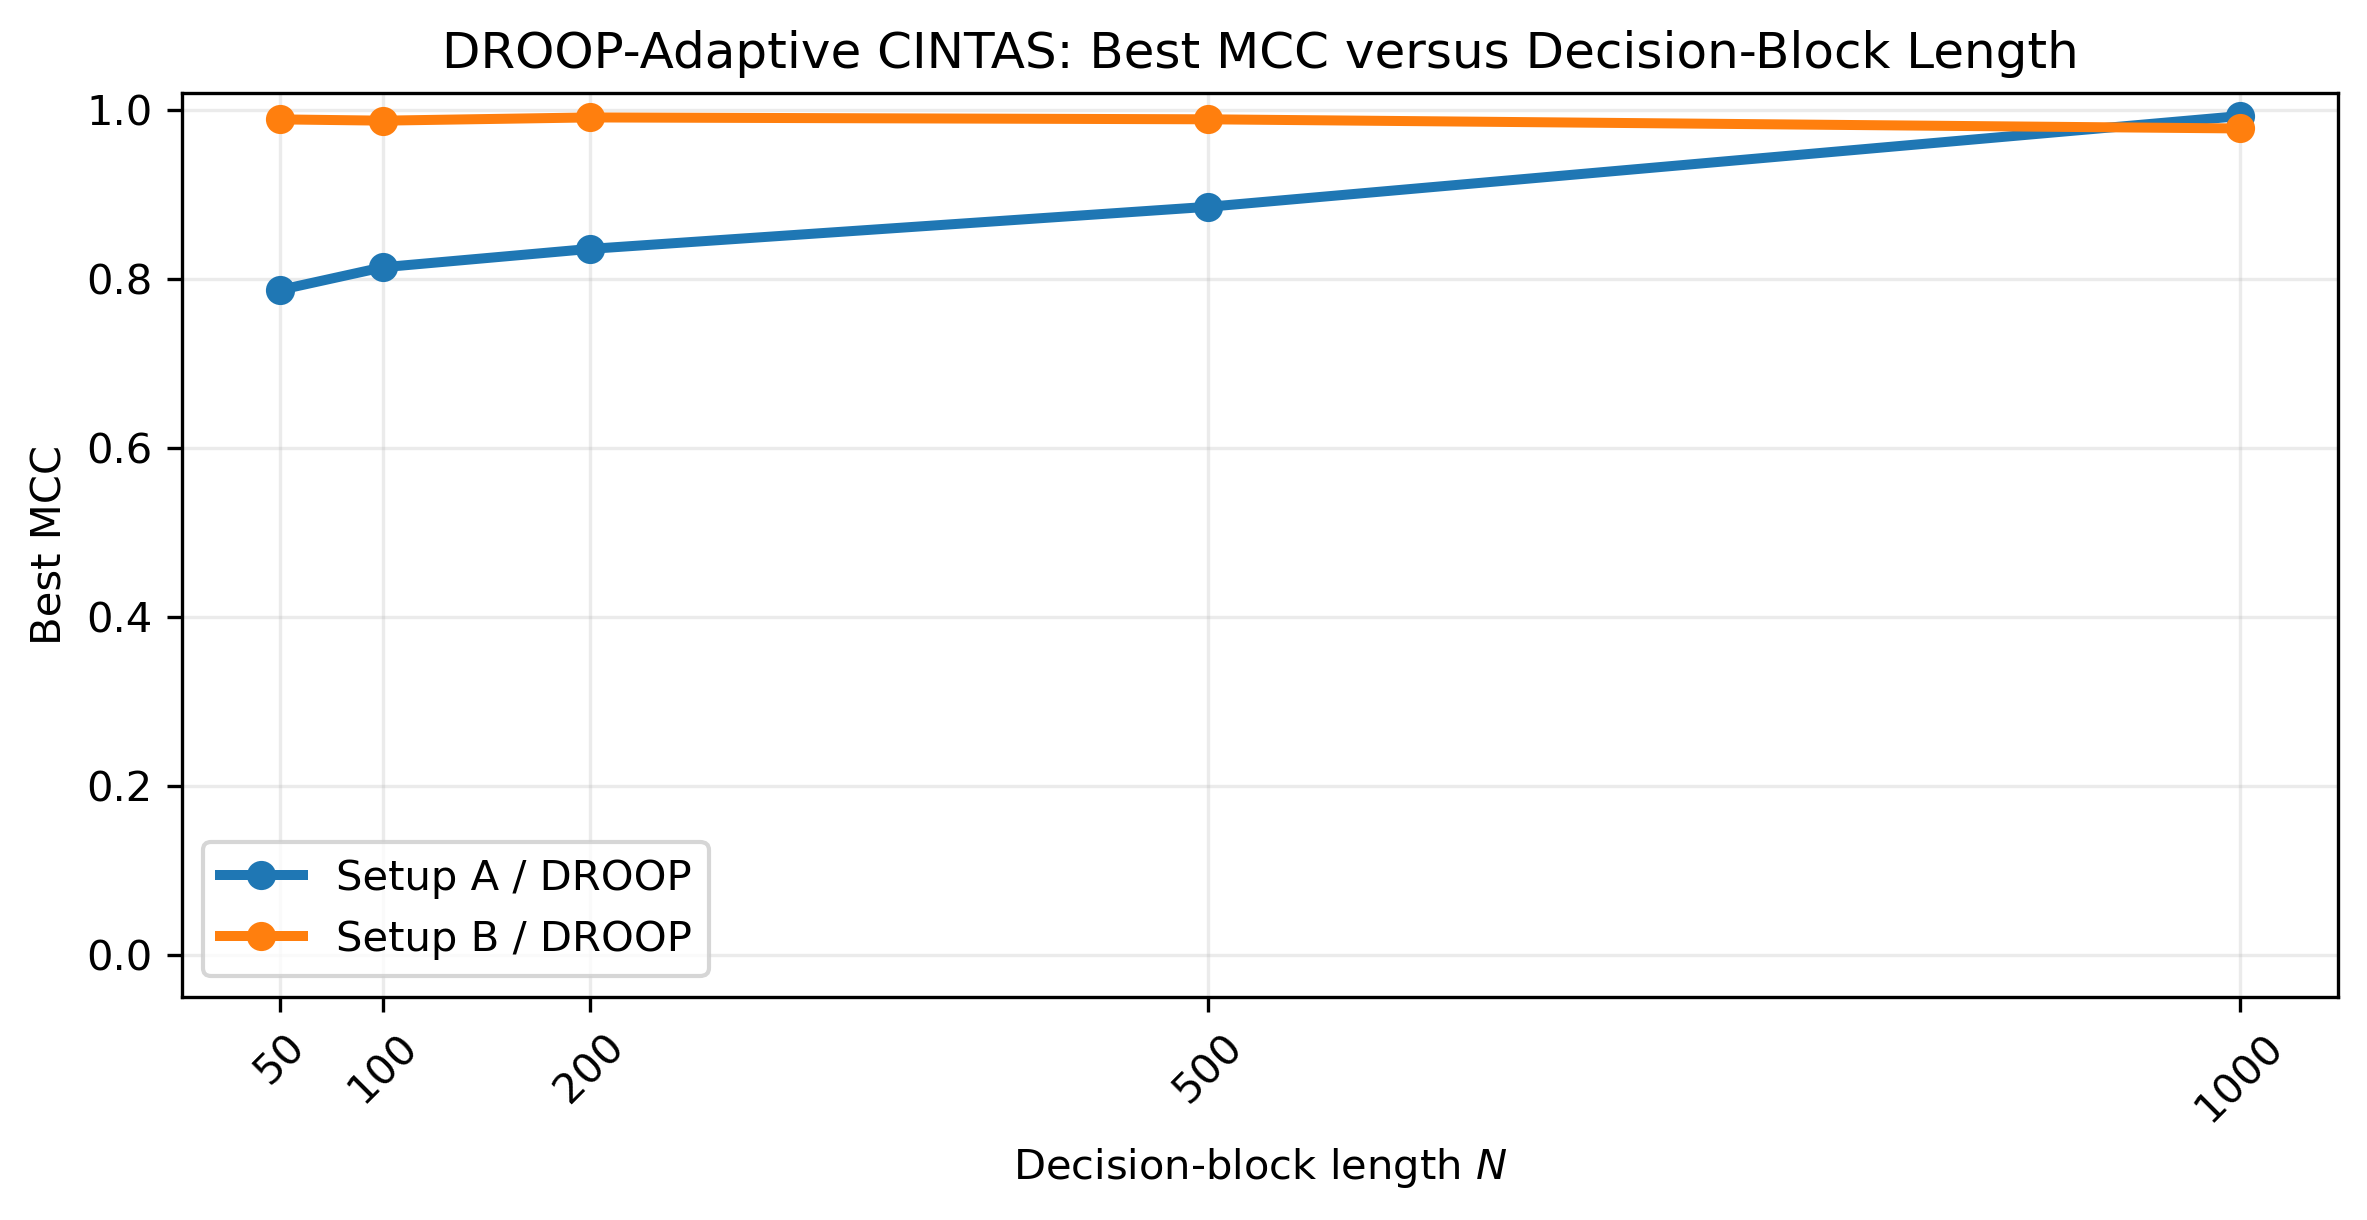

Saved figure: results/notebook_run/droop_adaptive_ablation/fig_droop_adaptive_mcc_vs_block_length.png
[2026-06-12 06:10:29] | [DROOP-adaptive CINTAS] | DONE | 1/2 (50.0%) | elapsed=3251.2s | results/notebook_run/tcad_ablation/tcad_ablation_summary.csv
[2026-06-12 06:10:29] | [TCAD notebook cell] | DONE | 2/2 (100.0%) | elapsed=54975.2s | results/notebook_run/tcad_ablation/tcad_ablation_summary.csv


In [6]:
# DROOP-adaptive CINTAS experiment.
# Edit here if you want to change the DROOP-specific block lengths or feature budgets.
# The default paper-scale block lengths are representative and reproducible; use the full preset only for exhaustive sensitivity runs.

import re
from pathlib import Path
from IPython.display import Image, Markdown, display

DROOP_BLOCK_LENGTHS = (50, 100, 200, 500, 1000)
DROOP_FEATURE_BUDGETS = (15, 30, 50)
DROOP_P_QUANTILES = (0.975, 0.99)
DROOP_FIXED_POINT_Q = (15,)
DROOP_N_SPLITS = 3  # Sparse long-window cases automatically use fewer folds when needed.
DROOP_MAX_BASE_COLUMNS = 40
DROOP_REBUILD_AUGMENTED_DATA = False  # Set True to force rebuilding cached augmented CSVs.

DROOP_ADAPTIVE_DATA_ROOT = RESULTS_ROOT / "droop_adaptive_data"
DROOP_ADAPTIVE_OUT = RESULTS_ROOT / "droop_adaptive_ablation"
DROOP_ADAPTIVE_DATA_ROOT.mkdir(parents=True, exist_ok=True)
DROOP_ADAPTIVE_OUT.mkdir(parents=True, exist_ok=True)

droop_progress = progress_start(
    "DROOP-adaptive CINTAS",
    f"windows={DROOP_BLOCK_LENGTHS}",
)


def _safe_feature_name(name: str) -> str:
    safe = re.sub(r"[^A-Za-z0-9_]+", "_", str(name)).strip("_")
    return safe or "feature"


def droop_priority_columns(df: pd.DataFrame, max_cols: int = 80) -> list[str]:
    """Prefer columns likely to expose voltage droop or its system-level symptoms."""
    exclude = {"setup", "scenario", "workload", "label", "is_anom", "time_idx"}
    numeric_cols = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if str(c) not in exclude and not str(c).startswith("Unnamed:")
    ]
    if not numeric_cols:
        return []

    droop_regex = re.compile(
        r"volt|vdd|vcc|vid|freq|clock|aperf|mperf|ratio|power|pwr|rapl|energy|"
        r"temp|thermal|throttle|stall|cycle|ipc|instr|uops|miss|cache|llc|l2|l3|"
        r"mem|dram|imc|lat|retry|error|margin",
        re.IGNORECASE,
    )
    preferred = [c for c in numeric_cols if droop_regex.search(str(c))]
    remaining = [c for c in numeric_cols if c not in preferred]

    if remaining:
        variances = df[remaining].astype(float).var(numeric_only=True).sort_values(ascending=False)
        remaining = variances.index.tolist()

    return (preferred + remaining)[: min(max_cols, len(numeric_cols))]


def add_droop_transient_features(df: pd.DataFrame, max_cols: int = 80) -> pd.DataFrame:
    """Add transient-aware columns within each setup/scenario/workload trace."""
    out = df.copy()
    cols = droop_priority_columns(out, max_cols=max_cols)
    if not cols:
        return out

    group_cols = [c for c in ["setup", "scenario", "workload"] if c in out.columns]
    group_key = None
    if group_cols:
        group_key = out[group_cols].astype(str).agg("|".join, axis=1)

    def _clean_series(series: pd.Series) -> pd.Series:
        return (
            pd.to_numeric(series, errors="coerce")
            .astype(float)
            .replace([np.inf, -np.inf], np.nan)
            .ffill()
            .bfill()
            .fillna(0.0)
        )

    def _trace_transform(series: pd.Series, fn) -> pd.Series:
        if group_key is None:
            return fn(series)
        return series.groupby(group_key, sort=False).transform(fn)

    new_cols: dict[str, pd.Series] = {}
    for idx, col in enumerate(cols):
        x = _clean_series(out[col])
        dx = _trace_transform(x, lambda s: s.diff().fillna(0.0))
        roll5_max = _trace_transform(x, lambda s: s.rolling(window=5, min_periods=1).max())
        roll5_min = _trace_transform(x, lambda s: s.rolling(window=5, min_periods=1).min())
        roll10_max = _trace_transform(x, lambda s: s.rolling(window=10, min_periods=1).max())
        roll10_std = _trace_transform(x, lambda s: s.rolling(window=10, min_periods=1).std().fillna(0.0))
        med20 = _trace_transform(x, lambda s: s.rolling(window=20, min_periods=1).median())
        mad20 = _trace_transform((x - med20).abs(), lambda s: s.rolling(window=20, min_periods=1).median())
        mad20 = mad20.replace(0.0, np.nan)
        fallback = float(mad20.dropna().median()) if mad20.notna().any() else 0.0
        safe = f"{idx:03d}_{_safe_feature_name(col)}"

        # delta/abs-delta expose sudden motion; rolling range/std expose bursts;
        # drop-from-recent-max helps voltage/frequency-like downward transients;
        # robust-z exposes local deviation without needing anomaly labels.
        new_cols[f"{safe}__delta1"] = dx
        new_cols[f"{safe}__abs_delta1"] = dx.abs()
        new_cols[f"{safe}__range5"] = roll5_max - roll5_min
        new_cols[f"{safe}__std10"] = roll10_std
        new_cols[f"{safe}__drop_from_max10"] = roll10_max - x
        new_cols[f"{safe}__robust_z20"] = ((x - med20).abs() / (mad20.fillna(fallback) + 1e-9)).fillna(0.0)

    if new_cols:
        out = pd.concat([out, pd.DataFrame(new_cols, index=out.index)], axis=1).copy()
    return out


# Build a DROOP-only data view so causal/ranking alignment is not dominated by RH or SPECTRE.
progress_update("DROOP-adaptive CINTAS", "building DROOP-only augmented telemetry", start=droop_progress)
eligible_sources = [
    src for src in sorted(Path(DATA_ROOT).glob("DDR*.csv"))
    if "_benign_" in src.name.lower() or "_droop_" in src.name.lower()
]
if not eligible_sources:
    raise RuntimeError(f"No BENIGN/DROOP telemetry CSVs found in {DATA_ROOT}")

created = []
reused = []
for file_idx, src in enumerate(eligible_sources, start=1):
    dst = DROOP_ADAPTIVE_DATA_ROOT / src.name
    if (
        dst.exists()
        and not DROOP_REBUILD_AUGMENTED_DATA
        and dst.stat().st_mtime >= src.stat().st_mtime
    ):
        progress_update(
            "DROOP-adaptive CINTAS",
            "reusing cached augmented telemetry",
            start=droop_progress,
            current=file_idx,
            total=len(eligible_sources),
            detail=src.name,
        )
        created.append(dst)
        reused.append(dst)
        continue

    progress_update(
        "DROOP-adaptive CINTAS",
        "loading source telemetry",
        start=droop_progress,
        current=file_idx,
        total=len(eligible_sources),
        detail=src.name,
    )
    raw = _sanitize_telemetry_columns(pd.read_csv(src))
    progress_update(
        "DROOP-adaptive CINTAS",
        "adding transient features",
        start=droop_progress,
        current=file_idx,
        total=len(eligible_sources),
        detail=f"{src.name}: rows={len(raw):,} cols={raw.shape[1]}",
    )
    aug = add_droop_transient_features(raw, max_cols=DROOP_MAX_BASE_COLUMNS)
    progress_update(
        "DROOP-adaptive CINTAS",
        "writing augmented telemetry",
        start=droop_progress,
        current=file_idx,
        total=len(eligible_sources),
        detail=f"{dst.name}: cols={aug.shape[1]}",
    )
    aug.to_csv(dst, index=False)
    created.append(dst)

if not created:
    raise RuntimeError(f"No augmented BENIGN/DROOP telemetry files were created in {DROOP_ADAPTIVE_DATA_ROOT}")

print(f"Created {len(created)} DROOP-adaptive CSVs in {DROOP_ADAPTIVE_DATA_ROOT.relative_to(REPO_ROOT)}")
print(f"Block lengths: {DROOP_BLOCK_LENGTHS}")
print(f"Feature budgets: {DROOP_FEATURE_BUDGETS}")
print(f"Requested folds: {DROOP_N_SPLITS} (auto-reduced only when a long-window class has fewer blocks)")

# Run multiple benign threshold quantiles. Lower quantiles may improve DROOP recall;
# the table keeps FPR visible so the paper can choose an honest operating point.
summary_frames = []
selected_frames = []
fold_frames = []
for p_quantile in DROOP_P_QUANTILES:
    out_root = DROOP_ADAPTIVE_OUT / f"p{str(p_quantile).replace('.', '_')}"
    cfg = TCAD2026Config(
        scenarios_eval=("DROOP",),
        feature_budgets=DROOP_FEATURE_BUDGETS,
        window_sizes=DROOP_BLOCK_LENGTHS,
        lambda_res_values=(0.0, 0.25, 0.5, 0.75, 1.0),
        agg_modes=("max", "mean", "median"),
        weight_modes=("uniform", "inv_var"),
        fixed_point_q=DROOP_FIXED_POINT_Q,
        n_splits=DROOP_N_SPLITS,
        p_quantile=float(p_quantile),
        corr_threshold=0.35,
        seed=SEED,
    )
    progress_update(
        "DROOP-adaptive CINTAS",
        "running DROOP-only sweep",
        start=droop_progress,
        detail=f"p={p_quantile} windows={len(DROOP_BLOCK_LENGTHS)} budgets={len(DROOP_FEATURE_BUDGETS)}",
    )
    artifacts = notebook_run_tcad_ablation(
        data_root=DROOP_ADAPTIVE_DATA_ROOT,
        out_root=out_root,
        cfg=cfg,
        seed=SEED,
        threads=THREADS,
    )
    s = artifacts["summary"].copy()
    s["sweep_source"] = "droop_adaptive_dse"
    s["droop_adaptive_p_quantile"] = float(p_quantile)
    s["droop_adaptive_out_root"] = str(out_root.relative_to(REPO_ROOT))
    summary_frames.append(s)

    selected_path = artifacts.get("selected_path")
    if selected_path is not None and Path(selected_path).exists():
        sf = pd.read_csv(selected_path)
        sf["sweep_source"] = "droop_adaptive_dse"
        sf["droop_adaptive_p_quantile"] = float(p_quantile)
        selected_frames.append(sf)

    fold_df = artifacts.get("fold_results")
    if isinstance(fold_df, pd.DataFrame) and not fold_df.empty:
        ff = fold_df.copy()
        ff["sweep_source"] = "droop_adaptive_dse"
        ff["droop_adaptive_p_quantile"] = float(p_quantile)
        ff["droop_adaptive_out_root"] = str(out_root.relative_to(REPO_ROOT))
        fold_frames.append(ff)

if not summary_frames:
    raise RuntimeError("DROOP-adaptive sweep produced no summary rows; check BENIGN/DROOP data, block lengths, and n_splits.")

adaptive_summary = pd.concat(summary_frames, ignore_index=True)
adaptive_summary_path = DROOP_ADAPTIVE_OUT / "droop_adaptive_summary_all_quantiles.csv"
adaptive_summary.to_csv(adaptive_summary_path, index=False)

if selected_frames:
    adaptive_selected = pd.concat(selected_frames, ignore_index=True)
    adaptive_selected_path = DROOP_ADAPTIVE_OUT / "droop_adaptive_selected_features_all_quantiles.csv"
    adaptive_selected.to_csv(adaptive_selected_path, index=False)
else:
    adaptive_selected_path = None

if fold_frames:
    adaptive_fold_results = pd.concat(fold_frames, ignore_index=True, sort=False)
    adaptive_fold_path = DROOP_ADAPTIVE_OUT / "droop_adaptive_fold_results_all_quantiles.csv"
    adaptive_fold_results.to_csv(adaptive_fold_path, index=False)
else:
    adaptive_fold_results = pd.DataFrame()
    adaptive_fold_path = None

# Merge the DROOP-adaptive branch into the main DSE artifacts so downstream
# sections see one integrated DSE instead of standard-DROOP plus adaptive-DROOP.
standard_summary_for_dse = globals().get("summary_standard", pd.DataFrame()).copy()
standard_summary_path = TCAD_OUT / "tcad_ablation_standard_summary.csv"
if standard_summary_for_dse.empty and standard_summary_path.exists():
    standard_summary_for_dse = pd.read_csv(standard_summary_path)
elif standard_summary_for_dse.empty and "summary" in globals() and isinstance(summary, pd.DataFrame):
    standard_summary_for_dse = summary.copy()
if not standard_summary_for_dse.empty and "scenario" in standard_summary_for_dse.columns:
    standard_summary_for_dse = standard_summary_for_dse[standard_summary_for_dse["scenario"].astype(str).str.upper() != "DROOP"].copy()
if not standard_summary_for_dse.empty:
    if "sweep_source" not in standard_summary_for_dse.columns:
        standard_summary_for_dse["sweep_source"] = "standard_dse"
    else:
        standard_summary_for_dse["sweep_source"] = standard_summary_for_dse["sweep_source"].fillna("standard_dse")

summary = pd.concat([standard_summary_for_dse, adaptive_summary], ignore_index=True, sort=False)
tcad_integrated_summary_path = TCAD_OUT / "tcad_ablation_summary.csv"
tcad_integrated_summary_copy_path = TCAD_OUT / "tcad_ablation_summary_integrated.csv"
summary.to_csv(tcad_integrated_summary_path, index=False)
summary.to_csv(tcad_integrated_summary_copy_path, index=False)

standard_fold_for_dse = pd.DataFrame()
if "tcad_artifacts" in globals() and isinstance(tcad_artifacts, dict) and isinstance(tcad_artifacts.get("fold_results"), pd.DataFrame):
    standard_fold_for_dse = tcad_artifacts["fold_results"].copy()
standard_fold_path = TCAD_OUT / "tcad_ablation_standard_fold_results.csv"
if standard_fold_for_dse.empty and standard_fold_path.exists():
    standard_fold_for_dse = pd.read_csv(standard_fold_path)
if not standard_fold_for_dse.empty and "scenario" in standard_fold_for_dse.columns:
    standard_fold_for_dse = standard_fold_for_dse[standard_fold_for_dse["scenario"].astype(str).str.upper() != "DROOP"].copy()
if not standard_fold_for_dse.empty:
    if "sweep_source" not in standard_fold_for_dse.columns:
        standard_fold_for_dse["sweep_source"] = "standard_dse"
    else:
        standard_fold_for_dse["sweep_source"] = standard_fold_for_dse["sweep_source"].fillna("standard_dse")

fold_results_integrated = pd.concat([standard_fold_for_dse, adaptive_fold_results], ignore_index=True, sort=False)
if not fold_results_integrated.empty:
    tcad_integrated_fold_path = TCAD_OUT / "tcad_ablation_fold_results.csv"
    tcad_integrated_fold_copy_path = TCAD_OUT / "tcad_ablation_fold_results_integrated.csv"
    fold_results_integrated.to_csv(tcad_integrated_fold_path, index=False)
    fold_results_integrated.to_csv(tcad_integrated_fold_copy_path, index=False)
else:
    tcad_integrated_fold_path = TCAD_OUT / "tcad_ablation_fold_results.csv"

if "tcad_artifacts" not in globals() or not isinstance(tcad_artifacts, dict):
    tcad_artifacts = {}
tcad_artifacts["summary"] = summary
tcad_artifacts["summary_path"] = tcad_integrated_summary_path
tcad_artifacts["fold_results"] = fold_results_integrated
tcad_artifacts["fold_path"] = tcad_integrated_fold_path
DROOP_ADAPTIVE_ALREADY_IN_TCAD_SUMMARY = True

rank_cols = ["mcc", "bal_acc", "auc_roc", "f1", "fpr"]
rank_ascending = [False, False, False, False, True]
adaptive_best = (
    adaptive_summary
    .sort_values(rank_cols, ascending=rank_ascending, kind="mergesort")
    .groupby(["setup", "scenario"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

paper_cols = [
    "setup", "scenario", "droop_adaptive_p_quantile", "top_k", "n_selected_features",
    "window_size", "agg_mode", "lambda_res", "weight_mode", "fixed_point_q",
    "auc_roc", "auc_pr", "f1", "bal_acc", "mcc", "fpr", "brier", "ece",
    "fp_mae", "fp_max_abs", "hw_setup_b_area_overhead_pct", "hw_idle_power_overhead_pct",
]
adaptive_best_table = adaptive_best[[c for c in paper_cols if c in adaptive_best.columns]].copy()
adaptive_best_path = DROOP_ADAPTIVE_OUT / "droop_adaptive_best_by_setup.csv"
adaptive_best_table.to_csv(adaptive_best_path, index=False)

print(f"DROOP-adaptive summary: {adaptive_summary_path.relative_to(REPO_ROOT)}")
print(f"DROOP-adaptive best table: {adaptive_best_path.relative_to(REPO_ROOT)}")
print(f"Integrated DSE summary: {tcad_integrated_summary_path.relative_to(REPO_ROOT)}")
print(f"Integrated DSE fold results: {tcad_integrated_fold_path.relative_to(REPO_ROOT)}")
display(adaptive_best_table.round(6))
display(Markdown("### Integrated DSE preview: standard non-DROOP + adaptive DROOP"))
display(summary.head(12).round(6))

# Standard DROOP is intentionally skipped in the main branch when integrated
# DROOP-adaptive DSE is enabled, so there is no duplicate standard-DROOP
# comparison in the paper-facing flow.
print("Integrated DSE uses adaptive DROOP only; standard DROOP is not run twice.")

# Figure: best DROOP MCC over the requested 50-step block-length grid.
plot_df = (
    adaptive_summary
    .sort_values(rank_cols, ascending=rank_ascending, kind="mergesort")
    .groupby(["setup", "scenario", "window_size"], as_index=False)
    .head(1)
    .sort_values(["setup", "window_size"])
)

fig_path = DROOP_ADAPTIVE_OUT / "fig_droop_adaptive_mcc_vs_block_length.png"
fig, ax = plt.subplots(figsize=(8.0, 4.2))
for setup_name, group in plot_df.groupby("setup", sort=True):
    ax.plot(group["window_size"], group["mcc"], marker="o", linewidth=2.4, label=f"Setup {setup_name} / DROOP")
ax.set_title("DROOP-Adaptive CINTAS: Best MCC versus Decision-Block Length")
ax.set_xlabel("Decision-block length $N$")
ax.set_ylabel("Best MCC")
ax.set_xticks(list(DROOP_BLOCK_LENGTHS))
ax.tick_params(axis="x", labelrotation=45)
ax.set_ylim(-0.05, 1.02)
ax.grid(True, alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(fig_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)
display(Image(filename=str(fig_path)))
print(f"Saved figure: {fig_path.relative_to(REPO_ROOT)}")

progress_update(
    "DROOP-adaptive CINTAS",
    "DONE",
    start=droop_progress,
    current=1,
    total=2,
    detail=tcad_integrated_summary_path.relative_to(REPO_ROOT),
)
if "tcad_cell_progress" in globals():
    progress_update("TCAD notebook cell", "DONE", start=tcad_cell_progress, current=2, total=2, detail=tcad_integrated_summary_path.relative_to(REPO_ROOT))


### Section 4 Paper Figures: Paper-Scale DSE and Workload Sweep

Run this cell after the paper-scale design-space sweep. It converts the saved sweep CSVs into paper-facing Section 4 artifacts:

1. `section4_dse_best_by_setup_scenario.csv`: the best deployable DSE setting per setup/anomaly class.
2. `section4_vivado_best_settings_queue.csv`: the exact rows to synthesize with Vivado/RTL.
3. `section4_selected_setting_workload_performance.csv`: per-workload performance when the selected setup/anomaly setting is frozen.
4. `section4_selected_setting_workload_summary.csv`: workload robustness summary for the paper.
5. `fig_section4_dse_budget_window_heatmap.png`: paper-scale DSE accuracy envelope.
6. `fig_section4_selected_setting_workload_mcc_heatmap.png`: workload robustness under the selected fixed setting.

This is the key journal-extension behavior: DSE chooses one setting, and workload robustness is reported under that same setting instead of letting each workload pick a separate oracle configuration.


## 5. TCAD Results Gallery

### Setup

In [7]:
# Section 11 shared setup.
# Run this once before the individual table/figure cells.

plt.rcdefaults()
plt.rcParams.update({
    "font.size": 8.5,
    "axes.titlesize": 10.5,
    "axes.labelsize": 9.5,
    "xtick.labelsize": 8.0,
    "ytick.labelsize": 8.0,
    "legend.fontsize": 8.0,
    "figure.titlesize": 12.0,
    "axes.linewidth": 0.8,
    "savefig.dpi": 300,
})

GALLERY_DIR = TCAD_OUT / "paper_figures"
GALLERY_DIR.mkdir(parents=True, exist_ok=True)

SUMMARY_PATH = TCAD_OUT / "tcad_ablation_summary.csv"
FOLD_PATH = TCAD_OUT / "tcad_ablation_fold_results.csv"
DROOP_SUMMARY_PATH = RESULTS_ROOT / "droop_adaptive_ablation" / "droop_adaptive_summary_all_quantiles.csv"
LIFECYCLE_SUMMARY_PATH = LIFECYCLE_OUT / "lifecycle_recalibration_summary.csv"
LIFECYCLE_SCENARIO_PATH = LIFECYCLE_OUT / "lifecycle_recalibration_by_scenario.csv"

if not SUMMARY_PATH.exists():
    raise RuntimeError("Run Section 4 first: missing tcad_ablation_summary.csv")
if not FOLD_PATH.exists():
    raise RuntimeError("Run Section 4 first: missing tcad_ablation_fold_results.csv")

gallery_summary = pd.read_csv(SUMMARY_PATH, low_memory=False)

fold_cols = [
    "setup", "scenario", "workload", "sweep_source", "droop_adaptive_p_quantile",
    "window_size", "agg_mode", "lambda_res", "p_quantile", "n_splits",
    "requested_n_splits", "top_k", "n_selected_features", "weight_mode",
    "fixed_point_q", "auc_roc", "auc_pr", "f1", "bal_acc", "mcc", "fpr",
    "brier", "ece", "fp_mae", "fp_max_abs",
    "hw_setup_b_area_overhead_pct", "hw_idle_power_overhead_pct",
]
gallery_folds = pd.read_csv(FOLD_PATH, usecols=lambda c: c in fold_cols, low_memory=False)

droop_already_in_summary = (
    "sweep_source" in gallery_summary.columns
    and gallery_summary["sweep_source"].astype(str).str.contains("droop_adaptive", case=False, na=False).any()
)
if droop_already_in_summary or not DROOP_SUMMARY_PATH.exists():
    gallery_droop = pd.DataFrame()
else:
    gallery_droop = pd.read_csv(DROOP_SUMMARY_PATH, low_memory=False)

gallery_lifecycle = pd.read_csv(LIFECYCLE_SUMMARY_PATH) if LIFECYCLE_SUMMARY_PATH.exists() else pd.DataFrame()
gallery_lifecycle_by_scenario = pd.read_csv(LIFECYCLE_SCENARIO_PATH) if LIFECYCLE_SCENARIO_PATH.exists() else pd.DataFrame()

rank_cols = [c for c in ["mcc", "bal_acc", "auc_roc", "f1", "fpr"] if c in gallery_summary.columns]
rank_ascending = [False, False, False, False, True][:len(rank_cols)]

def _best_rows(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    if df.empty:
        return df.copy()
    local_rank = [c for c in rank_cols if c in df.columns]
    local_asc = [rank_ascending[rank_cols.index(c)] for c in local_rank]
    if not local_rank:
        return df.groupby(group_cols, as_index=False).head(1).reset_index(drop=True)
    return (
        df.sort_values(local_rank, ascending=local_asc, kind="mergesort", na_position="last")
        .groupby(group_cols, as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

def _save_table(df: pd.DataFrame, name: str) -> Path:
    path = GALLERY_DIR / name
    df.to_csv(path, index=False)
    return path

def _save_show(fig, name: str) -> Path:
    path = GALLERY_DIR / name
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    display(Image(filename=str(path)))
    return path

def _show_table(title: str, df: pd.DataFrame, name: str, digits: int = 6) -> Path:
    path = _save_table(df, name)
    display(Markdown(f"### {title}"))
    display(df.round(digits) if not df.empty else df)
    print(f"Saved table: {path.relative_to(REPO_ROOT)}")
    return path

def _trim_white_margin(img: np.ndarray, threshold: float = 0.985, pad: int = 12) -> np.ndarray:
    arr = np.asarray(img)
    rgb = arr[..., :3] if arr.ndim == 3 else arr
    mask = np.any(rgb < threshold, axis=2) if rgb.ndim == 3 else rgb < threshold
    coords = np.argwhere(mask)
    if coords.size == 0:
        return arr
    y0, x0 = np.maximum(coords.min(axis=0) - pad, 0)
    y1, x1 = np.minimum(coords.max(axis=0) + pad + 1, arr.shape[:2])
    return arr[y0:y1, x0:x1]

print(f"Loaded summary rows: {len(gallery_summary):,}")
print(f"Loaded fold rows: {len(gallery_folds):,}")
print(f"Gallery directory: {GALLERY_DIR.relative_to(REPO_ROOT)}")


Loaded summary rows: 37,800
Loaded fold rows: 2,445,840
Gallery directory: results/notebook_run/tcad_ablation/paper_figures


### CITADEL operating points

In [8]:
main_best = _best_rows(gallery_summary, ["setup", "scenario"])
if "sweep_source" not in main_best.columns:
    main_best["sweep_source"] = "standard_dse"
else:
    main_best["sweep_source"] = main_best["sweep_source"].fillna("standard_dse")
if "droop_adaptive_p_quantile" not in main_best.columns:
    main_best["droop_adaptive_p_quantile"] = np.nan

if not gallery_droop.empty:
    droop_best = _best_rows(gallery_droop, ["setup", "scenario"])
    droop_best["sweep_source"] = "droop_adaptive_sweep"
    droop_candidates = pd.concat([
        main_best[main_best["scenario"].astype(str).str.upper() == "DROOP"],
        droop_best,
    ], ignore_index=True, sort=False)
    paper_droop = _best_rows(droop_candidates, ["setup", "scenario"])
else:
    paper_droop = main_best[main_best["scenario"].astype(str).str.upper() == "DROOP"].copy()

paper_selected = pd.concat([
    main_best[main_best["scenario"].astype(str).str.upper() != "DROOP"],
    paper_droop,
], ignore_index=True, sort=False).sort_values(["setup", "scenario"]).reset_index(drop=True)

selected_cols = [
    "setup", "scenario", "sweep_source", "droop_adaptive_p_quantile",
    "top_k", "n_selected_features", "window_size", "agg_mode",
    "lambda_res", "p_quantile", "weight_mode", "fixed_point_q",
    "auc_roc", "auc_pr", "f1", "bal_acc", "mcc", "fpr",
    "fp_mae", "fp_max_abs", "hw_setup_b_area_overhead_pct",
    "hw_idle_power_overhead_pct",
]
table1 = paper_selected[[c for c in selected_cols if c in paper_selected.columns]].copy()
_show_table("Table 1. Paper-selected CITADEL operating points", table1, "gallery_table1_selected_operating_points.csv")


### Table 1. Paper-selected CITADEL operating points

,setup,scenario,sweep_source,droop_adaptive_p_quantile,top_k,n_selected_features,window_size,agg_mode,lambda_res,p_quantile,...,auc_roc,auc_pr,f1,bal_acc,mcc,fpr,fp_mae,fp_max_abs,hw_setup_b_area_overhead_pct,hw_idle_power_overhead_pct
0,A,DROOP,droop_adaptive_dse,0.99,15,15,1000,median,0.00,0.99,...,1.00000,1.000000,0.996255,0.996124,0.992420,0.007752,0.000046,0.000259,0.082535,0.060426
1,A,RH,standard_dse,NaN,20,20,550,median,1.00,0.99,...,1.00000,1.000000,0.995833,0.995745,0.991663,0.008511,0.037379,0.047828,0.109545,0.080437
2,B,DROOP,droop_adaptive_dse,0.99,15,15,200,median,0.50,0.99,...,0.99862,0.999273,0.995416,0.995392,0.990815,0.007680,0.000388,0.004886,0.082535,0.060426
3,B,SPECTRE,standard_dse,NaN,30,30,700,median,0.75,0.99,...,0.99985,0.999858,0.994594,0.994520,0.989185,0.010961,0.114091,2.091125,0.161400,0.118454


Saved table: results/notebook_run/tcad_ablation/paper_figures/gallery_table1_selected_operating_points.csv


PosixPath('/Users/hsiaopingni/CITADEL/results/notebook_run/tcad_ablation/paper_figures/gallery_table1_selected_operating_points.csv')

### Selected-setting workload robustness

In [9]:
per_workload = gallery_folds[gallery_folds["workload"].astype(str).str.upper() != "ALL"].copy()

cfg_cols = [c for c in [
    "setup", "scenario", "workload", "window_size", "agg_mode", "lambda_res",
    "p_quantile", "top_k", "n_selected_features", "weight_mode", "fixed_point_q"
] if c in per_workload.columns]

metric_cols = [c for c in [
    "auc_roc", "auc_pr", "f1", "bal_acc", "mcc", "fpr", "brier", "ece",
    "fp_mae", "fp_max_abs", "hw_setup_b_area_overhead_pct",
    "hw_idle_power_overhead_pct"
] if c in per_workload.columns]

per_workload_mean = per_workload.groupby(cfg_cols, as_index=False)[metric_cols].mean(numeric_only=True)

selected_key_cols = [
    c for c in ["window_size", "agg_mode", "lambda_res", "p_quantile", "top_k", "weight_mode", "fixed_point_q"]
    if c in table1.columns and c in per_workload_mean.columns
]
selected_cfg = table1[["setup", "scenario", *selected_key_cols]].drop_duplicates().copy()

workload_selected = per_workload_mean.merge(
    selected_cfg,
    on=["setup", "scenario", *selected_key_cols],
    how="inner",
)

if workload_selected.empty:
    workload_selected = _best_rows(per_workload_mean, ["setup", "scenario", "workload"])
    workload_selected["selection_note"] = "per-workload fallback; rerun Section 4 for selected-setting rows"
else:
    workload_selected["selection_note"] = "selected setup/scenario DSE setting"

workload_selected["setup_scenario"] = workload_selected["setup"].astype(str) + "-" + workload_selected["scenario"].astype(str)
_save_table(workload_selected, "gallery_table2_selected_setting_per_workload.csv")

workload_oracle = _best_rows(per_workload_mean, ["setup", "scenario", "workload"])
oracle_cols = [c for c in ["setup", "scenario", "workload", "mcc", "fpr", "top_k", "window_size", "fixed_point_q"] if c in workload_oracle.columns]

selected_vs_oracle = workload_selected.merge(
    workload_oracle[oracle_cols].rename(columns={
        "mcc": "oracle_mcc",
        "fpr": "oracle_fpr",
        "top_k": "oracle_top_k",
        "window_size": "oracle_window_size",
        "fixed_point_q": "oracle_fixed_point_q",
    }),
    on=["setup", "scenario", "workload"],
    how="left",
)

if "oracle_mcc" in selected_vs_oracle.columns:
    selected_vs_oracle["mcc_gap_to_oracle"] = selected_vs_oracle["oracle_mcc"] - selected_vs_oracle["mcc"]

_save_table(selected_vs_oracle, "gallery_table2_selected_setting_vs_workload_oracle.csv")

table2 = (
    workload_selected.groupby(["setup", "scenario"], as_index=False)
    .agg(
        workloads=("workload", "nunique"),
        selected_top_k=("top_k", "first"),
        selected_window_size=("window_size", "first"),
        selected_fixed_point_q=("fixed_point_q", "first"),
        mean_mcc=("mcc", "mean"),
        median_mcc=("mcc", "median"),
        min_mcc=("mcc", "min"),
        max_mcc=("mcc", "max"),
        mean_fpr=("fpr", "mean"),
        max_fpr=("fpr", "max"),
    )
)

if "mcc_gap_to_oracle" in selected_vs_oracle.columns:
    gap_summary = selected_vs_oracle.groupby(["setup", "scenario"], as_index=False).agg(
        mean_mcc_gap_to_oracle=("mcc_gap_to_oracle", "mean"),
        max_mcc_gap_to_oracle=("mcc_gap_to_oracle", "max"),
    )
    table2 = table2.merge(gap_summary, on=["setup", "scenario"], how="left")

_show_table("Table 2. Selected-setting workload robustness", table2, "gallery_table2_workload_robustness.csv")


### Table 2. Selected-setting workload robustness

,setup,scenario,workloads,selected_top_k,selected_window_size,selected_fixed_point_q,mean_mcc,median_mcc,min_mcc,max_mcc,mean_fpr,max_fpr,mean_mcc_gap_to_oracle,max_mcc_gap_to_oracle
0,A,DROOP,13,15,1000,15,0.989163,1.0,0.859117,1.0,0.012821,0.166667,0.010837,0.140883
1,A,RH,13,20,550,8,0.994345,1.0,0.926491,1.0,0.006154,0.080000,0.005655,0.073509
2,B,DROOP,13,15,200,15,0.990919,1.0,0.896828,1.0,0.007743,0.100654,0.009081,0.103172
3,B,SPECTRE,13,30,700,8,0.989839,1.0,0.867912,1.0,0.012821,0.166667,0.010161,0.132088


Saved table: results/notebook_run/tcad_ablation/paper_figures/gallery_table2_workload_robustness.csv


PosixPath('/Users/hsiaopingni/CITADEL/results/notebook_run/tcad_ablation/paper_figures/gallery_table2_workload_robustness.csv')

### Feature-budget and telemetry-cost trade-off

In [10]:
table3 = (
    gallery_summary.groupby(["setup", "scenario", "top_k"], as_index=False)
    .agg(
        best_mcc=("mcc", "max"),
        best_bal_acc=("bal_acc", "max"),
        min_fpr=("fpr", "min"),
        mean_area_overhead_pct=("hw_setup_b_area_overhead_pct", "mean"),
        mean_idle_power_overhead_pct=("hw_idle_power_overhead_pct", "mean"),
    )
    .sort_values(["setup", "scenario", "top_k"])
)

_show_table("Table 3. Feature-budget and telemetry-cost trade-off", table3, "gallery_table3_feature_budget_tradeoff.csv")


### Table 3. Feature-budget and telemetry-cost trade-off

,setup,scenario,top_k,best_mcc,best_bal_acc,min_fpr,mean_area_overhead_pct,mean_idle_power_overhead_pct
0,A,DROOP,15,0.992420,0.996124,0.007752,0.082535,0.060426
1,A,DROOP,30,0.621223,0.784972,0.007663,0.161941,0.118955
2,A,DROOP,50,0.596827,0.769380,0.009231,0.267816,0.196995
3,A,RH,5,0.180237,0.542308,0.008219,0.030138,0.021908
4,A,RH,8,0.409197,0.650504,0.008146,0.046020,0.033614
5,A,RH,10,0.910110,0.953846,0.009231,0.056607,0.041417
6,A,RH,15,0.914000,0.955526,0.008511,0.083076,0.060927
7,A,RH,20,0.991663,0.995745,0.008511,0.109545,0.080437
8,A,RH,30,0.990825,0.995385,0.008511,0.161400,0.118454
9,B,DROOP,15,0.990815,0.995392,0.007680,0.082535,0.060426


Saved table: results/notebook_run/tcad_ablation/paper_figures/gallery_table3_feature_budget_tradeoff.csv


PosixPath('/Users/hsiaopingni/CITADEL/results/notebook_run/tcad_ablation/paper_figures/gallery_table3_feature_budget_tradeoff.csv')

### Stable conditional telemetry graph top features

In [11]:
feature_rank_rows = []

for rank_path in sorted((TCAD_OUT / "causal").glob("SETUP_*_feature_ranks.csv")):
    setup_name = rank_path.stem.split("_")[1]
    ranks = pd.read_csv(rank_path).head(12).copy()
    ranks.insert(0, "rank", np.arange(1, len(ranks) + 1))
    ranks.insert(0, "setup", setup_name)
    feature_rank_rows.append(ranks)

if feature_rank_rows:
    table4_raw = pd.concat(feature_rank_rows, ignore_index=True)
else:
    table4_raw = pd.DataFrame(columns=["setup", "rank", "feature", "domain", "importance_score"])

table4_cols = [
    "setup", "rank", "feature", "domain", "importance_score",
    "droop_anchor_score", "edge_stability", "conditional_dependence",
    "cias_alignment", "graph_centrality", "anomaly_alignment",
]

table4_keep = []
for col in table4_cols:
    if col in table4_raw.columns and (col in {"setup", "rank", "feature"} or not table4_raw[col].isna().all()):
        table4_keep.append(col)

table4 = table4_raw[table4_keep]
_show_table("Table 4. Stable conditional telemetry graph top features", table4, "gallery_table4_stable_graph_top_features.csv")


### Table 4. Stable conditional telemetry graph top features

,setup,rank,feature,domain,importance_score,droop_anchor_score,edge_stability,conditional_dependence,cias_alignment,graph_centrality
0,A,1,Core2 (Socket 0).14_C6res%,CORE,1.000000,0.35,1.000000,1.000000,0.109755,1.000000
1,A,2,Core1 (Socket 0).14_C6res%,CORE,0.941129,0.35,0.888889,0.985475,0.160401,0.920470
2,A,3,Core3 (Socket 0).14_C6res%,CORE,0.911963,0.35,0.888889,0.930944,0.076738,0.930944
3,A,4,Core0 (Socket 0).14_C6res%,CORE,0.863463,0.35,0.763889,0.873411,0.206240,0.865206
4,A,5,SKT0 Core C-State.3_C6res%,CORE,0.775547,0.35,0.555556,0.815332,0.250700,0.815332
5,A,6,System Core C-States.3_C6res%,CORE,0.775547,0.35,0.555556,0.815332,0.250700,0.815332
6,A,7,SKT0 Core C-State.4_C7res%,CORE,0.767239,0.35,0.555556,0.796863,0.267348,0.796863
7,A,8,System Core C-States.4_C7res%,CORE,0.767239,0.35,0.555556,0.796863,0.267348,0.796863
8,A,9,Core3 (Socket 0).15_C7res%,CORE,0.740830,0.35,0.763889,0.701899,0.173909,0.693692
9,A,10,Core2 (Socket 0).17_INST,CORE,0.705616,0.00,0.666667,0.617720,0.367845,0.617720


Saved table: results/notebook_run/tcad_ablation/paper_figures/gallery_table4_stable_graph_top_features.csv


PosixPath('/Users/hsiaopingni/CITADEL/results/notebook_run/tcad_ablation/paper_figures/gallery_table4_stable_graph_top_features.csv')

### Lifecycle recalibration and deployment feasibility

In [12]:
if not gallery_lifecycle.empty:
    table5_cols = [
        "setup", "method", "top_k", "window_size", "rank_jaccard",
        "n_eval_windows", "tpr", "fpr", "mcc", "benign_score_mean_delta",
        "n_initial_features", "n_recalibrated_features",
    ]
    table5 = gallery_lifecycle[[c for c in table5_cols if c in gallery_lifecycle.columns]].copy()
else:
    table5 = table1[[c for c in [
        "setup", "scenario", "top_k", "fixed_point_q", "mcc", "fpr",
        "fp_mae", "fp_max_abs", "hw_setup_b_area_overhead_pct",
        "hw_idle_power_overhead_pct"
    ] if c in table1.columns]].copy()

_show_table("Table 5. Lifecycle recalibration and deployment feasibility", table5, "gallery_table5_lifecycle_deployment.csv")


### Table 5. Lifecycle recalibration and deployment feasibility

,setup,method,top_k,window_size,rank_jaccard,n_eval_windows,tpr,fpr,mcc,benign_score_mean_delta,n_initial_features,n_recalibrated_features
0,A,frozen,15,100,1.000000,3120,0.429615,0.007692,0.327727,-0.027411,15,15
1,A,threshold_only,15,100,1.000000,3120,0.430769,0.011538,0.325319,-0.027411,15,15
2,A,full_feature_rank,15,100,0.764706,3120,0.360769,0.011538,0.283325,-0.251732,15,15
3,B,frozen,15,100,1.000000,3120,0.301923,0.017308,0.243518,-0.362482,15,15
4,B,threshold_only,15,100,1.000000,3120,0.296154,0.011538,0.245379,-0.362482,15,15
5,B,full_feature_rank,15,100,0.666667,3120,0.300000,0.011538,0.247636,0.676405,15,15


Saved table: results/notebook_run/tcad_ablation/paper_figures/gallery_table5_lifecycle_deployment.csv


PosixPath('/Users/hsiaopingni/CITADEL/results/notebook_run/tcad_ablation/paper_figures/gallery_table5_lifecycle_deployment.csv')

## Figures

### Hardware-aware DSE envelope

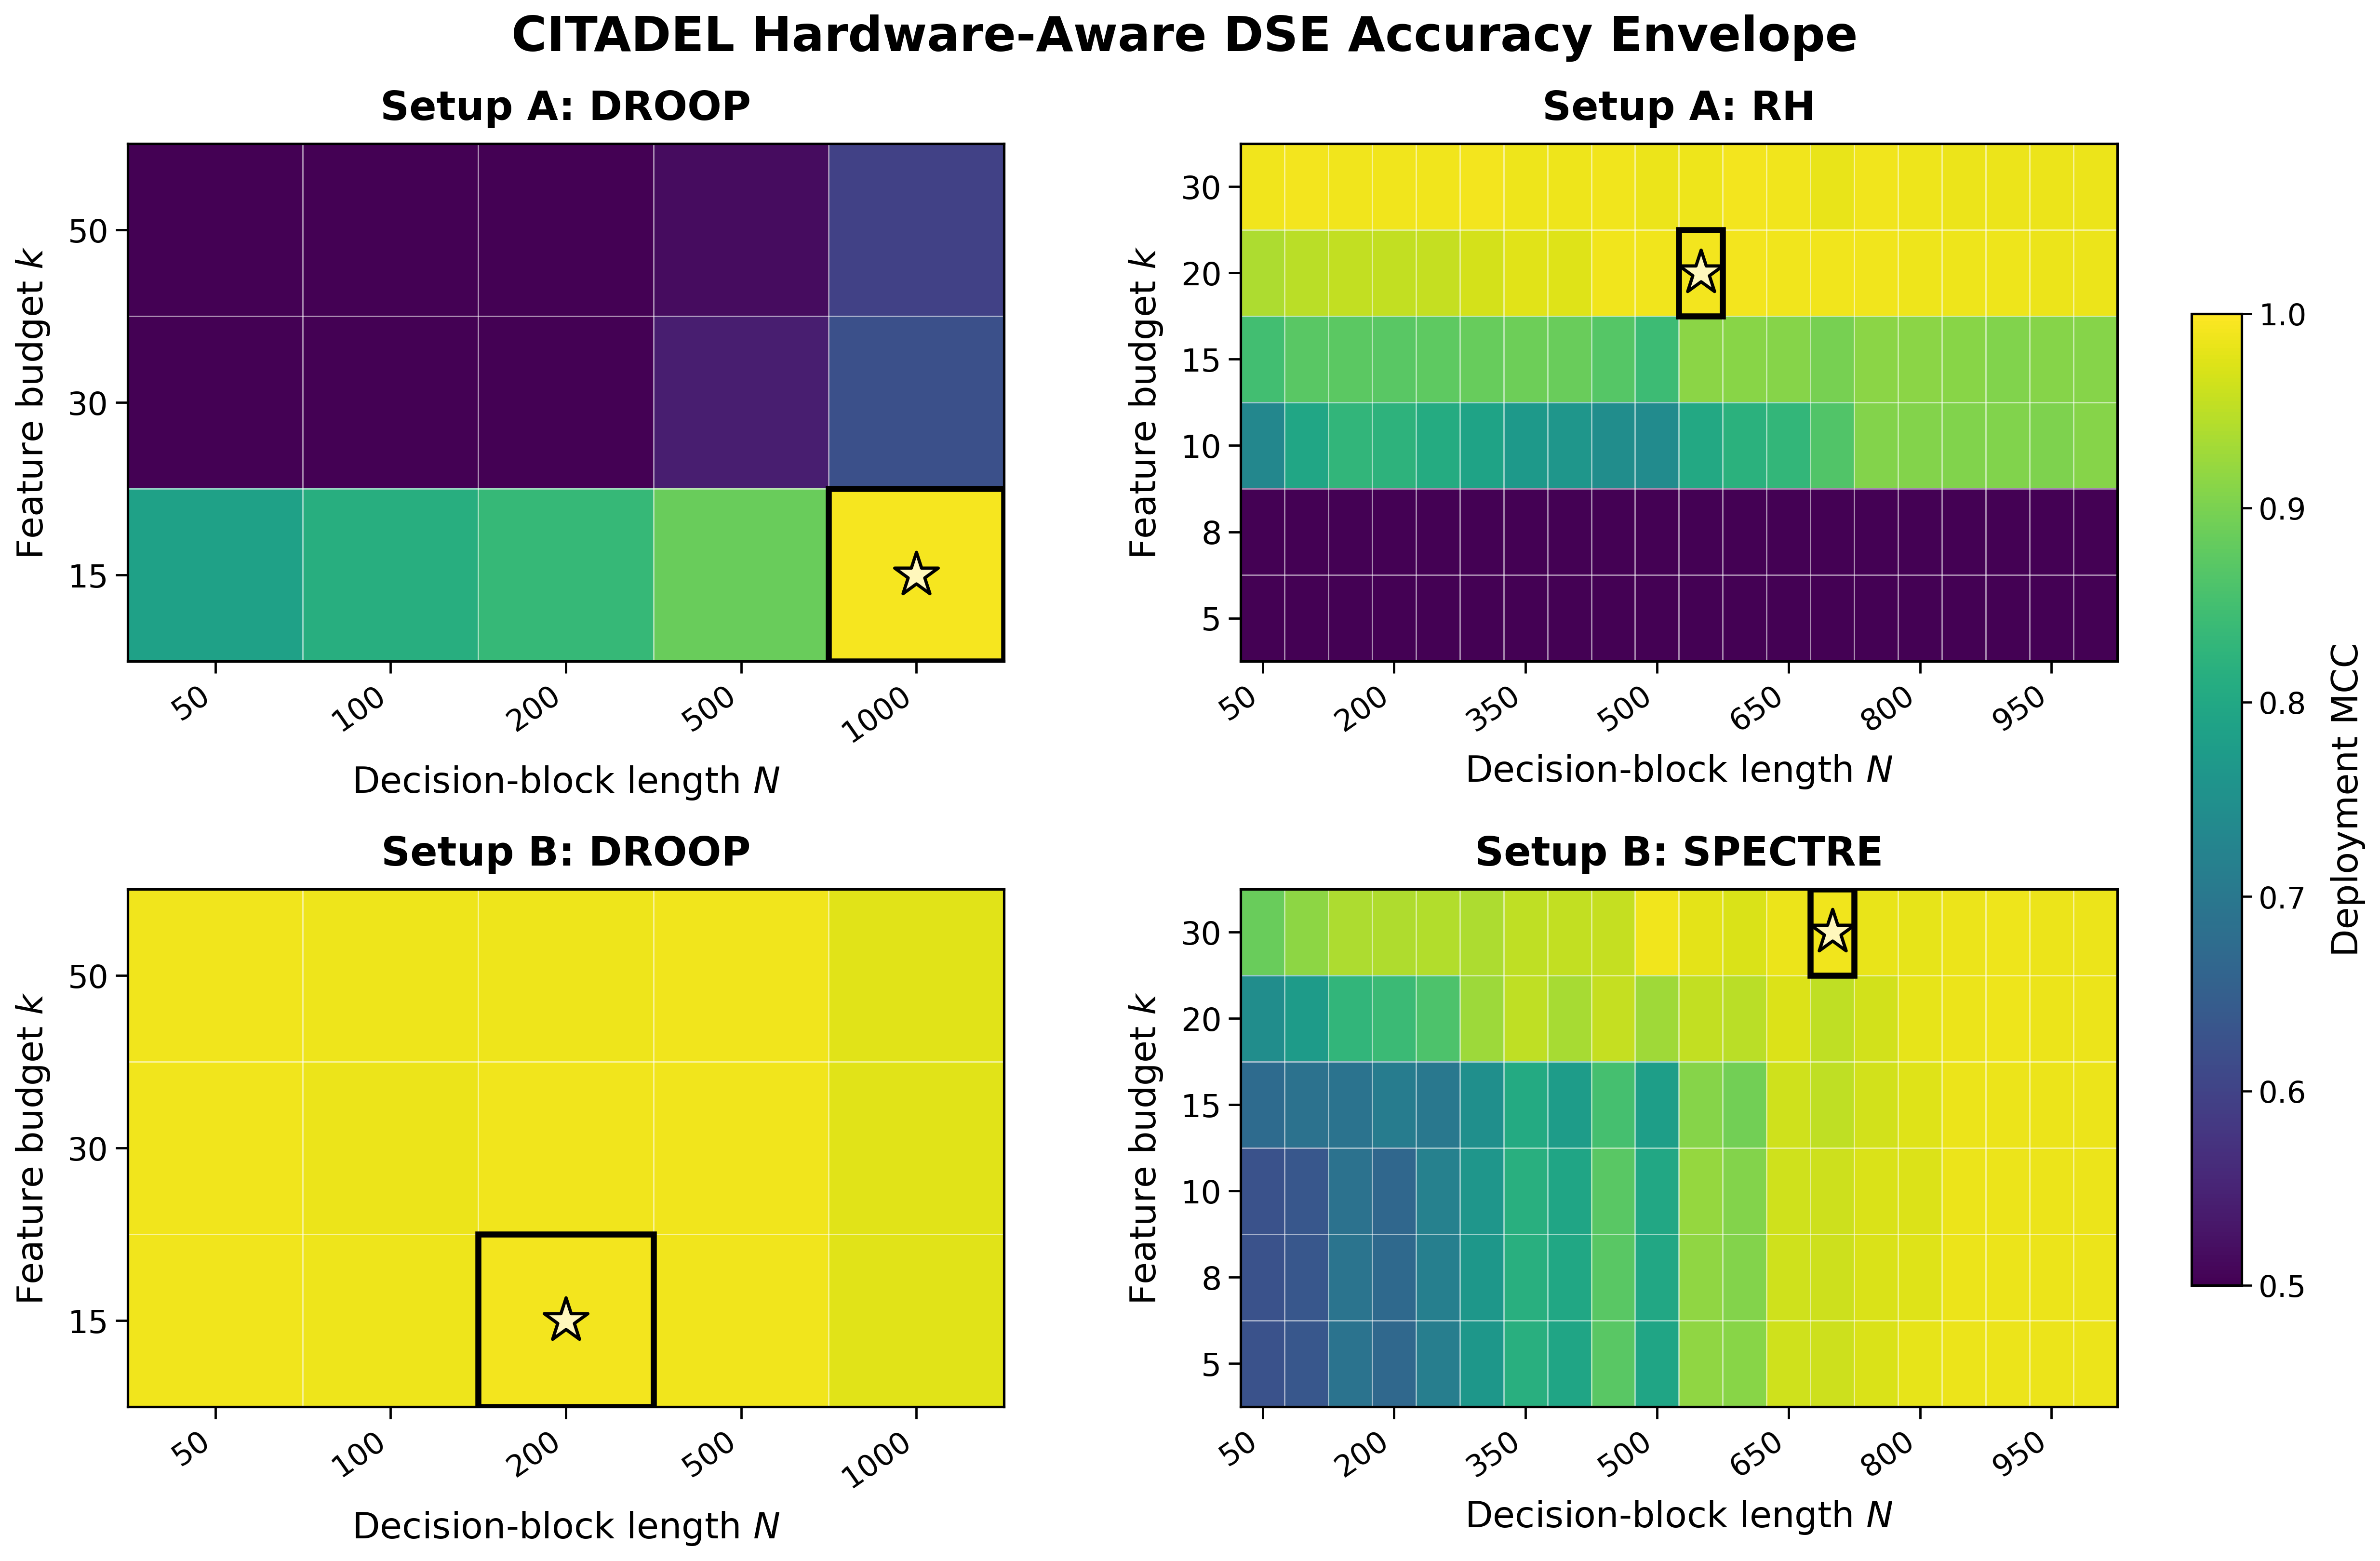

Saved plot: results/notebook_run/tcad_ablation/paper_figures/gallery_fig1_dse_heatmap.png


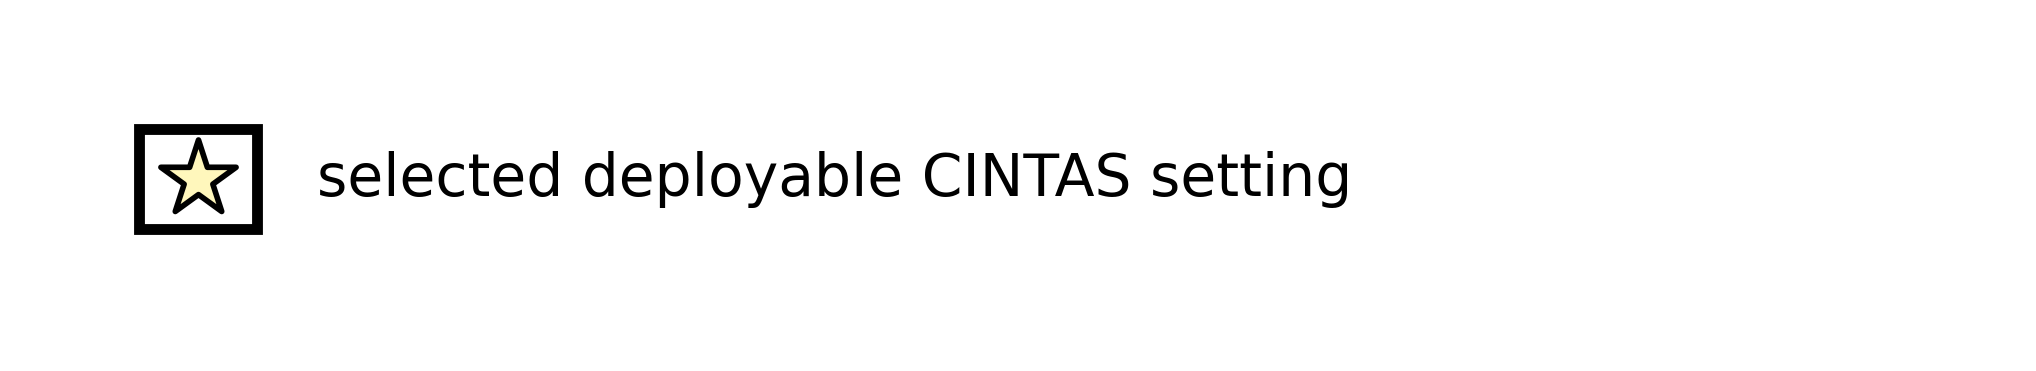

Saved legend: results/notebook_run/tcad_ablation/paper_figures/gallery_fig1_dse_heatmap_legend.png


In [33]:

dse_envelope = (
    gallery_summary.groupby(["setup", "scenario", "top_k", "window_size"], as_index=False)
    .agg(
        best_mcc=("mcc", "max"),
        best_bal_acc=("bal_acc", "max"),
        best_f1=("f1", "max"),
        min_fpr=("fpr", "min"),
    )
)

pairs = (
    dse_envelope[["setup", "scenario"]]
    .drop_duplicates()
    .assign(
        setup=lambda d: d["setup"].astype(str),
        scenario=lambda d: d["scenario"].astype(str),
    )
    .sort_values(["setup", "scenario"])
    [["setup", "scenario"]]
    .itertuples(index=False, name=None)
)
pairs = list(pairs)

if not pairs:
    raise RuntimeError("No DSE rows found. Run the CITADEL DSE first.")

plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 15,
    "ytick.labelsize": 16,
    "figure.titlesize": 23,
    "axes.linewidth": 1.25,
})

ncols = 2
nrows = int(np.ceil(len(pairs) / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(8.6 * ncols, 5.6 * nrows),
    squeeze=False,
)

cmap = plt.get_cmap("mako" if "mako" in plt.colormaps() else "viridis")
vmin, vmax = 0.50, 1.00
last_im = None

for ax, (setup_name, scenario_name) in zip(axes.flat, pairs):
    sub = dse_envelope[
        (dse_envelope["setup"].astype(str) == setup_name)
        & (dse_envelope["scenario"].astype(str) == scenario_name)
    ].copy()

    pivot_mcc = (
        sub.pivot_table(index="top_k", columns="window_size", values="best_mcc", aggfunc="max")
        .sort_index(ascending=False)
    )

    z = np.ma.masked_invalid(pivot_mcc.to_numpy(dtype=float))
    last_im = ax.imshow(
        z,
        aspect="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        interpolation="nearest",
    )

    ax.set_title(f"Setup {setup_name}: {scenario_name}", pad=12, fontweight="bold")
    ax.set_xlabel("Decision-block length $N$", labelpad=8)
    ax.set_ylabel("Feature budget $k$", labelpad=8)

    ax.set_yticks(np.arange(len(pivot_mcc.index)))
    ax.set_yticklabels([str(int(v)) for v in pivot_mcc.index])

    x_positions = np.arange(len(pivot_mcc.columns))
    keep = max(1, int(np.ceil(len(x_positions) / 7)))
    ax.set_xticks(x_positions[::keep])
    ax.set_xticklabels([str(int(v)) for v in pivot_mcc.columns[::keep]], rotation=35, ha="right")

    ax.set_xticks(np.arange(-0.5, len(pivot_mcc.columns), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(pivot_mcc.index), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=0.70, alpha=0.55)
    ax.tick_params(which="major", length=6, width=1.15)
    ax.tick_params(which="minor", bottom=False, left=False)

    if not sub.empty and sub["best_mcc"].notna().any():
        best = (
            sub.sort_values(
                ["best_mcc", "best_bal_acc", "best_f1", "min_fpr"],
                ascending=[False, False, False, True],
                kind="mergesort",
            )
            .iloc[0]
        )

        y = list(pivot_mcc.index).index(best["top_k"])
        x = list(pivot_mcc.columns).index(best["window_size"])

        ax.add_patch(
            plt.Rectangle(
                (x - 0.5, y - 0.5),
                1,
                1,
                fill=False,
                edgecolor="black",
                linewidth=3.0,
                zorder=5,
            )
        )

        ax.scatter(
            [x],
            [y],
            marker="*",
            s=520,
            c="#fff7bc",
            edgecolors="black",
            linewidths=1.6,
            zorder=6,
        )

for ax in axes.flat[len(pairs):]:
    ax.axis("off")

fig.suptitle(
    "CITADEL Hardware-Aware DSE Accuracy Envelope",
    fontsize=24,
    fontweight="bold",
    y=0.975,
)

fig.subplots_adjust(
    left=0.075,
    right=0.875,
    bottom=0.115,
    top=0.895,
    hspace=0.44,
    wspace=0.27,
)

if last_im is not None:
    cax = fig.add_axes([0.905, 0.19, 0.020, 0.60])
    cbar = fig.colorbar(last_im, cax=cax)
    cbar.set_label("Deployment MCC", fontsize=18, labelpad=12)
    cbar.ax.tick_params(labelsize=15, length=5, width=1.1)

fig1_path = GALLERY_DIR / "gallery_fig1_dse_heatmap.png"
fig.savefig(fig1_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)
display(Image(filename=str(fig1_path)))
print(f"Saved plot: {fig1_path.relative_to(REPO_ROOT)}")

# Separate legend PNG with large text.
legend_fig, legend_ax = plt.subplots(figsize=(8.5, 1.35))
legend_ax.axis("off")

legend_ax.add_patch(
    plt.Rectangle(
        (0.055, 0.36),
        0.060,
        0.32,
        fill=False,
        edgecolor="black",
        linewidth=2.6,
        transform=legend_ax.transAxes,
    )
)
legend_ax.scatter(
    [0.085],
    [0.52],
    marker="*",
    s=360,
    c="#fff7bc",
    edgecolors="black",
    linewidths=1.35,
    transform=legend_ax.transAxes,
)

legend_ax.text(
    0.145,
    0.52,
    "selected deployable CINTAS setting",
    va="center",
    ha="left",
    fontsize=14,
    transform=legend_ax.transAxes,
)

legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)

legend_path = GALLERY_DIR / "gallery_fig1_dse_heatmap_legend.png"
legend_fig.savefig(legend_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(legend_fig)
display(Image(filename=str(legend_path)))
print(f"Saved legend: {legend_path.relative_to(REPO_ROOT)}")



### Full integrated stable conditional telemetry graph

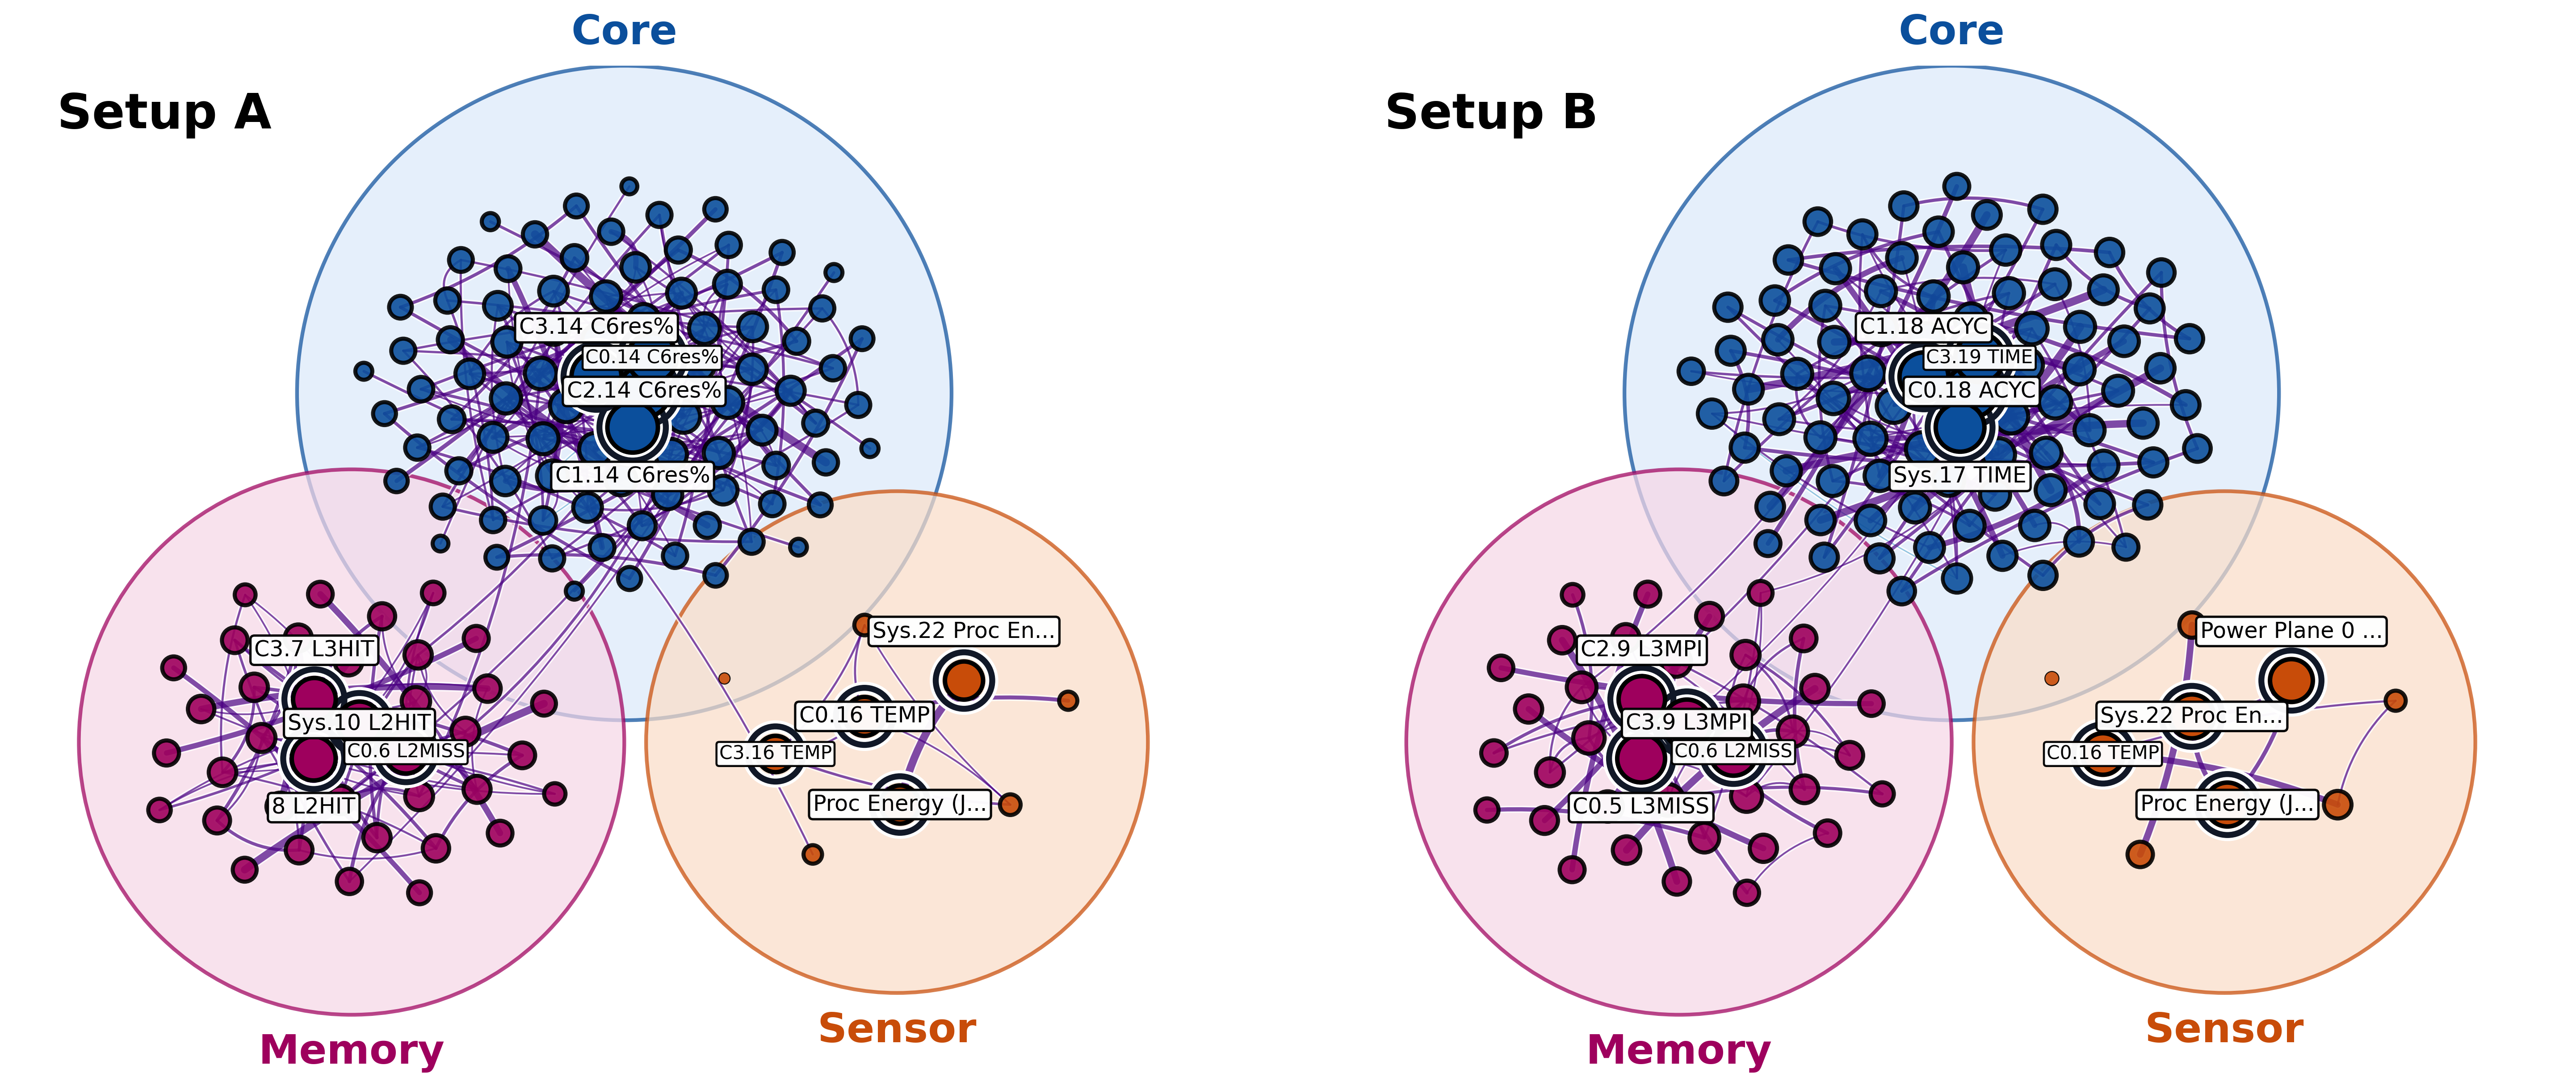

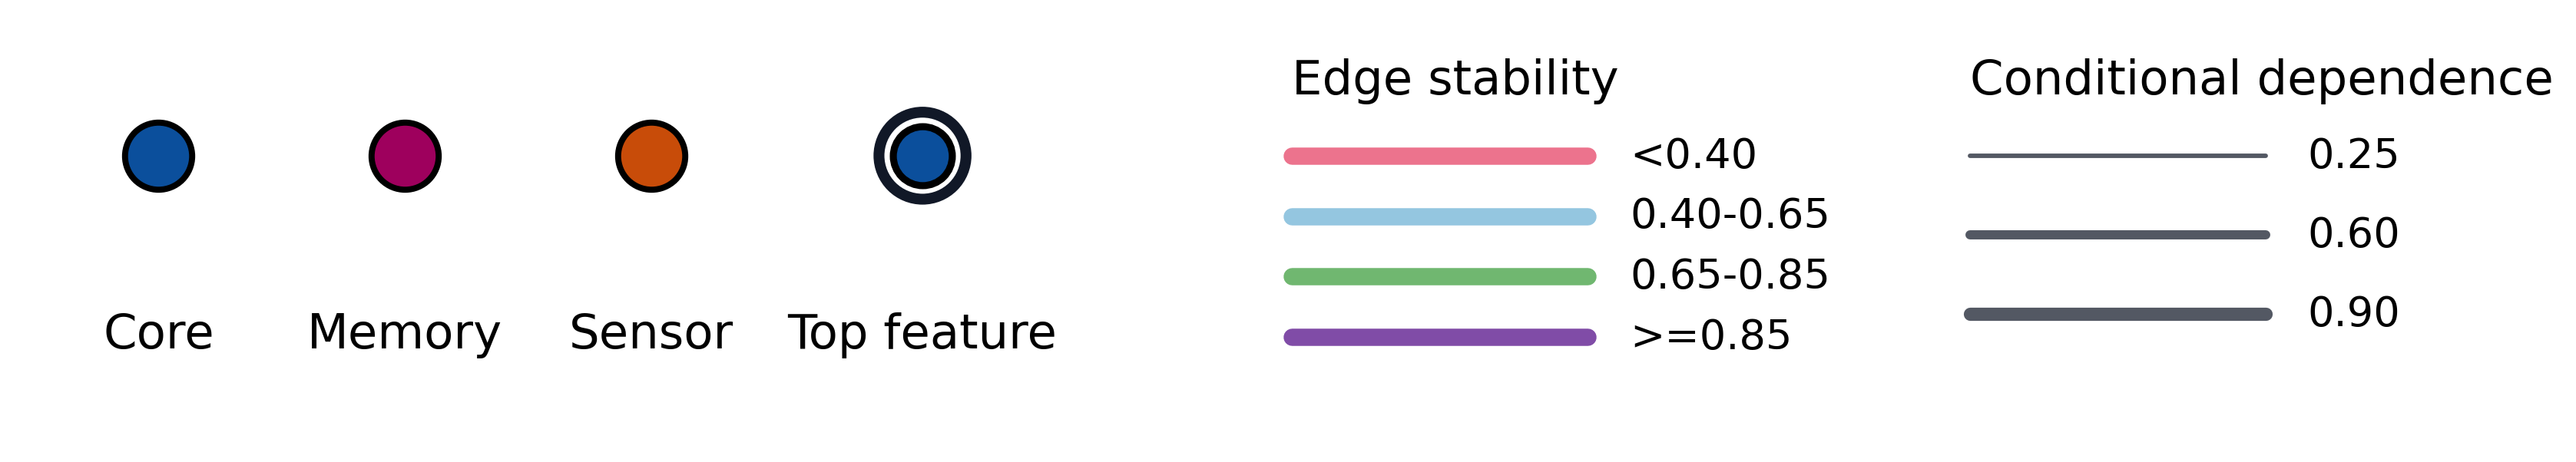

,setup,domain,rank_in_domain,feature,importance_score,node_stability,conditional_dependence,display_score
0,A,CORE,1,Core2 (Socket 0).14_C6res%,1.0000,1.0000,1.0000,1.0000
1,A,CORE,2,Core3 (Socket 0).14_C6res%,0.9120,1.0000,0.9309,0.9428
2,A,CORE,3,Core1 (Socket 0).14_C6res%,0.9411,0.8889,0.9855,0.9228
3,A,CORE,4,Core0 (Socket 0).14_C6res%,0.8635,0.9821,0.8734,0.9050
4,A,MEMORY,1,System.10_L2HIT,0.6196,1.0000,0.6866,0.7527
5,A,MEMORY,2,Socket 0.8_L2HIT,0.6196,1.0000,0.6866,0.7527
6,A,MEMORY,3,Core0 (Socket 0).6_L2MISS,0.5657,1.0000,0.5404,0.7177
7,A,MEMORY,4,Core3 (Socket 0).7_L3HIT,0.5644,1.0000,0.5866,0.7168
8,A,SENSOR,1,Core0 (Socket 0).16_TEMP,0.4058,1.0000,0.4861,0.6138
9,A,SENSOR,2,Proc Energy (Joules)_SKT0,0.3736,1.0000,0.4731,0.5928


Saved figure: results/notebook_run/tcad_ablation/paper_figures/gallery_fig4_full_stable_graph_network.png
Saved legend: results/notebook_run/tcad_ablation/paper_figures/gallery_fig4_full_stable_graph_network_legend.png
Saved top-feature table: results/notebook_run/tcad_ablation/paper_figures/gallery_fig4_top_features_by_domain.csv


In [32]:

from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, Circle

CAUSAL_DIR = TCAD_OUT / "causal"
FIG4_OUT = GALLERY_DIR / "gallery_fig4_full_stable_graph_network.png"
FIG4_LEGEND_OUT = GALLERY_DIR / "gallery_fig4_full_stable_graph_network_legend.png"
FIG4_TOP_FEATURES_OUT = GALLERY_DIR / "gallery_fig4_top_features_by_domain.csv"

TOP_LABELS_PER_DOMAIN = {"CORE": 4, "MEMORY": 4, "SENSOR": 4}

PATS = {
    "memory": [
        r"ddr|dram|mem(ory)?\b",
        r"\bL1(\b|_)|L2(\b|_)|L3(\b|_)",
        r"(L[123].*(HIT|MISS|MPI))\b",
        r"cache|fill|evict|wb|rd|wr|load|store",
        r"bandwidth|bw|throughput|qdepth|queue",
        r"lat(ency)?|stall.*mem|tCCD|tRCD|tRP|tCL|page|row|col",
    ],
    "sensors": [
        r"temp|thermal|hot",
        r"volt|vdd|vcore|vin|vout|cpu[_\- ]?volt|cpu[_\- ]?vdd|vdd[_\- ]?cpu|core[_\- ]?volt|core[_\- ]?voltage",
        r"power|watt|energy|joule",
        r"fan|throttle|current|amps?",
    ],
    "compute": [
        r"\bIPC\b|\bPhysIPC\b|\bEXEC\b|\bissue|retire|dispatch\b",
        r"\bINST\b|INSTnom%|branch|mispred|\balu\b|\barith\b|\blogic\b",
        r"C0res%|C1res%|C6res%|C7res%|CFREQ|AFREQ|ACYC|CYC|TIME|clk|cycle|freq|util",
        r"\bcore|cpu|sm|warp|shader\b",
    ],
}

DOMAIN_ORDER = ["CORE", "MEMORY", "SENSOR"]
DOMAIN_COLORS = {
    "CORE": "#0B4F9C",
    "MEMORY": "#9E005D",
    "SENSOR": "#C84C09",
}
DOMAIN_BG = {
    "CORE": "#DCE9FA",
    "MEMORY": "#F6D7E7",
    "SENSOR": "#FADDC8",
}
DOMAIN_CENTERS = {
    "CORE": (0.00, 0.34),
    "MEMORY": (-0.50, -0.30),
    "SENSOR": (0.50, -0.30),
}

EDGE_STABILITY_COLORS = {
    # EDIT: changed low stability from faint gray to sharp rose-red.
    "low": "#E11D48",
    "medium": "#0077B6",
    "high": "#008000",
    "very_high": "#4B0082",
}


def _edge_stability_style(stability: float) -> tuple[str, float]:
    s = float(np.clip(stability, 0.0, 1.0))

    # EDIT: increased low-stability alpha from 0.22 to 0.62.
    if s < 0.40:
        return EDGE_STABILITY_COLORS["low"], 0.62
    if s < 0.65:
        return EDGE_STABILITY_COLORS["medium"], 0.42
    if s < 0.85:
        return EDGE_STABILITY_COLORS["high"], 0.56
    return EDGE_STABILITY_COLORS["very_high"], 0.70


def _feature_domain(feature: str) -> str:
    text = str(feature)

    for pat in PATS["memory"]:
        if re.search(pat, text, flags=re.IGNORECASE):
            return "MEMORY"
    for pat in PATS["sensors"]:
        if re.search(pat, text, flags=re.IGNORECASE):
            return "SENSOR"
    for pat in PATS["compute"]:
        if re.search(pat, text, flags=re.IGNORECASE):
            return "CORE"

    return "CORE"


def _short_feature_name(name: str, max_len: int = 15) -> str:
    s = str(name)
    s = re.sub(r"Core(\d+) \(Socket 0\)\.", r"C\1.", s)
    s = re.sub(r"Core(\d+)", r"C\1", s)
    s = s.replace("System Core C-States.", "SysC.")
    s = s.replace("SKT0 Core C-State.", "SKT0C.")
    s = s.replace("System.", "Sys.")
    s = s.replace("(ticks)", "")
    s = s.replace("Socket 0.", "")
    s = s.replace("_", " ")
    s = re.sub(r"\s+", " ", s).strip()
    return s if len(s) <= max_len else s[: max_len - 1] + "..."


def _load_setup_graph(setup_name: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    nodes_path = CAUSAL_DIR / f"SETUP_{setup_name}_causal_nodes.csv"
    edges_path = CAUSAL_DIR / f"SETUP_{setup_name}_causal_edges.csv"

    if not nodes_path.exists() or not edges_path.exists():
        raise RuntimeError(f"Missing graph CSVs for Setup {setup_name} under {CAUSAL_DIR}")

    nodes = pd.read_csv(nodes_path)
    edges = pd.read_csv(edges_path)

    edge_features = pd.Index(pd.concat([edges["src"], edges["dst"]], ignore_index=True).dropna().unique())
    node_features = pd.Index(nodes["feature"].dropna().unique())
    missing_features = edge_features.difference(node_features)

    if len(missing_features) > 0:
        nodes = pd.concat([nodes, pd.DataFrame({"feature": missing_features})], ignore_index=True, sort=False)

    nodes["domain"] = nodes["feature"].map(_feature_domain)
    nodes["importance_score"] = pd.to_numeric(nodes.get("importance_score", 0.0), errors="coerce").fillna(0.0)
    nodes["edge_stability"] = pd.to_numeric(nodes.get("edge_stability", 0.0), errors="coerce").fillna(0.0)
    nodes["conditional_dependence"] = pd.to_numeric(nodes.get("conditional_dependence", 0.0), errors="coerce").fillna(0.0)

    edges["src_domain"] = edges["src"].map(_feature_domain)
    edges["dst_domain"] = edges["dst"].map(_feature_domain)
    edges["edge_stability"] = pd.to_numeric(edges.get("edge_stability", 0.0), errors="coerce").fillna(0.0).clip(0.0, 1.0)
    edges["dependence_score"] = pd.to_numeric(
        edges.get("dependence_score", edges.get("abs_rho", 0.0)),
        errors="coerce",
    ).fillna(0.0).clip(0.0, 1.0)
    edges["edge_score"] = edges["edge_stability"] * edges["dependence_score"]
    edges["cross_domain"] = edges["src_domain"] != edges["dst_domain"]

    incident = pd.concat([
        edges[["src", "edge_stability"]].rename(columns={"src": "feature"}),
        edges[["dst", "edge_stability"]].rename(columns={"dst": "feature"}),
    ], ignore_index=True)
    incident_stability = incident.groupby("feature")["edge_stability"].mean()

    nodes["node_stability"] = np.maximum(
        nodes["edge_stability"].fillna(0.0),
        nodes["feature"].map(incident_stability).fillna(0.0),
    ).clip(0.0, 1.0)
    nodes["display_score"] = 0.65 * nodes["importance_score"] + 0.35 * nodes["node_stability"]

    return nodes, edges


def _node_positions(nodes: pd.DataFrame) -> dict[str, tuple[float, float]]:
    pos = {}

    for domain in DOMAIN_ORDER:
        group = nodes[nodes["domain"] == domain].sort_values("display_score", ascending=False).reset_index(drop=True)
        n = len(group)
        if n == 0:
            continue

        cx, cy = DOMAIN_CENTERS[domain]
        base_radius = {"CORE": 0.49, "MEMORY": 0.40, "SENSOR": 0.36}[domain]
        phase = {"CORE": 0.10, "MEMORY": 1.25, "SENSOR": 2.35}[domain]

        for idx, row in group.iterrows():
            angle = (idx * 2.399963 + phase) % (2 * np.pi)
            radius = base_radius * np.sqrt((idx + 0.5) / max(n, 1))

            x = cx + radius * np.cos(angle)
            y = cy + 0.78 * radius * np.sin(angle)
            pos[row["feature"]] = (float(x), float(y))

    return pos


def _draw_curve(ax, p0, p1, dependence: float, stability: float, cross_domain: bool) -> None:
    x0, y0 = p0
    x1, y1 = p1
    mx, my = (x0 + x1) / 2.0, (y0 + y1) / 2.0

    bend = 0.075 if cross_domain else 0.035
    dx, dy = x1 - x0, y1 - y0
    norm = max(np.hypot(dx, dy), 1e-9)
    ctrl = (mx - bend * dy / norm, my + bend * dx / norm)

    path = MplPath([p0, ctrl, p1], [MplPath.MOVETO, MplPath.CURVE3, MplPath.CURVE3])

    color, alpha = _edge_stability_style(stability)
    width = 0.35 + 4.2 * float(np.clip(dependence, 0.0, 1.0))

    # EDIT: white under-stroke improves contrast against domain backgrounds.
    ax.add_patch(
        PathPatch(
            path,
            facecolor="none",
            edgecolor="white",
            linewidth=width + 1.6,
            alpha=0.75,
            capstyle="round",
            joinstyle="round",
            zorder=0.8,
        )
    )

    ax.add_patch(
        PathPatch(
            path,
            facecolor="none",
            edgecolor=color,
            linewidth=width,
            alpha=alpha,
            capstyle="round",
            joinstyle="round",
            zorder=1,
        )
    )


def _top_features_by_domain(nodes: pd.DataFrame, setup_name: str) -> pd.DataFrame:
    rows = []

    for domain in DOMAIN_ORDER:
        top = nodes[nodes["domain"] == domain].nlargest(TOP_LABELS_PER_DOMAIN[domain], "display_score").copy()
        top.insert(0, "rank_in_domain", np.arange(1, len(top) + 1))
        top.insert(0, "setup", setup_name)
        rows.append(top)

    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def _label_box(label: str, x: float, y: float) -> tuple[float, float, float, float]:
    width = 0.030 * max(len(label), 7)
    height = 0.080
    return (x - width / 2, x + width / 2, y - height / 2, y + height / 2)


def _boxes_overlap(a: tuple[float, float, float, float], b: tuple[float, float, float, float]) -> bool:
    return not (a[1] < b[0] or b[1] < a[0] or a[3] < b[2] or b[3] < a[2])


def _place_labels(ax, top_features: pd.DataFrame, pos: dict[str, tuple[float, float]]) -> None:
    used_boxes = []
    offsets = [
        (0.000, 0.000),
        (0.000, 0.090),
        (0.000, -0.090),
        (0.115, 0.000),
        (-0.115, 0.000),
        (0.100, 0.080),
        (-0.100, 0.080),
        (0.100, -0.080),
        (-0.100, -0.080),
    ]

    ordered = top_features.sort_values(["setup", "rank_in_domain"]).copy()

    for row in ordered.itertuples(index=False):
        if row.feature not in pos:
            continue

        x0, y0 = pos[row.feature]
        label = _short_feature_name(row.feature)
        placed = False

        for dx, dy in offsets:
            x = np.clip(x0 + dx, -1.02, 1.02)
            y = np.clip(y0 + dy, -0.82, 0.86)
            box = _label_box(label, x, y)

            if all(not _boxes_overlap(box, used) for used in used_boxes):
                ax.text(
                    x,
                    y,
                    label,
                    ha="center",
                    va="center",
                    fontsize=11.8,
                    color="black",
                    bbox=dict(
                        boxstyle="round,pad=0.18",
                        facecolor="white",
                        edgecolor="black",
                        linewidth=1.25,
                        alpha=0.97,
                    ),
                    zorder=9,
                )
                used_boxes.append(box)
                placed = True
                break

        if not placed:
            ax.text(
                x0,
                y0,
                label,
                ha="center",
                va="center",
                fontsize=10.2,
                color="black",
                bbox=dict(
                    boxstyle="round,pad=0.14",
                    facecolor="white",
                    edgecolor="black",
                    linewidth=1.10,
                    alpha=0.97,
                ),
                zorder=9,
            )


def _draw_setup_panel(ax, setup_name: str) -> pd.DataFrame:
    nodes, edges = _load_setup_graph(setup_name)
    nodes = nodes.sort_values(["domain", "display_score"], ascending=[True, False]).reset_index(drop=True)
    pos = _node_positions(nodes)

    top_features = _top_features_by_domain(nodes, setup_name)
    top_set = set(top_features["feature"])

    ax.set_xlim(-1.12, 1.12)
    ax.set_ylim(-0.90, 0.94)
    ax.set_aspect("equal")
    ax.axis("off")

    for domain in DOMAIN_ORDER:
        cx, cy = DOMAIN_CENTERS[domain]
        ax.add_patch(
            Circle(
                (cx, cy),
                radius={"CORE": 0.60, "MEMORY": 0.50, "SENSOR": 0.46}[domain],
                facecolor=DOMAIN_BG[domain],
                edgecolor=DOMAIN_COLORS[domain],
                linewidth=2.0,
                alpha=0.72,
                zorder=0,
            )
        )

    edges_sorted = edges.sort_values(["edge_stability", "dependence_score"], ascending=[True, True])
    for row in edges_sorted.itertuples(index=False):
        if row.src in pos and row.dst in pos:
            _draw_curve(
                ax,
                pos[row.src],
                pos[row.dst],
                row.dependence_score,
                row.edge_stability,
                bool(row.cross_domain),
            )

    score = nodes.set_index("feature")["importance_score"]
    stability = nodes.set_index("feature")["node_stability"]
    score_max = max(float(score.max()), 1e-9)

    for domain in DOMAIN_ORDER:
        group = nodes[nodes["domain"] == domain]
        xs = [pos[f][0] for f in group["feature"]]
        ys = [pos[f][1] for f in group["feature"]]
        sizes = [34 + 360 * (float(score[f]) / score_max) for f in group["feature"]]
        lines = [0.55 + 1.65 * float(stability[f]) for f in group["feature"]]

        ax.scatter(
            xs,
            ys,
            s=sizes,
            color=DOMAIN_COLORS[domain],
            edgecolors="black",
            linewidths=lines,
            alpha=0.90,
            zorder=3,
        )

    for domain in DOMAIN_ORDER:
        group = nodes[(nodes["domain"] == domain) & (nodes["feature"].isin(top_set))]
        xs = [pos[f][0] for f in group["feature"]]
        ys = [pos[f][1] for f in group["feature"]]
        halo_sizes = [690 + 620 * (float(score[f]) / score_max) for f in group["feature"]]

        ax.scatter(xs, ys, s=halo_sizes, facecolors="none", edgecolors="white", linewidths=6.5, alpha=1.0, zorder=5)
        ax.scatter(xs, ys, s=halo_sizes, facecolors="none", edgecolors="#111827", linewidths=3.2, alpha=1.0, zorder=6)
        ax.scatter(
            xs,
            ys,
            s=[210 + 560 * (float(score[f]) / score_max) for f in group["feature"]],
            color=DOMAIN_COLORS[domain],
            edgecolors="black",
            linewidths=2.4,
            alpha=1.0,
            zorder=7,
        )

    for domain in DOMAIN_ORDER:
        cx, cy = DOMAIN_CENTERS[domain]
        label_y = cy + {"CORE": 0.66, "MEMORY": -0.57, "SENSOR": -0.53}[domain]
        ax.text(cx, label_y, domain.title(), ha="center", va="center", fontsize=22, fontweight="bold", color=DOMAIN_COLORS[domain], zorder=8)

    _place_labels(ax, top_features, pos)

    ax.text(-1.04, 0.85, f"Setup {setup_name}", ha="left", va="center", fontsize=26, fontweight="bold", color="black", zorder=10)

    return top_features


def _draw_legend() -> None:
    fig, ax = plt.subplots(figsize=(13.8, 2.35))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    x0 = 0.055
    for idx, domain in enumerate(DOMAIN_ORDER):
        x = x0 + idx * 0.100
        ax.scatter([x], [0.68], s=440, color=DOMAIN_COLORS[domain], edgecolors="black", linewidths=1.9)
        ax.text(x, 0.25, domain.title(), ha="center", va="center", fontsize=15)

    ax.scatter([0.365], [0.68], s=740, facecolors="none", edgecolors="white", linewidths=7.0)
    ax.scatter([0.365], [0.68], s=740, facecolors="none", edgecolors="#111827", linewidths=3.4)
    ax.scatter([0.365], [0.68], s=340, color="#0B4F9C", edgecolors="black", linewidths=2.2)
    ax.text(0.365, 0.25, "Top feature", ha="center", va="center", fontsize=15)

    ax.text(0.515, 0.86, "Edge stability", ha="left", va="center", fontsize=15)

    # EDIT: legend now uses the same sharper colors/alphas as the plot.
    stability_items = [
        ("<0.40", *_edge_stability_style(0.20)),
        ("0.40-0.65", *_edge_stability_style(0.52)),
        ("0.65-0.85", *_edge_stability_style(0.75)),
        (">=0.85", *_edge_stability_style(0.92)),
    ]

    for idx, (label, color, alpha) in enumerate(stability_items):
        y = 0.68 - idx * 0.145
        ax.plot([0.515, 0.635], [y, y], color="white", linewidth=7.2, alpha=0.85, solid_capstyle="round")
        ax.plot([0.515, 0.635], [y, y], color=color, linewidth=5.4, alpha=alpha, solid_capstyle="round")
        ax.text(
            0.652,
            y,
            label,
            ha="left",
            va="center",
            fontsize=13,
            fontweight="normal",
            color="black",
        )

    ax.text(0.790, 0.86, "Conditional dependence", ha="left", va="center", fontsize=15)
    for idx, value in enumerate([0.25, 0.60, 0.90]):
        y = 0.68 - idx * 0.190
        ax.plot([0.790, 0.910], [y, y], color="#111827", linewidth=0.35 + 4.2 * value, alpha=0.72, solid_capstyle="round")
        ax.text(0.927, y, f"{value:.2f}", ha="left", va="center", fontsize=13)

    fig.savefig(FIG4_LEGEND_OUT, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)


setup_names = [
    path.stem.split("_")[1]
    for path in sorted(CAUSAL_DIR.glob("SETUP_*_causal_nodes.csv"))
]

if not setup_names:
    raise RuntimeError(f"No causal node CSVs found under {CAUSAL_DIR}")

fig, axes = plt.subplots(
    1,
    len(setup_names),
    figsize=(10.0 * len(setup_names), 7.8),
    squeeze=False,
)

top_feature_tables = []
for ax, setup_name in zip(axes.flat, setup_names):
    top_feature_tables.append(_draw_setup_panel(ax, setup_name))

for ax in axes.flat[len(setup_names):]:
    ax.axis("off")

fig.subplots_adjust(left=0.012, right=0.988, bottom=0.025, top=0.985, wspace=0.030)

top_features_by_domain = pd.concat(top_feature_tables, ignore_index=True)
top_features_by_domain = top_features_by_domain[
    [
        "setup",
        "domain",
        "rank_in_domain",
        "feature",
        "importance_score",
        "node_stability",
        "conditional_dependence",
        "display_score",
    ]
]
top_features_by_domain.to_csv(FIG4_TOP_FEATURES_OUT, index=False)

fig.savefig(FIG4_OUT, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)

_draw_legend()

display(Image(filename=str(FIG4_OUT)))
display(Image(filename=str(FIG4_LEGEND_OUT)))
display(top_features_by_domain.round(4))

print(f"Saved figure: {FIG4_OUT.relative_to(REPO_ROOT)}")
print(f"Saved legend: {FIG4_LEGEND_OUT.relative_to(REPO_ROOT)}")
print(f"Saved top-feature table: {FIG4_TOP_FEATURES_OUT.relative_to(REPO_ROOT)}")



### Unified stable conditional feature compass

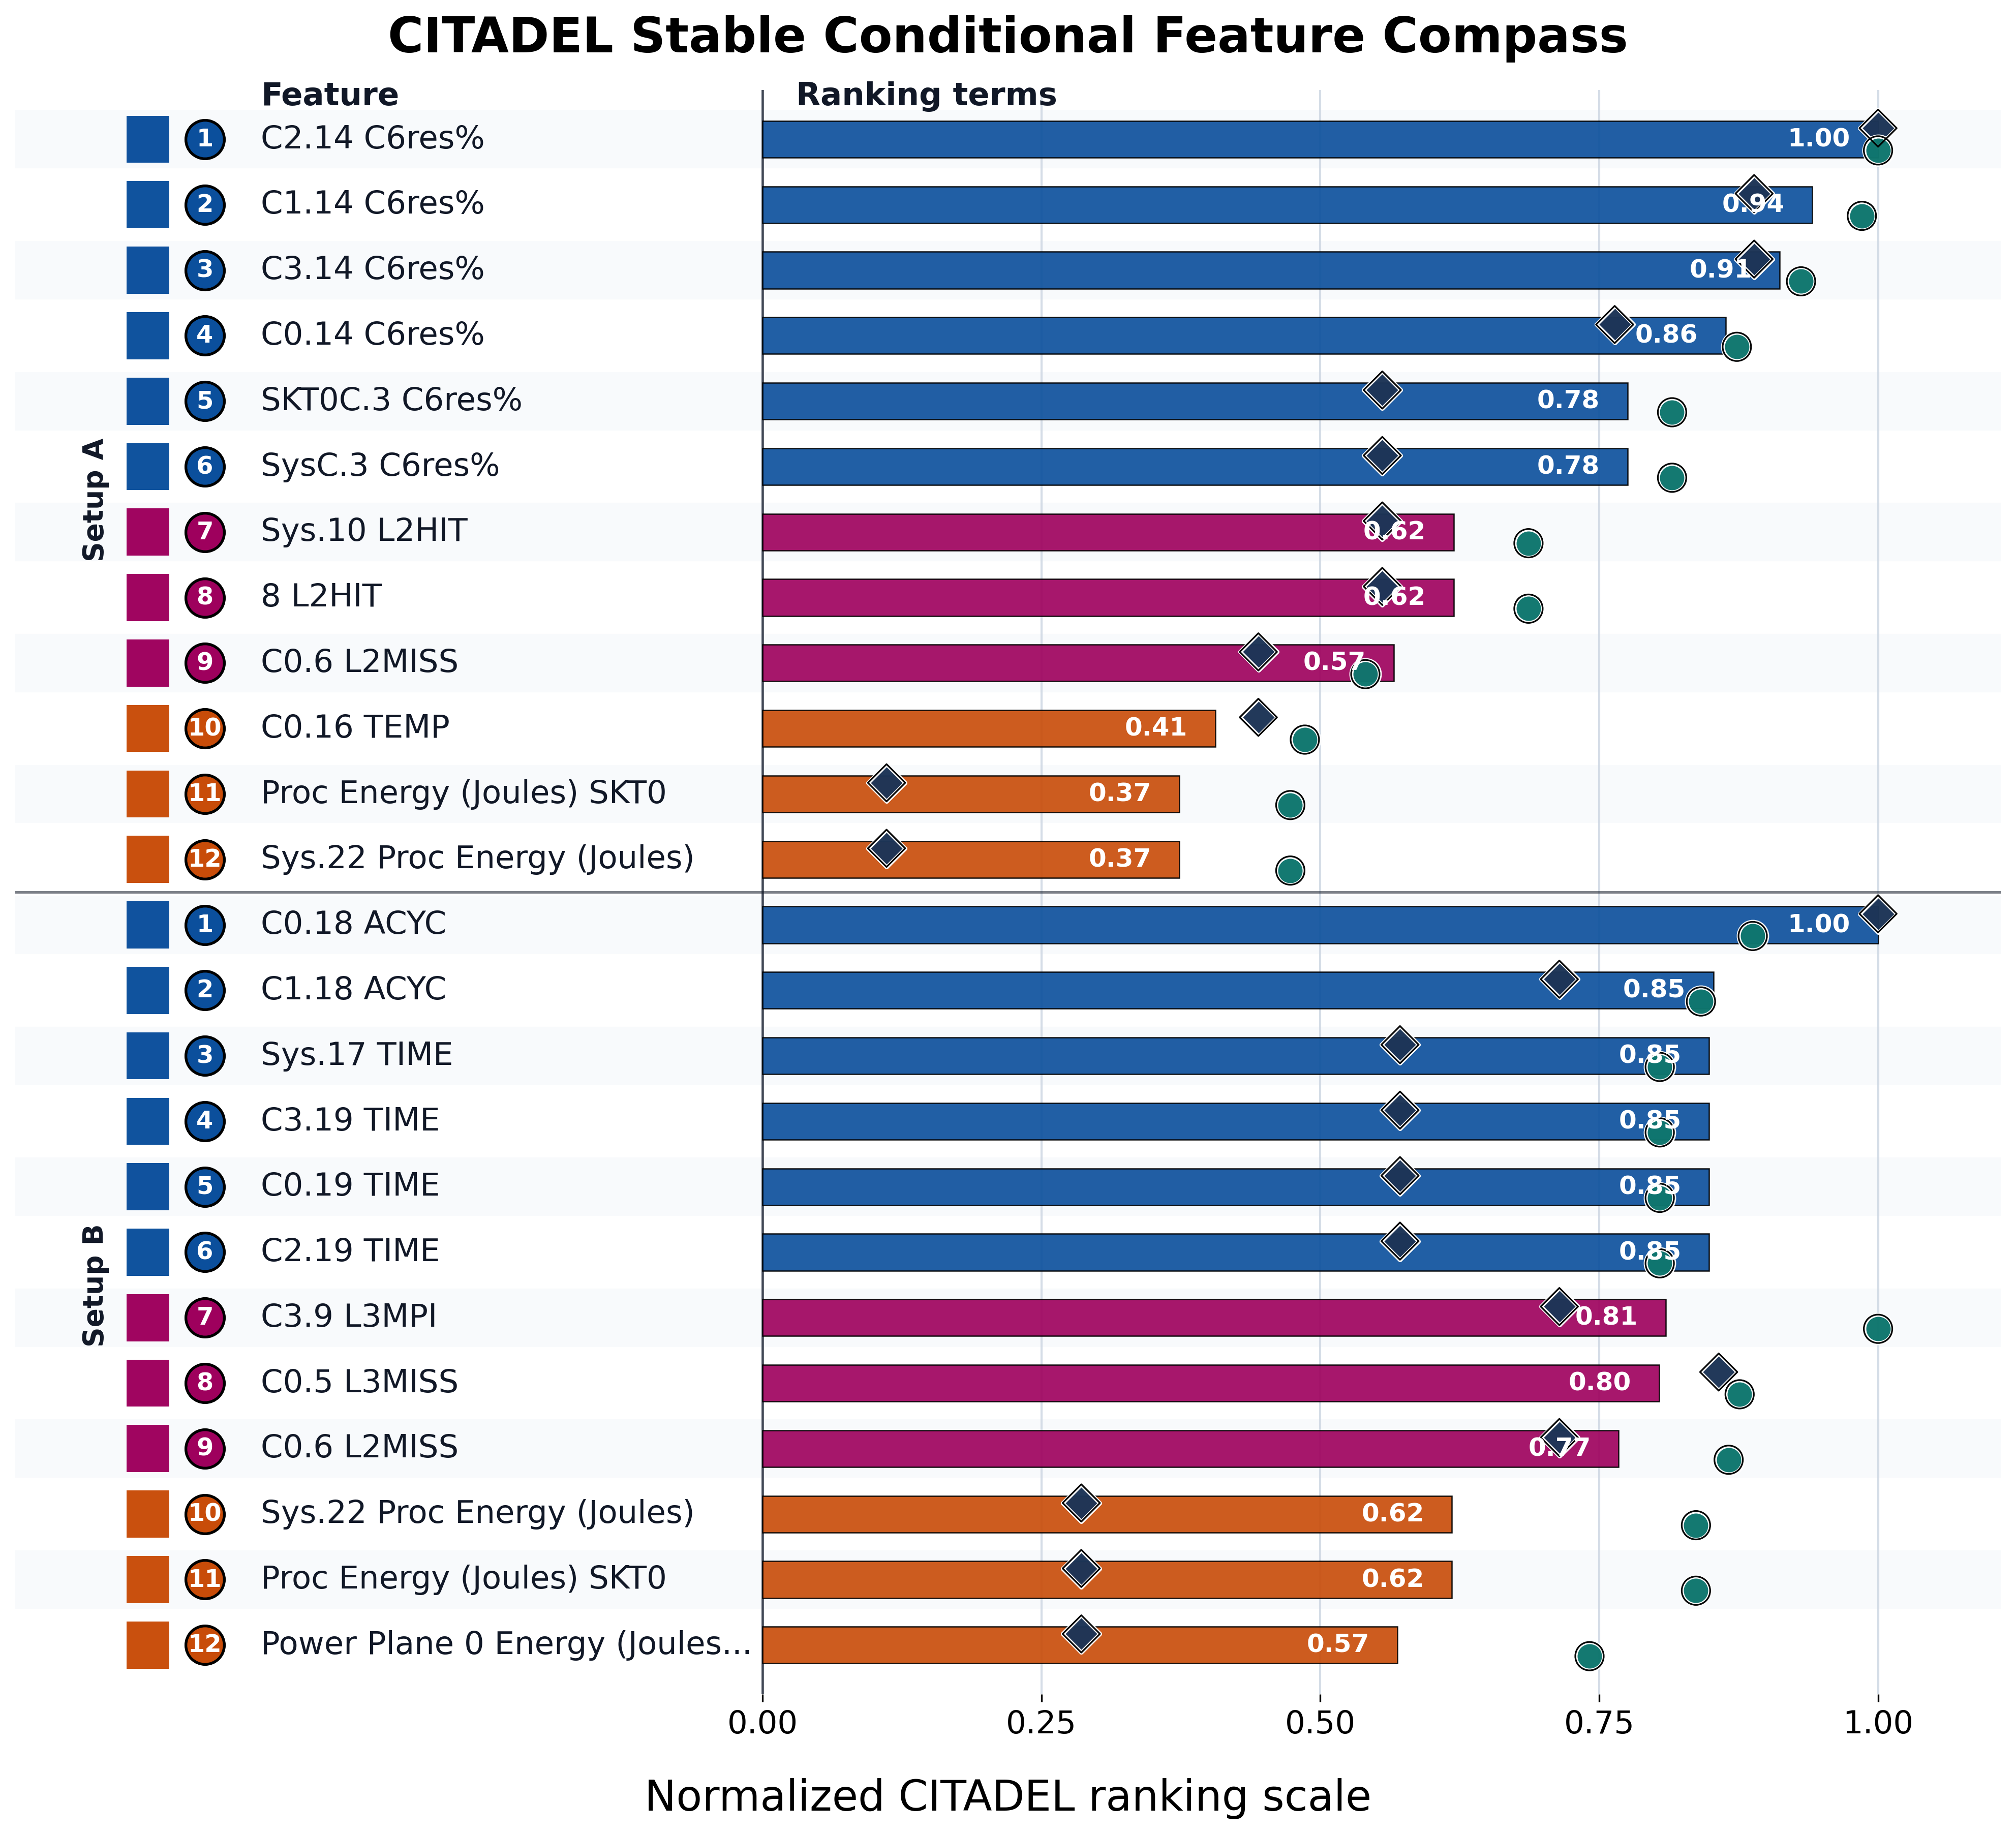

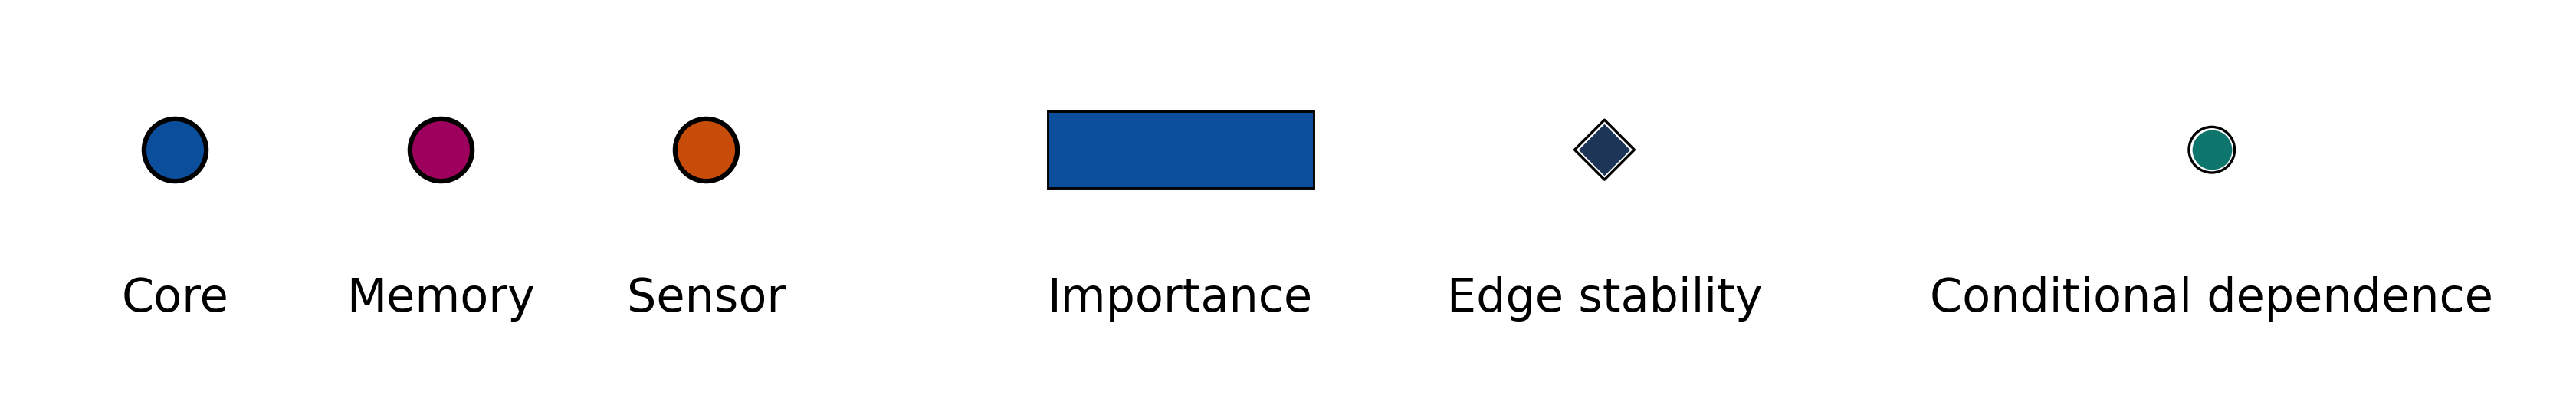

,setup,domain,rank_in_plot,rank,feature,importance_score,edge_stability,conditional_dependence,display_score
0,A,CORE,1,1,Core2 (Socket 0).14_C6res%,1.0000,1.0000,1.0000,1.0000
1,A,CORE,2,2,Core1 (Socket 0).14_C6res%,0.9411,0.8889,0.9855,0.9411
2,A,CORE,3,3,Core3 (Socket 0).14_C6res%,0.9120,0.8889,0.9309,0.9120
3,A,CORE,4,4,Core0 (Socket 0).14_C6res%,0.8635,0.7639,0.8734,0.8635
4,A,CORE,5,5,SKT0 Core C-State.3_C6res%,0.7755,0.5556,0.8153,0.7755
5,A,CORE,6,6,System Core C-States.3_C6res%,0.7755,0.5556,0.8153,0.7755
6,A,MEMORY,7,22,System.10_L2HIT,0.6196,0.5556,0.6866,0.6196
7,A,MEMORY,8,23,Socket 0.8_L2HIT,0.6196,0.5556,0.6866,0.6196
8,A,MEMORY,9,35,Core0 (Socket 0).6_L2MISS,0.5657,0.4444,0.5404,0.5657
9,A,SENSOR,10,77,Core0 (Socket 0).16_TEMP,0.4058,0.4444,0.4861,0.4058


Saved figure: results/notebook_run/tcad_ablation/paper_figures/gallery_fig5_stable_feature_compass.png
Saved legend: results/notebook_run/tcad_ablation/paper_figures/gallery_fig5_stable_feature_compass_legend.png
Saved feature rows: results/notebook_run/tcad_ablation/paper_figures/gallery_fig5_stable_feature_compass_rows.csv


In [15]:

FIG5_OUT = GALLERY_DIR / "gallery_fig5_stable_feature_compass.png"
FIG5_LEGEND_OUT = GALLERY_DIR / "gallery_fig5_stable_feature_compass_legend.png"
FIG5_TABLE_OUT = GALLERY_DIR / "gallery_fig5_stable_feature_compass_rows.csv"

CAUSAL_DIR = TCAD_OUT / "causal"

TARGET_FEATURES_PER_SETUP = 12
MIN_FEATURES_PER_DOMAIN = {"CORE": 3, "MEMORY": 3, "SENSOR": 3}

PATS = {
    "memory": [
        r"ddr|dram|mem(ory)?\b",
        r"\bL1(\b|_)|L2(\b|_)|L3(\b|_)",
        r"(L[123].*(HIT|MISS|MPI))\b",
        r"cache|fill|evict|wb|rd|wr|load|store",
        r"bandwidth|bw|throughput|qdepth|queue",
        r"lat(ency)?|stall.*mem|tCCD|tRCD|tRP|tCL|page|row|col",
    ],
    "sensors": [
        r"temp|thermal|hot",
        r"volt|vdd|vcore|vin|vout|cpu[_\- ]?volt|cpu[_\- ]?vdd|vdd[_\- ]?cpu|core[_\- ]?volt|core[_\- ]?voltage",
        r"power|watt|energy|joule",
        r"fan|throttle|current|amps?",
    ],
    "compute": [
        r"\bIPC\b|\bPhysIPC\b|\bEXEC\b|\bissue|retire|dispatch\b",
        r"\bINST\b|INSTnom%|branch|mispred|\balu\b|\barith\b|\blogic\b",
        r"C0res%|C1res%|C6res%|C7res%|CFREQ|AFREQ|ACYC|CYC|TIME|clk|cycle|freq|util",
        r"\bcore|cpu|sm|warp|shader\b",
    ],
}

DOMAIN_ORDER = ["CORE", "MEMORY", "SENSOR"]
DOMAIN_COLORS = {
    "CORE": "#0B4F9C",
    "MEMORY": "#9E005D",
    "SENSOR": "#C84C09",
}
METRIC_COLORS = {
    "edge_stability": "#1D3557",
    "conditional_dependence": "#0F766E",
}


def _feature_domain_from_name(feature: str) -> str:
    text = str(feature)

    for pat in PATS["memory"]:
        if re.search(pat, text, flags=re.IGNORECASE):
            return "MEMORY"
    for pat in PATS["sensors"]:
        if re.search(pat, text, flags=re.IGNORECASE):
            return "SENSOR"
    for pat in PATS["compute"]:
        if re.search(pat, text, flags=re.IGNORECASE):
            return "CORE"

    return "CORE"


def _normalize_domain_name(domain_value: str, feature: str) -> str:
    text = str(domain_value).strip().upper()

    if text in {"MEMORY", "MEM", "CACHE", "DRAM", "DDR"}:
        return "MEMORY"
    if text in {"SENSOR", "SENSORS", "POWER", "THERMAL", "VOLTAGE"}:
        return "SENSOR"
    if text in {"CORE", "COMPUTE", "CPU", "SYSTEM", "HOST"}:
        return "CORE"

    return _feature_domain_from_name(feature)


def _short_feature_label(name: str, max_len: int = 31) -> str:
    s = str(name)
    s = s.replace("Core0 (Socket 0).", "C0.")
    s = s.replace("Core1 (Socket 0).", "C1.")
    s = s.replace("Core2 (Socket 0).", "C2.")
    s = s.replace("Core3 (Socket 0).", "C3.")
    s = s.replace("System Core C-States.", "SysC.")
    s = s.replace("SKT0 Core C-State.", "SKT0C.")
    s = s.replace("System.", "Sys.")
    s = s.replace("(ticks)", "")
    s = s.replace("Socket 0.", "")
    s = s.replace("_", " ")
    s = " ".join(s.split())
    return s if len(s) <= max_len else s[: max_len - 3] + "..."


def _load_full_feature_rank_table() -> pd.DataFrame:
    rank_rows = []

    for rank_path in sorted(CAUSAL_DIR.glob("SETUP_*_feature_ranks.csv")):
        setup_name = rank_path.stem.split("_")[1]
        ranks = pd.read_csv(rank_path).copy()

        if "feature" not in ranks.columns:
            continue

        ranks.insert(0, "setup", setup_name)
        if "rank" not in ranks.columns:
            ranks.insert(1, "rank", np.arange(1, len(ranks) + 1))

        rank_rows.append(ranks)

    if rank_rows:
        return pd.concat(rank_rows, ignore_index=True, sort=False)

    return table4.copy()


def _prepare_feature_compass_rows() -> pd.DataFrame:
    rows = _load_full_feature_rank_table()

    if rows.empty:
        return rows

    if "setup" not in rows.columns:
        rows["setup"] = "A"
    if "rank" not in rows.columns:
        rows["rank"] = rows.groupby("setup").cumcount() + 1
    if "domain" not in rows.columns:
        rows["domain"] = np.nan

    rows["setup"] = rows["setup"].astype(str)
    rows["feature"] = rows["feature"].astype(str)
    rows["domain"] = [
        _normalize_domain_name(domain_value, feature)
        for domain_value, feature in zip(rows["domain"], rows["feature"])
    ]

    for col in ["importance_score", "edge_stability", "conditional_dependence"]:
        if col not in rows.columns:
            rows[col] = np.nan
        rows[col] = pd.to_numeric(rows[col], errors="coerce")

    rows["importance_score"] = rows["importance_score"].fillna(0.0).clip(0.0, 1.0)
    rows["edge_stability"] = rows["edge_stability"].clip(0.0, 1.0)
    rows["conditional_dependence"] = rows["conditional_dependence"].clip(0.0, 1.0)
    rows["display_score"] = rows["importance_score"].fillna(0.0)

    selected_parts = []
    for setup_name, setup_rows in rows.groupby("setup", sort=True):
        setup_rows = setup_rows.sort_values(
            ["display_score", "importance_score"],
            ascending=[False, False],
            kind="mergesort",
        )

        selected_index = set()

        for domain in DOMAIN_ORDER:
            part = setup_rows[setup_rows["domain"] == domain].nlargest(
                MIN_FEATURES_PER_DOMAIN[domain],
                "display_score",
            )
            selected_index.update(part.index.tolist())

        remaining_slots = max(TARGET_FEATURES_PER_SETUP - len(selected_index), 0)
        if remaining_slots > 0:
            fill = setup_rows[~setup_rows.index.isin(selected_index)].nlargest(
                remaining_slots,
                "display_score",
            )
            selected_index.update(fill.index.tolist())

        selected = setup_rows.loc[list(selected_index)].copy()
        selected["domain_order"] = selected["domain"].map({d: i for i, d in enumerate(DOMAIN_ORDER)}).fillna(0)
        selected = selected.sort_values(
            ["display_score", "domain_order", "rank"],
            ascending=[False, True, True],
            kind="mergesort",
        )
        selected["rank_in_plot"] = np.arange(1, len(selected) + 1)
        selected_parts.append(selected)

    plot_rows = pd.concat(selected_parts, ignore_index=True, sort=False)
    plot_rows["short_feature"] = plot_rows["feature"].map(_short_feature_label)
    plot_rows["row_label"] = plot_rows["short_feature"]

    return plot_rows.reset_index(drop=True)


def _draw_setup_strips(ax, rows: pd.DataFrame, label_left: float) -> None:
    setup_values = rows["setup"].astype(str).tolist()
    if not setup_values:
        return

    ranges = []
    start = 0
    for i in range(1, len(setup_values)):
        if setup_values[i] != setup_values[i - 1]:
            ranges.append((setup_values[start], start, i - 1))
            start = i
    ranges.append((setup_values[start], start, len(setup_values) - 1))

    strip_x = label_left + 0.018
    strip_w = 0.108

    for setup_name, first, last in ranges:
        y0 = first - 0.43
        height = (last - first + 1) * 0.86
        y_mid = (first + last) / 2

        ax.text(
            strip_x + strip_w / 2,
            y_mid,
            f"Setup {setup_name}",
            ha="center",
            va="center",
            rotation=90,
            fontsize=13.2,
            fontweight="bold",
            color="#111827",
            zorder=7,
        )

        if first > 0:
            ax.axhline(first - 0.5, color="#111827", linewidth=1.20, alpha=0.55, zorder=2)


def _draw_unified_feature_compass(rows: pd.DataFrame) -> plt.Figure:
    rows = rows.copy().reset_index(drop=True)
    n = len(rows)
    y = np.arange(n)

    label_left = -0.78
    rank_x = -0.610
    label_x = -0.560
    score_left = -0.11

    fig, ax = plt.subplots(figsize=(16.8, max(7.8, 0.49 * n + 1.9)), dpi=180)
    ax.set_xlim(label_left, 1)
    ax.set_ylim(-0.75, n - 0.25)
    ax.invert_yaxis()

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_yticks([])
    ax.set_xticks([score_left + v for v in [0.0, 0.25, 0.50, 0.75, 1.0]])
    ax.set_xticklabels(["0.00", "0.25", "0.50", "0.75", "1.00"])
    ax.tick_params(axis="x", labelsize=15)
    ax.grid(axis="x", color="#CBD5E1", alpha=0.80, linewidth=1.0, zorder=0)

    ax.axvline(score_left, color="#111827", linewidth=1.1, alpha=0.75, zorder=2)

    for i in y:
        if i % 2 == 0:
            ax.axhspan(i - 0.43, i + 0.43, color="#F8FAFC", zorder=0)

    _draw_setup_strips(ax, rows, label_left)

    for i, row in rows.iterrows():
        domain = row["domain"]
        domain_color = DOMAIN_COLORS[domain]

        ax.add_patch(
            plt.Rectangle(
                (rank_x - 0.070, i - 0.36),
                0.038,
                0.72,
                facecolor=domain_color,
                edgecolor="none",
                alpha=0.98,
                zorder=2,
            )
        )

        ax.scatter(
            [rank_x],
            [i],
            s=330,
            color=domain_color,
            edgecolors="black",
            linewidths=1.3,
            zorder=4,
        )
        ax.text(
            rank_x,
            i,
            str(int(row["rank_in_plot"])),
            ha="center",
            va="center",
            fontsize=11.5,
            fontweight="bold",
            color="white",
            zorder=5,
        )

        ax.text(
            label_x,
            i,
            row["row_label"],
            ha="left",
            va="center",
            fontsize=15,
            color="#111827",
            zorder=5,
        )

    bar_colors = [DOMAIN_COLORS[d] for d in rows["domain"]]
    values = rows["importance_score"].to_numpy(dtype=float)

    ax.barh(
        y,
        values,
        left=score_left,
        height=0.56,
        color=bar_colors,
        edgecolor="black",
        linewidth=0.60,
        alpha=0.91,
        zorder=3,
    )

    for i, value in enumerate(values):
        if value >= 0.12:
            ax.text(
                score_left + max(value - 0.025, 0.055),
                i,
                f"{value:.2f}",
                ha="right",
                va="center",
                fontsize=12.0,
                fontweight="bold",
                color="white",
                zorder=8,
            )
        else:
            ax.text(
                score_left + value + 0.020,
                i,
                f"{value:.2f}",
                ha="left",
                va="center",
                fontsize=11.4,
                fontweight="bold",
                color="#111827",
                zorder=8,
            )

    if rows["edge_stability"].notna().any():
        ax.scatter(
            score_left + rows["edge_stability"].fillna(0.0),
            y - 0.17,
            s=155,
            marker="D",
            color=METRIC_COLORS["edge_stability"],
            edgecolors="white",
            linewidths=1.9,
            alpha=0.98,
            zorder=6,
        )
        ax.scatter(
            score_left + rows["edge_stability"].fillna(0.0),
            y - 0.17,
            s=155,
            marker="D",
            facecolors="none",
            edgecolors="black",
            linewidths=0.78,
            alpha=0.98,
            zorder=7,
        )

    if rows["conditional_dependence"].notna().any():
        ax.scatter(
            score_left + rows["conditional_dependence"].fillna(0.0),
            y + 0.17,
            s=180,
            marker="o",
            color=METRIC_COLORS["conditional_dependence"],
            edgecolors="white",
            linewidths=1.9,
            alpha=0.98,
            zorder=6,
        )
        ax.scatter(
            score_left + rows["conditional_dependence"].fillna(0.0),
            y + 0.17,
            s=180,
            marker="o",
            facecolors="none",
            edgecolors="black",
            linewidths=0.78,
            alpha=0.98,
            zorder=7,
        )

    ax.text(
        label_x,
        -0.66,
        "Feature",
        ha="left",
        va="center",
        fontsize=15,
        fontweight="bold",
        color="#111827",
    )
    ax.text(
        score_left+0.03,
        -0.66,
        "Ranking terms",
        ha="left",
        va="center",
        fontsize=15,
        fontweight="bold",
        color="#111827",
    )

    ax.set_xlabel("Normalized CITADEL ranking scale", fontsize=20, labelpad=18)
    ax.set_title(
        "CITADEL Stable Conditional Feature Compass",
        fontsize=23,
        fontweight="bold",
        pad=18,
    )

    return fig


def _draw_unified_feature_compass_legend() -> None:
    fig, ax = plt.subplots(figsize=(14.2, 2.05), dpi=180)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    x0 = 0.06
    for idx, domain in enumerate(DOMAIN_ORDER):
        x = x0 + idx * 0.105
        ax.scatter(
            [x],
            [0.65],
            s=380,
            color=DOMAIN_COLORS[domain],
            edgecolors="black",
            linewidths=1.5,
        )
        ax.text(x, 0.24, domain.title(), ha="center", va="center", fontsize=14.5)

    ax.barh(
        [0.65],
        [0.105],
        left=[0.405],
        height=0.21,
        color=DOMAIN_COLORS["CORE"],
        edgecolor="black",
        linewidth=0.7,
    )
    ax.text(0.457, 0.24, "Importance", ha="center", va="center", fontsize=14.5)

    ax.scatter(
        [0.625],
        [0.65],
        s=175,
        marker="D",
        color=METRIC_COLORS["edge_stability"],
        edgecolors="white",
        linewidths=1.8,
    )
    ax.scatter(
        [0.625],
        [0.65],
        s=175,
        marker="D",
        facecolors="none",
        edgecolors="black",
        linewidths=0.8,
    )
    ax.text(0.625, 0.24, "Edge stability", ha="center", va="center", fontsize=14.5)

    ax.scatter(
        [0.865],
        [0.65],
        s=205,
        marker="o",
        color=METRIC_COLORS["conditional_dependence"],
        edgecolors="white",
        linewidths=1.9,
    )
    ax.scatter(
        [0.865],
        [0.65],
        s=205,
        marker="o",
        facecolors="none",
        edgecolors="black",
        linewidths=0.8,
    )
    ax.text(0.865, 0.24, "Conditional dependence", ha="center", va="center", fontsize=14.5)

    fig.savefig(FIG5_LEGEND_OUT, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)


plot_features = _prepare_feature_compass_rows()

if plot_features.empty:
    fig, ax = plt.subplots(figsize=(9.0, 2.6))
    ax.axis("off")
    ax.text(
        0.5,
        0.5,
        "Run Section 7 to generate stable graph feature ranks.",
        ha="center",
        va="center",
        fontsize=14,
    )
    fig.savefig(FIG5_OUT, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)
else:
    keep_cols = [
        "setup",
        "domain",
        "rank_in_plot",
        "rank",
        "feature",
        "importance_score",
        "edge_stability",
        "conditional_dependence",
        "display_score",
    ]
    plot_features[[c for c in keep_cols if c in plot_features.columns]].to_csv(FIG5_TABLE_OUT, index=False)

    fig = _draw_unified_feature_compass(plot_features)
    fig.savefig(FIG5_OUT, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)

    _draw_unified_feature_compass_legend()

display(Image(filename=str(FIG5_OUT)))
if FIG5_LEGEND_OUT.exists():
    display(Image(filename=str(FIG5_LEGEND_OUT)))
if not plot_features.empty:
    display(plot_features[[c for c in keep_cols if c in plot_features.columns]].round(4))

print(f"Saved figure: {FIG5_OUT.relative_to(REPO_ROOT)}")
if FIG5_LEGEND_OUT.exists():
    print(f"Saved legend: {FIG5_LEGEND_OUT.relative_to(REPO_ROOT)}")
if not plot_features.empty:
    print(f"Saved feature rows: {FIG5_TABLE_OUT.relative_to(REPO_ROOT)}")


### Lifecycle benign-drift trend

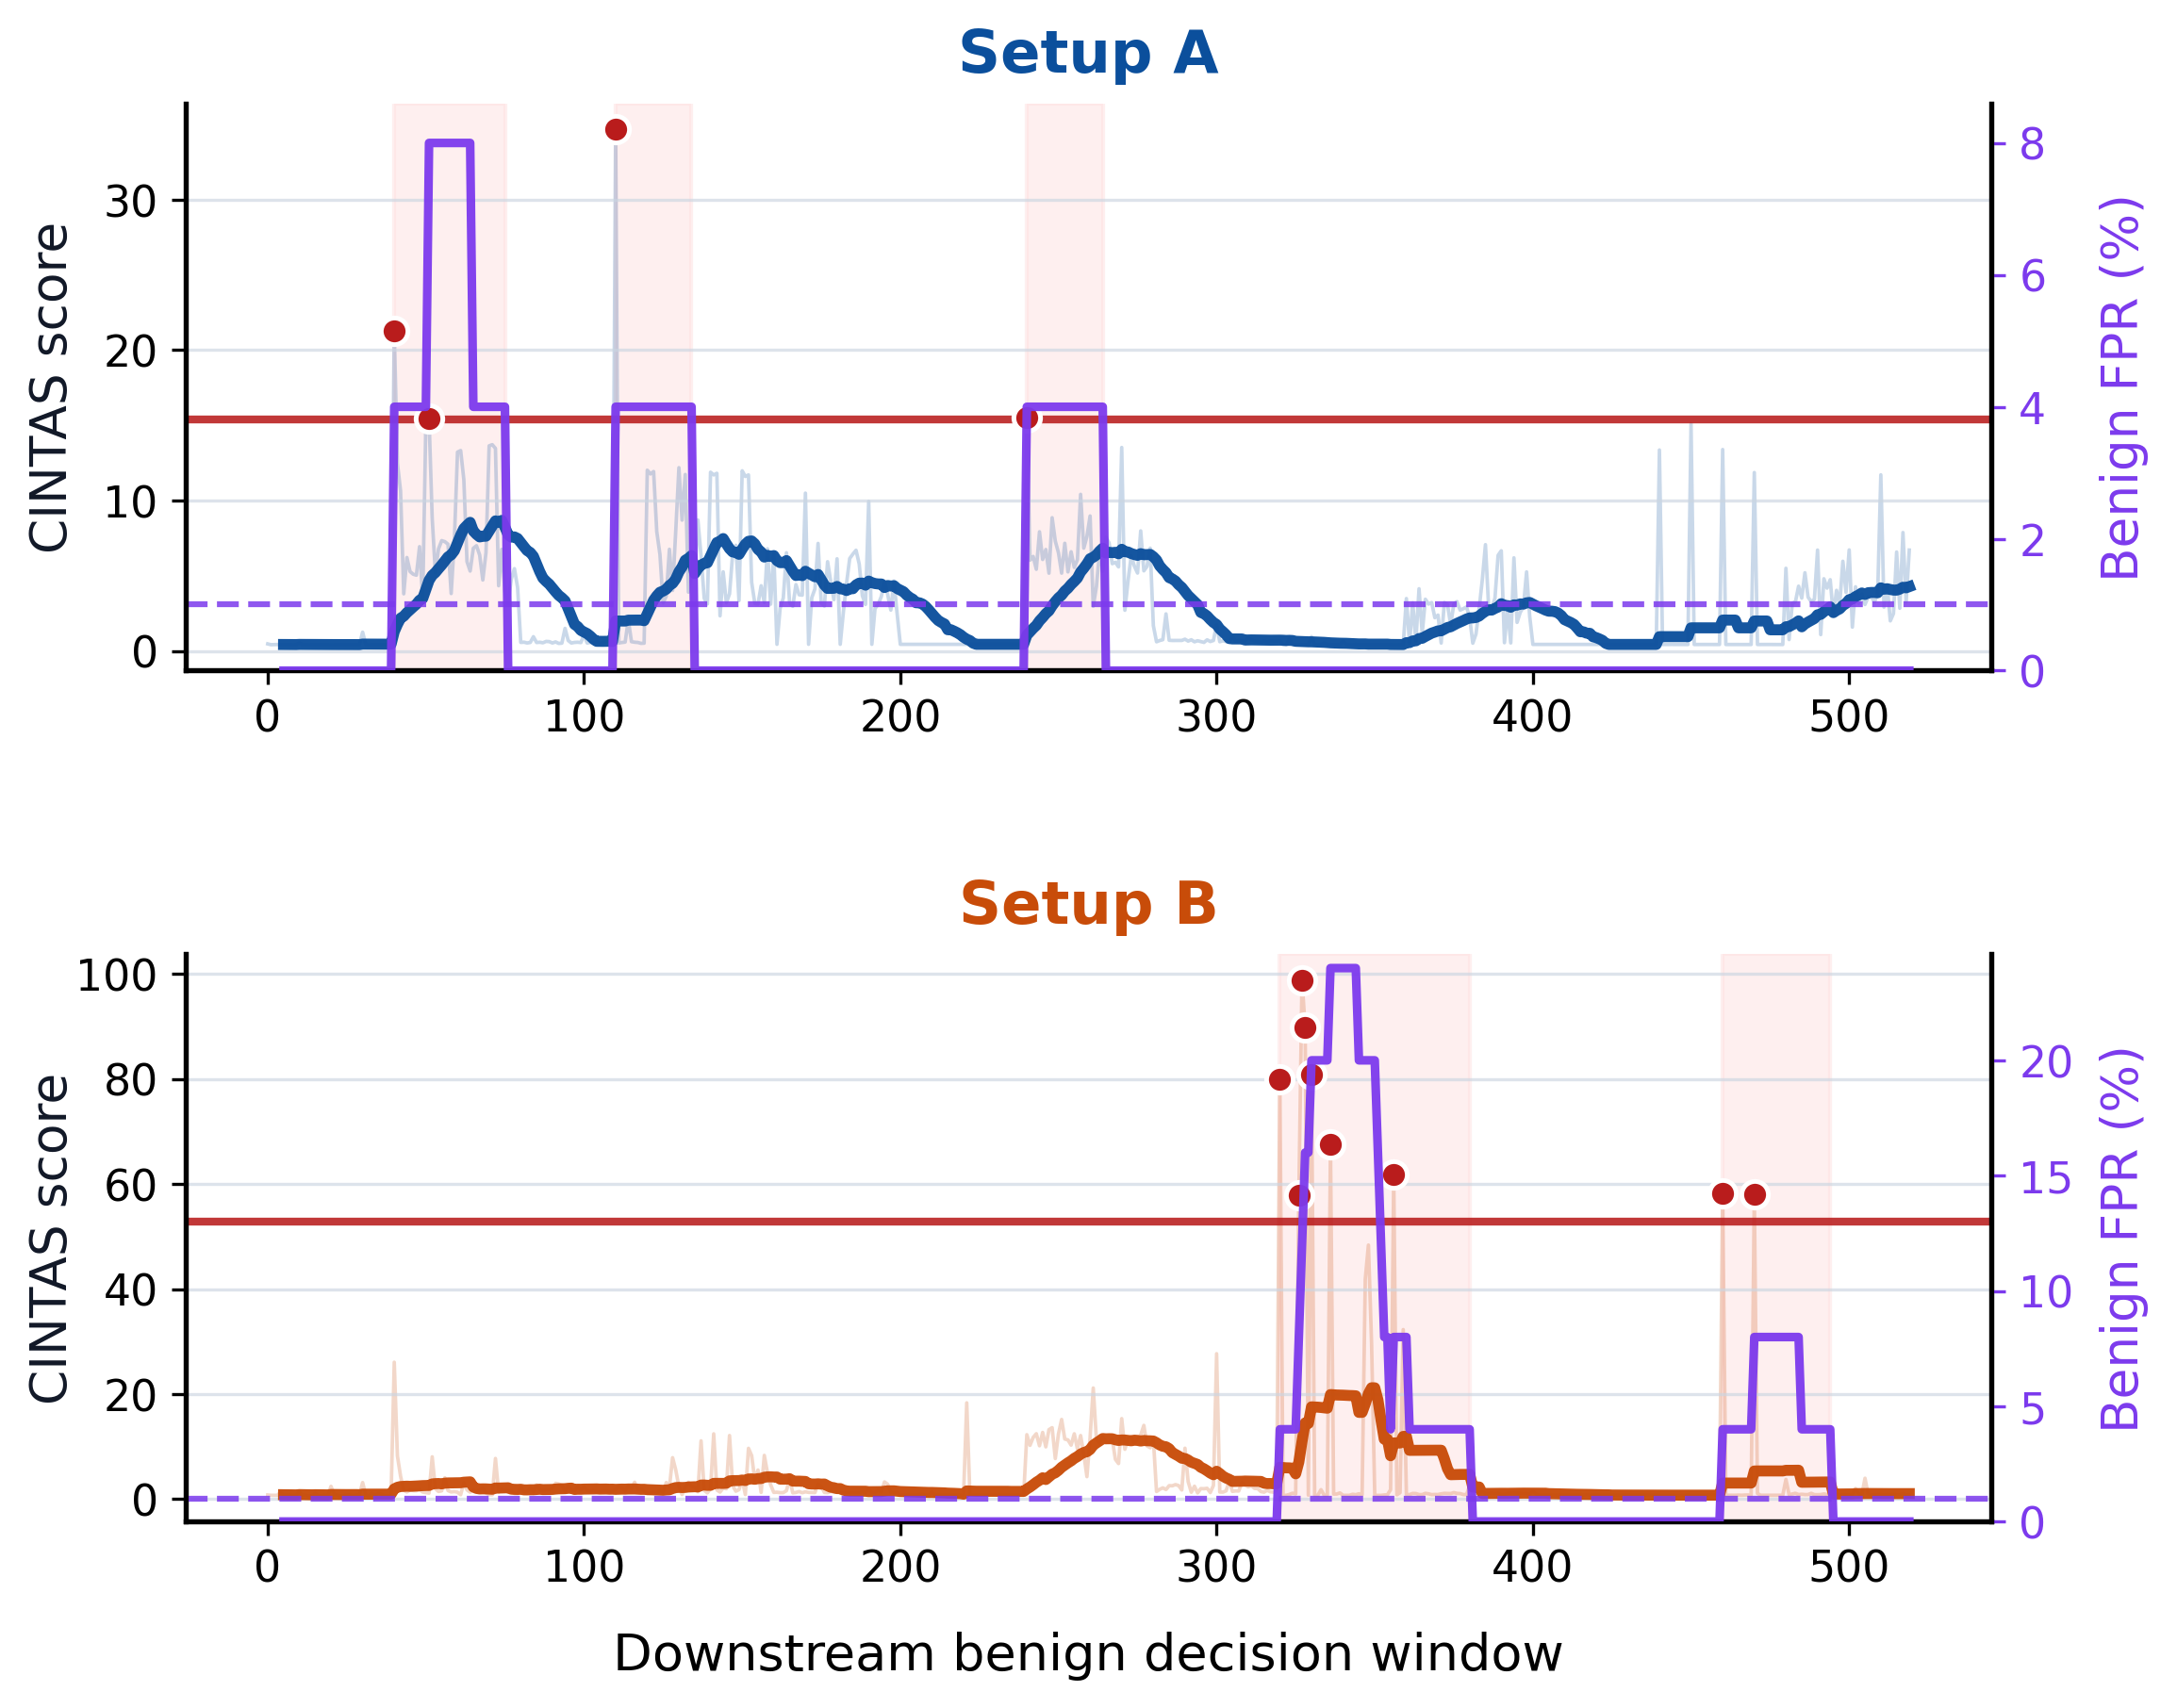

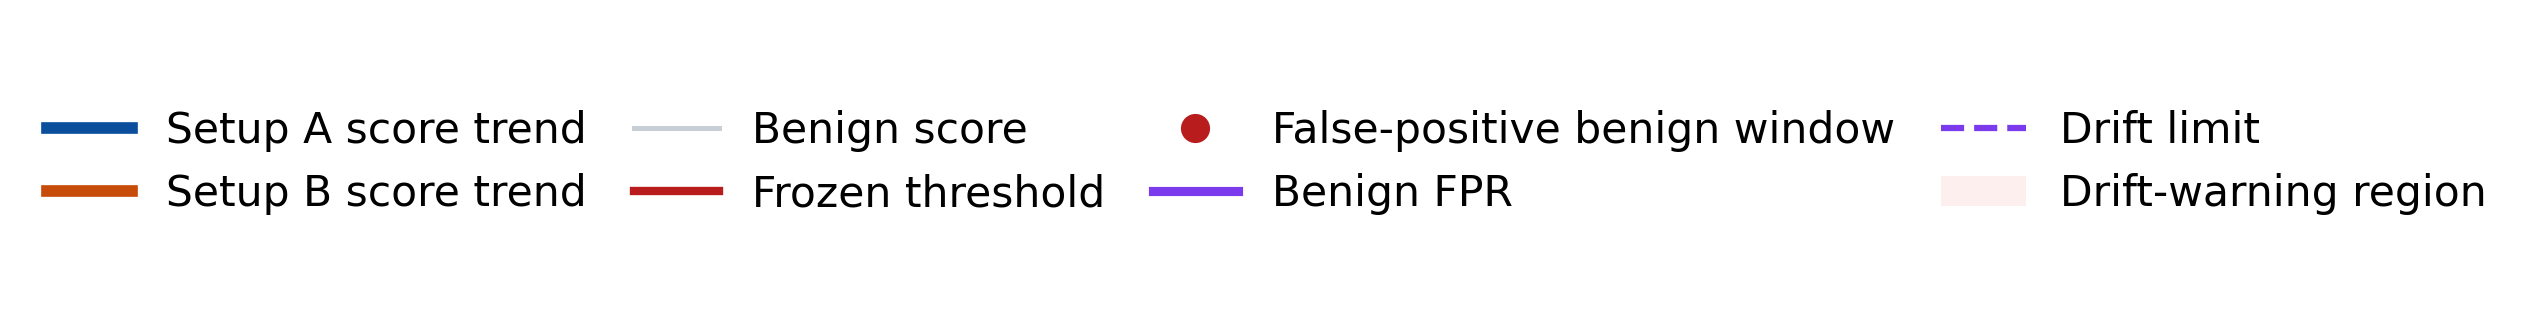

Saved figure: results/notebook_run/tcad_ablation/paper_figures/gallery_fig6c_lifecycle_benign_drift_trend.png
Saved legend: results/notebook_run/tcad_ablation/paper_figures/gallery_fig6c_lifecycle_benign_drift_trend_legend.png


In [30]:

FIG_LIFE_DRIFT_OUT = "gallery_fig6c_lifecycle_benign_drift_trend.png"
FIG_LIFE_DRIFT_LEGEND_OUT = "gallery_fig6c_lifecycle_benign_drift_trend_legend.png"

WINDOWS_PATH = LIFECYCLE_OUT / "lifecycle_recalibration_windows.csv"
SUMMARY_PATH = LIFECYCLE_OUT / "lifecycle_recalibration_summary.csv"

DRIFT_FPR_LIMIT = 0.01
TREND_WINDOW = 25
MAX_RAW_POINTS = 520

life_windows = pd.read_csv(WINDOWS_PATH)
life_summary = pd.read_csv(SUMMARY_PATH)

needed_cols = {"setup", "phase", "scenario", "workload", "window_idx", "score_win", "method", "threshold", "pred"}
missing = needed_cols.difference(life_windows.columns)
if missing:
    raise RuntimeError(f"Missing lifecycle window columns: {sorted(missing)}")

benign = life_windows[
    (life_windows["method"].astype(str) == "frozen")
    & (life_windows["scenario"].astype(str).str.upper() == "BENIGN")
    & (life_windows["phase"].astype(str).str.contains("later", case=False, na=False))
].copy()

if benign.empty:
    raise RuntimeError("No later-benign frozen lifecycle windows found.")

benign["score_win"] = pd.to_numeric(benign["score_win"], errors="coerce")
benign["threshold"] = pd.to_numeric(benign["threshold"], errors="coerce")
benign["pred"] = pd.to_numeric(benign["pred"], errors="coerce").fillna(0).astype(int)

setup_order = [s for s in ["A", "B"] if s in set(benign["setup"].astype(str))]
if not setup_order:
    setup_order = sorted(benign["setup"].astype(str).unique())

SETUP_COLORS_LOCAL = {
    "A": "#0B4F9C",
    "B": "#C84C09",
}
TEXT = "#111827"
GRID = "#CBD5E1"
ALERT = "#B91C1C"
FPR_COLOR = "#7C3AED"
DRIFT_SHADE = "#FEE2E2"


def _prepare_setup_trend(df: pd.DataFrame) -> pd.DataFrame:
    local = df.sort_values(["workload", "window_idx"], kind="mergesort").reset_index(drop=True)
    local["field_window"] = np.arange(len(local))
    local["false_positive"] = local["pred"].astype(int)
    local["score_trend"] = local["score_win"].rolling(
        TREND_WINDOW,
        min_periods=max(5, TREND_WINDOW // 4),
    ).mean()
    local["benign_fpr_trend"] = local["false_positive"].rolling(
        TREND_WINDOW,
        min_periods=max(5, TREND_WINDOW // 4),
    ).mean()
    return local


def _downsample_for_raw_line(local: pd.DataFrame) -> pd.DataFrame:
    if len(local) <= MAX_RAW_POINTS:
        return local
    step = int(np.ceil(len(local) / MAX_RAW_POINTS))
    return local.iloc[::step].copy()


def _shade_drift_regions(ax, local: pd.DataFrame) -> None:
    drift = local["benign_fpr_trend"].fillna(0.0).to_numpy() > DRIFT_FPR_LIMIT
    if not drift.any():
        return

    x = local["field_window"].to_numpy()
    start = None
    for idx, active in enumerate(drift):
        if active and start is None:
            start = x[idx]
        if start is not None and ((not active) or idx == len(drift) - 1):
            end = x[idx] if active else x[idx - 1]
            ax.axvspan(start, end, color=DRIFT_SHADE, alpha=0.55, zorder=0)
            start = None


fig, axes = plt.subplots(
    len(setup_order),
    1,
    figsize=(8.4, max(5.4, 2.95 * len(setup_order))),
    dpi=200,
    squeeze=False,
    sharex=True,
)

axes_flat = axes.flat

for ax, setup_name in zip(axes_flat, setup_order):
    local = _prepare_setup_trend(benign[benign["setup"].astype(str) == setup_name].copy())
    raw = _downsample_for_raw_line(local)

    setup_color = SETUP_COLORS_LOCAL.get(setup_name, "#374151")
    threshold = float(local["threshold"].dropna().iloc[0])

    _shade_drift_regions(ax, local)

    ax.plot(
        raw["field_window"],
        raw["score_win"],
        color=setup_color,
        linewidth=0.9,
        alpha=0.22,
        zorder=1,
    )
    ax.plot(
        local["field_window"],
        local["score_trend"],
        color=setup_color,
        linewidth=2.8,
        alpha=0.96,
        zorder=3,
    )
    ax.axhline(
        threshold,
        color=ALERT,
        linewidth=2.0,
        linestyle="-",
        alpha=0.88,
        zorder=2,
    )

    fp = local[local["false_positive"] == 1]
    if not fp.empty:
        ax.scatter(
            fp["field_window"],
            fp["score_win"],
            s=46,
            color=ALERT,
            edgecolors="white",
            linewidths=1.2,
            zorder=5,
        )

    ax2 = ax.twinx()
    ax2.plot(
        local["field_window"],
        100.0 * local["benign_fpr_trend"],
        color=FPR_COLOR,
        linewidth=2.2,
        alpha=0.95,
        zorder=4,
    )
    ax2.axhline(
        100.0 * DRIFT_FPR_LIMIT,
        color=FPR_COLOR,
        linewidth=1.5,
        linestyle="--",
        alpha=0.85,
        zorder=2,
    )

    y2_max = max(2.0, 100.0 * float(local["benign_fpr_trend"].max(skipna=True)) + 0.6)
    ax2.set_ylim(0.0, y2_max)

    ax.set_title(
        f"Setup {setup_name}",
        fontsize=15.0,
        fontweight="bold",
        color=setup_color,
        pad=8,
        loc="center",
    )

    ax.set_ylabel("CINTAS score", fontsize=12.8, labelpad=5, color=TEXT)
    ax.yaxis.set_label_coords(-0.060, 0.5)

    ax2.set_ylabel("Benign FPR (%)", fontsize=12.8, labelpad=5, color=FPR_COLOR)
    ax2.yaxis.set_label_coords(1.060, 0.5)

    ax.grid(axis="y", color=GRID, alpha=0.65, linewidth=0.8)
    ax.tick_params(axis="both", labelsize=11)
    ax.tick_params(axis="x", labelbottom=True)
    ax2.tick_params(axis="y", labelsize=11, colors=FPR_COLOR)

    ax.spines["top"].set_visible(False)
    ax2.spines["top"].set_visible(False)

x_max = int(benign.groupby("setup").size().max()) - 1
x_ticks = np.arange(0, x_max + 1, 100)
if x_max not in x_ticks:
    x_ticks = np.append(x_ticks, x_max)

for ax in axes_flat:
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(int(x)) for x in x_ticks], fontsize=11)
    ax.tick_params(axis="x", labelbottom=True)

axes[-1, 0].set_xlabel("Downstream benign decision window", fontsize=13, labelpad=10)

fig.subplots_adjust(
    left=0.120,
    right=0.880,
    bottom=0.105,
    top=0.955,
    hspace=0.500,
)

plot_path = GALLERY_DIR / FIG_LIFE_DRIFT_OUT
fig.savefig(plot_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)

legend_handles = [
    plt.Line2D([0], [0], color="#0B4F9C", linewidth=2.8, label="Setup A score trend"),
    plt.Line2D([0], [0], color="#C84C09", linewidth=2.8, label="Setup B score trend"),
    plt.Line2D([0], [0], color="#64748B", linewidth=1.2, alpha=0.35, label="Benign score"),
    plt.Line2D([0], [0], color=ALERT, linewidth=2.0, label="Frozen threshold"),
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="none",
        markerfacecolor=ALERT,
        markeredgecolor="white",
        markersize=8,
        label="False-positive benign window",
    ),
    plt.Line2D([0], [0], color=FPR_COLOR, linewidth=2.2, label="Benign FPR"),
    plt.Line2D([0], [0], color=FPR_COLOR, linewidth=1.5, linestyle="--", label="Drift limit"),
    plt.Rectangle((0, 0), 1, 1, facecolor=DRIFT_SHADE, edgecolor="none", alpha=0.55, label="Drift-warning region"),
]

legend_fig, legend_ax = plt.subplots(figsize=(8.2, 1.15), dpi=200)
legend_ax.axis("off")
legend_ax.legend(
    handles=legend_handles,
    loc="center",
    ncol=4,
    frameon=False,
    fontsize=10.2,
    columnspacing=1.1,
    handlelength=2.0,
)

legend_path = GALLERY_DIR / FIG_LIFE_DRIFT_LEGEND_OUT
legend_fig.savefig(legend_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(legend_fig)

display(Image(filename=str(plot_path)))
display(Image(filename=str(legend_path)))

print(f"Saved figure: {plot_path.relative_to(REPO_ROOT)}")
print(f"Saved legend: {legend_path.relative_to(REPO_ROOT)}")


## 6. Manifest And Artifact Audit


In [17]:
def load_manifest(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))

manifest_specs = [
    ("TCAD paper-scale design-space sweep", TCAD_OUT / "run_manifest.json"),
    ("Lifecycle drift and recalibration", LIFECYCLE_OUT / "run_manifest.json"),
]
for path in sorted((RESULTS_ROOT / "droop_adaptive_ablation").glob("p*/run_manifest.json")):
    manifest_specs.append((f"DROOP-adaptive sweep {path.parent.name}", path))

records = []
for run_name, path in manifest_specs:
    if path.exists():
        manifest = load_manifest(path)
        records.append({
            "run": run_name,
            "manifest": str(path.relative_to(REPO_ROOT)),
            "status": "OK",
            "git_commit": manifest.get("git_commit"),
            "data_files": len(manifest.get("data_files", [])),
            "artifacts": len(manifest.get("artifacts", [])),
            "python": manifest.get("python_version"),
        })
    else:
        records.append({
            "run": run_name,
            "manifest": str(path.relative_to(REPO_ROOT)),
            "status": "MISSING",
            "git_commit": None,
            "data_files": 0,
            "artifacts": 0,
            "python": None,
        })

manifest_overview = pd.DataFrame(records)
display(manifest_overview)

if (TCAD_OUT / "run_manifest.json").exists():
    tcad_manifest = load_manifest(TCAD_OUT / "run_manifest.json")
    display(pd.DataFrame(tcad_manifest.get("data_files", [])).head())


,run,manifest,status,git_commit,data_files,artifacts,python
0,TCAD paper-scale design-space sweep,results/notebook_run/tcad_ablation/run_manifes...,OK,08cf2368999a9eea3b234a931d899f704a4f0169,78,6,3.11.15
1,Lifecycle drift and recalibration,results/notebook_run/lifecycle_drift/run_manif...,OK,f030e7ef08b7351bc3bcb6df0b2ccb3266d292f9,78,6,3.13.5
2,DROOP-adaptive sweep p0_975,results/notebook_run/droop_adaptive_ablation/p...,OK,08cf2368999a9eea3b234a931d899f704a4f0169,52,6,3.11.15
3,DROOP-adaptive sweep p0_99,results/notebook_run/droop_adaptive_ablation/p...,OK,08cf2368999a9eea3b234a931d899f704a4f0169,52,6,3.11.15


,path,sha256,size_bytes
0,data/telemetry/processed/ddr_data/DDR4_DROOP_d...,211653e8d3a8a281ebdc1202ee79fd82cf31b2260d1393...,8712405
1,data/telemetry/processed/ddr_data/DDR4_DROOP_d...,15a059ef04dd012c293c6902b18630878913419db21245...,8888644
2,data/telemetry/processed/ddr_data/DDR4_DROOP_d...,af3a9ae6e646846b54c0e60ec7b0ea787a7681cef78f1d...,8691159
3,data/telemetry/processed/ddr_data/DDR4_DROOP_g...,4a3f2949d1793bab3e26096f284a5f96977054298d4a60...,8897518
4,data/telemetry/processed/ddr_data/DDR4_DROOP_g...,d72b1ff08a2fca3ba73b31d7adf4bd66f7bf1b4c9a7932...,8981257


## 7. Supplemental Hardware-Cost Artifact Summary


In [18]:
# 14. Supplemental Hardware-Cost Artifact Summary

TCAD_SUMMARY_PATH = TCAD_OUT / "tcad_ablation_summary.csv"
SELECTED_OP_PATH = GALLERY_DIR / "gallery_table1_selected_operating_points.csv"

if not TCAD_SUMMARY_PATH.exists():
    raise RuntimeError(f"Missing TCAD summary artifact: {TCAD_SUMMARY_PATH}")

hardware_summary = pd.read_csv(TCAD_SUMMARY_PATH, low_memory=False)

costs = OperatorCosts.from_csv(REPO_ROOT / "hardware" / "cintas_operator_costs.csv")
operator_table = pd.DataFrame([
    {
        "operator": "add",
        "area_mm2": costs.add_area_mm2,
        "power_mw_at_1ghz": costs.add_power_mw_at_1ghz,
        "delay_ps": costs.add_delay_ps,
        "cycles": costs.add_cycles,
    },
    {
        "operator": "mult",
        "area_mm2": costs.mult_area_mm2,
        "power_mw_at_1ghz": costs.mult_power_mw_at_1ghz,
        "delay_ps": costs.mult_delay_ps,
        "cycles": costs.mult_cycles,
    },
])

display(Markdown("### Operator Library"))
display(operator_table)

comparison_table = compute_tableIII_setupB(n_features=15, frequency_ghz=1.0).copy()
comparison_table["method"] = comparison_table["method"].replace({
    "EXACT (CINTAS)": "CITADEL (CINTAS)"
})

display(Markdown("### Setup B Cost Reference Comparison"))
display(comparison_table)

hardware_cols = [
    "setup",
    "scenario",
    "sweep_source",
    "top_k",
    "n_selected_features",
    "fixed_point_q",
    "hw_area_mm2",
    "hw_power_mw",
    "hw_setup_b_area_overhead_pct",
    "hw_idle_power_overhead_pct",
    "hw_add_count",
    "hw_mult_count",
    "hw_estimated_serial_cycles",
]

missing_hw_cols = [c for c in hardware_cols if c not in hardware_summary.columns]
if missing_hw_cols:
    raise RuntimeError(f"Missing hardware summary columns: {missing_hw_cols}")

hardware_artifact_table = (
    hardware_summary[hardware_cols]
    .drop_duplicates()
    .sort_values(["setup", "scenario", "top_k", "fixed_point_q"], kind="mergesort")
    .reset_index(drop=True)
)

display(Markdown("### Hardware-Cost Artifact Rows"))
display(hardware_artifact_table.head(12))

if SELECTED_OP_PATH.exists():
    selected_ops = pd.read_csv(SELECTED_OP_PATH)
    selected_cols = [
        "setup",
        "scenario",
        "sweep_source",
        "top_k",
        "n_selected_features",
        "fixed_point_q",
        "hw_setup_b_area_overhead_pct",
        "hw_idle_power_overhead_pct",
    ]
    selected_cols = [c for c in selected_cols if c in selected_ops.columns]

    display(Markdown("### Selected Operating-Point Hardware Costs"))
    display(selected_ops[selected_cols].round(6))
else:
    print(f"Selected operating-point artifact not found: {SELECTED_OP_PATH.relative_to(REPO_ROOT)}")


### Operator Library

,operator,area_mm2,power_mw_at_1ghz,delay_ps,cycles
0,add,0.001165,0.1780,62.70,3
1,mult,0.004532,0.5146,29.09,2


### Setup B Cost Reference Comparison

,method,n_features,area_mm2,power_mw,area_overhead_pct,idle_power_overhead_pct
0,CITADEL (CINTAS),15,0.178821,21.6292,0.083076,0.060927
1,OCTANE,227,NaN,NaN,1.200000,2.600000
2,E-SCOUT,230,NaN,NaN,2.200000,1.000000


### Hardware-Cost Artifact Rows

,setup,scenario,sweep_source,top_k,n_selected_features,fixed_point_q,hw_area_mm2,hw_power_mw,hw_setup_b_area_overhead_pct,hw_idle_power_overhead_pct,hw_add_count,hw_mult_count,hw_estimated_serial_cycles
0,A,DROOP,droop_adaptive_dse,15,15,15,0.177656,21.4512,0.082535,0.060426,28.0,32.0,148.0
1,A,DROOP,droop_adaptive_dse,30,30,15,0.348578,42.2292,0.161941,0.118955,58.0,62.0,298.0
2,A,DROOP,droop_adaptive_dse,50,50,15,0.576474,69.9332,0.267816,0.196995,98.0,102.0,498.0
3,A,RH,standard_dse,5,5,8,0.064873,7.7772,0.030138,0.021908,9.0,12.0,51.0
4,A,RH,standard_dse,5,5,10,0.064873,7.7772,0.030138,0.021908,9.0,12.0,51.0
5,A,RH,standard_dse,5,5,12,0.064873,7.7772,0.030138,0.021908,9.0,12.0,51.0
6,A,RH,standard_dse,5,5,15,0.064873,7.7772,0.030138,0.021908,9.0,12.0,51.0
7,A,RH,standard_dse,5,5,18,0.064873,7.7772,0.030138,0.021908,9.0,12.0,51.0
8,A,RH,standard_dse,8,8,8,0.099057,11.9328,0.046020,0.033614,15.0,18.0,81.0
9,A,RH,standard_dse,8,8,10,0.099057,11.9328,0.046020,0.033614,15.0,18.0,81.0


### Selected Operating-Point Hardware Costs

,setup,scenario,sweep_source,top_k,n_selected_features,fixed_point_q,hw_setup_b_area_overhead_pct,hw_idle_power_overhead_pct
0,A,DROOP,droop_adaptive_dse,15,15,15,0.082535,0.060426
1,A,RH,standard_dse,20,20,8,0.109545,0.080437
2,B,DROOP,droop_adaptive_dse,15,15,15,0.082535,0.060426
3,B,SPECTRE,standard_dse,30,30,8,0.161400,0.118454


## 8. FPGA/RTL Laptop Workflow

This section checks whether local hardware-development tools are available. It is a convenience check, not the final Vivado run. On the MacBook, open-source tools can help with lint/sanity checks, but the final FPGA synthesis/place-and-route should be run on ASU/Linux with Vivado.

Use this split:

- **MacBook:** run notebook DSE, figures, tables, Apple supplement, and final paper merge.
- **ASU/Linux:** run Vivado synthesis/place-and-route for the selected settings from `section4_vivado_best_settings_queue.csv`.
- **Back on MacBook:** copy `rtl_resource_summary.csv`, rerun Section 17, then rerun Section 11.


In [19]:
tools = []
for name, command in [
    ("verilator", ["verilator", "--version"]),
    ("iverilog", ["iverilog", "-V"]),
    ("yosys", ["yosys", "-V"]),
    ("gtkwave", ["gtkwave", "--version"]),
]:
    exe = shutil.which(command[0])
    row = {"tool": name, "available": exe is not None, "path": exe or ""}
    if exe:
        try:
            completed = subprocess.run(command, capture_output=True, text=True, timeout=10)
            first_line = (completed.stdout or completed.stderr).splitlines()[0] if (completed.stdout or completed.stderr) else ""
            row["version"] = first_line
        except Exception as exc:
            row["version"] = f"version check failed: {exc}"
    else:
        row["version"] = "not installed"
    tools.append(row)

display(pd.DataFrame(tools))

,tool,available,path,version
0,verilator,True,/opt/homebrew/bin/verilator,Verilator 5.048 2026-04-26 rev vUNKNOWN-built2...
1,iverilog,False,,not installed
2,yosys,False,,not installed
3,gtkwave,True,/opt/homebrew/bin/gtkwave,Can't locate Switch.pm in @INC (you may need t...


## 9. Export Fixed-Point Golden Vectors For RTL

This section exports the fixed-point reference data needed for RTL verification. The output CSV contains selected telemetry inputs plus expected CINTAS scores from the notebook reference model.

Main artifact:

`results/notebook_run/fpga/cintas_setupA_q*_golden_vectors.csv`

Vivado synthesis can produce resource/timing numbers without this file, but a stronger TCAD hardware story should also simulate RTL against these golden vectors. That gives two levels of evidence: bit/score agreement against Python fixed-point CINTAS, and Vivado resource/timing/power results for the FPGA implementation.


In [20]:
FPGA_OUT.mkdir(parents=True, exist_ok=True)
selected_feature_path = TCAD_OUT / "tcad_selected_features.csv"
if not selected_feature_path.exists():
    raise RuntimeError("Run Section 4 first, or make sure tcad_selected_features.csv exists.")

selected_features_df = pd.read_csv(selected_feature_path)
setup_a_candidates = selected_features_df[selected_features_df["setup"].astype(str).str.upper() == "A"].copy()
if setup_a_candidates.empty:
    raise RuntimeError("No Setup A selected-feature rows found in tcad_selected_features.csv.")

# Prefer the paper-selected Setup A operating point when Section 5 has been run.
if "paper_detection_table" in globals() and isinstance(paper_detection_table, pd.DataFrame):
    target = paper_detection_table[paper_detection_table["setup"].astype(str).str.upper() == "A"].copy()
    # Use the integrated paper-scale DSE rows; do not filter by a legacy sweep-source name.
    if not target.empty:
        t = target.sort_values(["mcc", "bal_acc", "f1", "fpr"], ascending=[False, False, False, True], kind="mergesort").iloc[0]
        for col in ["top_k", "lambda_res", "agg_mode", "weight_mode", "fixed_point_q"]:
            if col in setup_a_candidates.columns and col in t.index:
                setup_a_candidates = setup_a_candidates[setup_a_candidates[col].astype(str) == str(t[col])]

if setup_a_candidates.empty:
    setup_a_candidates = selected_features_df[selected_features_df["setup"].astype(str).str.upper() == "A"].copy()

setup_a_candidates = setup_a_candidates.sort_values(["top_k", "fixed_point_q"], ascending=[True, False], kind="mergesort")
selected_row = setup_a_candidates.iloc[0]
features = [f.strip() for f in str(selected_row["features"]).split(",") if f.strip()]

setup_a_raw, _ = load_telemetry_two_setups(DATA_ROOT)
setup_a = clean_and_debias_telemetry(setup_a_raw)
features = [f for f in features if f in setup_a.columns]
if not features:
    raise RuntimeError("Selected feature list does not match Setup A telemetry columns.")

lambda_res = float(selected_row.get("lambda_res", 0.5))
weight_mode = str(selected_row.get("weight_mode", "uniform"))
q_format = int(selected_row.get("fixed_point_q", 15))
model = fit_cintas_from_benign(setup_a, features, lambda_res=lambda_res, weight_mode=weight_mode)
fixed = FixedPointCINTAS.from_float_model(model, FixedPointConfig(q=q_format))

subset = setup_a[model.feature_cols].head(32).copy()
score_float, e1_float, e2_float = model.score_dataframe(subset)
score_q = fixed.score_dataframe(subset)

golden = subset.copy()
golden.insert(0, "sample_index", range(len(golden)))
golden["expected_score_q"] = score_q
golden["expected_score_float"] = score_float
golden["expected_e1_float"] = e1_float
golden["expected_e2_float"] = e2_float
golden_path = FPGA_OUT / f"cintas_setupA_q{q_format}_golden_vectors.csv"
golden.to_csv(golden_path, index=False)

print(f"Golden vectors: {golden_path.relative_to(REPO_ROOT)}")
print(f"Source selected features: {selected_feature_path.relative_to(REPO_ROOT)}")
print(f"Features exported: {len(model.feature_cols)}; lambda={lambda_res}; weight_mode={weight_mode}; q={q_format}")
display(golden.head())


Golden vectors: results/notebook_run/fpga/cintas_setupA_q18_golden_vectors.csv
Source selected features: results/notebook_run/tcad_ablation/tcad_selected_features.csv
Features exported: 5; lambda=0.0; weight_mode=uniform; q=18


,sample_index,Core2 (Socket 0).14_C6res%,Core1 (Socket 0).14_C6res%,Core3 (Socket 0).14_C6res%,Core0 (Socket 0).14_C6res%,SKT0 Core C-State.3_C6res%,expected_score_q,expected_score_float,expected_e1_float,expected_e2_float
0,0,-2.698854,-2.764291,-2.331342,-3.521672,-2.830115,17626,0.067252,0.251688,0.067252
1,1,-2.698854,-2.764291,-2.331342,-3.521672,-2.830115,17626,0.067252,0.251688,0.067252
2,2,-2.698854,-2.764291,-2.331342,-3.521672,-2.830115,17626,0.067252,0.251688,0.067252
3,3,-2.698854,-2.764291,-2.331342,-3.521672,-2.830115,17626,0.067252,0.251688,0.067252
4,4,-2.698854,-2.764291,-2.331342,-3.521672,-2.830115,17626,0.067252,0.251688,0.067252


--------------

## 10. Merge Future RTL/FPGA Results Into The TCAD Table

Run this section after ASU/Linux Vivado produces:

`results/notebook_run/rtl_sweep/rtl_resource_summary.csv`

The expected merge keys are `setup`, `top_k`, and `fixed_point_q`. Recommended extra columns include `window_size`, `target_part`, `clock_period_ns`, `luts`, `ffs`, `dsps`, `brams`, `fmax_mhz`, `wns_ns`, `latency_cycles`, `total_power_mw`, and `energy_per_block_nj`.

After copying the CSV back to the MacBook, rerun this section and then rerun Section 11 so the TCAD gallery includes the latest RTL/FPGA evidence.


In [21]:
rtl_summary_candidates = [
    RTL_SWEEP_OUT / "rtl_resource_summary.csv",
    REPO_ROOT / "results" / "rtl_sweep" / "rtl_resource_summary.csv",
]
existing = next((p for p in rtl_summary_candidates if p.exists()), None)

if existing is None:
    RTL_SWEEP_OUT.mkdir(parents=True, exist_ok=True)
    template = pd.DataFrame([
        {
            "setup": "A",
            "top_k": int(summary["top_k"].iloc[0]),
            "fixed_point_q": int(summary["fixed_point_q"].iloc[0]),
            "luts": None,
            "ffs": None,
            "dsps": None,
            "brams": None,
            "fmax_mhz": None,
            "latency_cycles": None,
            "energy_per_block_nj": None,
            "status": "fill after RTL simulation/synthesis",
        }
    ])
    existing = RTL_SWEEP_OUT / "rtl_resource_summary.csv"
    template.to_csv(existing, index=False)
    print(f"Created RTL summary template: {existing.relative_to(REPO_ROOT)}")

rtl_summary = pd.read_csv(existing)
print(f"RTL summary source: {existing.relative_to(REPO_ROOT)}")
display(rtl_summary.head())

merge_keys = [key for key in ["setup", "top_k", "fixed_point_q"] if key in rtl_summary.columns and key in summary.columns]
if merge_keys:
    merged = summary.merge(rtl_summary, on=merge_keys, how="left")
    display(merged.head())
else:
    print("RTL summary does not yet share merge keys with the TCAD summary.")

RTL summary source: results/notebook_run/rtl_sweep/rtl_resource_summary.csv


,setup,scenario,top_k,fixed_point_q,window_size,tag,target_part,tool_version,luts,luts_pct,...,timing_met,fmax_mhz_est,total_power_mw,dynamic_power_mw,static_power_mw,power_confidence,synth_ok,power_ok,latency_cycles,status
0,A,DROOP,15,15,1000,A_DROOP,xc7a200tfbg676-1,Vivado v.2025.2 (lin64) Build 6299465 Fri Nov ...,867,0.64,...,True,44.36,158.0,27.0,131.0,Low,True,True,15000,synthesized
1,A,RH,20,8,550,A_RH,xc7a200tfbg676-1,Vivado v.2025.2 (lin64) Build 6299465 Fri Nov ...,863,0.64,...,True,44.58,157.0,26.0,131.0,Low,True,True,11000,synthesized
2,B,DROOP,15,15,200,B_DROOP,xc7a200tfbg676-1,Vivado v.2025.2 (lin64) Build 6299465 Fri Nov ...,884,0.66,...,True,44.39,158.0,27.0,131.0,Low,True,True,3000,synthesized
3,B,SPECTRE,30,8,700,B_SPECTRE,xc7a200tfbg676-1,Vivado v.2025.2 (lin64) Build 6299465 Fri Nov ...,907,0.67,...,True,43.69,157.0,27.0,131.0,Low,True,True,21000,synthesized


,setup,scenario_x,window_size_x,agg_mode,lambda_res,p_quantile,top_k,weight_mode,fixed_point_q,n_selected_features,...,timing_met,fmax_mhz_est,total_power_mw,dynamic_power_mw,static_power_mw,power_confidence,synth_ok,power_ok,latency_cycles,status
0,A,RH,50,max,0.0,0.99,5,inv_var,8,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A,RH,50,max,0.0,0.99,5,inv_var,10,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A,RH,50,max,0.0,0.99,5,inv_var,12,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A,RH,50,max,0.0,0.99,5,inv_var,15,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A,RH,50,max,0.0,0.99,5,inv_var,18,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


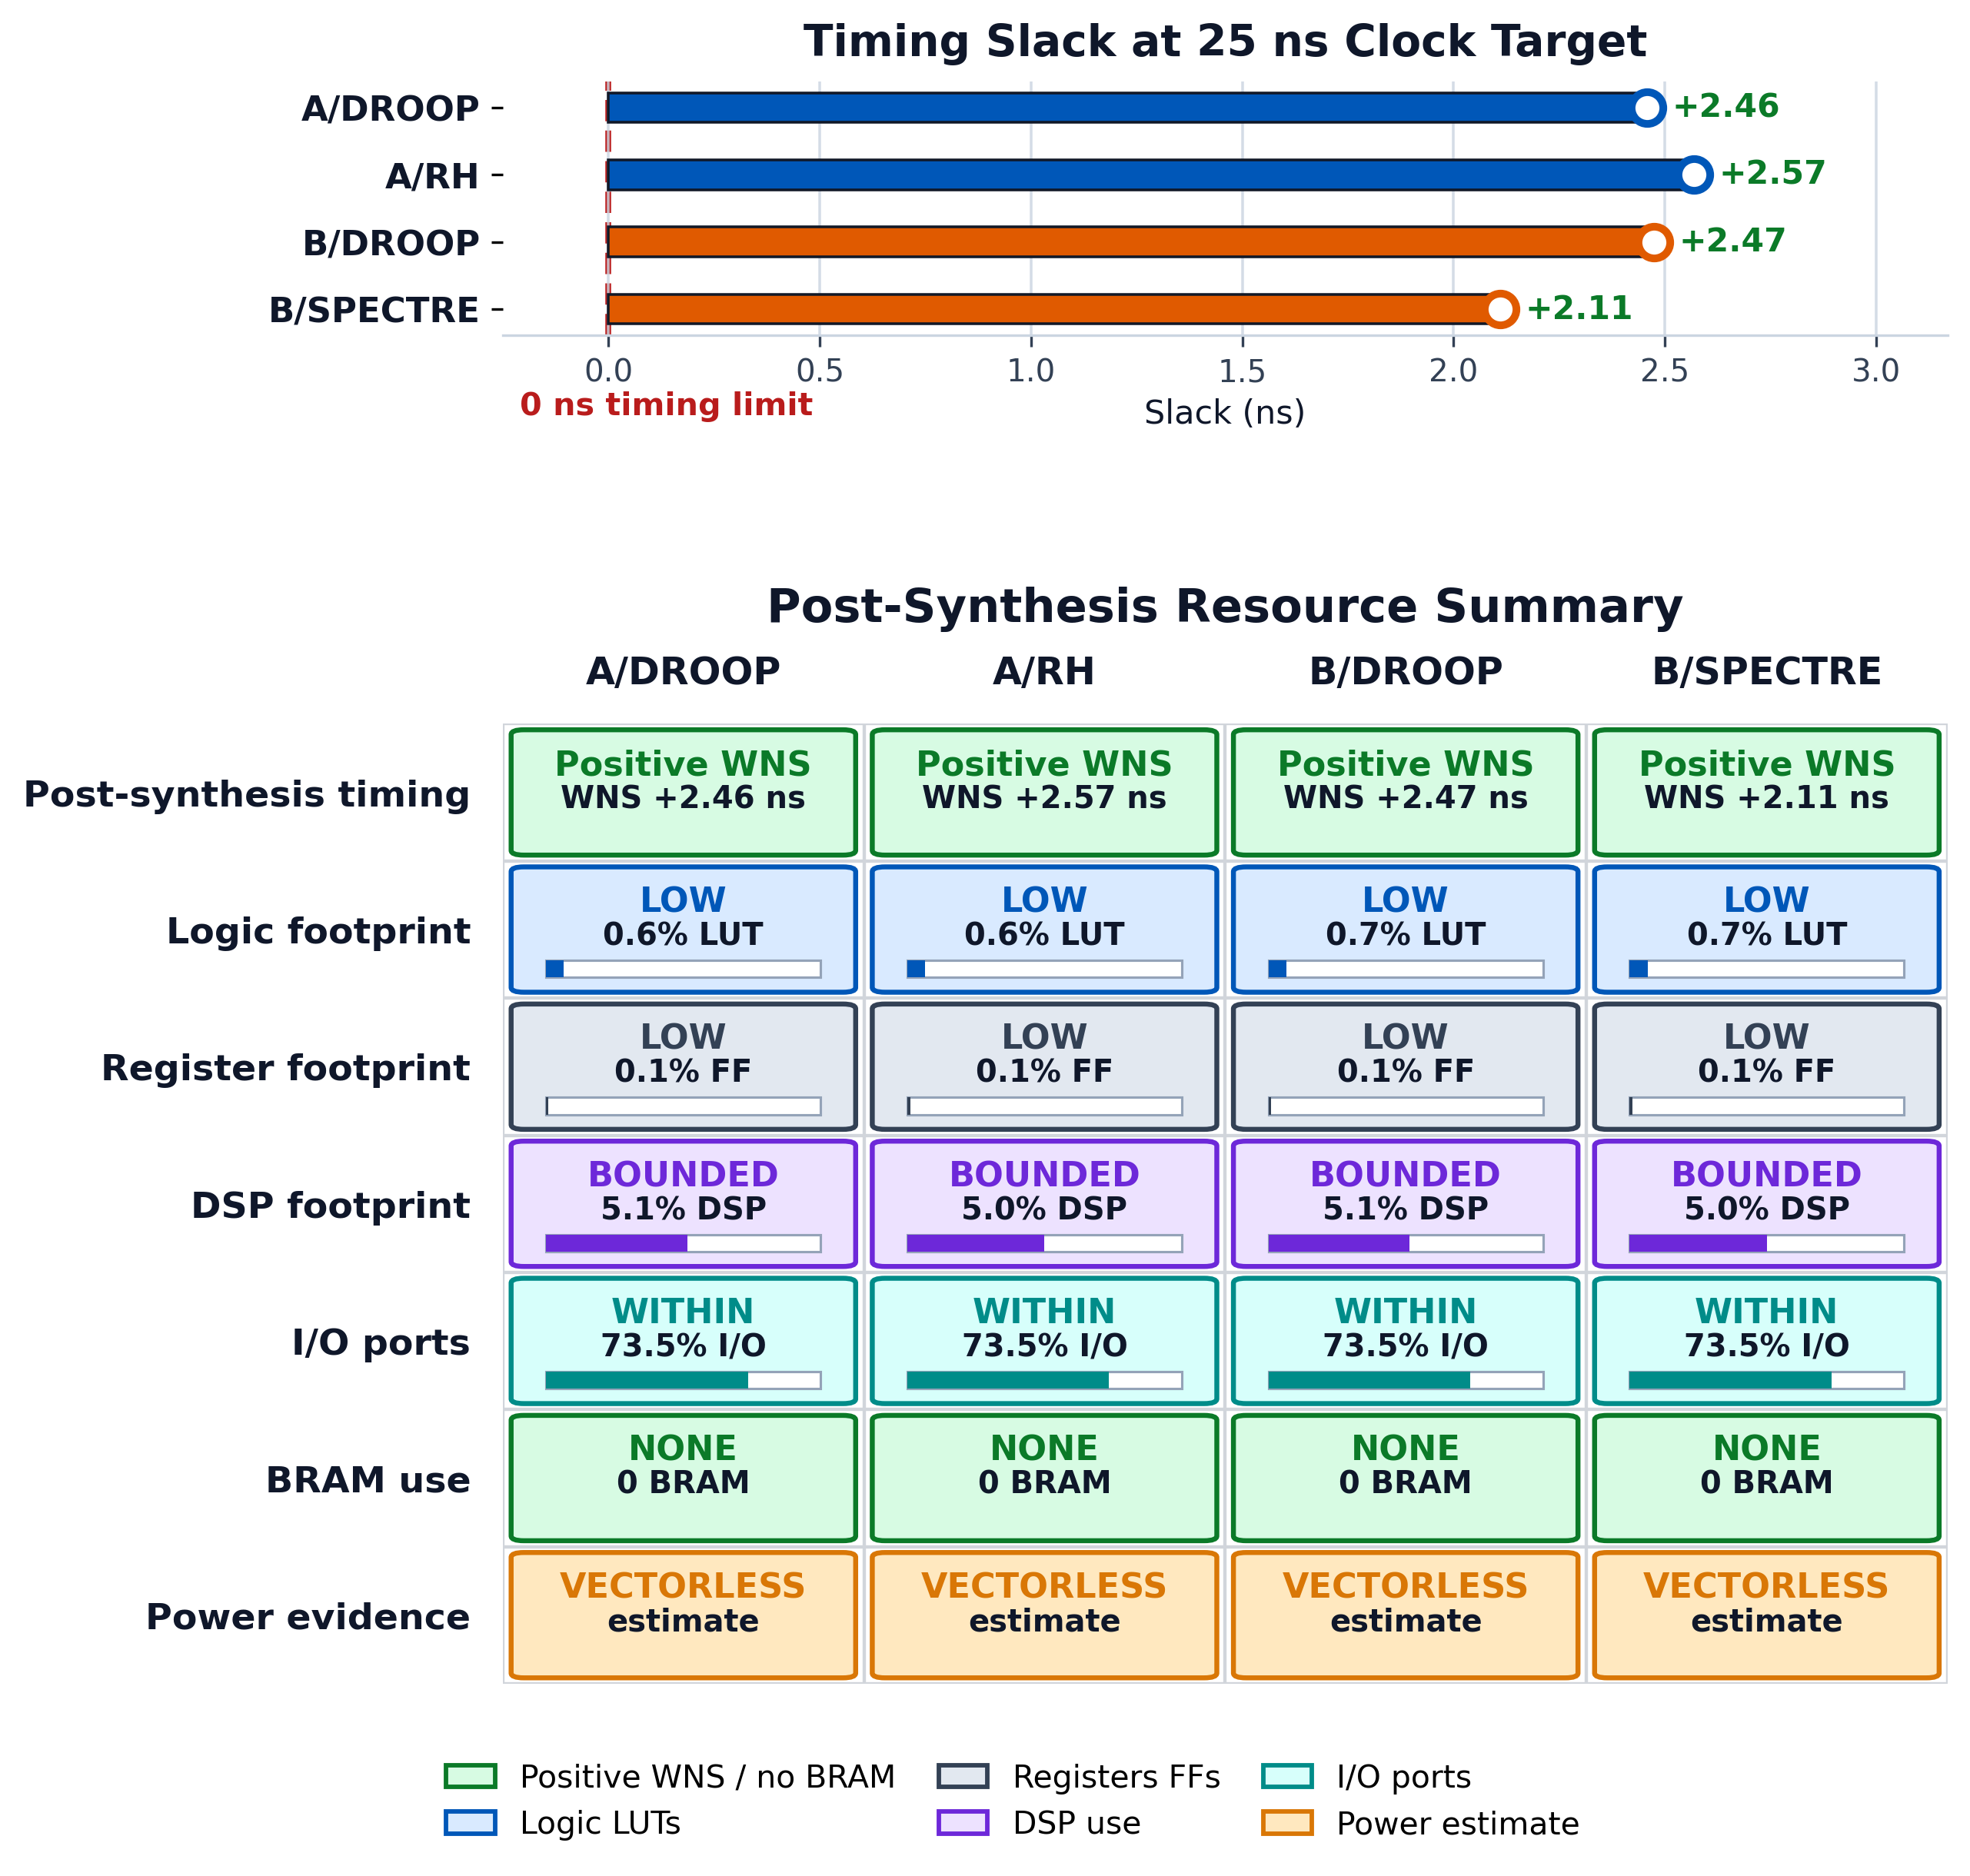

Saved figure: results/notebook_run/tcad_ablation/paper_figures/rtl_fpga_deployment_passport.png


In [35]:
from matplotlib.patches import FancyBboxPatch, Rectangle, Patch
from IPython.display import Image, display

RTL_SUMMARY_PATH = REPO_ROOT / "results/notebook_run/rtl_sweep/rtl_resource_summary.csv"
FIG_RTL_OUT = GALLERY_DIR / "rtl_fpga_deployment_passport.png"
GALLERY_DIR.mkdir(parents=True, exist_ok=True)

rtl = pd.read_csv(RTL_SUMMARY_PATH).copy()

def _event_label(s):
    s = str(s).upper()
    return {"RH": "RH"}.get(s, s)

def _pct(v):
    try:
        return f"{float(v):.1f}%"
    except Exception:
        return "n/a"

def _as_bool(v):
    if isinstance(v, str):
        return v.strip().lower() in {"true", "1", "yes", "pass", "met"}
    return bool(v)

order = ["A_DROOP", "A_RH", "B_DROOP", "B_SPECTRE"]
rtl["order"] = rtl["tag"].map({tag: i for i, tag in enumerate(order)})
rtl = rtl.sort_values("order").reset_index(drop=True)

rtl["case"] = rtl["setup"].astype(str) + "/" + rtl["scenario"].map(_event_label)
rtl["target_mhz"] = 1000.0 / pd.to_numeric(rtl["clock_period_ns"], errors="coerce")

# Sharper, clearer, high-contrast palette.
COL = {
    "text": "#0F172A",
    "muted": "#334155",
    "grid": "#CBD5E1",

    "pass": "#0B7A28",
    "pass_bg": "#D7FBE3",

    "logic": "#0057B8",
    "logic_bg": "#D9EAFF",

    "reg": "#334155",
    "reg_bg": "#E2E8F0",

    "dsp": "#6D28D9",
    "dsp_bg": "#EDE2FF",

    "io": "#008C89",
    "io_bg": "#D7FFFB",

    "power": "#D97706",
    "power_bg": "#FFE8BF",

    "warn": "#C2410C",
    "warn_bg": "#FFEDD5",

    "fail": "#B91C1C",
    "fail_bg": "#FEE2E2",

    "setup_a": "#0057B8",
    "setup_b": "#E05A00",
}

SETUP_COLORS = {"A": COL["setup_a"], "B": COL["setup_b"]}

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titleweight": "bold",
})

fig = plt.figure(figsize=(8.35, 8.35), dpi=240)
gs = fig.add_gridspec(2, 1, height_ratios=[0.72, 2.72], hspace=0.64)
ax_t = fig.add_subplot(gs[0])
ax_m = fig.add_subplot(gs[1])

# -----------------------------
# Panel 1: timing slack.
# -----------------------------
y = np.arange(len(rtl))[::-1]
case_colors = [SETUP_COLORS.get(str(s), "#111827") for s in rtl["setup"]]

ax_t.axvline(0, color=COL["fail"], linestyle="--", linewidth=1.8, zorder=1)
ax_t.barh(
    y,
    rtl["wns_ns"],
    height=0.44,
    color=case_colors,
    edgecolor="#111827",
    linewidth=0.85,
    alpha=1.0,
    zorder=3,
)

for yi, row, color in zip(y, rtl.itertuples(index=False), case_colors):
    ax_t.scatter(
        row.wns_ns,
        yi,
        s=98,
        color="white",
        edgecolors=color,
        linewidths=2.4,
        zorder=4,
    )
    ax_t.text(
        row.wns_ns + 0.06,
        yi,
        f"+{row.wns_ns:.2f}",
        ha="left",
        va="center",
        fontsize=10.2,
        fontweight="bold",
        color=COL["pass"],
    )

ax_t.set_yticks(y)
ax_t.set_yticklabels(rtl["case"].tolist(), fontsize=10.8, fontweight="bold", color=COL["text"])
ax_t.set_xlim(-0.25, max(3.0, float(rtl["wns_ns"].max()) + 0.60))
ax_t.set_title("Timing Slack at 25 ns Clock Target", fontsize=13.6, pad=8, color=COL["text"])
ax_t.set_xlabel("Slack (ns)", fontsize=10.3, labelpad=3, color=COL["text"])
ax_t.grid(axis="x", color=COL["grid"], linewidth=0.85, alpha=0.82, zorder=0)
ax_t.tick_params(axis="x", labelsize=9.7, colors=COL["muted"])

for spine in ["top", "right", "left"]:
    ax_t.spines[spine].set_visible(False)
ax_t.spines["bottom"].set_color(COL["grid"])

ax_t.text(
    0.012,
    -0.28,
    "0 ns timing limit",
    transform=ax_t.transAxes,
    ha="left",
    va="center",
    fontsize=9.9,
    fontweight="bold",
    color=COL["fail"],
)

# -----------------------------
# Panel 2: post-synthesis resource summary.
# -----------------------------
criteria = [
    ("Post-synthesis timing", "timing"),
    ("Logic footprint", "luts_pct"),
    ("Register footprint", "ffs_pct"),
    ("DSP footprint", "dsp_pct"),
    ("I/O ports", "iob_pct"),
    ("BRAM use", "bram"),
    ("Power evidence", "power"),
]

ax_m.set_xlim(0, len(rtl))
ax_m.set_ylim(0, len(criteria))
ax_m.invert_yaxis()
ax_m.set_facecolor("white")

ax_m.set_xticks(np.arange(len(rtl)) + 0.5)
ax_m.set_xticklabels(
    rtl["case"].tolist(),
    fontsize=11.8,
    fontweight="bold",
    color=COL["text"],
)
ax_m.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False, length=0, pad=10)

ax_m.set_yticks(np.arange(len(criteria)) + 0.5)
ax_m.set_yticklabels(
    [c[0] for c in criteria],
    fontsize=11.4,
    fontweight="bold",
    color=COL["text"],
)
ax_m.set_title(
    "Post-Synthesis Resource Summary",
    fontsize=14.6,
    pad=32,
    fontweight="bold",
    color=COL["text"],
)

for i, (name, kind) in enumerate(criteria):
    for j, row in enumerate(rtl.itertuples(index=False)):
        status = "Positive WNS"
        detail = ""
        color = COL["pass"]
        bg = COL["pass_bg"]
        bar_col = None
        frac = None

        if kind == "timing":
            met = _as_bool(row.timing_met)
            status = "Positive WNS" if met else "CHECK"
            detail = f"WNS {float(row.wns_ns):+.2f} ns"
            color, bg = (COL["pass"], COL["pass_bg"]) if met else (COL["fail"], COL["fail_bg"])

        elif kind == "luts_pct":
            status, detail = "LOW", f"{_pct(row.luts_pct)} LUT"
            color, bg, bar_col = COL["logic"], COL["logic_bg"], COL["logic"]
            frac = min(float(row.luts_pct) / 10.0, 1.0)

        elif kind == "ffs_pct":
            status, detail = "LOW", f"{_pct(row.ffs_pct)} FF"
            color, bg, bar_col = COL["reg"], COL["reg_bg"], COL["reg"]
            frac = min(float(row.ffs_pct) / 10.0, 1.0)

        elif kind == "dsp_pct":
            status, detail = "BOUNDED", f"{_pct(row.dsp_pct)} DSP"
            color, bg, bar_col = COL["dsp"], COL["dsp_bg"], COL["dsp"]
            frac = min(float(row.dsp_pct) / 10.0, 1.0)

        elif kind == "iob_pct":
            tight = float(row.iob_pct) >= 90.0
            status = "TIGHT" if tight else "WITHIN"
            detail = f"{_pct(row.iob_pct)} I/O"
            color, bg = (COL["warn"], COL["warn_bg"]) if tight else (COL["io"], COL["io_bg"])
            bar_col = color
            frac = min(float(row.iob_pct) / 100.0, 1.0)

        elif kind == "bram":
            status, detail = "NONE", "0 BRAM"
            color, bg = COL["pass"], COL["pass_bg"]

        elif kind == "power":
            status, detail = "VECTORLESS", "estimate"
            color, bg = COL["power"], COL["power_bg"]

        tile = FancyBboxPatch(
            (j + 0.035, i + 0.055),
            0.93,
            0.89,
            boxstyle="round,pad=0.012,rounding_size=0.035",
            facecolor=bg,
            edgecolor=color,
            linewidth=1.55,
            alpha=1.0,
            zorder=2,
        )
        ax_m.add_patch(tile)

        ax_m.text(
            j + 0.5,
            i + 0.30,
            status,
            ha="center",
            va="center",
            fontsize=10.7,
            fontweight="bold",
            color=color,
            zorder=3,
        )

        ax_m.text(
            j + 0.5,
            i + 0.55,
            detail,
            ha="center",
            va="center",
            fontsize=9.6,
            fontweight="bold",
            color=COL["text"],
            zorder=3,
        )

        if frac is not None:
            ax_m.add_patch(
                Rectangle(
                    (j + 0.12, i + 0.725),
                    0.76,
                    0.125,
                    facecolor="white",
                    edgecolor="#94A3B8",
                    linewidth=0.75,
                    alpha=1.0,
                    zorder=3,
                )
            )
            ax_m.add_patch(
                Rectangle(
                    (j + 0.12, i + 0.725),
                    0.76 * frac,
                    0.125,
                    facecolor=bar_col,
                    edgecolor="none",
                    alpha=1.0,
                    zorder=4,
                )
            )

for spine in ax_m.spines.values():
    spine.set_visible(False)

for x in range(len(rtl) + 1):
    ax_m.axvline(x, color="#D1D5DB", linewidth=1.05, zorder=0)
for yy in range(len(criteria) + 1):
    ax_m.axhline(yy, color="#D1D5DB", linewidth=1.05, zorder=0)

legend_handles = [
    Patch(facecolor=COL["pass_bg"], edgecolor=COL["pass"], linewidth=1.4, label="Positive WNS / no BRAM"),
    Patch(facecolor=COL["logic_bg"], edgecolor=COL["logic"], linewidth=1.4, label="Logic LUTs"),
    Patch(facecolor=COL["reg_bg"], edgecolor=COL["reg"], linewidth=1.4, label="Registers FFs"),
    Patch(facecolor=COL["dsp_bg"], edgecolor=COL["dsp"], linewidth=1.4, label="DSP use"),
    Patch(facecolor=COL["io_bg"], edgecolor=COL["io"], linewidth=1.4, label="I/O ports"),
    Patch(facecolor=COL["power_bg"], edgecolor=COL["power"], linewidth=1.4, label="Power estimate"),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    frameon=False,
    fontsize=9.8,
    bbox_to_anchor=(0.5, 0.012),
    columnspacing=1.35,
    handlelength=1.55,
)

fig.subplots_adjust(left=0.235, right=0.985, top=0.94, bottom=0.108)

fig.savefig(FIG_RTL_OUT, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)

display(Image(filename=str(FIG_RTL_OUT)))
print(f"Saved figure: {FIG_RTL_OUT.relative_to(REPO_ROOT)}")


## 11. Supplemental Limited-Observability Apple Case Study

This supplemental study evaluates CITADEL as a portability and observability ablation on Apple M2 Pro host-visible telemetry. It uses the same benign calibration, stable conditional graph ranking, top-k feature budgets, and CINTAS block scoring, but it is **not** used for CINTAS area, power, or RTL/FPGA hardware-cost claims. Treat the result as supplemental evidence about observability limits when low-level hardware counters are unavailable in practical deployments.


[2026-06-12 08:33:13] | [Apple limited-observability] | START | elapsed=0.0s | root=data/telemetry/raw/apple_data
[2026-06-12 08:33:16] | [Apple limited-observability] | loaded observability views | elapsed=3.6s | TIER0_FULL, TIER1_ALT_CORE, TIER1_ALT_FULL, TIER2_CORE, TIER2_FULL
[2026-06-12 08:33:16] | [Apple limited-observability] | processing observability view | 1/5 (20.0%) | elapsed=3.6s | TIER0_FULL
[2026-06-12 08:43:36] | [Apple limited-observability] | processing observability view | 2/5 (40.0%) | elapsed=623.5s | TIER1_ALT_CORE
[2026-06-12 08:52:30] | [Apple limited-observability] | processing observability view | 3/5 (60.0%) | elapsed=1157.8s | TIER1_ALT_FULL
[2026-06-12 09:01:38] | [Apple limited-observability] | processing observability view | 4/5 (80.0%) | elapsed=1705.1s | TIER2_CORE
[2026-06-12 09:10:24] | [Apple limited-observability] | processing observability view | 5/5 (100.0%) | elapsed=2231.2s | TIER2_FULL


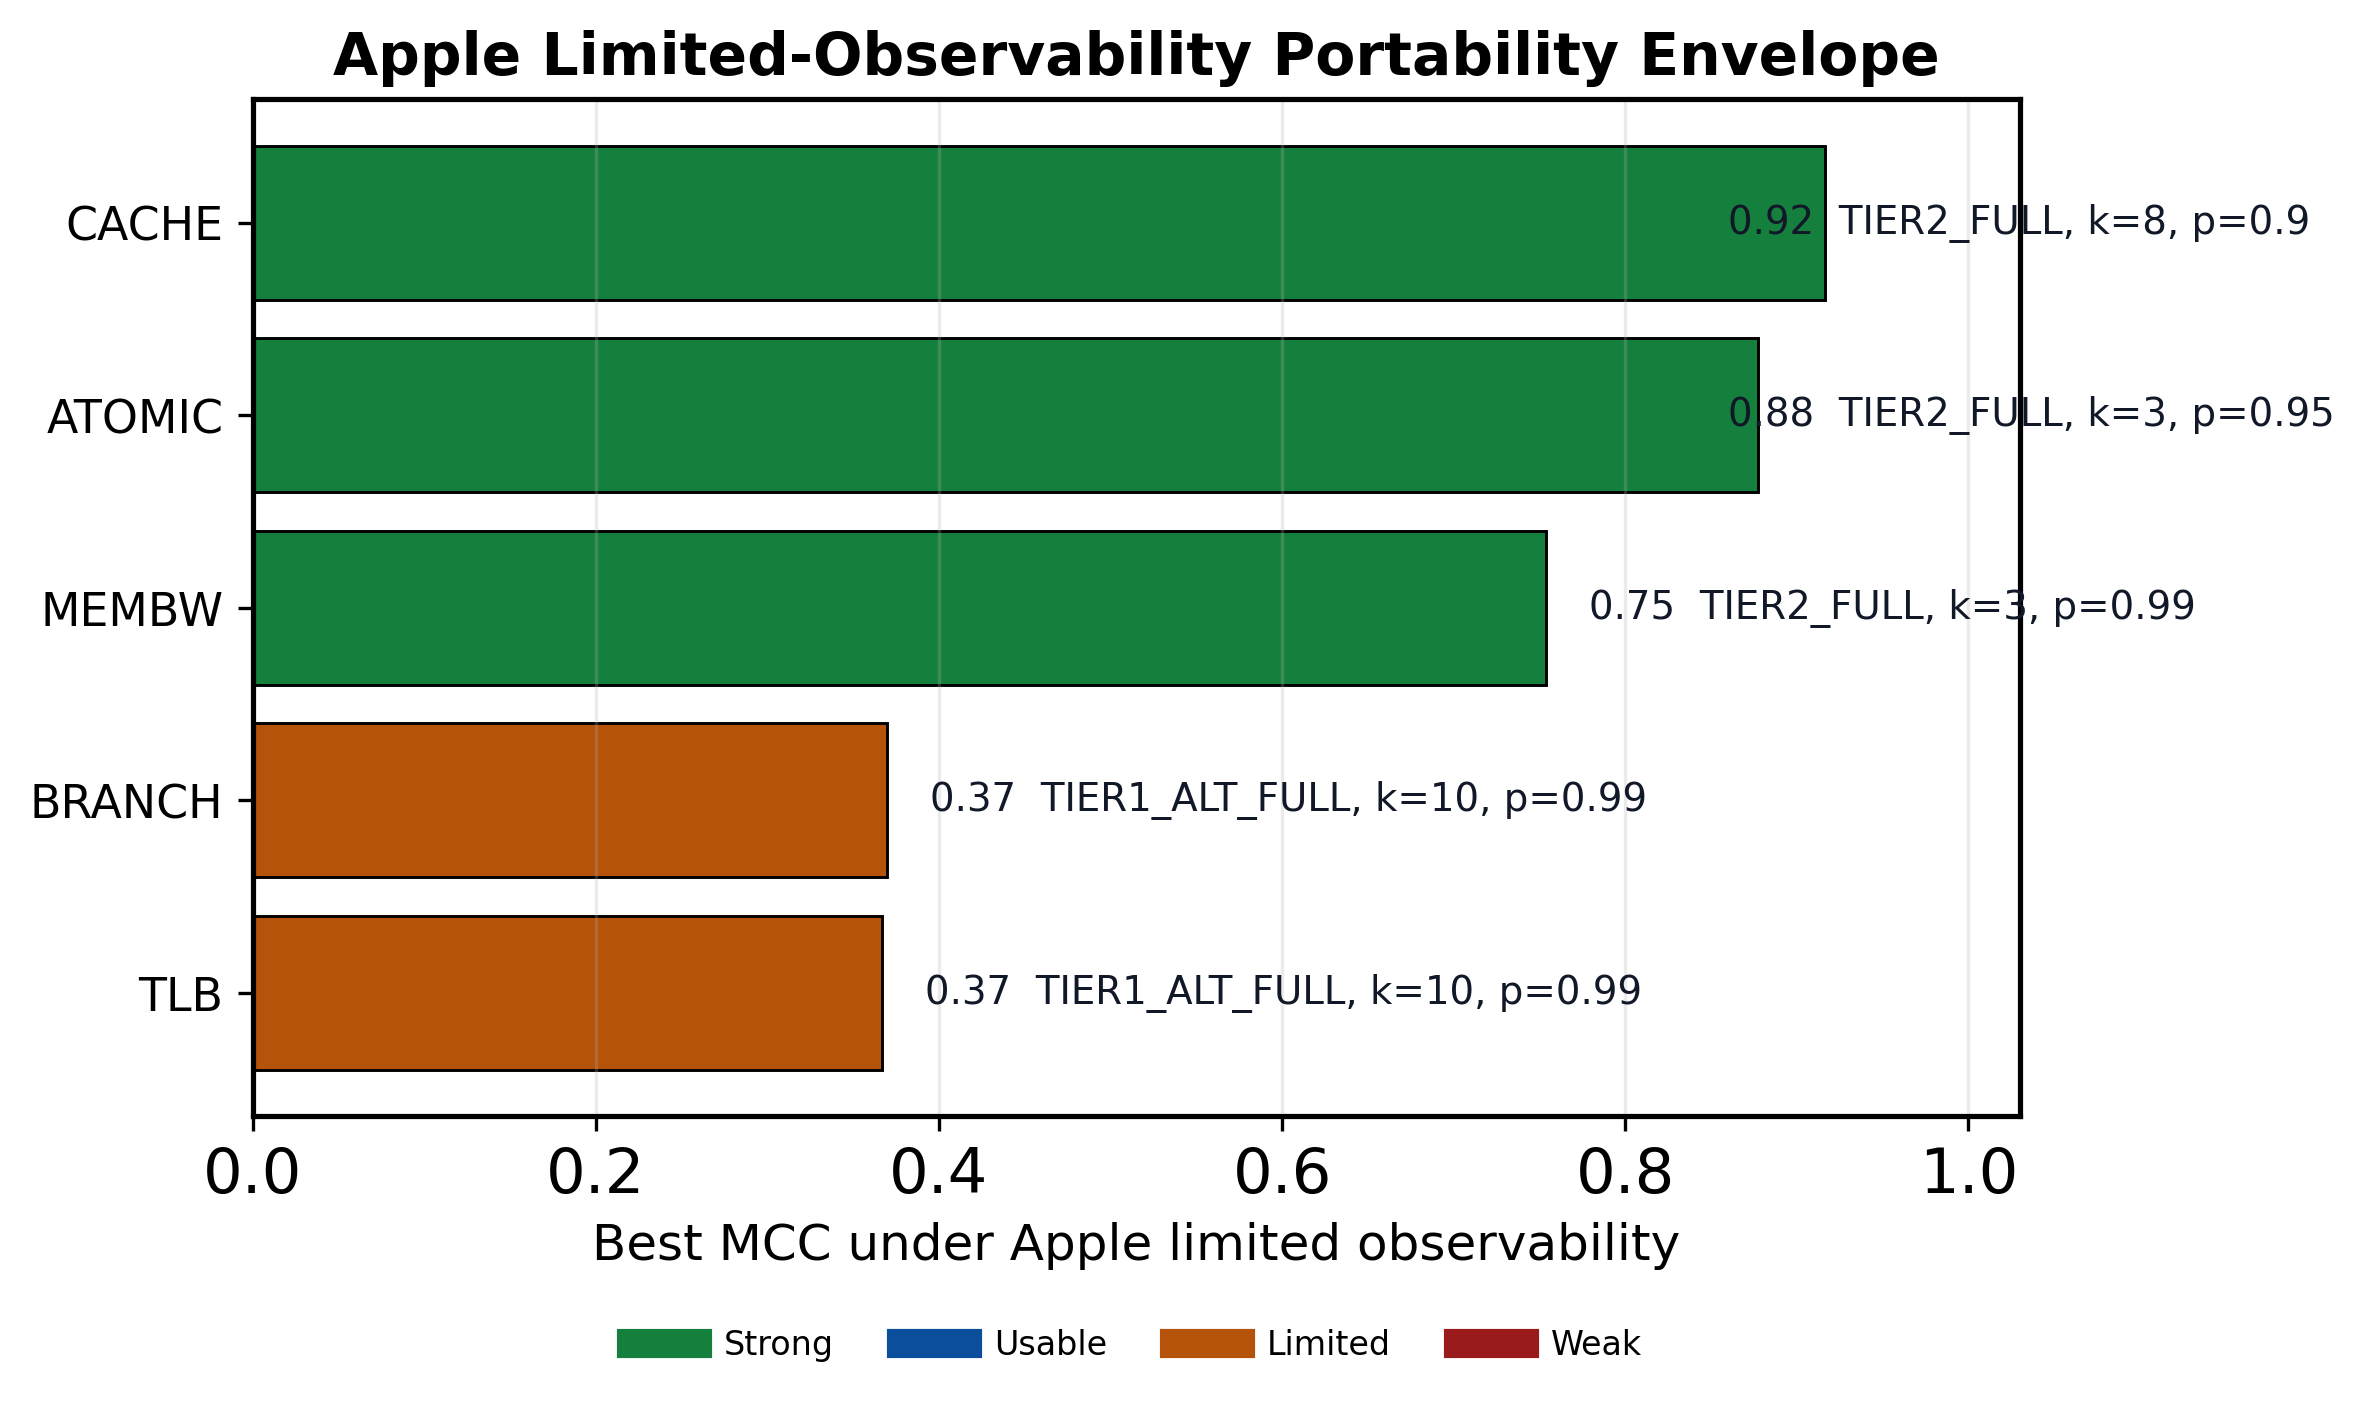

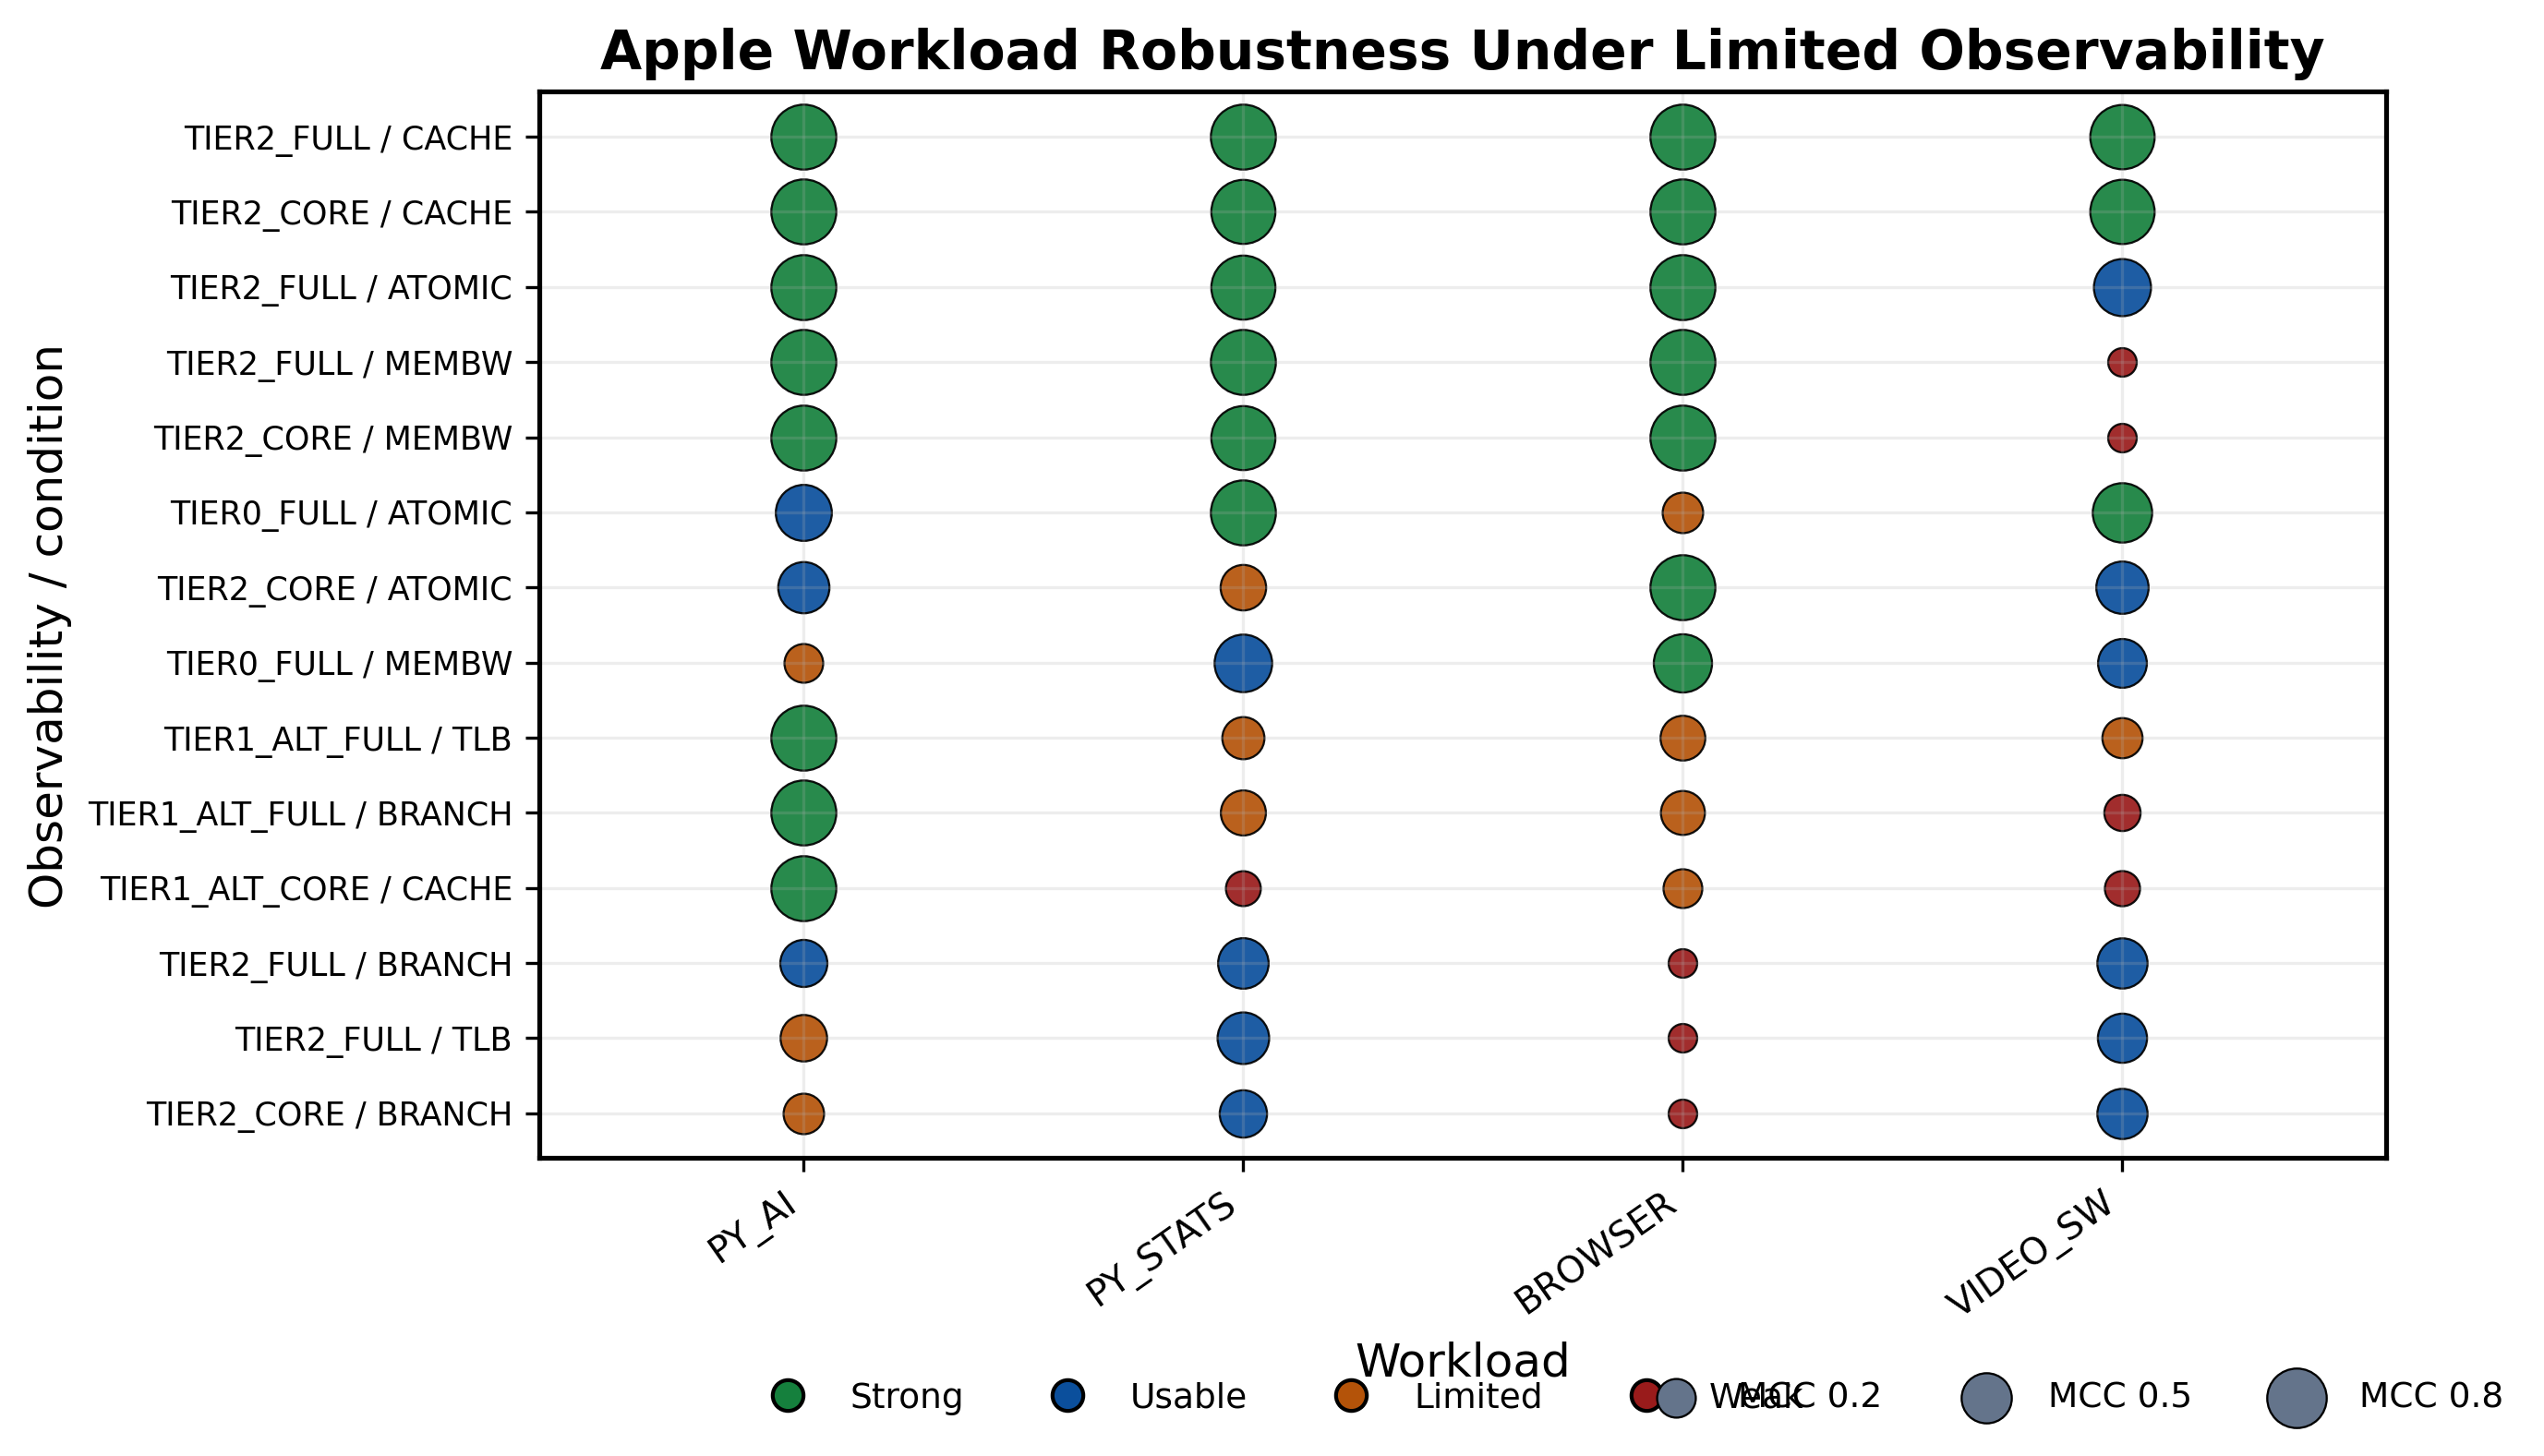

### Apple observability inventory

,observability,rows,workloads,scenarios_including_benign,available_features
0,TIER0_FULL,120000,4,6,45
1,TIER1_ALT_CORE,120000,4,6,11
2,TIER1_ALT_FULL,120000,4,6,18
3,TIER2_CORE,120000,4,6,7
4,TIER2_FULL,120000,4,6,8


### Apple supplemental best results by observability and condition

,observability,setup,scenario,window_size,agg_mode,lambda_res,p_quantile,top_k,weight_mode,fixed_point_q,...,auc_roc,auc_pr,f1,bal_acc,mcc,fpr,brier,ece,fp_mae,fp_max_abs
0,TIER2_FULL,TIER2_FULL,CACHE,250,mean,0.75,0.900,8,uniform,15,...,0.965337,0.943680,0.958225,0.956315,0.916633,0.087369,0.179703,0.314770,0.193400,6.100403
1,TIER2_FULL,TIER2_FULL,ATOMIC,250,median,0.25,0.950,3,inv_var,15,...,0.945675,0.947609,0.934641,0.937797,0.877554,0.037037,0.106605,0.147435,0.000273,0.001904
2,TIER2_CORE,TIER2_CORE,CACHE,250,median,0.75,0.950,7,uniform,15,...,0.959674,0.949080,0.930060,0.931149,0.864144,0.050332,0.143160,0.261768,0.220882,6.965403
3,TIER2_FULL,TIER2_FULL,MEMBW,150,median,0.75,0.990,3,uniform,15,...,0.822314,0.875726,0.841464,0.863636,0.753614,0.007576,0.306415,0.318399,0.000740,0.016193
4,TIER2_CORE,TIER2_CORE,MEMBW,250,median,0.50,0.975,7,uniform,15,...,0.794467,0.858233,0.842610,0.863010,0.748160,0.024691,0.312957,0.348616,0.263117,12.138305
5,TIER0_FULL,TIER0_FULL,ATOMIC,50,mean,0.25,0.900,3,uniform,15,...,0.863167,0.815708,0.654185,0.717549,0.467708,0.099989,0.211375,0.233097,1.079617,1.446091
6,TIER2_CORE,TIER2_CORE,ATOMIC,50,median,0.25,0.900,3,uniform,15,...,0.662703,0.723705,0.613048,0.692477,0.422116,0.102514,0.322545,0.315708,0.000702,0.017159
7,TIER1_ALT_CORE,TIER1_ALT_CORE,CACHE,50,mean,0.75,0.990,10,inv_var,15,...,0.478357,0.628342,0.424521,0.631270,0.376200,0.010025,0.401051,0.428648,0.000168,0.000168
8,TIER1_ALT_FULL,TIER1_ALT_FULL,BRANCH,100,median,0.25,0.990,10,inv_var,15,...,0.588671,0.676429,0.426382,0.629919,0.369602,0.015152,0.443279,0.459678,0.001426,0.014570
9,TIER1_ALT_FULL,TIER1_ALT_FULL,TLB,100,median,0.50,0.990,10,inv_var,15,...,0.540008,0.658018,0.419406,0.627356,0.367020,0.015152,0.439195,0.454530,0.001561,0.010380


### Apple workload robustness summary

,observability,scenario,workloads,mean_mcc,min_mcc,mean_fpr,max_fpr,median_top_k,median_window_size,median_p_quantile
0,TIER0_FULL,ATOMIC,4,0.680457,0.242171,0.024854,0.078582,4.0,100.0,0.9000
1,TIER0_FULL,BRANCH,4,0.237614,0.061514,0.010278,0.041111,5.5,175.0,0.9250
2,TIER0_FULL,CACHE,4,0.198341,0.126460,0.058816,0.116667,8.0,150.0,0.9000
3,TIER0_FULL,MEMBW,4,0.537817,0.200883,0.032146,0.078582,5.5,100.0,0.9000
4,TIER0_FULL,TLB,4,0.117386,0.033710,0.010278,0.041111,8.0,175.0,0.9000
5,TIER1_ALT_CORE,ATOMIC,4,0.173106,0.000000,0.013889,0.055556,6.5,250.0,0.9250
6,TIER1_ALT_CORE,BRANCH,4,0.218318,0.004880,0.011710,0.037037,6.5,125.0,0.9000
7,TIER1_ALT_CORE,CACHE,4,0.361202,0.118287,0.044643,0.178571,8.0,250.0,0.9000
8,TIER1_ALT_CORE,MEMBW,4,0.254944,0.124035,0.000000,0.000000,8.0,200.0,0.9000
9,TIER1_ALT_CORE,TLB,4,0.164187,0.000000,0.011905,0.047619,8.0,250.0,0.9000


Apple summary: results/notebook_run/apple_limited_observability/apple_observability_summary.csv
Apple best table: results/notebook_run/apple_limited_observability/apple_observability_best_by_scenario.csv
Apple workload summary: results/notebook_run/apple_limited_observability/apple_workload_summary.csv
Apple manifest: results/notebook_run/apple_limited_observability/run_manifest.json
[2026-06-12 09:19:21] | [Apple limited-observability] | DONE | elapsed=2768.3s | results/notebook_run/apple_limited_observability/run_manifest.json


In [25]:
# Supplemental limited-observability Apple case study.
# This is an observability/portability ablation, not part of CINTAS area/power claims.

from dataclasses import dataclass
from IPython.display import Image, Markdown, display

APPLE_OUT = RESULTS_ROOT / "apple_limited_observability"
APPLE_FIG_DIR = APPLE_OUT / "paper_figures"
APPLE_OUT.mkdir(parents=True, exist_ok=True)
APPLE_FIG_DIR.mkdir(parents=True, exist_ok=True)

APPLE_SCENARIOS = ("ATOMIC", "BRANCH", "CACHE", "MEMBW", "TLB")
APPLE_FEATURE_BUDGETS = (3, 5, 8, 10, 15)
APPLE_WINDOW_SIZES = (50, 100, 150, 250)
APPLE_LAMBDA_VALUES = (0.25, 0.5, 0.75)
APPLE_AGG_MODES = ("mean", "median", "max")
APPLE_WEIGHT_MODES = ("uniform", "inv_var")
APPLE_P_QUANTILES = (0.90, 0.95, 0.975, 0.99)
APPLE_FIXED_POINT_Q = 15
APPLE_N_SPLITS = 3
APPLE_GRAPH_BOOTSTRAPS = 4
APPLE_GRAPH_STABILITY_THRESHOLD = 0.50
APPLE_GRAPH_SUBSAMPLE_FRAC = 0.70
APPLE_DROP_TIME_COLUMNS = {
    "idx", "timestamp", "ts_unix_s", "t_rel_s", "uptime_s",
    "first_sample_time_ns", "last_sample_time_ns", "sample_span_ns",
}

@dataclass(frozen=True)
class AppleObservabilityConfig:
    scenarios_eval: tuple[str, ...] = APPLE_SCENARIOS
    feature_budgets: tuple[int, ...] = APPLE_FEATURE_BUDGETS
    window_sizes: tuple[int, ...] = APPLE_WINDOW_SIZES
    lambda_res_values: tuple[float, ...] = APPLE_LAMBDA_VALUES
    agg_modes: tuple[str, ...] = APPLE_AGG_MODES
    weight_modes: tuple[str, ...] = APPLE_WEIGHT_MODES
    p_quantiles: tuple[float, ...] = APPLE_P_QUANTILES
    fixed_point_q: int = APPLE_FIXED_POINT_Q
    n_splits: int = APPLE_N_SPLITS
    graph_bootstraps: int = APPLE_GRAPH_BOOTSTRAPS
    graph_subsample_frac: float = APPLE_GRAPH_SUBSAMPLE_FRAC
    graph_stability_threshold: float = APPLE_GRAPH_STABILITY_THRESHOLD
    seed: int = SEED

apple_cfg = AppleObservabilityConfig()


def _parse_apple_file(path: Path) -> dict[str, str]:
    rel = path.relative_to(APPLE_DATA_ROOT)
    tier = rel.parts[0]
    workload_scenario = rel.parts[1]
    if "__" not in workload_scenario:
        raise ValueError(f"Cannot parse Apple workload/scenario from {path}")
    workload, scenario = workload_scenario.split("__", 1)
    stem = path.stem.lower()
    view = "core" if "core" in stem else "full"
    observability = f"{tier}_{view}"
    scenario_u = scenario.upper()
    scenario_u = "BENIGN" if scenario_u == "NOMINAL" else scenario_u
    return {
        "tier": tier,
        "view": view,
        "observability": observability,
        "workload": workload.upper(),
        "scenario": scenario_u,
    }


def _load_apple_observability_frames(root: Path) -> dict[str, pd.DataFrame]:
    files = sorted(Path(root).rglob("*.csv"))
    if not files:
        raise FileNotFoundError(f"No Apple telemetry CSVs found under {root}")

    frames: dict[str, list[pd.DataFrame]] = {}
    for path in files:
        meta = _parse_apple_file(path)
        df = _sanitize_telemetry_columns(pd.read_csv(path))

        if "idx" in df.columns:
            time_idx = pd.to_numeric(df["idx"], errors="coerce")
            if time_idx.isna().any():
                time_idx = time_idx.fillna(pd.Series(np.arange(len(df)), index=df.index))
            df["time_idx"] = time_idx.astype(int)
        else:
            df["time_idx"] = np.arange(len(df), dtype=int)

        drop_cols = [c for c in APPLE_DROP_TIME_COLUMNS if c in df.columns]
        if drop_cols:
            df = df.drop(columns=drop_cols)

        obs = meta["observability"].upper()
        df["setup"] = obs
        df["observability"] = obs
        df["tier"] = meta["tier"]
        df["view"] = meta["view"]
        df["scenario"] = meta["scenario"]
        df["workload"] = meta["workload"]
        df["is_anom"] = 0 if meta["scenario"] == "BENIGN" else 1
        df["label"] = df["is_anom"]
        frames.setdefault(obs, []).append(df)

    return {
        obs: (
            pd.concat(parts, ignore_index=True)
            .sort_values(["workload", "scenario", "time_idx"])
            .reset_index(drop=True)
        )
        for obs, parts in frames.items()
    }


def _save_apple_table(df: pd.DataFrame, name: str) -> Path:
    path = APPLE_OUT / name
    df.to_csv(path, index=False)
    return path


def _save_apple_fig(fig, name: str) -> Path:
    path = APPLE_FIG_DIR / name
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    display(Image(filename=str(path)))
    return path


apple_progress = progress_start("Apple limited-observability", f"root={APPLE_DATA_ROOT.relative_to(REPO_ROOT)}")
apple_frames = _load_apple_observability_frames(APPLE_DATA_ROOT)
progress_update(
    "Apple limited-observability",
    "loaded observability views",
    start=apple_progress,
    detail=", ".join(sorted(apple_frames)),
)

apple_inventory_rows = []
apple_fold_frames = []
apple_selected_rows = []

for obs_idx, (obs, df_obs_raw) in enumerate(sorted(apple_frames.items()), start=1):
    progress_update(
        "Apple limited-observability",
        "processing observability view",
        start=apple_progress,
        current=obs_idx,
        total=len(apple_frames),
        detail=obs,
    )

    df_obs = clean_and_debias_telemetry(df_obs_raw)
    feature_cols = drop_constant_features(df_obs)
    if len(feature_cols) < 2:
        continue

    apple_inventory_rows.append({
        "observability": obs,
        "rows": len(df_obs),
        "workloads": df_obs["workload"].nunique(),
        "scenarios_including_benign": df_obs["scenario"].nunique(),
        "available_features": len(feature_cols),
    })

    base_model = fit_cintas_from_benign(df_obs, feature_cols, lambda_res=0.5, weight_mode="uniform")
    df_obs = df_obs.copy()
    df_obs["cias_sample_score"] = score_samples(df_obs, base_model)

    _, _, ranks = build_causal_and_rank_features_for_setup(
        setup=obs,
        df=df_obs,
        feature_cols=feature_cols,
        out_root=APPLE_OUT / obs.lower(),
        corr_threshold=0.35,
        top_k_plot=min(max(APPLE_FEATURE_BUDGETS), len(feature_cols)),
        score_col="cias_sample_score",
        graph_bootstraps=APPLE_GRAPH_BOOTSTRAPS,
        graph_subsample_frac=APPLE_GRAPH_SUBSAMPLE_FRAC,
        graph_stability_threshold=APPLE_GRAPH_STABILITY_THRESHOLD,
        seed=SEED + obs_idx,
    )

    for top_k in APPLE_FEATURE_BUDGETS:
        feats = _selected_features(ranks, min(int(top_k), len(feature_cols)), feature_cols)

        for lambda_res in APPLE_LAMBDA_VALUES:
            for weight_mode in APPLE_WEIGHT_MODES:
                model = fit_cintas_from_benign(
                    df_obs,
                    feats,
                    lambda_res=float(lambda_res),
                    weight_mode=weight_mode,
                )
                fp_err = _fixed_point_error(df_obs, model, APPLE_FIXED_POINT_Q)

                for agg_mode in APPLE_AGG_MODES:
                    for p_quantile in APPLE_P_QUANTILES:
                        eval_df = run_exact_eval_for_setup(
                            setup=obs,
                            df=df_obs,
                            model=model,
                            scenarios_eval=APPLE_SCENARIOS,
                            window_sizes=APPLE_WINDOW_SIZES,
                            n_splits_list=(APPLE_N_SPLITS,),
                            default_p_quantile=float(p_quantile),
                            agg_mode=agg_mode,
                            seed=SEED,
                        )
                        if eval_df.empty:
                            continue

                        eval_df["observability"] = obs
                        eval_df["top_k"] = int(len(feats))
                        eval_df["n_selected_features"] = int(len(feats))
                        eval_df["available_features"] = int(len(feature_cols))
                        eval_df["lambda_res"] = float(lambda_res)
                        eval_df["weight_mode"] = str(weight_mode)
                        eval_df["fixed_point_q"] = int(APPLE_FIXED_POINT_Q)
                        eval_df["p_quantile"] = float(p_quantile)
                        eval_df["fp_mae"] = fp_err["fp_mae"]
                        eval_df["fp_max_abs"] = fp_err["fp_max_abs"]

                        apple_fold_frames.append(eval_df)
                        apple_selected_rows.append({
                            "observability": obs,
                            "top_k": int(len(feats)),
                            "lambda_res": float(lambda_res),
                            "agg_mode": str(agg_mode),
                            "weight_mode": str(weight_mode),
                            "fixed_point_q": int(APPLE_FIXED_POINT_Q),
                            "p_quantile": float(p_quantile),
                            "available_features": int(len(feature_cols)),
                            "features": ",".join(feats),
                        })

apple_inventory = pd.DataFrame(apple_inventory_rows).sort_values("observability")
apple_fold_results = pd.concat(apple_fold_frames, ignore_index=True) if apple_fold_frames else pd.DataFrame()
if apple_fold_results.empty:
    raise RuntimeError("Apple supplemental study produced no evaluation rows.")

metric_cols = ["auc_roc", "auc_pr", "f1", "bal_acc", "mcc", "fpr", "brier", "ece", "fp_mae", "fp_max_abs"]
global_rows = apple_fold_results[apple_fold_results["workload"].astype(str).str.upper() == "ALL"].copy()

apple_summary = (
    global_rows.groupby([
        "observability", "setup", "scenario", "window_size", "agg_mode",
        "lambda_res", "p_quantile", "top_k", "weight_mode",
        "fixed_point_q", "n_selected_features", "available_features",
    ], as_index=False)[metric_cols]
    .mean(numeric_only=True)
)

rank_cols = ["mcc", "bal_acc", "auc_pr", "auc_roc", "f1", "fpr"]
apple_best = (
    apple_summary.sort_values(rank_cols, ascending=[False, False, False, False, False, True], kind="mergesort")
    .groupby(["observability", "scenario"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

per_workload = apple_fold_results[apple_fold_results["workload"].astype(str).str.upper() != "ALL"].copy()
workload_group_cols = [
    "observability", "scenario", "workload", "window_size", "agg_mode",
    "lambda_res", "p_quantile", "top_k", "weight_mode",
    "fixed_point_q", "n_selected_features", "available_features",
]

apple_workload_mean = (
    per_workload.groupby(workload_group_cols, as_index=False)[metric_cols]
    .mean(numeric_only=True)
)

apple_workload_best = (
    apple_workload_mean.sort_values(rank_cols, ascending=[False, False, False, False, False, True], kind="mergesort")
    .groupby(["observability", "scenario", "workload"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

apple_workload_summary = (
    apple_workload_best.groupby(["observability", "scenario"], as_index=False)
    .agg(
        workloads=("workload", "nunique"),
        mean_mcc=("mcc", "mean"),
        min_mcc=("mcc", "min"),
        mean_fpr=("fpr", "mean"),
        max_fpr=("fpr", "max"),
        median_top_k=("top_k", "median"),
        median_window_size=("window_size", "median"),
        median_p_quantile=("p_quantile", "median"),
    )
)

inventory_path = _save_apple_table(apple_inventory, "apple_observability_inventory.csv")
fold_path = _save_apple_table(apple_fold_results, "apple_observability_fold_results.csv")
summary_path = _save_apple_table(apple_summary, "apple_observability_summary.csv")
best_path = _save_apple_table(apple_best, "apple_observability_best_by_scenario.csv")
workload_best_path = _save_apple_table(apple_workload_best, "apple_workload_best_by_observability.csv")
workload_summary_path = _save_apple_table(apple_workload_summary, "apple_workload_summary.csv")
selected_path = _save_apple_table(pd.DataFrame(apple_selected_rows).drop_duplicates(), "apple_selected_features.csv")

# -----------------------------
# Figure 1: portability envelope by stress condition.
# -----------------------------
apple_best_by_condition = (
    apple_best.sort_values(
        ["scenario", "mcc", "bal_acc", "auc_pr", "auc_roc", "fpr"],
        ascending=[True, False, False, False, False, True],
        kind="mergesort",
    )
    .groupby("scenario", as_index=False)
    .head(1)
    .copy()
)

def _apple_status(mcc: float) -> str:
    if mcc >= 0.75:
        return "strong"
    if mcc >= 0.40:
        return "usable"
    if mcc >= 0.15:
        return "limited"
    return "weak"

status_colors = {
    "strong": "#15803D",
    "usable": "#0B4F9C",
    "limited": "#B45309",
    "weak": "#991B1B",
}

apple_best_by_condition["status"] = apple_best_by_condition["mcc"].map(_apple_status)
apple_best_by_condition = apple_best_by_condition.sort_values("mcc", ascending=True)

fig, ax = plt.subplots(figsize=(7.6, 4.4), dpi=220)
y = np.arange(len(apple_best_by_condition))

ax.barh(
    y,
    apple_best_by_condition["mcc"],
    color=[status_colors[s] for s in apple_best_by_condition["status"]],
    edgecolor="black",
    linewidth=0.7,
)

for yi, row in zip(y, apple_best_by_condition.itertuples(index=False)):
    ax.text(
        min(row.mcc + 0.025, 0.86),
        yi,
        f"{row.mcc:.2f}  {row.observability}, k={int(row.top_k)}, p={row.p_quantile:.3g}",
        va="center",
        fontsize=9.3,
        color="#111827",
    )

ax.set_yticks(y)
ax.set_yticklabels(apple_best_by_condition["scenario"], fontsize=11)
ax.set_xlim(0, 1.03)
ax.set_xlabel("Best MCC under Apple limited observability", fontsize=12)
ax.set_title("Apple Limited-Observability Portability Envelope", fontsize=14, fontweight="bold")
ax.grid(axis="x", alpha=0.25)

handles = [
    plt.Line2D([0], [0], color=color, lw=7, label=label.title())
    for label, color in status_colors.items()
]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4, frameon=False)

apple_obs_fig = _save_apple_fig(fig, "fig_apple_portability_envelope.png")

# -----------------------------
# Figure 2: workload robustness dot panel.
# -----------------------------
plot_wl = apple_workload_best.copy()
plot_wl["obs_scenario"] = plot_wl["observability"].astype(str) + " / " + plot_wl["scenario"].astype(str)

top_rows = (
    plot_wl.groupby("obs_scenario", as_index=False)["mcc"]
    .mean()
    .sort_values("mcc", ascending=False)
    .head(14)["obs_scenario"]
    .tolist()
)
plot_wl = plot_wl[plot_wl["obs_scenario"].isin(top_rows)].copy()
row_order = (
    plot_wl.groupby("obs_scenario")["mcc"]
    .mean()
    .sort_values(ascending=True)
    .index
    .tolist()
)
workload_order = plot_wl.groupby("workload")["mcc"].mean().sort_values(ascending=False).index.tolist()
row_map = {name: i for i, name in enumerate(row_order)}
x_map = {name: i for i, name in enumerate(workload_order)}

fig, ax = plt.subplots(figsize=(8.6, max(5.0, 0.34 * len(row_order))), dpi=220)

for row in plot_wl.itertuples(index=False):
    x = x_map[row.workload]
    yv = row_map[row.obs_scenario]
    ax.scatter(
        x,
        yv,
        s=55 + 230 * max(float(row.mcc), 0.0),
        color=status_colors[_apple_status(float(row.mcc))],
        edgecolors="black",
        linewidths=0.55,
        alpha=0.92,
    )

ax.set_xticks(np.arange(len(workload_order)))
ax.set_xticklabels(workload_order, rotation=35, ha="right", fontsize=9.5)
ax.set_yticks(np.arange(len(row_order)))
ax.set_yticklabels(row_order, fontsize=8.4)
ax.set_xlim(-0.6, len(workload_order) - 0.4)
ax.set_ylim(-0.6, len(row_order) - 0.4)
ax.set_xlabel("Workload", fontsize=12)
ax.set_ylabel("Observability / condition", fontsize=12)
ax.set_title("Apple Workload Robustness Under Limited Observability", fontsize=14, fontweight="bold")
ax.grid(True, axis="both", alpha=0.22)

size_handles = [
    plt.scatter([], [], s=55 + 230 * v, color="#64748B", edgecolors="black", linewidths=0.55, label=f"MCC {v:.1f}")
    for v in (0.2, 0.5, 0.8)
]
status_handles = [
    plt.Line2D([0], [0], marker="o", color="none", markerfacecolor=color, markeredgecolor="black", markersize=8, label=label.title())
    for label, color in status_colors.items()
]
first_legend = ax.legend(handles=status_handles, loc="upper center", bbox_to_anchor=(0.40, -0.18), ncol=4, frameon=False, fontsize=9)
ax.add_artist(first_legend)
ax.legend(handles=size_handles, loc="upper center", bbox_to_anchor=(0.83, -0.18), ncol=3, frameon=False, fontsize=9)

apple_workload_fig = _save_apple_fig(fig, "fig_apple_workload_robustness_dots.png")

manifest_path = write_run_manifest(
    APPLE_OUT,
    repo_root=REPO_ROOT,
    data_root=APPLE_DATA_ROOT,
    cfg=apple_cfg,
    seed=SEED,
    artifact_paths=(
        inventory_path,
        fold_path,
        summary_path,
        best_path,
        workload_best_path,
        workload_summary_path,
        selected_path,
        apple_obs_fig,
        apple_workload_fig,
    ),
)

display(Markdown("### Apple observability inventory"))
display(apple_inventory)
display(Markdown("### Apple supplemental best results by observability and condition"))
display(apple_best.round(6))
display(Markdown("### Apple workload robustness summary"))
display(apple_workload_summary.round(6))

print(f"Apple summary: {summary_path.relative_to(REPO_ROOT)}")
print(f"Apple best table: {best_path.relative_to(REPO_ROOT)}")
print(f"Apple workload summary: {workload_summary_path.relative_to(REPO_ROOT)}")
print(f"Apple manifest: {manifest_path.relative_to(REPO_ROOT)}")

progress_update(
    "Apple limited-observability",
    "DONE",
    start=apple_progress,
    detail=manifest_path.relative_to(REPO_ROOT),
)


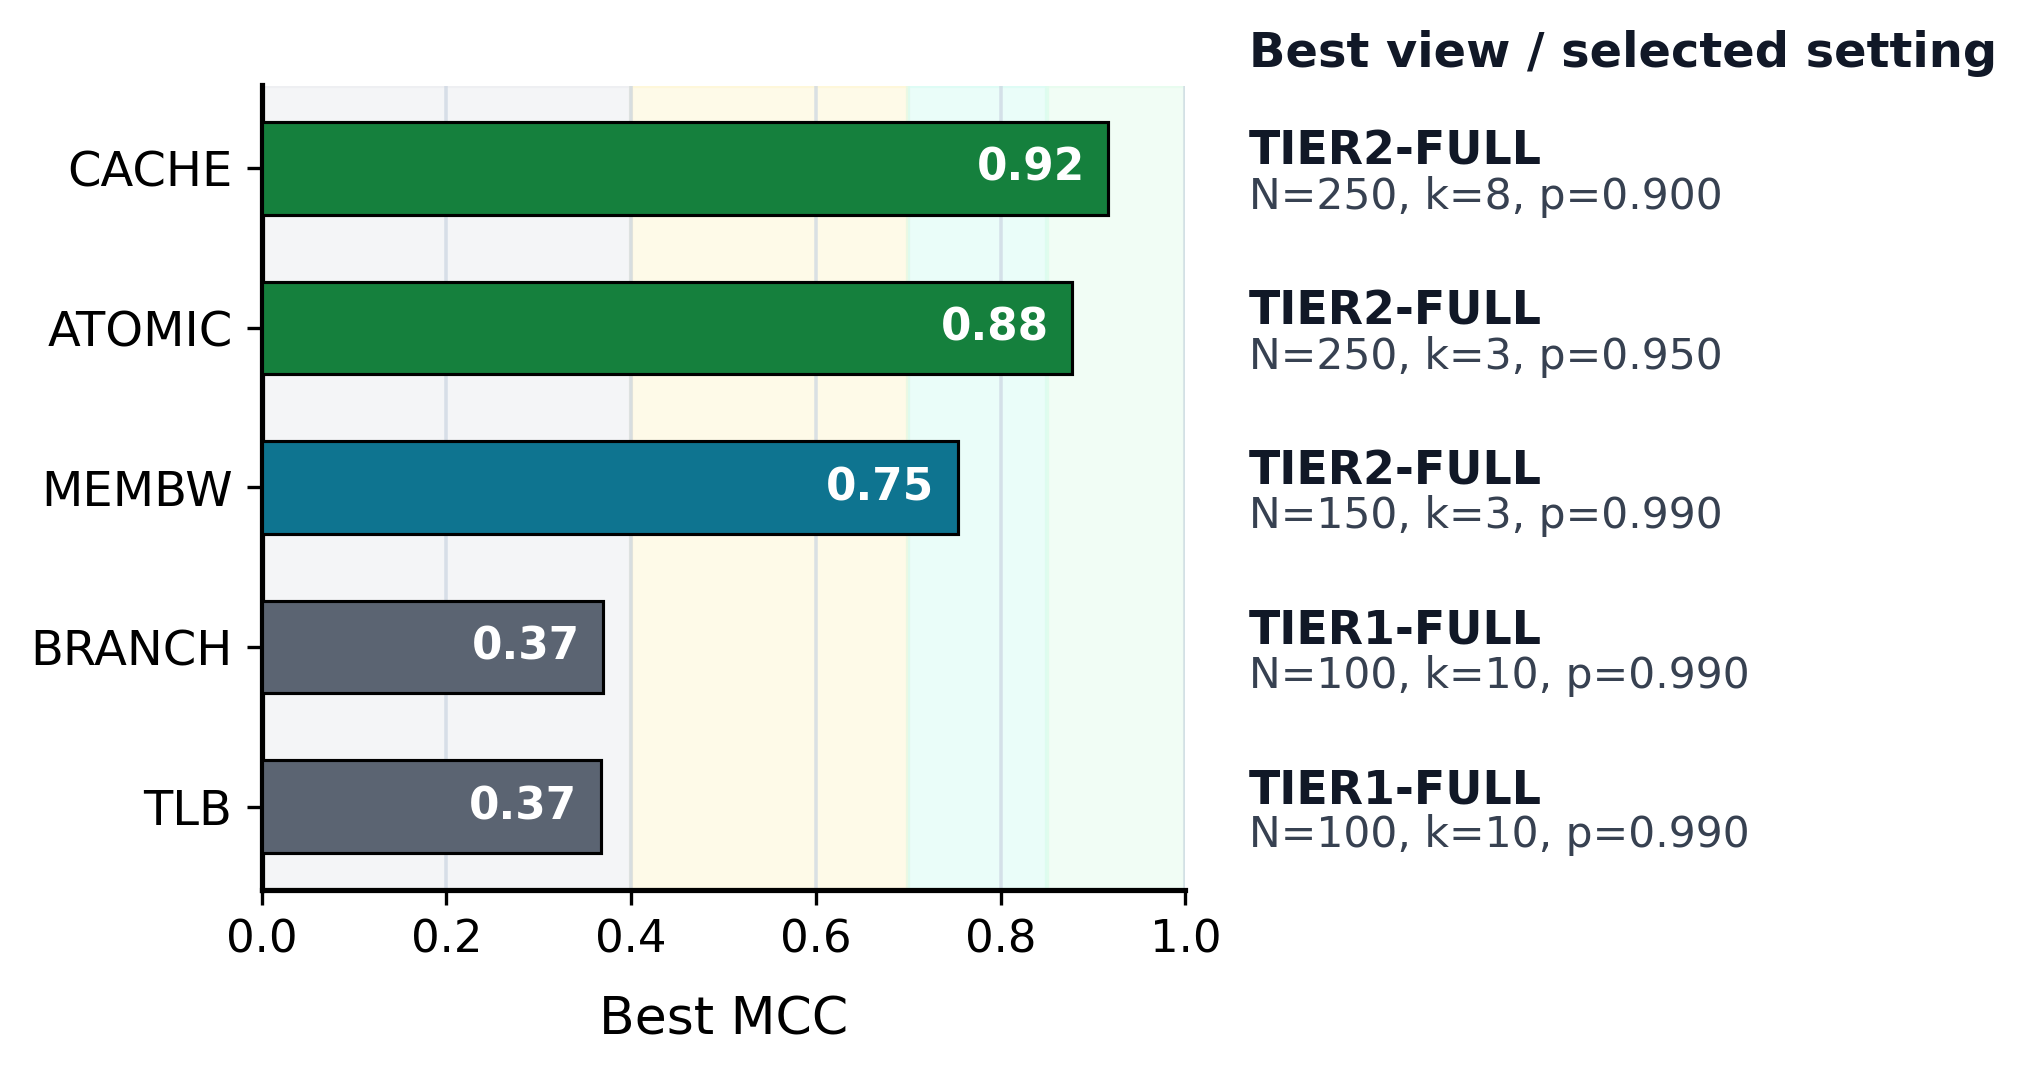

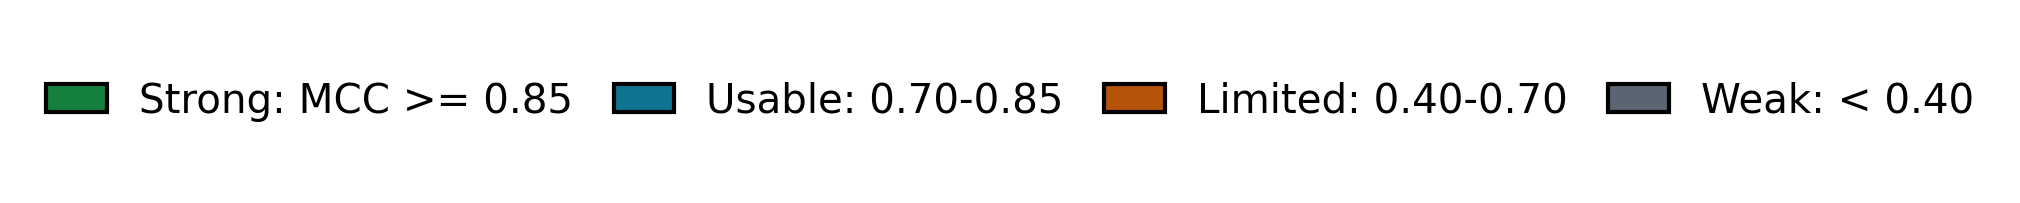

Saved figure: results/notebook_run/apple_limited_observability/paper_figures/fig_apple_portability_envelope.png
Saved legend: results/notebook_run/apple_limited_observability/paper_figures/fig_apple_portability_envelope_legend.png


In [26]:
# Figure: Apple limited-observability portability envelope.
# Saves the main plot and legend as separate PNG files.

import matplotlib.patches as mpatches

APPLE_OUT = RESULTS_ROOT / "apple_limited_observability"
APPLE_FIG_DIR = APPLE_OUT / "paper_figures"
APPLE_FIG_DIR.mkdir(parents=True, exist_ok=True)

APPLE_BEST_PATH = APPLE_OUT / "apple_observability_best_by_scenario.csv"

FIG_APPLE_PORT_OUT = APPLE_FIG_DIR / "fig_apple_portability_envelope.png"
FIG_APPLE_PORT_LEGEND_OUT = APPLE_FIG_DIR / "fig_apple_portability_envelope_legend.png"

apple_best = pd.read_csv(APPLE_BEST_PATH)

SCENARIO_ORDER = ["CACHE", "ATOMIC", "MEMBW", "BRANCH", "TLB"]

for col in [
    "mcc", "bal_acc", "auc_pr", "auc_roc", "f1", "fpr",
    "top_k", "window_size", "lambda_res", "p_quantile",
]:
    if col in apple_best.columns:
        apple_best[col] = pd.to_numeric(apple_best[col], errors="coerce")

scenario_order = [s for s in SCENARIO_ORDER if s in set(apple_best["scenario"].astype(str))]

best_rows = (
    apple_best[apple_best["scenario"].astype(str).isin(scenario_order)]
    .sort_values(
        ["scenario", "mcc", "bal_acc", "auc_pr", "auc_roc", "fpr"],
        ascending=[True, False, False, False, False, True],
        kind="mergesort",
    )
    .groupby("scenario", as_index=False)
    .head(1)
    .copy()
)

best_rows["scenario"] = pd.Categorical(
    best_rows["scenario"].astype(str),
    categories=scenario_order,
    ordered=True,
)
best_rows = best_rows.sort_values("scenario").reset_index(drop=True)


def _apple_display_view(label: str) -> str:
    s = str(label).upper()
    s = s.replace("TIER1_ALT", "TIER1")
    s = s.replace("_FULL", "-FULL")
    s = s.replace("_CORE", "-CORE")
    return s


def _apple_status(mcc: float) -> str:
    if mcc >= 0.85:
        return "Strong"
    if mcc >= 0.70:
        return "Usable"
    if mcc >= 0.40:
        return "Limited"
    return "Weak"


STATUS_COLORS = {
    "Strong": "#15803D",
    "Usable": "#0E7490",
    "Limited": "#B45309",
    "Weak": "#5B6472",
}

STATUS_BG = {
    "Strong": "#DCFCE7",
    "Usable": "#CCFBF1",
    "Limited": "#FEF3C7",
    "Weak": "#E5E7EB",
}

TEXT = "#111827"
GRID = "#CBD5E1"

best_rows["status"] = best_rows["mcc"].map(_apple_status)
bar_colors = [STATUS_COLORS[s] for s in best_rows["status"]]

fig = plt.figure(figsize=(6.85, 3.35), dpi=230)
grid = fig.add_gridspec(
    1,
    2,
    width_ratios=[2.75, 2.15],
    wspace=0.06,
)

ax = fig.add_subplot(grid[0, 0])
ax_info = fig.add_subplot(grid[0, 1], sharey=ax)

y = np.arange(len(best_rows))
mcc_vals = best_rows["mcc"].to_numpy(dtype=float)

# Light deployment bands without text inside the plot.
for x0, x1, status in [
    (0.00, 0.40, "Weak"),
    (0.40, 0.70, "Limited"),
    (0.70, 0.85, "Usable"),
    (0.85, 1.00, "Strong"),
]:
    ax.axvspan(x0, x1, color=STATUS_BG[status], alpha=0.40, zorder=0)

bars = ax.barh(
    y,
    mcc_vals,
    height=0.58,
    color=bar_colors,
    edgecolor="black",
    linewidth=0.75,
    zorder=3,
)

for yi, val in zip(y, mcc_vals):
    if val >= 0.18:
        ax.text(
            val - 0.025,
            yi,
            f"{val:.2f}",
            ha="right",
            va="center",
            fontsize=10.5,
            color="white",
            fontweight="bold",
            zorder=4,
        )
    else:
        ax.text(
            val + 0.025,
            yi,
            f"{val:.2f}",
            ha="left",
            va="center",
            fontsize=10.5,
            color=TEXT,
            zorder=4,
        )

ax.set_yticks(y)
ax.set_yticklabels(best_rows["scenario"].astype(str), fontsize=11.5)
ax.invert_yaxis()
ax.set_xlim(0.0, 1.0)
ax.set_xlabel("Best MCC", fontsize=12.5, labelpad=8)
ax.tick_params(axis="x", labelsize=10.8)
ax.grid(axis="x", color=GRID, alpha=0.70, linewidth=0.85, zorder=0)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

ax_info.set_xlim(0.0, 1.0)
ax_info.set_ylim(ax.get_ylim())
ax_info.axis("off")

ax_info.text(
    0.02,
    -0.72,
    "Best view / selected setting",
    ha="left",
    va="center",
    fontsize=11.5,
    fontweight="bold",
    color=TEXT,
)

for yi, row in best_rows.iterrows():
    view = _apple_display_view(row["observability"])
    setting = (
        f"N={int(row['window_size'])}, "
        f"k={int(row['top_k'])}, "
        f"p={float(row['p_quantile']):.3f}"
    )

    ax_info.text(
        0.02,
        yi - 0.10,
        view,
        ha="left",
        va="center",
        fontsize=11.0,
        fontweight="bold",
        color=TEXT,
    )

    ax_info.text(
        0.02,
        yi + 0.18,
        setting,
        ha="left",
        va="center",
        fontsize=10.2,
        color="#374151",
    )

fig.subplots_adjust(left=0.16, right=0.985, bottom=0.18, top=0.98)

fig.savefig(FIG_APPLE_PORT_OUT, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)

legend_handles = [
    mpatches.Patch(facecolor=STATUS_COLORS["Strong"], edgecolor="black", label="Strong: MCC >= 0.85"),
    mpatches.Patch(facecolor=STATUS_COLORS["Usable"], edgecolor="black", label="Usable: 0.70-0.85"),
    mpatches.Patch(facecolor=STATUS_COLORS["Limited"], edgecolor="black", label="Limited: 0.40-0.70"),
    mpatches.Patch(facecolor=STATUS_COLORS["Weak"], edgecolor="black", label="Weak: < 0.40"),
]

legend_fig, legend_ax = plt.subplots(figsize=(6.1, 0.62), dpi=230)
legend_ax.axis("off")
legend_ax.legend(
    handles=legend_handles,
    loc="center",
    ncol=4,
    frameon=False,
    fontsize=9.7,
    columnspacing=1.0,
    handlelength=1.5,
)

legend_fig.savefig(FIG_APPLE_PORT_LEGEND_OUT, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(legend_fig)

display(Image(filename=str(FIG_APPLE_PORT_OUT)))
display(Image(filename=str(FIG_APPLE_PORT_LEGEND_OUT)))

print(f"Saved figure: {FIG_APPLE_PORT_OUT.relative_to(REPO_ROOT)}")
print(f"Saved legend: {FIG_APPLE_PORT_LEGEND_OUT.relative_to(REPO_ROOT)}")


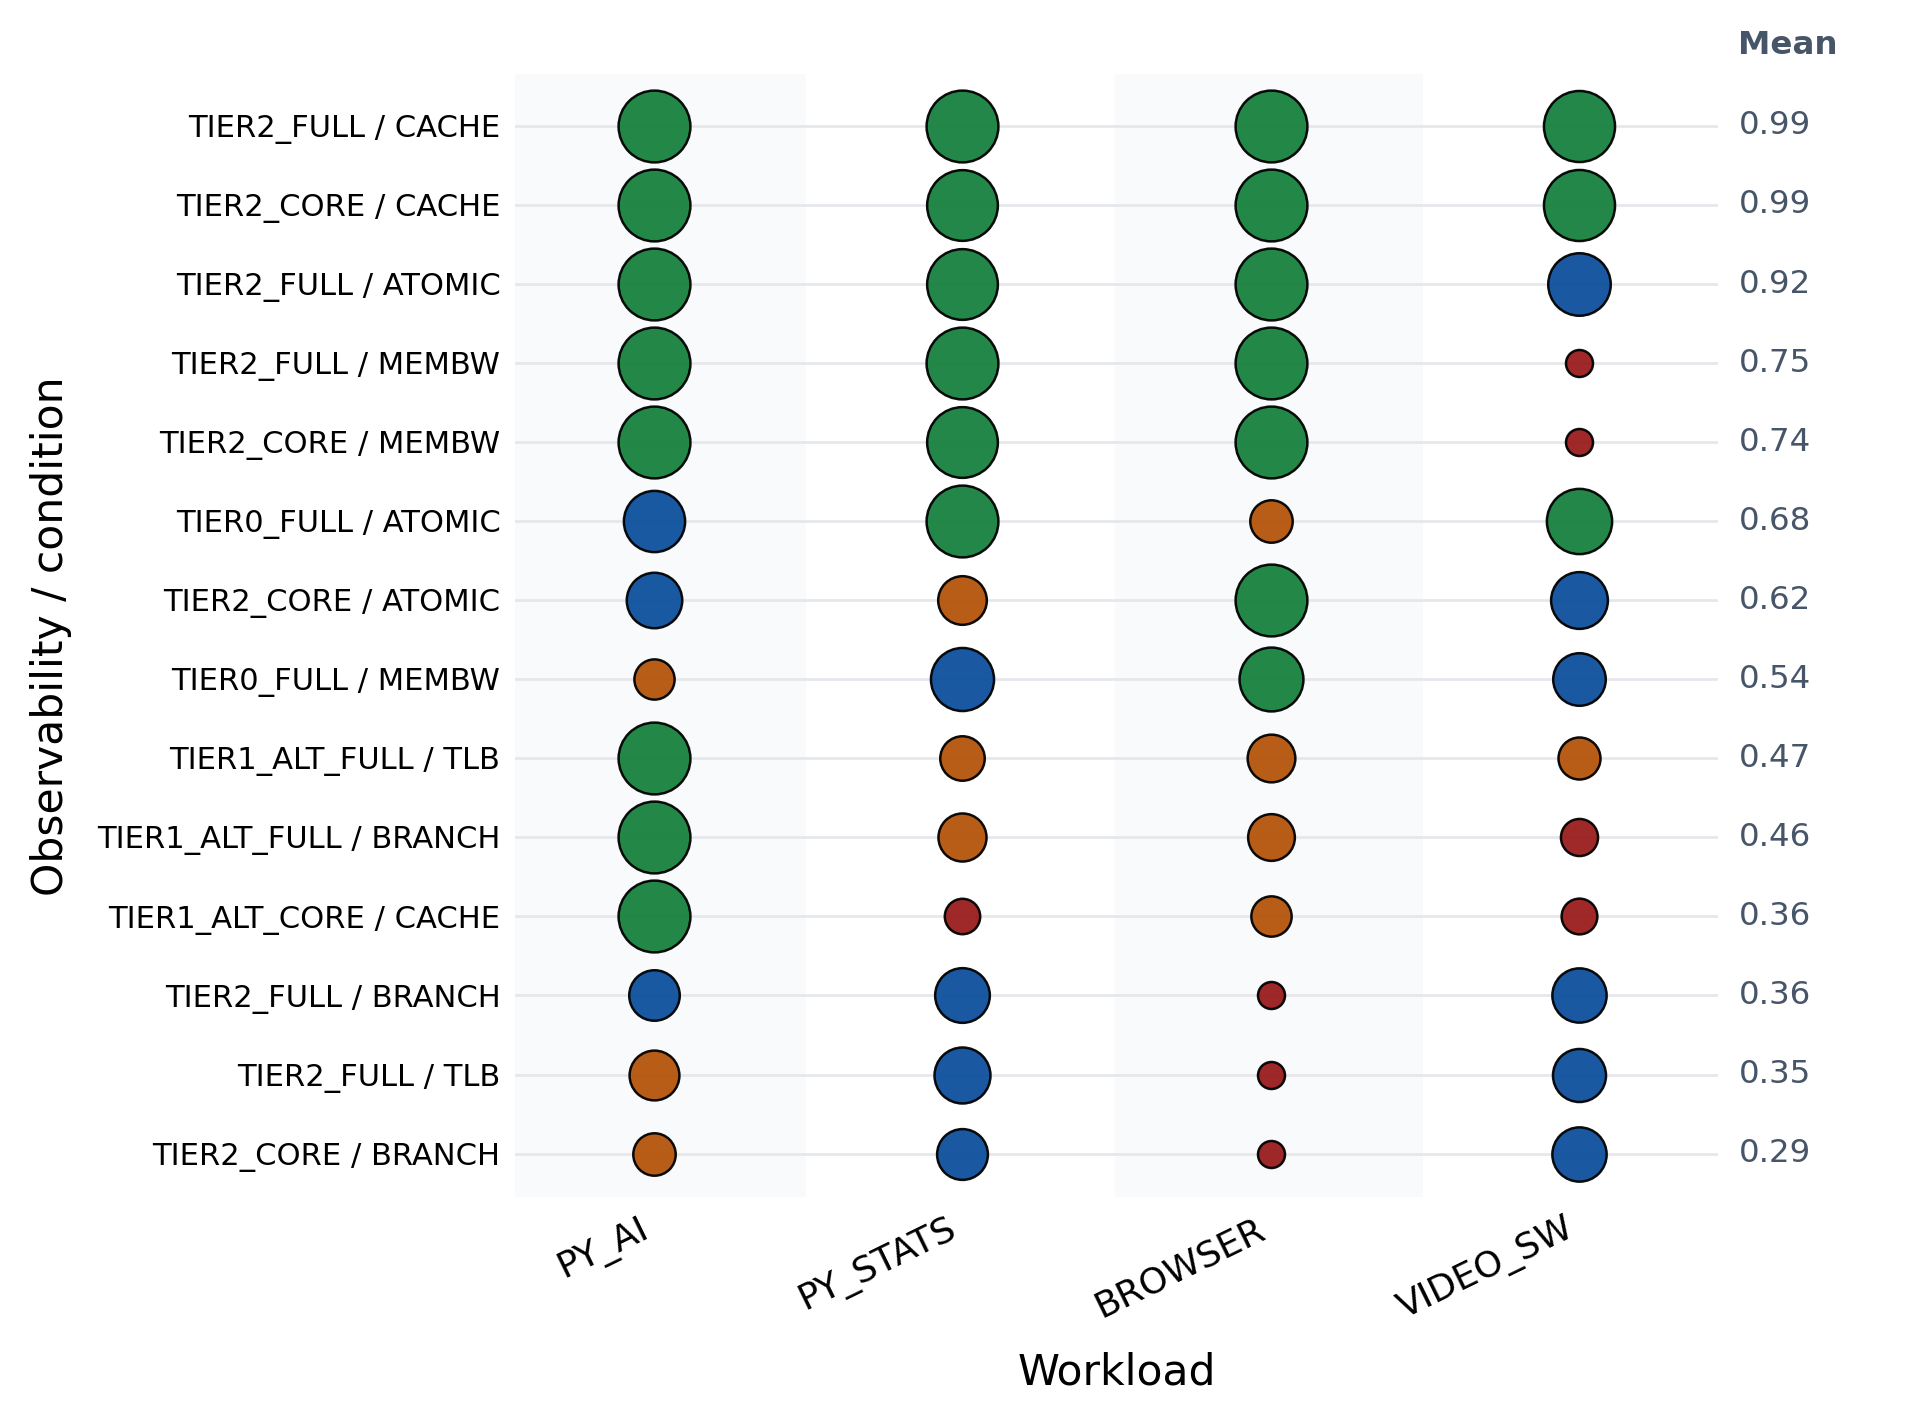

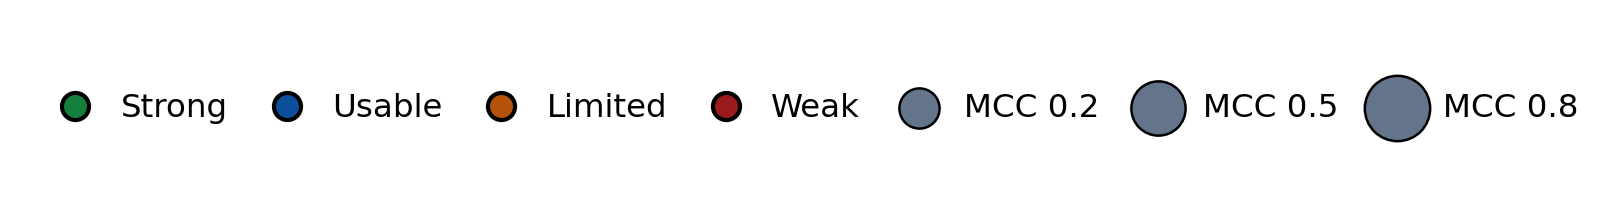

Saved figure: results/notebook_run/apple_limited_observability/paper_figures/fig_apple_workload_robustness_dots.png
Saved legend: results/notebook_run/apple_limited_observability/paper_figures/fig_apple_workload_robustness_dots_legend.png


In [27]:
# Figure: Apple workload robustness under limited observability.
# Saves two PNGs:
# 1. fig_apple_workload_robustness_dots.png
# 2. fig_apple_workload_robustness_dots_legend.png

APPLE_OUT = RESULTS_ROOT / "apple_limited_observability"
APPLE_FIG_DIR = APPLE_OUT / "paper_figures"
APPLE_FIG_DIR.mkdir(parents=True, exist_ok=True)

apple_workload_best = pd.read_csv(APPLE_OUT / "apple_workload_best_by_observability.csv")

def _apple_status(mcc: float) -> str:
    if mcc >= 0.75:
        return "strong"
    if mcc >= 0.40:
        return "usable"
    if mcc >= 0.15:
        return "limited"
    return "weak"

STATUS_COLORS = {
    "strong": "#15803D",
    "usable": "#0B4F9C",
    "limited": "#B45309",
    "weak": "#991B1B",
}

plot_wl = apple_workload_best.copy()
plot_wl["obs_scenario"] = (
    plot_wl["observability"].astype(str)
    + " / "
    + plot_wl["scenario"].astype(str)
)

top_rows = (
    plot_wl.groupby("obs_scenario", as_index=False)["mcc"]
    .mean()
    .sort_values("mcc", ascending=False)
    .head(14)["obs_scenario"]
    .tolist()
)
plot_wl = plot_wl[plot_wl["obs_scenario"].isin(top_rows)].copy()

row_summary = (
    plot_wl.groupby("obs_scenario", as_index=False)
    .agg(mean_mcc=("mcc", "mean"), min_mcc=("mcc", "min"))
    .sort_values(["mean_mcc", "min_mcc"], ascending=[True, True])
)

row_order = row_summary["obs_scenario"].tolist()
workload_order = (
    plot_wl.groupby("workload")["mcc"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

row_map = {name: i for i, name in enumerate(row_order)}
x_map = {name: i for i, name in enumerate(workload_order)}

# -----------------------------
# Main plot only.
# -----------------------------
fig = plt.figure(figsize=(6.85, max(4.45, 0.31 * len(row_order) + 0.65)), dpi=230)
grid = fig.add_gridspec(
    1, 2,
    width_ratios=[4.55, 0.58],
    wspace=0.03,
)

ax = fig.add_subplot(grid[0, 0])
ax_mean = fig.add_subplot(grid[0, 1], sharey=ax)

for x in range(len(workload_order)):
    ax.axvspan(
        x - 0.5,
        x + 0.5,
        color="#F8FAFC" if x % 2 == 0 else "#FFFFFF",
        zorder=0,
    )

for yv in range(len(row_order)):
    ax.axhline(yv, color="#E5E7EB", linewidth=0.65, zorder=0)

for row in plot_wl.itertuples(index=False):
    x = x_map[row.workload]
    yv = row_map[row.obs_scenario]
    mcc = float(row.mcc)
    status = _apple_status(mcc)

    ax.scatter(
        x,
        yv,
        s=42 + 255 * max(mcc, 0.0),
        color=STATUS_COLORS[status],
        edgecolors="black",
        linewidths=0.60,
        alpha=0.94,
        zorder=3,
    )

ax.set_xticks(np.arange(len(workload_order)))
ax.set_xticklabels(workload_order, rotation=26, ha="right", fontsize=8.7)
ax.set_yticks(np.arange(len(row_order)))
ax.set_yticklabels(row_order, fontsize=7.35)
ax.set_xlim(-0.45, len(workload_order) - 0.55)
ax.set_ylim(-0.55, len(row_order) - 0.35)
ax.set_xlabel("Workload", fontsize=10.2, labelpad=6)
ax.set_ylabel("Observability / condition", fontsize=10.2, labelpad=6)
ax.tick_params(axis="both", length=0)

for spine in ["top", "right", "left", "bottom"]:
    ax.spines[spine].set_visible(False)

ax_mean.set_xlim(0, 1)
ax_mean.set_ylim(ax.get_ylim())
ax_mean.axis("off")
ax_mean.text(
    0.0,
    1.012,
    "Mean",
    transform=ax_mean.transAxes,
    ha="left",
    va="bottom",
    fontsize=7.8,
    fontweight="bold",
    color="#475569",
)

for item in row_summary.itertuples(index=False):
    yv = row_map[item.obs_scenario]
    ax_mean.text(
        0.0,
        yv,
        f"{item.mean_mcc:.2f}",
        ha="left",
        va="center",
        fontsize=7.8,
        color="#475569",
    )

fig.subplots_adjust(left=0.31, right=0.98, top=0.94, bottom=0.19)

fig_path = APPLE_FIG_DIR / "fig_apple_workload_robustness_dots.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(fig)

# -----------------------------
# Separate legend PNG.
# -----------------------------
status_handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor=STATUS_COLORS[s],
        markeredgecolor="black",
        markersize=6.5,
        label=s.title(),
    )
    for s in ["strong", "usable", "limited", "weak"]
]
size_handles = [
    plt.scatter(
        [], [],
        s=42 + 255 * v,
        color="#64748B",
        edgecolors="black",
        linewidths=0.60,
        label=f"MCC {v:.1f}",
    )
    for v in (0.2, 0.5, 0.8)
]

legend_fig, legend_ax = plt.subplots(figsize=(6.3, 0.68), dpi=230)
legend_ax.axis("off")
legend_ax.legend(
    handles=status_handles + size_handles,
    loc="center",
    ncol=7,
    frameon=False,
    fontsize=7.8,
    handletextpad=0.40,
    columnspacing=0.80,
)

legend_path = APPLE_FIG_DIR / "fig_apple_workload_robustness_dots_legend.png"
legend_fig.savefig(legend_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.close(legend_fig)

display(Image(filename=str(fig_path)))
display(Image(filename=str(legend_path)))
print(f"Saved figure: {fig_path.relative_to(REPO_ROOT)}")
print(f"Saved legend: {legend_path.relative_to(REPO_ROOT)}")



## 12. Supplemental Rapid Benign Workload Transition Experiment

**Fresh kernel run sequence.** Run the first repository import cell, the Section 1 reproducibility configuration cell, and the Section 2 integrated utilities cell. Then run only the two code cells in this section. Do not use `Run All` when you only want this experiment because the earlier design space studies are intentionally expensive. Leave `RUN_APPLE_TRANSITION_COLLECTION = False` to analyze the accepted local trace again. Set it to `True` only when you want to collect a new 12 minute trace.

This opt in experiment records one uninterrupted Tier 0 telemetry stream while the Apple platform switches repeatedly among `BROWSER`, `PY_AI`, `PY_STATS`, and `VIDEO_SW`. All phases are benign. The first cycle supplies in session stable calibration data, with the first 10 seconds after each switch excluded. CITADEL is then frozen and evaluated on the remaining two cycles. Its selected features, normalization parameters, scoring rule, decision block length, and threshold do not change during evaluation.

Set `RUN_APPLE_TRANSITION_COLLECTION = True` in the next cell and run it once on the evaluated Apple machine. The default protocol uses three cycles, 60 seconds per workload, and 5 Hz telemetry, for about 12 minutes plus a short schema probe. The collector does not change voltage, temperature, firmware, or clock settings. `BROWSER` requires network access, `PY_AI` uses Torch when available and records any NumPy fallback, and `PY_STATS` allocates about 0.37 GiB. To analyze an existing run without recollecting, leave the switch `False`; the notebook selects the newest complete trace.

The analysis reports the overall benign false positive rate, the false positive rate in the first three decision blocks after each switch, blocks required for the score to stabilize, the result of the existing $\operatorname{FPR}_r > \eta$ reference validity rule, and the same quantities after a two block persistence rule. Results are saved under `results/notebook_run/apple_workload_transitions/`. This is a limited observability workflow experiment and is not evidence about Intel telemetry, firmware transitions, controlled thermal changes, or physical aging.


In [ ]:
# Opt in collection. Leave False when analyzing a trace that was already collected.
RUN_APPLE_TRANSITION_COLLECTION = False
APPLE_TRANSITION_TRACE_OVERRIDE = None  # Example: Path("data/telemetry/raw/apple_transitions/<run_id>/transition_trace.csv")
APPLE_TRANSITION_HZ = 5
APPLE_TRANSITION_PROBE_SECONDS = 5
APPLE_TRANSITION_DWELL_SECONDS = 60
APPLE_TRANSITION_CYCLES = 3
APPLE_TRANSITION_STATS_ELEMENTS = 100_000_000

APPLE_TRANSITION_RAW_ROOT = REPO_ROOT / "data" / "telemetry" / "raw" / "apple_transitions"
APPLE_TRANSITION_COLLECTOR = REPO_ROOT / "scripts" / "collect_apple_workload_transitions.py"

if RUN_APPLE_TRANSITION_COLLECTION:
    transition_collect_cmd = [
        sys.executable,
        str(APPLE_TRANSITION_COLLECTOR),
        "--output-root", str(APPLE_TRANSITION_RAW_ROOT),
        "--hz", str(APPLE_TRANSITION_HZ),
        "--probe-seconds", str(APPLE_TRANSITION_PROBE_SECONDS),
        "--dwell-seconds", str(APPLE_TRANSITION_DWELL_SECONDS),
        "--cycles", str(APPLE_TRANSITION_CYCLES),
        "--stats-elements", str(APPLE_TRANSITION_STATS_ELEMENTS),
    ]
    print("Starting the continuous Apple workload transition collection...")
    subprocess.run(transition_collect_cmd, cwd=REPO_ROOT, check=True)
else:
    print("Collection is disabled. The analysis cell will use the newest complete trace, if present.")


In [ ]:
# Analyze a continuous benign workload transition trace with one frozen CINTAS reference.
from dataclasses import asdict, dataclass
from IPython.display import Image, Markdown, display

@dataclass(frozen=True)
class AppleTransitionConfig:
    workloads: tuple[str, ...] = ("BROWSER", "PY_AI", "PY_STATS", "VIDEO_SW")
    reference_cycle_index: int = 0
    warmup_samples_after_switch: int = 50
    top_k: int = 8
    lambda_res: float = 0.50
    weight_mode: str = "uniform"
    window_size: int = 50
    agg_mode: str = "mean"
    p_quantile: float = 0.99
    persistence_blocks: int = 2
    transition_window_blocks: int = 3
    stabilization_confirm_blocks: int = 3
    eta: float = 0.01
    corr_threshold: float = 0.35
    seed: int = SEED

apple_transition_cfg = AppleTransitionConfig()
APPLE_TRANSITION_OUT = RESULTS_ROOT / "apple_workload_transitions"
APPLE_TRANSITION_OUT.mkdir(parents=True, exist_ok=True)

def _latest_complete_transition_trace(root: Path) -> Path | None:
    candidates = []
    for trace_path in Path(root).glob("*/transition_trace.csv"):
        manifest_path = trace_path.with_name("collection_manifest.json")
        try:
            manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
        except Exception:
            continue
        if manifest.get("status") == "complete":
            candidates.append(trace_path)
    return max(candidates, key=lambda path: path.stat().st_mtime) if candidates else None

APPLE_TRANSITION_MONOTONIC_COUNTERS = ("ctx_switches", "interrupts", "soft_interrupts", "syscalls")
APPLE_TRANSITION_META_COLUMNS = {
    "idx", "ts_unix_s", "t_rel_s", "uptime_s", "time_idx",
    "phase_index", "cycle_index", "workload", "source_trace",
    "scenario", "setup", "label", "is_anom",
}

def _counter_rates(frame: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    out = frame.copy()
    groups = out.groupby(group_cols, sort=False, dropna=False) if group_cols else [(None, out)]
    converted = []
    for _, group in groups:
        group = group.sort_values("idx").copy()
        if "t_rel_s" in group.columns:
            dt = pd.to_numeric(group["t_rel_s"], errors="coerce").diff()
        else:
            dt = pd.Series(1.0 / APPLE_TRANSITION_HZ, index=group.index)
        dt = dt.where(dt > 0)
        for column in APPLE_TRANSITION_MONOTONIC_COUNTERS:
            if column in group.columns:
                values = pd.to_numeric(group[column], errors="coerce")
                group[column] = values.diff() / dt
        converted.append(group)
    return pd.concat(converted, ignore_index=True)

def _aggregate_scores(scores: np.ndarray, mode: str) -> float:
    if mode == "mean":
        return float(np.mean(scores))
    if mode == "median":
        return float(np.median(scores))
    return float(np.max(scores))

def _reference_blocks(frame: pd.DataFrame, model: CINTASModel, cfg: AppleTransitionConfig) -> pd.DataFrame:
    rows = []
    for workload, group in frame.groupby("workload", sort=True):
        group = group.sort_values("idx").reset_index(drop=True)
        scores = score_samples(group, model)
        for block_index in range(len(scores) // cfg.window_size):
            start = block_index * cfg.window_size
            stop = start + cfg.window_size
            rows.append({
                "workload": workload,
                "block_index": block_index,
                "score": _aggregate_scores(scores[start:stop], cfg.agg_mode),
            })
    return pd.DataFrame(rows)

def _transition_blocks(frame: pd.DataFrame, model: CINTASModel, cfg: AppleTransitionConfig) -> pd.DataFrame:
    ordered = frame.sort_values("idx").reset_index(drop=True).copy()
    ordered["score_sample"] = score_samples(ordered, model)
    rows = []
    for block_index in range(len(ordered) // cfg.window_size):
        start = block_index * cfg.window_size
        stop = start + cfg.window_size
        block = ordered.iloc[start:stop]
        rows.append({
            "block_index": block_index,
            "start_sample_index": int(block["idx"].iloc[0]),
            "end_sample_index": int(block["idx"].iloc[-1]),
            "start_time_s": float(block["t_rel_s"].iloc[0]),
            "end_time_s": float(block["t_rel_s"].iloc[-1]),
            "phase_index_start": int(block["phase_index"].iloc[0]),
            "phase_index_end": int(block["phase_index"].iloc[-1]),
            "workload_start": str(block["workload"].iloc[0]),
            "workload_end": str(block["workload"].iloc[-1]),
            "score": _aggregate_scores(block["score_sample"].to_numpy(dtype=float), cfg.agg_mode),
        })
    return pd.DataFrame(rows)

def _persistence_alarm(raw_alarm: np.ndarray, required: int) -> np.ndarray:
    run_length = 0
    output = np.zeros(len(raw_alarm), dtype=int)
    for index, alarm in enumerate(np.asarray(raw_alarm, dtype=int)):
        run_length = run_length + 1 if alarm else 0
        output[index] = int(run_length >= required)
    return output

def _blocks_to_stabilize(alarms: np.ndarray, start: int, confirm: int) -> float:
    alarms = np.asarray(alarms, dtype=int)
    for index in range(start, len(alarms) - confirm + 1):
        if np.all(alarms[index:index + confirm] == 0):
            return float(index - start + 1)
    return float("nan")

def run_apple_transition_analysis(trace_path: Path, cfg: AppleTransitionConfig) -> dict[str, Path | pd.DataFrame]:
    trace_path = Path(trace_path).resolve()
    collection_manifest_path = trace_path.with_name("collection_manifest.json")
    collection_manifest = json.loads(collection_manifest_path.read_text(encoding="utf-8"))
    if collection_manifest.get("status") != "complete":
        raise RuntimeError(f"Transition trace is not complete: {collection_manifest_path}")

    transition_raw = _sanitize_telemetry_columns(pd.read_csv(trace_path))
    required_meta = {"idx", "t_rel_s", "phase_index", "cycle_index", "workload"}
    missing_meta = sorted(required_meta - set(transition_raw.columns))
    if missing_meta:
        raise ValueError(f"Transition trace is missing metadata columns: {missing_meta}")

    transition = _counter_rates(transition_raw, [])
    transition["scenario"] = "BENIGN"
    transition["setup"] = "APPLE_TRANSITION"

    transition_numeric = set(transition.select_dtypes(include=[np.number]).columns) - APPLE_TRANSITION_META_COLUMNS
    candidate_features = sorted(transition_numeric)
    if not candidate_features:
        raise RuntimeError("No numeric Tier 0 features were found in the transition trace.")

    reference_cycle = transition[transition["cycle_index"] == cfg.reference_cycle_index].copy()
    evaluation = transition[transition["cycle_index"] > cfg.reference_cycle_index].copy()
    if reference_cycle.empty or evaluation.empty:
        raise RuntimeError("The trace must contain one reference cycle followed by at least one evaluation cycle.")
    calibration_parts = []
    for _, phase in reference_cycle.groupby("phase_index", sort=True):
        phase = phase.sort_values("idx").reset_index(drop=True)
        steady = phase.iloc[cfg.warmup_samples_after_switch:].copy()
        if len(steady) < cfg.window_size:
            raise RuntimeError("A reference workload phase has too few steady samples after warmup exclusion.")
        calibration_parts.append(steady)
    calibration = pd.concat(calibration_parts, ignore_index=True)
    calibration_means = calibration[candidate_features].replace([np.inf, -np.inf], np.nan).mean()
    finite_features = [feature for feature in candidate_features if np.isfinite(calibration_means[feature])]
    for frame in (calibration, evaluation):
        frame[finite_features] = frame[finite_features].replace([np.inf, -np.inf], np.nan)
        frame[finite_features] = frame[finite_features].fillna(calibration_means[finite_features])
    variable_features = [
        feature for feature in finite_features
        if calibration[feature].nunique(dropna=True) > 1 and float(calibration[feature].std(ddof=1)) > 0.0
    ]
    if len(variable_features) < 2:
        raise RuntimeError("Fewer than two usable shared Tier 0 features remain after preprocessing.")

    base_model = fit_cintas_from_benign(
        calibration, variable_features, lambda_res=cfg.lambda_res, weight_mode=cfg.weight_mode
    )
    rank_input = calibration.copy()
    rank_input["cias_sample_score"] = score_samples(rank_input, base_model)
    ranks = _rank_features_from_benign_only(
        setup="APPLE_TRANSITION",
        df_benign=rank_input,
        feature_cols=variable_features,
        out_root=APPLE_TRANSITION_OUT,
        corr_threshold=cfg.corr_threshold,
        tag="in_session_reference_cycle",
    )
    selected_features = _selected_features(ranks, min(cfg.top_k, len(variable_features)), variable_features)
    frozen_model = fit_cintas_from_benign(
        calibration, selected_features, lambda_res=cfg.lambda_res, weight_mode=cfg.weight_mode
    )

    reference_blocks = _reference_blocks(calibration, frozen_model, cfg)
    if reference_blocks.empty:
        raise RuntimeError("The in session reference cycle does not contain a complete decision block.")
    threshold = float(np.quantile(reference_blocks["score"].to_numpy(dtype=float), cfg.p_quantile))
    blocks = _transition_blocks(evaluation, frozen_model, cfg)
    if blocks.empty:
        raise RuntimeError("Transition trace does not contain a complete decision block.")

    blocks["threshold"] = threshold
    blocks["alarm_raw"] = (blocks["score"] >= threshold).astype(int)
    blocks["alarm_persistence"] = _persistence_alarm(
        blocks["alarm_raw"].to_numpy(dtype=int), cfg.persistence_blocks
    )
    switch_rows = (
        evaluation.sort_values("idx")
        .groupby("phase_index", as_index=False, sort=True)
        .first()[["phase_index", "cycle_index", "workload", "idx", "t_rel_s"]]
    )
    switch_rows = switch_rows[switch_rows["phase_index"] > 0].reset_index(drop=True)
    blocks["is_transition_window"] = False
    blocks["transition_phase_index"] = pd.Series([pd.NA] * len(blocks), dtype="Int64")
    event_rows = []
    for event in switch_rows.itertuples(index=False):
        start_sample = int(event.idx)
        mask = (
            (blocks["end_sample_index"] >= start_sample)
            & (blocks["start_sample_index"] < start_sample + cfg.transition_window_blocks * cfg.window_size)
        )
        blocks.loc[mask, "is_transition_window"] = True
        blocks.loc[mask, "transition_phase_index"] = int(event.phase_index)
        containing = blocks.index[blocks["end_sample_index"] >= start_sample]
        if len(containing) == 0:
            continue
        start_block = int(containing[0])
        event_rows.append({
            "phase_index": int(event.phase_index),
            "cycle_index": int(event.cycle_index),
            "workload_after_switch": str(event.workload),
            "switch_sample_index": start_sample,
            "switch_time_s": float(event.t_rel_s),
            "first_decision_block": start_block,
            "raw_blocks_to_stabilize": _blocks_to_stabilize(
                blocks["alarm_raw"].to_numpy(dtype=int), start_block, cfg.stabilization_confirm_blocks
            ),
            "persistence_blocks_to_clear": _blocks_to_stabilize(
                blocks["alarm_persistence"].to_numpy(dtype=int), start_block, cfg.stabilization_confirm_blocks
            ),
            "peak_score_in_transition_window": float(blocks.loc[mask, "score"].max()) if mask.any() else float("nan"),
            "raw_alarms_in_transition_window": int(blocks.loc[mask, "alarm_raw"].sum()),
            "persistence_alarms_in_transition_window": int(blocks.loc[mask, "alarm_persistence"].sum()),
        })
    event_summary = pd.DataFrame(event_rows)

    transition_mask = blocks["is_transition_window"].to_numpy(dtype=bool)
    rule_rows = []
    for rule_name, alarm_column in (("current", "alarm_raw"), ("persistence", "alarm_persistence")):
        alarms = blocks[alarm_column].to_numpy(dtype=int)
        overall_fpr = float(np.mean(alarms))
        transition_fpr = float(np.mean(alarms[transition_mask])) if np.any(transition_mask) else float("nan")
        steady_fpr = float(np.mean(alarms[~transition_mask])) if np.any(~transition_mask) else float("nan")
        stabilization_column = "raw_blocks_to_stabilize" if rule_name == "current" else "persistence_blocks_to_clear"
        stabilization_values = event_summary[stabilization_column] if not event_summary.empty else pd.Series(dtype=float)
        rule_rows.append({
            "decision_rule": rule_name,
            "persistence_blocks": 1 if rule_name == "current" else cfg.persistence_blocks,
            "n_blocks": int(len(blocks)),
            "n_transition_blocks": int(np.sum(transition_mask)),
            "n_alarm_blocks": int(np.sum(alarms)),
            "overall_benign_fpr": overall_fpr,
            "transition_window_fpr": transition_fpr,
            "steady_window_fpr": steady_fpr,
            "median_blocks_to_stabilize": float(stabilization_values.median()) if stabilization_values.notna().any() else float("nan"),
            "maximum_blocks_to_stabilize": float(stabilization_values.max()) if stabilization_values.notna().any() else float("nan"),
            "unresolved_switches": int(stabilization_values.isna().sum()),
            "eta": cfg.eta,
            "reference_status": "stale" if overall_fpr > cfg.eta else "valid",
        })
    rule_summary = pd.DataFrame(rule_rows)

    selected_table = ranks[ranks["feature"].isin(selected_features)].copy()
    selected_table["selected_order"] = selected_table["feature"].map({f: i + 1 for i, f in enumerate(selected_features)})
    selected_table = selected_table.sort_values("selected_order")

    block_path = APPLE_TRANSITION_OUT / "transition_block_scores.csv"
    event_path = APPLE_TRANSITION_OUT / "transition_event_summary.csv"
    rule_path = APPLE_TRANSITION_OUT / "transition_rule_summary.csv"
    selected_path = APPLE_TRANSITION_OUT / "transition_selected_features.csv"
    reference_path = APPLE_TRANSITION_OUT / "reference_cycle_block_scores.csv"
    blocks.to_csv(block_path, index=False)
    event_summary.to_csv(event_path, index=False)
    rule_summary.to_csv(rule_path, index=False)
    selected_table.to_csv(selected_path, index=False)
    reference_blocks.to_csv(reference_path, index=False)

    current = rule_summary.set_index("decision_rule").loc["current"]
    persistence = rule_summary.set_index("decision_rule").loc["persistence"]

    # Publication figure: workload context, score interpretation, and rule outcomes.
    from matplotlib.patches import Patch

    plot_start = float(blocks["start_time_s"].min())
    plot_end = float(blocks["end_time_s"].max())
    score_top = max(float(blocks["score"].max()) * 1.14, threshold * 1.35)
    phase_colors = {
        "BROWSER": "#DBEAFE",
        "PY_AI": "#EDE9FE",
        "PY_STATS": "#DCFCE7",
        "VIDEO_SW": "#FFEDD5",
    }
    phase_rows = switch_rows.sort_values("t_rel_s").reset_index(drop=True)

    fig, (ax_score, ax_status) = plt.subplots(
        2, 1, figsize=(13.2, 7.8), dpi=220, sharex=True,
        gridspec_kw={"height_ratios": [4.7, 1.25], "hspace": 0.28},
    )
    fig.suptitle(
        "Rapid Benign Workload Changes Expose a Stale CINTAS Reference",
        fontsize=19, fontweight="bold", y=0.985,
    )

    for phase_index, event in enumerate(phase_rows.itertuples(index=False)):
        phase_start = max(plot_start, float(event.t_rel_s))
        phase_end = (
            min(plot_end, float(phase_rows.iloc[phase_index + 1]["t_rel_s"]))
            if phase_index + 1 < len(phase_rows) else plot_end
        )
        if phase_end <= phase_start:
            continue
        workload = str(event.workload)
        color = phase_colors.get(workload, "#F1F5F9")
        ax_score.axvspan(phase_start, phase_end, color=color, alpha=0.62, zorder=0)
        ax_status.axvspan(phase_start, phase_end, color=color, alpha=0.28, zorder=0)
        ax_score.text(
            (phase_start + phase_end) / 2.0, 0.955, workload.replace("_", " "),
            transform=ax_score.get_xaxis_transform(), ha="center", va="top",
            fontsize=11.5, fontweight="bold", color="#1E293B",
            bbox={"boxstyle": "round,pad=0.22", "facecolor": "white",
                  "edgecolor": color, "alpha": 0.90},
        )

    ax_score.axhspan(threshold, score_top, color="#FEE2E2", alpha=0.28, zorder=0.2)
    ax_score.plot(
        blocks["start_time_s"], blocks["score"], color="#0B4F9C",
        linewidth=2.7, marker="o", markersize=5.8, markerfacecolor="white",
        markeredgewidth=1.6, label="Frozen CINTAS score", zorder=3,
    )
    ax_score.axhline(
        threshold, color="#991B1B", linestyle="--", linewidth=2.2,
        label=f"Frozen threshold = {threshold:.2f}", zorder=2,
    )
    raw_alarm_blocks = blocks[blocks["alarm_raw"] == 1]
    ax_score.scatter(
        raw_alarm_blocks["start_time_s"], raw_alarm_blocks["score"],
        color="#D94801", edgecolors="white", linewidths=0.9, s=58,
        zorder=4, label="Threshold exceedance",
    )

    for event in phase_rows.itertuples(index=False):
        switch_time = float(event.t_rel_s)
        ax_score.axvline(switch_time, color="#64748B", linewidth=1.0, alpha=0.62, zorder=1)
        ax_status.axvline(switch_time, color="#64748B", linewidth=1.0, alpha=0.62, zorder=1)

    summary_text = (
        "REFERENCE STATUS: STALE\n"
        f"Overall FPR: {100 * current.overall_benign_fpr:.2f}%   |   "
        f"Transition FPR: {100 * current.transition_window_fpr:.2f}%\n"
        f"{int(current.unresolved_switches)} of {len(event_summary)} switches did not stabilize"
    )
    ax_score.text(
        0.985, 0.055, summary_text, transform=ax_score.transAxes,
        ha="right", va="bottom", fontsize=11.5, fontweight="bold",
        color="#7F1D1D", linespacing=1.35,
        bbox={"boxstyle": "round,pad=0.55", "facecolor": "#FFF7ED",
              "edgecolor": "#C2410C", "linewidth": 1.4, "alpha": 0.96},
        zorder=6,
    )
    ax_score.text(
        plot_start + 6.0, threshold + 0.28, "Above threshold = alarm",
        fontsize=11, fontweight="bold", color="#991B1B",
    )
    ax_score.set_ylim(0.55, score_top)
    ax_score.set_ylabel("Decision block score", fontsize=14, fontweight="bold")
    ax_score.set_title("A. Frozen score trajectory", loc="left", fontsize=14, fontweight="bold", pad=12)
    ax_score.tick_params(axis="both", labelsize=11.5)
    ax_score.grid(axis="y", alpha=0.24, linewidth=0.8)
    score_handles, score_labels = ax_score.get_legend_handles_labels()
    fig.legend(
        score_handles, score_labels, loc="upper center", bbox_to_anchor=(0.5, 0.925),
        fontsize=11.5, frameon=True, framealpha=0.96, ncol=3,
    )

    status_rows = [(1.0, "alarm_raw"), (0.0, "alarm_persistence")]
    for y_value, alarm_column in status_rows:
        for block in blocks.itertuples(index=False):
            alarm = int(getattr(block, alarm_column))
            ax_status.barh(
                y_value, float(block.end_time_s) - float(block.start_time_s),
                left=float(block.start_time_s), height=0.68,
                color="#DC2626" if alarm else "#16A34A",
                edgecolor="white", linewidth=0.45, zorder=2,
            )
    ax_status.set_yticks([1.0, 0.0], labels=["Current rule", "Two block persistence"])
    ax_status.set_ylim(-0.62, 1.62)
    ax_status.set_xlim(plot_start, plot_end)
    ax_status.set_xlabel("Time from collection start (s)", fontsize=14, fontweight="bold")
    ax_status.set_title("B. Decision outcome for each 50 sample block", loc="left", fontsize=14, fontweight="bold", pad=8)
    ax_status.tick_params(axis="x", labelsize=11.5)
    ax_status.tick_params(axis="y", labelsize=11.5, length=0)
    ax_status.legend(
        handles=[Patch(facecolor="#16A34A", label="No alarm"), Patch(facecolor="#DC2626", label="Alarm")],
        loc="lower right", bbox_to_anchor=(1.0, 1.02), fontsize=10.5,
        frameon=False, ncol=2, borderaxespad=0.0,
    )
    for spine in ("top", "right"):
        ax_score.spines[spine].set_visible(False)
        ax_status.spines[spine].set_visible(False)
    fig.subplots_adjust(top=0.82, bottom=0.10, left=0.10, right=0.985, hspace=0.28)
    figure_path = APPLE_TRANSITION_OUT / "fig_apple_workload_transition_scores.png"
    fig.savefig(figure_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)

    resolved_stabilization = event_summary["raw_blocks_to_stabilize"].dropna().astype(int).tolist() if not event_summary.empty else []
    median_stabilization = float(np.median(resolved_stabilization)) if resolved_stabilization else float("nan")
    resolved_stabilization_text = " and ".join(str(value) for value in resolved_stabilization)
    resolved_switches = int(event_summary["raw_blocks_to_stabilize"].notna().sum()) if not event_summary.empty else 0
    unresolved_switches = int(event_summary["raw_blocks_to_stabilize"].isna().sum()) if not event_summary.empty else 0
    evaluation_cycles = int(evaluation["cycle_index"].nunique())
    paper_text = (
        f"After one in session reference cycle containing {len(reference_blocks)} reference blocks, the frozen configuration was evaluated for {evaluation_cycles} cycles containing {len(switch_rows)} workload switches and {len(blocks)} decision blocks. "
        f"With the frozen reference, the overall false positive rate was {100 * current.overall_benign_fpr:.2f} percent and the rate within the first {cfg.transition_window_blocks} blocks after each switch was {100 * current.transition_window_fpr:.2f} percent. "
        f"Only {resolved_switches} of {len(event_summary)} switches stabilized, after {resolved_stabilization_text} decision blocks (median {median_stabilization:.1f}), while {unresolved_switches} switches did not stabilize during their observed phases. "
        f"A {cfg.persistence_blocks} block persistence rule changed the overall false positive rate to {100 * persistence.overall_benign_fpr:.2f} percent and the transition window rate to {100 * persistence.transition_window_fpr:.2f} percent. "
        f"Under the FPR_r greater than eta rule with eta={cfg.eta:.3f}, the frozen reference was marked {current.reference_status}."
    )
    paper_text_path = APPLE_TRANSITION_OUT / "paper_ready_result.txt"
    paper_text_path.write_text(paper_text + "\n", encoding="utf-8")

    artifact_paths = [block_path, event_path, rule_path, selected_path, reference_path, figure_path, paper_text_path]
    manifest_payload = {
        "seed": cfg.seed,
        "git_commit": _git_commit(REPO_ROOT),
        "git_dirty": _git_dirty(REPO_ROOT),
        "config": asdict(cfg),
        "collection_manifest": _safe_relative(collection_manifest_path, REPO_ROOT),
        "inputs": [
            {"path": _safe_relative(path, REPO_ROOT), "sha256": sha256_file(path)}
            for path in [trace_path, collection_manifest_path]
        ],
        "selected_features": selected_features,
        "threshold": threshold,
        "artifacts": [
            {"path": _safe_relative(path, REPO_ROOT), "sha256": sha256_file(path)} for path in artifact_paths
        ],
    }
    analysis_manifest_path = APPLE_TRANSITION_OUT / "run_manifest.json"
    analysis_manifest_path.write_text(json.dumps(manifest_payload, indent=2, sort_keys=True) + "\n", encoding="utf-8")

    display(Markdown("### Rapid benign workload transition results"))
    display(rule_summary.round(6))
    display(Markdown("### Per switch stabilization"))
    display(event_summary.round(6))
    display(Image(filename=str(figure_path)))
    display(Markdown("**Draft result sentence:** " + paper_text))
    return {
        "rule_summary": rule_summary,
        "event_summary": event_summary,
        "blocks": blocks,
        "manifest": analysis_manifest_path,
        "figure": figure_path,
        "paper_text": paper_text_path,
    }

transition_trace = Path(APPLE_TRANSITION_TRACE_OVERRIDE) if APPLE_TRANSITION_TRACE_OVERRIDE else _latest_complete_transition_trace(APPLE_TRANSITION_RAW_ROOT)
if transition_trace is None:
    apple_transition_results = None
    display(Markdown(
        "**No complete transition trace was found.** Set `RUN_APPLE_TRANSITION_COLLECTION = True`, run the collection cell once, then run this analysis cell."
    ))
else:
    print(f"Analyzing transition trace: {_safe_relative(transition_trace, REPO_ROOT)}")
    apple_transition_results = run_apple_transition_analysis(transition_trace, apple_transition_cfg)


## 13. Paper-Ready Output Checklist

This final checklist confirms that the notebook has produced the artifacts needed to finish the TCAD result section. A complete run should include the integrated DSE summary, selected-feature file, paper gallery, lifecycle drift outputs, fixed-point golden vectors, optional Vivado/RTL summary, paper TBD replacement CSV, Apple supplemental artifacts, and the rapid benign workload transition results.

If the RTL summary is still a template, the paper can report analytical hardware-cost estimates but should label them as estimates. Once Vivado results are available, rerun Sections 17 and 11 to upgrade the hardware evidence from model-based estimates to FPGA implementation results.


In [ ]:
golden_candidate = globals().get("golden_path", FPGA_OUT / "cintas_setupA_q15_golden_vectors.csv")
rtl_candidate = globals().get("existing", RTL_SWEEP_OUT / "rtl_resource_summary.csv")

final_artifacts = [
    RESULTS_ROOT / "workload_profiles" / "workload_profiles.png",
    RESULTS_ROOT / "workload_profiles" / "workload_profiles.pdf",
    RESULTS_ROOT / "workload_profiles" / "manifest.json",
    TCAD_OUT / "run_manifest.json",
    TCAD_OUT / "tcad_ablation_summary.csv",
    TCAD_OUT / "tcad_ablation_fold_results.csv",
    TCAD_OUT / "tcad_selected_features.csv",
    TCAD_OUT / "paper_figures" / "tcad_detection_quality_paper_selected.csv",
    TCAD_OUT / "paper_figures" / "fig_results_detection_quality.png",
    TCAD_OUT / "paper_figures" / "gallery_manifest_5tables_6figures.csv",
    TCAD_OUT / "paper_figures" / "gallery_fig1_dse_heatmap.png",
    TCAD_OUT / "paper_figures" / "gallery_fig4_stable_graph_network.png",
    TCAD_OUT / "paper_figures" / "gallery_fig6_deployment_feasibility.png",
    LIFECYCLE_OUT / "run_manifest.json",
    RESULTS_ROOT / "paper_tbd_replacements.csv",
    PROGRESS_LOG,
    golden_candidate,
    rtl_candidate,
    RESULTS_ROOT / "apple_limited_observability" / "apple_observability_summary.csv",
    RESULTS_ROOT / "apple_limited_observability" / "paper_figures" / "fig_apple_observability_mcc_heatmap.png",
    RESULTS_ROOT / "apple_workload_transitions" / "transition_rule_summary.csv",
    RESULTS_ROOT / "apple_workload_transitions" / "transition_event_summary.csv",
    RESULTS_ROOT / "apple_workload_transitions" / "fig_apple_workload_transition_scores.png",
    RESULTS_ROOT / "apple_workload_transitions" / "run_manifest.json",
]

for artifact in final_artifacts:
    print(f"{'OK' if Path(artifact).exists() else 'MISSING'}  {Path(artifact).relative_to(REPO_ROOT)}")

print("\nCITADEL TCAD notebook run complete.")
